#▶ **STRATIFICATION MODEL**

---


#**Step 1: Setup and Configuration**

**1.1. Install Necessary Libraries**

In [ ]:
!pip install torch torch-geometric pandas numpy scikit-learn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd

DATA_PATH = "/content/drive/MyDrive/DPN_PRE_DATA.csv"
df = pd.read_csv(DATA_PATH, encoding="utf-8")

controls_df = df[df["clinical_status"].astype(str).str.lower() == "control"].copy()
dpn_df = df[df["clinical_status"].astype(str).str.lower() != "control"].copy()

Mounted at /content/drive


**1.2. Import Modules**

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import json
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTENC

from __future__ import annotations
from dataclasses import dataclass, asdict
from typing import Dict, Optional, Tuple

from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

**1.3. Training Configuration**

In [ ]:
CONFIG = {
    "seed": 42,
    "num_epochs": 250,
    "batch_size": 128,
    "learning_rate": 1e-4,
    "weight_decay": 3e-4,
    "early_stopping_patience": 15,
    "checkpoint_dir": "checkpoints",
    "log_frequency": 10,
    "save_frequency": 5,
    "use_mixed_precision": True,
    "grad_clip_norm": 1.0,
    "save_best_only": True,
}

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
print(f"Configuration loaded. Checkpoints will be saved in [1m{CONFIG['checkpoint_dir']}/[0m")

Configuration loaded. Checkpoints will be saved in checkpoints/


# **Step 2: Load Dataset**

**2.1. Define Feature Groups**

In [ ]:
is_control = df["clinical_status"].astype(str).str.lower().eq("control")
df["status"] = (~is_control).astype(int)

df.loc[is_control, "dpn_clinical_subtype"] = "Control"

print(f"Loaded dataset: {df.shape}")
print(df["clinical_status"].value_counts(dropna=False).head(10))
print(df["status"].value_counts())

Loaded dataset: (100000, 17)
clinical_status
Control     40000
moderate    21408
mild        18074
severe      15674
advanced     4844
Name: count, dtype: int64
status
1    60000
0    40000
Name: count, dtype: int64


# **Step 3: Data Preprocessing Pipeline**

**3.1. Feature Groups + Train/Val Split**

In [ ]:
REMOVE_OUTLIERS = True
RANDOM_SEED = 42

CATEGORICAL_FEATURES = ["sex", "ethnicity", "dpn_clinical_subtype"]
NUMERICAL_FEATURES = [
    "age_years",
    "diabetes_duration_years",
    "dpn_duration_years",
    "pain_score_0_10",
    "TNF_alpha_pg_ml",
    "MDA_umol_L",
    "EMG_MUNE",
    "EMG_MUI",
    "EMG_MUAP_I",
    "EMG_RMS_mean",
    "EMG_median_frequency",
]
TARGET_COL = "status"
ID_COL = "sample_id"

df = df.copy()

required = [ID_COL] + CATEGORICAL_FEATURES + NUMERICAL_FEATURES + [TARGET_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[required].copy()
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="raise").astype(np.int64)

# split: train/val/test
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df[TARGET_COL],
)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,  # 0.15 / 0.85 to make final 70/15/15
    random_state=RANDOM_SEED,
    stratify=train_df[TARGET_COL],
)

# impute numeric from train medians
num_medians = {c: float(train_df[c].median()) for c in NUMERICAL_FEATURES}
for c, med in num_medians.items():
    train_df[c] = train_df[c].fillna(med)
    val_df[c] = val_df[c].fillna(med)
    test_df[c] = test_df[c].fillna(med)

# impute categoricals
for c in CATEGORICAL_FEATURES:
    train_df[c] = train_df[c].fillna("UNK").astype(str)
    val_df[c] = val_df[c].fillna("UNK").astype(str)
    test_df[c] = test_df[c].fillna("UNK").astype(str)

# outlier removal based on train stats (optional) — applied only to train/val
if REMOVE_OUTLIERS:
    mask_train = np.ones(len(train_df), dtype=bool)
    mask_val = np.ones(len(val_df), dtype=bool)
    for c in NUMERICAL_FEATURES:
        mu = float(train_df[c].mean())
        sd = float(train_df[c].std()) + 1e-9
        lo, hi = mu - 3.0 * sd, mu + 3.0 * sd
        mask_train &= train_df[c].between(lo, hi).to_numpy()
        mask_val &= val_df[c].between(lo, hi).to_numpy()
    train_df = train_df.loc[mask_train].reset_index(drop=True)
    val_df = val_df.loc[mask_val].reset_index(drop=True)

# scale numeric (fit on train only)
scaler = RobustScaler()
train_df[NUMERICAL_FEATURES] = scaler.fit_transform(train_df[NUMERICAL_FEATURES])
val_df[NUMERICAL_FEATURES] = scaler.transform(val_df[NUMERICAL_FEATURES])
test_df[NUMERICAL_FEATURES] = scaler.transform(test_df[NUMERICAL_FEATURES])

# categorical maps from train only
categorical_maps: dict[str, dict[str, int]] = {}
for c in CATEGORICAL_FEATURES:
    classes = sorted(train_df[c].unique().tolist())
    mapping = {k: int(i) for i, k in enumerate(classes)}
    categorical_maps[c] = mapping
    train_df[c] = train_df[c].map(mapping).astype(np.int64)
    val_df[c] = val_df[c].map(mapping).fillna(-1).astype(np.int64)
    test_df[c] = test_df[c].map(mapping).fillna(-1).astype(np.int64)

# SMOTENC on TRAIN only
X_cols = CATEGORICAL_FEATURES + NUMERICAL_FEATURES
X_train = train_df[X_cols].to_numpy()
y_train = train_df[TARGET_COL].to_numpy()

cat_idx = list(range(len(CATEGORICAL_FEATURES)))
smote = SMOTENC(categorical_features=cat_idx, random_state=RANDOM_SEED, sampling_strategy="auto", k_neighbors=5)
X_res, y_res = smote.fit_resample(X_train, y_train)

# rebuild train_df with synthetic sample_id
n_orig = len(train_df)
n_res = len(y_res)
ids = train_df[ID_COL].astype(str).to_list()
if n_res > n_orig:
    ids.extend([f"SMOTE_{i:06d}" for i in range(n_res - n_orig)])

train_df = pd.DataFrame(X_res, columns=X_cols)
train_df.insert(0, ID_COL, ids[:n_res])
train_df[TARGET_COL] = y_res.astype(np.int64)

# save train/val/test files
TRAIN_PATH = "/content/DPN_train.csv"
VAL_PATH = "/content/DPN_val.csv"
TEST_PATH = "/content/DPN_test.csv"

train_df.to_csv(TRAIN_PATH, index=False)
val_df.to_csv(VAL_PATH, index=False)
test_df.to_csv(TEST_PATH, index=False)

print(f"Train rows (after SMOTE): {len(train_df):,} | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}")
print(f"Saved: {TRAIN_PATH}")
print(f"Saved: {VAL_PATH}")
print(f"Saved: {TEST_PATH}")

Train rows (after SMOTE): 74,678 | Val rows: 13,895 | Test rows: 15,000
Saved: /content/DPN_train.csv
Saved: /content/DPN_val.csv
Saved: /content/DPN_test.csv


**3.2 Preprocessing Sanity Checks**

In [ ]:
bal_train = (
    train_df[TARGET_COL]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="count_train")
)
bal_train["pct_train"] = (bal_train["count_train"] / bal_train["count_train"].sum()).round(4)

bal_val = (
    val_df[TARGET_COL]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="count_val")
)
bal_val["pct_val"] = (bal_val["count_val"] / bal_val["count_val"].sum()).round(4)

balance_tbl = bal_train.merge(bal_val, on="class", how="outer").fillna(0)
balance_tbl[["class", "count_train", "pct_train", "count_val", "pct_val"]] = balance_tbl[
    ["class", "count_train", "pct_train", "count_val", "pct_val"]
]
print("\n[TARGET BALANCE]")
print(balance_tbl.sort_values("class").to_string(index=False))

num = train_df[NUMERICAL_FEATURES]
num_tbl = pd.DataFrame(
    [
        {
            "median_mean": float(num.median().mean()),
            "iqr_mean": float((num.quantile(0.75) - num.quantile(0.25)).mean()),
            "min": float(num.min().min()),
            "max": float(num.max().max()),
        }
    ]
)
print("\n[NUMERIC STATS | train]")
print(num_tbl.to_string(index=False))

def _codebook(feature: str, mapping: dict) -> pd.DataFrame:
    inv = {int(v): str(k) for k, v in mapping.items()}
    return pd.DataFrame(
        [{"feature": feature, "code": int(code), "label": inv[int(code)]} for code in sorted(inv.keys())]
    )
codebook_tbl = pd.concat([_codebook(c, categorical_maps[c]) for c in CATEGORICAL_FEATURES], ignore_index=True)
print("\n[CATEGORICAL CODEBOOK | train]")
print(codebook_tbl.to_string(index=False))


[TARGET BALANCE]
 class  count_train  pct_train  count_val  pct_val
     0        37339        0.5       5860   0.4217
     1        37339        0.5       8035   0.5783

[NUMERIC STATS | train]
 median_mean  iqr_mean       min      max
   -0.080136   0.94333 -2.608621 3.073171

[CATEGORICAL CODEBOOK | train]
             feature  code                                label
                 sex     0                               Female
                 sex     1                                 Male
           ethnicity     0                              African
           ethnicity     1                             American
           ethnicity     2                           East Asian
           ethnicity     3                             European
           ethnicity     4                       Middle Eastern
           ethnicity     5                                Other
           ethnicity     6                          South Asian
dpn_clinical_subtype     0                      

# **Step 4: PyTorch Dataset and DataLoader**

In [ ]:
class DPNDataset(Dataset):
    def __init__(self, df, num_cols, cat_cols, target_col):
        self.num = df[num_cols].to_numpy(dtype=np.float32)
        self.cat = df[cat_cols].to_numpy(dtype=np.int64)
        self.y = df[target_col].to_numpy(dtype=np.int64)

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        x_num = torch.from_numpy(self.num[idx])
        x_cat = torch.from_numpy(self.cat[idx])
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x_num, x_cat, y

train_dataset = DPNDataset(train_df, NUMERICAL_FEATURES, CATEGORICAL_FEATURES, TARGET_COL)
val_dataset = DPNDataset(val_df, NUMERICAL_FEATURES, CATEGORICAL_FEATURES, TARGET_COL)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 584 | Val batches: 109


# **Step 5: Model Implementation**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
AXIS1_CLASSES = 2
AXIS2_CLASSES = 4
AXIS3_CLASSES = 3

EMG_COLS = [
    "EMG_MUNE",
    "EMG_MUI",
    "EMG_MUAP_I",
    "EMG_RMS_mean",
    "EMG_median_frequency",
]

META_NUM_COLS = [
    "age_years",
    "diabetes_duration_years",
    "dpn_duration_years",
    "pain_score_0_10",
    "TNF_alpha_pg_ml",
    "MDA_umol_L",
]


def _idx(cols, name: str) -> int:
    return cols.index(name)


class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class CovariateEmbedding(nn.Module):
    def __init__(self, num_cat_list: list[int], emb_dim: int = 12, out_dim: int = 32):
        super().__init__()
        self.emb = nn.ModuleList([nn.Embedding(n + 1, emb_dim, padding_idx=0) for n in num_cat_list])
        self.fc = nn.Linear(len(num_cat_list) * emb_dim, out_dim)

    def forward(self, x_cat: torch.Tensor) -> torch.Tensor:
        x = torch.clamp(x_cat.long() + 1, min=0)
        parts = [self.emb[i](x[:, i]) for i in range(len(self.emb))]
        return F.relu(self.fc(torch.cat(parts, dim=1)))


class MechanismMetaAutoencoder(nn.Module):
    def __init__(self, meta_dim: int, cov_dim: int, latent_dim: int = 16, hidden_dim: int = 128, dropout: float = 0.2):
        super().__init__()
        self.enc = MLP(meta_dim + cov_dim, hidden_dim, latent_dim, dropout)
        self.dec = MLP(latent_dim, hidden_dim, meta_dim, dropout)

    def forward(self, meta_num: torch.Tensor, cov_emb: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.enc(torch.cat([meta_num, cov_emb], dim=1))
        return z, self.dec(z)


class EMG1DCNNEncoder(nn.Module):
    def __init__(self, in_ch: int = 1, ch1: int = 32, ch2: int = 64, token_dim: int = 64, latent_dim: int = 32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, ch1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(ch1, ch2, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.token_proj = nn.Linear(ch2, token_dim)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.latent_proj = nn.Linear(ch2, latent_dim)

    def forward(self, emg_vec: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.conv(emg_vec.unsqueeze(1))
        emg_tokens = self.token_proj(h.transpose(1, 2))
        emg_latent = self.latent_proj(self.pool(h).squeeze(-1))
        return emg_latent, emg_tokens


class ProjectionHead(nn.Module):
    def __init__(self, in_dim: int, proj_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.net(z), dim=1)


class FusionTransformer(nn.Module):
    def __init__(self, in_a: int, in_b: int, d_model: int = 128, n_heads: int = 4, n_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.a_proj = nn.Linear(in_a, d_model)
        self.b_proj = nn.Linear(in_b, d_model)
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos = nn.Parameter(torch.zeros(1, 3, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

    def forward(self, z_a: torch.Tensor, z_b: torch.Tensor) -> torch.Tensor:
        a = self.a_proj(z_a).unsqueeze(1)
        b = self.b_proj(z_b).unsqueeze(1)
        cls = self.cls.expand(z_a.size(0), -1, -1)
        x = torch.cat([cls, a, b], dim=1) + self.pos
        return self.enc(x)[:, 0, :]


class cHVAE(nn.Module):
    def __init__(self, input_dim: int, z_group_dim: int = 32, z_patient_dim: int = 48):
        super().__init__()
        self.g_mu = nn.Linear(input_dim, z_group_dim)
        self.g_logvar = nn.Linear(input_dim, z_group_dim)
        self.p_mu = nn.Linear(input_dim + z_group_dim, z_patient_dim)
        self.p_logvar = nn.Linear(input_dim + z_group_dim, z_patient_dim)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, context: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        mu_g = self.g_mu(context)
        logvar_g = self.g_logvar(context)
        z_g = self.reparameterize(mu_g, logvar_g)

        cond = torch.cat([context, z_g], dim=1)
        mu_p = self.p_mu(cond)
        logvar_p = self.p_logvar(cond)
        z_p = self.reparameterize(mu_p, logvar_p)
        return z_g, z_p, mu_g, logvar_g, mu_p, logvar_p


class PVDecoder(nn.Module):
    def __init__(self, z_group_dim: int, z_patient_dim: int, out_dim: int, hidden_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_group_dim + z_patient_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, z_g: torch.Tensor, z_p: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([z_g, z_p], dim=1))


class MechanismTokenProjector(nn.Module):
    def __init__(self, mecha_latent_dim: int, token_dim: int = 64, n_mech: int = 4):
        super().__init__()
        self.n_mech = n_mech
        self.fc = nn.Linear(mecha_latent_dim, n_mech * token_dim)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.fc(z).view(z.size(0), self.n_mech, -1)


class MechanismMuscleGNN(nn.Module):
    def __init__(self, token_dim: int = 64, dropout: float = 0.1, use_pv_gating: bool = True, pv_dim: int = 48):
        super().__init__()
        self.use_pv_gating = use_pv_gating
        self.q = nn.Linear(token_dim, token_dim, bias=False)
        self.k = nn.Linear(token_dim, token_dim, bias=False)

        if use_pv_gating:
            self.g_mech = nn.Linear(pv_dim, token_dim)
            self.g_emg = nn.Linear(pv_dim, token_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, mech_tokens: torch.Tensor, emg_tokens: torch.Tensor, pv: torch.Tensor) -> torch.Tensor:
        if self.use_pv_gating:
            mech_tokens = mech_tokens * torch.sigmoid(self.g_mech(pv)).unsqueeze(1)
            emg_tokens = emg_tokens * torch.sigmoid(self.g_emg(pv)).unsqueeze(1)

        logits = (self.q(mech_tokens) @ self.k(emg_tokens).transpose(-2, -1)) / math.sqrt(mech_tokens.size(-1))
        return self.dropout(torch.softmax(logits, dim=-1))

class HybridDPNModel(nn.Module):
    def __init__(
        self,
        numerical_cols: list[str],
        categorical_cols: list[str],
        num_cat_list: list[int],
        token_dim: int = 64,
        mecha_latent_dim: int = 16,
        emg_latent_dim: int = 32,
        pv_dim: int = 48,
        outcome_dim: int = 1,
    ):
        super().__init__()
        self.numerical_cols = numerical_cols
        self.categorical_cols = categorical_cols

        self.meta_idx = torch.tensor([_idx(numerical_cols, c) for c in META_NUM_COLS], dtype=torch.long)
        self.emg_idx = torch.tensor([_idx(numerical_cols, c) for c in EMG_COLS], dtype=torch.long)

        self.cov_emb = CovariateEmbedding(num_cat_list, emb_dim=12, out_dim=32)

        self.mecha_ae = MechanismMetaAutoencoder(
            meta_dim=len(META_NUM_COLS),
            cov_dim=32,
            latent_dim=mecha_latent_dim,
            hidden_dim=128,
            dropout=0.2,
        )

        self.emg_enc = EMG1DCNNEncoder(
            in_ch=1,
            ch1=32,
            ch2=64,
            token_dim=token_dim,
            latent_dim=emg_latent_dim,
        )

        self.mecha_proj = ProjectionHead(mecha_latent_dim, proj_dim=64)
        self.emg_proj = ProjectionHead(emg_latent_dim, proj_dim=64)

        self.fusion_tr = FusionTransformer(
            in_a=mecha_latent_dim,
            in_b=emg_latent_dim,
            d_model=128,
            n_heads=4,
            n_layers=2,
            dropout=0.1,
        )

        self.chvae = cHVAE(input_dim=128, z_group_dim=32, z_patient_dim=pv_dim)

        self.pv_decoder = PVDecoder(z_group_dim=32, z_patient_dim=pv_dim, out_dim=len(numerical_cols), hidden_dim=256)

        self.axis1 = nn.Linear(pv_dim, AXIS1_CLASSES)
        self.axis2 = nn.Linear(pv_dim, AXIS2_CLASSES)
        self.axis3 = nn.Linear(pv_dim, AXIS3_CLASSES)

        self.nerve_age = nn.Linear(pv_dim, 1)
        self.outcome = nn.Linear(pv_dim, outcome_dim)

        self.mech_tokens = MechanismTokenProjector(mecha_latent_dim, token_dim=token_dim, n_mech=4)
        self.mm_gnn = MechanismMuscleGNN(token_dim=token_dim, dropout=0.1, use_pv_gating=True, pv_dim=pv_dim)

    def forward(self, x_num: torch.Tensor, x_cat: torch.Tensor) -> dict:
        meta = x_num.index_select(1, self.meta_idx.to(x_num.device))
        emg = x_num.index_select(1, self.emg_idx.to(x_num.device))

        cov = self.cov_emb(x_cat)

        mecha_latent, meta_recon = self.mecha_ae(meta, cov)
        emg_latent, emg_tokens = self.emg_enc(emg)

        mecha_proj = self.mecha_proj(mecha_latent)
        emg_proj = self.emg_proj(emg_latent)

        context = self.fusion_tr(mecha_latent, emg_latent)
        z_g, pv, mu_g, logvar_g, mu_p, logvar_p = self.chvae(context)

        pv_recon = self.pv_decoder(z_g, pv)
        mm_map = self.mm_gnn(self.mech_tokens(mecha_latent), emg_tokens, pv)

        return {
            "mecha_latent": mecha_latent,
            "emg_latent": emg_latent,
            "mecha_proj": mecha_proj,
            "emg_proj": emg_proj,
            "pv": pv,
            "pv_recon": pv_recon,
            "meta_recon": meta_recon,
            "axis1_logits": self.axis1(pv),
            "axis2_logits": self.axis2(pv),
            "axis3_logits": self.axis3(pv),
            "nerve_bio_age": self.nerve_age(pv),
            "pred_outcome": self.outcome(pv),
            "mech_to_muscle_map": mm_map,
            "mu_g": mu_g,
            "logvar_g": logvar_g,
            "mu_p": mu_p,
            "logvar_p": logvar_p,
        }


class EMGOnly1DCNNClassifier(nn.Module):
    def __init__(self, num_classes: int = 2, token_dim: int = 64, latent_dim: int = 32):
        super().__init__()
        self.enc = EMG1DCNNEncoder(token_dim=token_dim, latent_dim=latent_dim)
        self.head = nn.Linear(latent_dim, num_classes)

    def forward(self, emg_vec: torch.Tensor) -> torch.Tensor:
        z, _ = self.enc(emg_vec)
        return self.head(z)


class EMGOnlyCNNBiLSTMClassifier(nn.Module):
    def __init__(self, num_classes: int = 2, token_dim: int = 64, lstm_hidden: int = 64):
        super().__init__()
        self.enc = EMG1DCNNEncoder(token_dim=token_dim, latent_dim=32)
        self.bilstm = nn.LSTM(input_size=token_dim, hidden_size=lstm_hidden, batch_first=True, bidirectional=True)
        self.head = nn.Linear(2 * lstm_hidden, num_classes)

    def forward(self, emg_vec: torch.Tensor) -> torch.Tensor:
        _, tokens = self.enc(emg_vec)
        h, _ = self.bilstm(tokens)
        return self.head(h.mean(dim=1))


class TabularMLPClassifier(nn.Module):
    def __init__(self, num_numeric: int, num_cat_list: list[int], num_classes: int = 2):
        super().__init__()
        self.cov = CovariateEmbedding(num_cat_list, emb_dim=12, out_dim=32)
        self.num = MLP(num_numeric, 128, 64, dropout=0.2)
        self.head = nn.Linear(64 + 32, num_classes)

    def forward(self, x_num: torch.Tensor, x_cat: torch.Tensor) -> torch.Tensor:
        return self.head(torch.cat([self.num(x_num), self.cov(x_cat)], dim=1))


try:
    from xgboost import XGBClassifier, XGBRegressor
except Exception:
    XGBClassifier, XGBRegressor = None, None

**Unsupervised Target Generation + Incremental Update**


In [ ]:
@dataclass(frozen=True)
class PseudoTargetConfig:
    infl_hi: float = 0.5
    oxid_hi: float = 0.5
    emg_hi: float = 0.4
    pain_sp: float = 0.2
    pain_hi: float = 0.25
    infl_sp: float = 0.4

    nerve_age_emg_w: float = 0.35
    nerve_age_dpn_w: float = 0.15
    outcome_emg_w: float = 0.45
    outcome_infl_w: float = 0.25
    outcome_oxid_w: float = 0.20
    outcome_dpn_w: float = 0.10

    age_clip: float = 4.0
    reg_clip: float = 6.0

    enable_incremental: bool = True
    ema_beta: float = 0.98
    warmup_min_batches: int = 25
    update_every_batches: int = 10
    quantile_hi: float = 0.70


class PseudoTargetGenerator:
    def __init__(self, *, meta_idx: torch.Tensor, emg_idx: torch.Tensor, cfg: PseudoTargetConfig):
        self.meta_idx = meta_idx.detach().clone().long()
        self.emg_idx = emg_idx.detach().clone().long()
        self.cfg = cfg
        self._thr = {
            "infl_hi": float(cfg.infl_hi),
            "oxid_hi": float(cfg.oxid_hi),
            "emg_hi": float(cfg.emg_hi),
            "pain_sp": float(cfg.pain_sp),
            "pain_hi": float(cfg.pain_hi),
            "infl_sp": float(cfg.infl_sp),
        }
        self._seen_batches = 0

    @staticmethod
    def _emg_damage(emg: torch.Tensor) -> torch.Tensor:
        mune = emg[:, 0]
        mui = emg[:, 1]
        muap = emg[:, 2]
        rms = emg[:, 3]
        medf = emg[:, 4]
        return (-mune - mui + muap + rms - medf) / 5.0

    @torch.no_grad()
    def update(self, x_num: torch.Tensor, status: torch.Tensor) -> None:
        if not self.cfg.enable_incremental:
            return
        self._seen_batches += 1
        if self._seen_batches < self.cfg.warmup_min_batches:
            return
        if (self._seen_batches % self.cfg.update_every_batches) != 0:
            return

        meta = x_num.index_select(1, self.meta_idx.to(x_num.device))
        emg = x_num.index_select(1, self.emg_idx.to(x_num.device))

        pain = meta[:, 3]
        infl = meta[:, 4]   # TNF only
        oxid = meta[:, 5]   # MDA only
        emg_damage = self._emg_damage(emg)

        case_mask = status.long() == 1
        if case_mask.any():
            infl = infl[case_mask]
            oxid = oxid[case_mask]
            emg_damage = emg_damage[case_mask]
            pain = pain[case_mask]

        q = float(self.cfg.quantile_hi)
        beta = float(self.cfg.ema_beta)

        def qv(t: torch.Tensor) -> float:
            t = t.detach().flatten()
            if t.numel() == 0:
                return 0.0
            return float(torch.quantile(t, q).item())

        new_infl = qv(infl)
        new_oxid = qv(oxid)
        new_emg = qv(emg_damage)
        new_pain_hi = qv(pain)
        new_pain_sp = float(torch.quantile(pain.detach().flatten(), 0.55).item()) if pain.numel() else 0.2

        self._thr["infl_hi"] = beta * self._thr["infl_hi"] + (1.0 - beta) * new_infl
        self._thr["oxid_hi"] = beta * self._thr["oxid_hi"] + (1.0 - beta) * new_oxid
        self._thr["emg_hi"]  = beta * self._thr["emg_hi"]  + (1.0 - beta) * new_emg
        self._thr["pain_hi"] = beta * self._thr["pain_hi"] + (1.0 - beta) * new_pain_hi
        self._thr["pain_sp"] = beta * self._thr["pain_sp"] + (1.0 - beta) * new_pain_sp

    @torch.no_grad()
    def generate(self, x_num: torch.Tensor, status: torch.Tensor) -> Dict[str, torch.Tensor]:
        meta = x_num.index_select(1, self.meta_idx.to(x_num.device))
        emg = x_num.index_select(1, self.emg_idx.to(x_num.device))

        age = meta[:, 0].clamp(-self.cfg.age_clip, self.cfg.age_clip)
        dpn_dur = meta[:, 2]
        pain = meta[:, 3]
        infl = meta[:, 4]
        oxid = meta[:, 5]
        emg_damage = self._emg_damage(emg)

        a2 = torch.full_like(status, -1, dtype=torch.long)
        hi_infl = infl > self._thr["infl_hi"]
        hi_oxid = oxid > self._thr["oxid_hi"]
        hi_emg = emg_damage > self._thr["emg_hi"]
        a2[(~hi_infl) & (~hi_oxid) & hi_emg] = 0
        a2[hi_infl & (~hi_oxid)] = 1
        a2[hi_oxid & (~hi_infl)] = 2
        a2[hi_infl & hi_oxid] = 3

        a1 = torch.full_like(status, -1, dtype=torch.long)
        sp = (pain > self._thr["pain_sp"]) | (infl > self._thr["infl_sp"])
        a1[sp] = 1
        a1[~sp] = 0

        a3 = torch.full_like(status, -1, dtype=torch.long)
        pain_hi = pain > self._thr["pain_hi"]
        emg_hi = emg_damage > self._thr["emg_hi"]
        a3[pain_hi & (~emg_hi)] = 0
        a3[pain_hi & emg_hi] = 1
        a3[(~pain_hi) & emg_hi] = 2

        ctrl = status.long() == 0
        a1 = a1.masked_fill(ctrl, -1)
        a2 = a2.masked_fill(ctrl, -1)
        a3 = a3.masked_fill(ctrl, -1)

        nerve_age = (age + self.cfg.nerve_age_emg_w * emg_damage + self.cfg.nerve_age_dpn_w * dpn_dur).clamp(
            -self.cfg.reg_clip, self.cfg.reg_clip
        )
        outcome = (
            self.cfg.outcome_emg_w * emg_damage
            + self.cfg.outcome_infl_w * infl
            + self.cfg.outcome_oxid_w * oxid
            + self.cfg.outcome_dpn_w * dpn_dur
        ).clamp(-self.cfg.reg_clip, self.cfg.reg_clip)

        return {
            "meta_target": meta,
            "axis1": a1,
            "axis2": a2,
            "axis3": a3,
            "nerve_age": nerve_age,
            "outcome": outcome,
        }

# **Step 6: Loss Functions and Training Utilities**

In [ ]:
def kl_divergence(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    return -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())


def masked_cross_entropy(logits: torch.Tensor, targets: torch.Tensor, ignore_index: int = -1) -> torch.Tensor:
    targets = targets.long()
    mask = targets != ignore_index
    if mask.sum() == 0:
        return logits.new_tensor(0.0)
    return F.cross_entropy(logits[mask], targets[mask])


def masked_mse(pred: torch.Tensor, target: torch.Tensor, valid_mask: torch.Tensor) -> torch.Tensor:
    if valid_mask.sum() == 0:
        return pred.new_tensor(0.0)
    diff = pred[valid_mask] - target[valid_mask]
    return torch.mean(diff * diff)


def info_nce_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.1) -> torch.Tensor:
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = (z1 @ z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    return F.cross_entropy(logits, labels)


class DPNMultiTaskLoss(nn.Module):
    def __init__(
        self,
        *,
        temperature: float = 0.1,
        w_pv_recon: float = 1.0,
        w_meta_recon: float = 0.4,
        w_kl_group: float = 0.08,
        w_kl_patient: float = 0.10,
        w_contrastive: float = 0.35,
        w_axis: float = 1.0,
        w_nerve_age: float = 0.6,
        w_outcome: float = 0.6,
    ):
        super().__init__()
        self.temperature = float(temperature)
        self.w_pv_recon = float(w_pv_recon)
        self.w_meta_recon = float(w_meta_recon)
        self.w_kl_group = float(w_kl_group)
        self.w_kl_patient = float(w_kl_patient)
        self.w_contrastive = float(w_contrastive)
        self.w_axis = float(w_axis)
        self.w_nerve_age = float(w_nerve_age)
        self.w_outcome = float(w_outcome)

    def forward(
        self,
        out: dict,
        *,
        x_num: torch.Tensor,
        meta_target: torch.Tensor,
        axis1_code: torch.Tensor,
        axis2_code: torch.Tensor,
        axis3_code: torch.Tensor,
        nerve_age_target: torch.Tensor,
        outcome_target: torch.Tensor,
        status: torch.Tensor,
    ):
        pv_recon = out["pv_recon"]
        meta_recon = out["meta_recon"]

        mu_g, logvar_g = out["mu_g"], out["logvar_g"]
        mu_p, logvar_p = out["mu_p"], out["logvar_p"]

        mecha_proj, emg_proj = out["mecha_proj"], out["emg_proj"]

        axis1_logits = out["axis1_logits"]
        axis2_logits = out["axis2_logits"]
        axis3_logits = out["axis3_logits"]

        nerve_pred = out["nerve_bio_age"]
        out_pred = out["pred_outcome"]

        if nerve_pred.ndim == 2 and nerve_pred.size(1) == 1:
            nerve_pred = nerve_pred.squeeze(1)
        if out_pred.ndim == 2 and out_pred.size(1) == 1:
            out_pred = out_pred.squeeze(1)
        if nerve_age_target.ndim == 2 and nerve_age_target.size(1) == 1:
            nerve_age_target = nerve_age_target.squeeze(1)
        if outcome_target.ndim == 2 and outcome_target.size(1) == 1:
            outcome_target = outcome_target.squeeze(1)

        # meta_target must match meta_recon dim (new data META_NUM_COLS = 6)
        if meta_target.ndim == 2 and meta_recon.ndim == 2 and meta_target.size(1) != meta_recon.size(1):
            k = min(int(meta_target.size(1)), int(meta_recon.size(1)))
            meta_target = meta_target[:, :k]
            meta_recon = meta_recon[:, :k]

        loss_pv_recon = F.mse_loss(pv_recon, x_num, reduction="mean")
        loss_meta_recon = F.mse_loss(meta_recon, meta_target, reduction="mean")

        loss_kl_g = kl_divergence(mu_g, logvar_g)
        loss_kl_p = kl_divergence(mu_p, logvar_p)

        loss_contrast = info_nce_loss(mecha_proj, emg_proj, temperature=self.temperature)

        loss_axis1 = masked_cross_entropy(axis1_logits, axis1_code, ignore_index=-1)
        loss_axis2 = masked_cross_entropy(axis2_logits, axis2_code, ignore_index=-1)
        loss_axis3 = masked_cross_entropy(axis3_logits, axis3_code, ignore_index=-1)
        loss_axis = (loss_axis1 + loss_axis2 + loss_axis3) / 3.0

        valid_age = torch.isfinite(nerve_age_target)
        valid_outcome = torch.isfinite(outcome_target) & (status.long() == 1)

        loss_age = masked_mse(nerve_pred, nerve_age_target, valid_age)
        loss_outcome = masked_mse(out_pred, outcome_target, valid_outcome)

        total = (
            self.w_pv_recon * loss_pv_recon
            + self.w_meta_recon * loss_meta_recon
            + self.w_kl_group * loss_kl_g
            + self.w_kl_patient * loss_kl_p
            + self.w_contrastive * loss_contrast
            + self.w_axis * loss_axis
            + self.w_nerve_age * loss_age
            + self.w_outcome * loss_outcome
        )

        logs = {
            "total": total.detach(),
            "pv_recon": loss_pv_recon.detach(),
            "meta_recon": loss_meta_recon.detach(),
            "kl_g": loss_kl_g.detach(),
            "kl_p": loss_kl_p.detach(),
            "contrast": loss_contrast.detach(),
            "axis": loss_axis.detach(),
            "axis1": loss_axis1.detach(),
            "axis2": loss_axis2.detach(),
            "axis3": loss_axis3.detach(),
            "nerve_age": loss_age.detach(),
            "outcome": loss_outcome.detach(),
        }
        return total, logs


class EarlyStopping:
    def __init__(self, patience: int = 15, min_delta: float = 1e-4):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.counter = 0
        self.best = None
        self.stop = False

    def __call__(self, val_loss: float):
        if self.best is None:
            self.best = float(val_loss)
            return
        if float(val_loss) > self.best - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best = float(val_loss)
            self.counter = 0


class TrainingLogger:
    def __init__(self):
        self.history = {}

    def log(self, prefix: str, metrics: dict):
        for k, v in metrics.items():
            key = f"{prefix}/{k}"
            self.history.setdefault(key, []).append(float(v))

    def get_last(self):
        return {k: v[-1] for k, v in self.history.items() if v}

# **Step 7: Training and Validation Functions**

In [ ]:
def _to_device(x, device: torch.device):
    return x.to(device, non_blocking=True) if isinstance(x, torch.Tensor) else x


def train_epoch(
    model: nn.Module,
    dataloader,
    optimizer: torch.optim.Optimizer,
    scaler: GradScaler,
    device: torch.device,
    loss_fn: nn.Module,
    *,
    pseudo_gen,
    use_mixed_precision: bool = True,
    max_grad_norm: float = 1.0,
) -> Tuple[float, Dict[str, float]]:
    model.train()
    total = 0.0
    logs_sum: Dict[str, float] = {}
    n_batches = 0

    for x_num, x_cat, status in tqdm(dataloader, desc="Train", leave=False):
        x_num = _to_device(x_num, device)
        x_cat = _to_device(x_cat, device)
        status = _to_device(status, device)

        if pseudo_gen is not None:
            pseudo_gen.update(x_num, status)
            pseudo = pseudo_gen.generate(x_num, status)
        else:
            raise RuntimeError("pseudo_gen is required for this training setup.")

        optimizer.zero_grad(set_to_none=True)

        if use_mixed_precision:
            with autocast():
                out = model(x_num, x_cat)
                loss, step_logs = loss_fn(
                    out,
                    x_num=x_num,
                    meta_target=pseudo["meta_target"],
                    axis1_code=pseudo["axis1"],
                    axis2_code=pseudo["axis2"],
                    axis3_code=pseudo["axis3"],
                    nerve_age_target=pseudo["nerve_age"],
                    outcome_target=pseudo["outcome"],
                    status=status,
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), float(max_grad_norm))
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(x_num, x_cat)
            loss, step_logs = loss_fn(
                out,
                x_num=x_num,
                meta_target=pseudo["meta_target"],
                axis1_code=pseudo["axis1"],
                axis2_code=pseudo["axis2"],
                axis3_code=pseudo["axis3"],
                nerve_age_target=pseudo["nerve_age"],
                outcome_target=pseudo["outcome"],
                status=status,
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), float(max_grad_norm))
            optimizer.step()

        total += float(loss.detach().item())
        for k, v in step_logs.items():
            logs_sum[k] = logs_sum.get(k, 0.0) + float(v.item() if isinstance(v, torch.Tensor) else v)
        n_batches += 1

    denom = max(n_batches, 1)
    return total / denom, {k: v / denom for k, v in logs_sum.items()}


@torch.no_grad()
def validate_epoch(
    model: nn.Module,
    dataloader,
    device: torch.device,
    loss_fn: nn.Module,
    *,
    pseudo_gen,
    use_mixed_precision: bool = True,
) -> Tuple[float, Dict[str, float]]:
    model.eval()
    total = 0.0
    logs_sum: Dict[str, float] = {}
    n_batches = 0

    for x_num, x_cat, status in tqdm(dataloader, desc="Val", leave=False):
        x_num = _to_device(x_num, device)
        x_cat = _to_device(x_cat, device)
        status = _to_device(status, device)

        if pseudo_gen is not None:
            pseudo = pseudo_gen.generate(x_num, status)
        else:
            raise RuntimeError("pseudo_gen is required for this validation setup.")

        if use_mixed_precision:
            with autocast():
                out = model(x_num, x_cat)
                loss, step_logs = loss_fn(
                    out,
                    x_num=x_num,
                    meta_target=pseudo["meta_target"],
                    axis1_code=pseudo["axis1"],
                    axis2_code=pseudo["axis2"],
                    axis3_code=pseudo["axis3"],
                    nerve_age_target=pseudo["nerve_age"],
                    outcome_target=pseudo["outcome"],
                    status=status,
                )
        else:
            out = model(x_num, x_cat)
            loss, step_logs = loss_fn(
                out,
                x_num=x_num,
                meta_target=pseudo["meta_target"],
                axis1_code=pseudo["axis1"],
                axis2_code=pseudo["axis2"],
                axis3_code=pseudo["axis3"],
                nerve_age_target=pseudo["nerve_age"],
                outcome_target=pseudo["outcome"],
                status=status,
            )

        total += float(loss.detach().item())
        for k, v in step_logs.items():
            logs_sum[k] = logs_sum.get(k, 0.0) + float(v.item() if isinstance(v, torch.Tensor) else v)
        n_batches += 1

    denom = max(n_batches, 1)
    return total / denom, {k: v / denom for k, v in logs_sum.items()}

#**Step 8: Loss Design**

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display


def _ensure_dir(path: str) -> str:
    os.makedirs(path, exist_ok=True)
    return path


def _atomic_json(path: str, obj) -> None:
    tmp = f"{path}.tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


EMG_COLS = ["EMG_MUNE", "EMG_MUI", "EMG_MUAP_I", "EMG_RMS_mean", "EMG_median_frequency"]
META_NUM_COLS = ["age_years", "diabetes_duration_years", "dpn_duration_years", "pain_score_0_10", "TNF_alpha_pg_ml", "MDA_umol_L"]


@dataclass(frozen=True)
class PseudoTargetConfig:
    infl_hi: float = 0.5
    oxid_hi: float = 0.5
    emg_hi: float = 0.4
    pain_sp: float = 0.2
    pain_hi: float = 0.25
    infl_sp: float = 0.4
    reg_clip: float = 6.0


@torch.no_grad()
def _compute_axis_class_weights_from_train(
    train_loader,
    *,
    numerical_cols: list[str],
    axis_classes: Dict[str, int],
    pseudo_cfg: PseudoTargetConfig,
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    for c in META_NUM_COLS + EMG_COLS:
        if c not in numerical_cols:
            raise ValueError(f"Missing required numeric column for Step 8: {c}")
    col2i = {c: i for i, c in enumerate(numerical_cols)}
    counts: Dict[str, np.ndarray] = {k: np.zeros(v, dtype=np.int64) for k, v in axis_classes.items()}

    for x_num, _x_cat, status in train_loader:
        x_num = x_num.detach()
        status = status.detach().long()

        pain = x_num[:, col2i["pain_score_0_10"]]
        infl = x_num[:, col2i["TNF_alpha_pg_ml"]]
        oxid = x_num[:, col2i["MDA_umol_L"]]

        mune = x_num[:, col2i["EMG_MUNE"]]
        mui = x_num[:, col2i["EMG_MUI"]]
        muap = x_num[:, col2i["EMG_MUAP_I"]]
        rms = x_num[:, col2i["EMG_RMS_mean"]]
        medf = x_num[:, col2i["EMG_median_frequency"]]
        emg_damage = (-mune - mui + muap + rms - medf) / 5.0

        hi_infl = infl > pseudo_cfg.infl_hi
        hi_oxid = oxid > pseudo_cfg.oxid_hi
        hi_emg = emg_damage > pseudo_cfg.emg_hi

        a2 = torch.full_like(status, -1, dtype=torch.long)
        a2[(~hi_infl) & (~hi_oxid) & hi_emg] = 0
        a2[hi_infl & (~hi_oxid)] = 1
        a2[hi_oxid & (~hi_infl)] = 2
        a2[hi_infl & hi_oxid] = 3

        a1 = torch.full_like(status, -1, dtype=torch.long)
        sp = (pain > pseudo_cfg.pain_sp) | (infl > pseudo_cfg.infl_sp)
        a1[sp] = 1
        a1[~sp] = 0

        a3 = torch.full_like(status, -1, dtype=torch.long)
        pain_hi = pain > pseudo_cfg.pain_hi
        emg_hi = emg_damage > pseudo_cfg.emg_hi
        a3[pain_hi & (~emg_hi)] = 0
        a3[pain_hi & emg_hi] = 1
        a3[(~pain_hi) & emg_hi] = 2

        ctrl = status == 0
        a1 = a1.masked_fill(ctrl, -1)
        a2 = a2.masked_fill(ctrl, -1)
        a3 = a3.masked_fill(ctrl, -1)

        for axis_name, y in (("axis1", a1), ("axis2", a2), ("axis3", a3)):
            yy = y.detach().cpu()
            yy = yy[yy >= 0].to(torch.long)
            if yy.numel() == 0:
                continue
            counts[axis_name] += torch.bincount(yy, minlength=axis_classes[axis_name]).cpu().numpy().astype(np.int64)

    weights: Dict[str, np.ndarray] = {}
    for axis_name, n_cls in axis_classes.items():
        c = counts[axis_name].astype(np.float64)
        present = c > 0
        w = np.zeros(n_cls, dtype=np.float32)
        if present.any():
            w[present] = (c[present].sum() / (present.sum() * c[present])).astype(np.float32)
            w[present] = (w[present] / (w[present].mean() + 1e-12)).astype(np.float32)
        weights[axis_name] = w

    return counts, weights


def _masked_ce(
    logits: torch.Tensor,
    targets: torch.Tensor,
    *,
    weight: Optional[torch.Tensor],
    label_smoothing: float,
    ignore_index: int = -1,
) -> torch.Tensor:
    targets = targets.long()
    mask = targets != ignore_index
    if mask.sum() == 0:
        return logits.new_tensor(0.0)
    return F.cross_entropy(logits[mask], targets[mask], weight=weight, label_smoothing=float(label_smoothing))


def _masked_focal(
    logits: torch.Tensor,
    targets: torch.Tensor,
    *,
    weight: Optional[torch.Tensor],
    gamma: float,
    ignore_index: int = -1,
) -> torch.Tensor:
    targets = targets.long()
    mask = targets != ignore_index
    if mask.sum() == 0:
        return logits.new_tensor(0.0)
    x = logits[mask]
    y = targets[mask]
    logp = F.log_softmax(x, dim=-1)
    p = logp.exp()
    pt = p.gather(1, y.unsqueeze(1)).squeeze(1)
    ce = F.nll_loss(logp, y, weight=weight, reduction="none")
    return (((1.0 - pt).clamp_min(0.0) ** float(gamma)) * ce).mean()


def _masked_regression(
    pred: torch.Tensor,
    target: torch.Tensor,
    valid_mask: torch.Tensor,
    *,
    kind: str,
    huber_delta: float,
) -> torch.Tensor:
    if valid_mask.sum() == 0:
        return pred.new_tensor(0.0)
    p = pred[valid_mask]
    t = target[valid_mask]
    if kind == "mae":
        return F.l1_loss(p, t, reduction="mean")
    if kind == "mse":
        return F.mse_loss(p, t, reduction="mean")
    if kind == "huber":
        return F.smooth_l1_loss(p, t, reduction="mean", beta=float(huber_delta))
    raise ValueError(f"Unsupported regression loss kind: {kind}")


class _UncertaintyBalancer(nn.Module):
    def __init__(self, keys: list[str]):
        super().__init__()
        self.log_vars = nn.ParameterDict({k: nn.Parameter(torch.zeros(())) for k in keys})

    def forward(self, weighted_losses: Dict[str, torch.Tensor]) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        total = None
        weights = {}
        for k, loss in weighted_losses.items():
            lv = self.log_vars[k]
            w = torch.exp(-lv)
            term = w * loss + lv
            total = term if total is None else total + term
            weights[k] = w.detach()
        assert total is not None
        return total, weights


@dataclass(frozen=True)
class LossDesignConfig:
    axis_loss: str = "ce"
    label_smoothing: float = 0.05
    focal_gamma: float = 2.0
    regression_loss: str = "mae"
    huber_delta: float = 1.0
    balance_mode: str = "fixed"


class DPNMultiTaskLossV2(nn.Module):
    def __init__(
        self,
        *,
        cfg: LossDesignConfig,
        temperature: float = 0.1,
        axis_class_weights: Dict[str, torch.Tensor],
        w_pv_recon: float = 1.0,
        w_meta_recon: float = 0.4,
        w_kl_group: float = 0.08,
        w_kl_patient: float = 0.10,
        w_contrastive: float = 0.35,
        w_axis: float = 1.0,
        w_nerve_age: float = 0.6,
        w_outcome: float = 0.6,
    ):
        super().__init__()
        self.cfg = cfg
        self.temperature = float(temperature)
        self.w = {
            "pv_recon": float(w_pv_recon),
            "meta_recon": float(w_meta_recon),
            "kl_g": float(w_kl_group),
            "kl_p": float(w_kl_patient),
            "contrast": float(w_contrastive),
            "axis": float(w_axis),
            "nerve_age": float(w_nerve_age),
            "outcome": float(w_outcome),
        }
        self.axis_w = {
            "axis1": axis_class_weights["axis1"].float(),
            "axis2": axis_class_weights["axis2"].float(),
            "axis3": axis_class_weights["axis3"].float(),
        }
        self._balancer = _UncertaintyBalancer(list(self.w.keys())) if cfg.balance_mode == "uncertainty" else None

    @staticmethod
    def _kl(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        return -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())

    @staticmethod
    def _info_nce(z1: torch.Tensor, z2: torch.Tensor, temperature: float) -> torch.Tensor:
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        logits = (z1 @ z2.T) / temperature
        labels = torch.arange(z1.size(0), device=z1.device)
        return F.cross_entropy(logits, labels)

    def forward(
        self,
        out: dict,
        *,
        x_num: torch.Tensor,
        meta_target: torch.Tensor,
        axis1_code: torch.Tensor,
        axis2_code: torch.Tensor,
        axis3_code: torch.Tensor,
        nerve_age_target: torch.Tensor,
        outcome_target: torch.Tensor,
        status: torch.Tensor,
    ):
        pv_recon = out["pv_recon"]
        meta_recon = out["meta_recon"]
        mu_g, logvar_g = out["mu_g"], out["logvar_g"]
        mu_p, logvar_p = out["mu_p"], out["logvar_p"]
        mecha_proj, emg_proj = out["mecha_proj"], out["emg_proj"]
        axis1_logits = out["axis1_logits"]
        axis2_logits = out["axis2_logits"]
        axis3_logits = out["axis3_logits"]
        nerve_pred = out["nerve_bio_age"]
        out_pred = out["pred_outcome"]

        if nerve_pred.ndim == 2 and nerve_pred.size(1) == 1:
            nerve_pred = nerve_pred.squeeze(1)
        if out_pred.ndim == 2 and out_pred.size(1) == 1:
            out_pred = out_pred.squeeze(1)
        if nerve_age_target.ndim == 2 and nerve_age_target.size(1) == 1:
            nerve_age_target = nerve_age_target.squeeze(1)
        if outcome_target.ndim == 2 and outcome_target.size(1) == 1:
            outcome_target = outcome_target.squeeze(1)

        loss_pv_recon = F.mse_loss(pv_recon, x_num, reduction="mean")
        loss_meta_recon = F.mse_loss(meta_recon, meta_target, reduction="mean")
        loss_kl_g = self._kl(mu_g, logvar_g)
        loss_kl_p = self._kl(mu_p, logvar_p)
        loss_contrast = self._info_nce(mecha_proj, emg_proj, temperature=self.temperature)

        w1 = self.axis_w["axis1"].to(axis1_logits.device)
        w2 = self.axis_w["axis2"].to(axis2_logits.device)
        w3 = self.axis_w["axis3"].to(axis3_logits.device)

        if self.cfg.axis_loss == "focal":
            loss_axis1 = _masked_focal(axis1_logits, axis1_code, weight=w1, gamma=self.cfg.focal_gamma)
            loss_axis2 = _masked_focal(axis2_logits, axis2_code, weight=w2, gamma=self.cfg.focal_gamma)
            loss_axis3 = _masked_focal(axis3_logits, axis3_code, weight=w3, gamma=self.cfg.focal_gamma)
        else:
            loss_axis1 = _masked_ce(axis1_logits, axis1_code, weight=w1, label_smoothing=self.cfg.label_smoothing)
            loss_axis2 = _masked_ce(axis2_logits, axis2_code, weight=w2, label_smoothing=self.cfg.label_smoothing)
            loss_axis3 = _masked_ce(axis3_logits, axis3_code, weight=w3, label_smoothing=self.cfg.label_smoothing)

        loss_axis = (loss_axis1 + loss_axis2 + loss_axis3) / 3.0

        valid_age = torch.isfinite(nerve_age_target)
        valid_outcome = torch.isfinite(outcome_target) & (status.long() == 1)

        loss_age = _masked_regression(
            nerve_pred, nerve_age_target, valid_age, kind=self.cfg.regression_loss, huber_delta=self.cfg.huber_delta
        )
        loss_outcome = _masked_regression(
            out_pred, outcome_target, valid_outcome, kind=self.cfg.regression_loss, huber_delta=self.cfg.huber_delta
        )

        raw = {
            "pv_recon": loss_pv_recon,
            "meta_recon": loss_meta_recon,
            "kl_g": loss_kl_g,
            "kl_p": loss_kl_p,
            "contrast": loss_contrast,
            "axis": loss_axis,
            "nerve_age": loss_age,
            "outcome": loss_outcome,
        }
        weighted = {k: raw[k] * self.w[k] for k in raw.keys()}

        if self._balancer is not None:
            total, dyn_w = self._balancer(weighted)
        else:
            total = sum(weighted.values())
            dyn_w = {}

        denom = sum(weighted.values()).detach().clamp_min(1e-12)
        pct = {f"pct_{k}": (weighted[k].detach() / denom) for k in weighted.keys()}

        logs = {
            "total": total.detach(),
            **{k: raw[k].detach() for k in raw.keys()},
            "axis1": loss_axis1.detach(),
            "axis2": loss_axis2.detach(),
            "axis3": loss_axis3.detach(),
            **pct,
        }
        for k, v in dyn_w.items():
            logs[f"uw_{k}"] = v
        return total, logs


LOG_DIR = _ensure_dir("./codex_ai_train/logs")

axis_specs = {"axis1": int(AXIS1_CLASSES), "axis2": int(AXIS2_CLASSES), "axis3": int(AXIS3_CLASSES)}

counts_np, weights_np = _compute_axis_class_weights_from_train(
    train_loader,
    numerical_cols=NUMERICAL_FEATURES,
    axis_classes=axis_specs,
    pseudo_cfg=PseudoTargetConfig(),
)

axis_class_weights = {k: torch.tensor(v, dtype=torch.float32) for k, v in weights_np.items()}

loss_cfg = LossDesignConfig(
    axis_loss=str(CONFIG.get("axis_loss", "ce")),
    label_smoothing=float(CONFIG.get("label_smoothing", 0.05)),
    focal_gamma=float(CONFIG.get("focal_gamma", 2.0)),
    regression_loss=str(CONFIG.get("regression_loss", "mae")),
    huber_delta=float(CONFIG.get("huber_delta", 1.0)),
    balance_mode=str(CONFIG.get("balance_mode", "fixed")),
)

loss_fn = DPNMultiTaskLossV2(
    cfg=loss_cfg,
    temperature=float(CONFIG.get("temperature", 0.1)),
    axis_class_weights=axis_class_weights,
    w_pv_recon=float(CONFIG.get("w_pv_recon", 1.0)),
    w_meta_recon=float(CONFIG.get("w_meta_recon", 0.4)),
    w_kl_group=float(CONFIG.get("w_kl_group", 0.08)),
    w_kl_patient=float(CONFIG.get("w_kl_patient", 0.10)),
    w_contrastive=float(CONFIG.get("w_contrastive", 0.35)),
    w_axis=float(CONFIG.get("w_axis", 1.0)),
    w_nerve_age=float(CONFIG.get("w_nerve_age", 0.6)),
    w_outcome=float(CONFIG.get("w_outcome", 0.6)),
)

loss_design_df = (
    pd.DataFrame(
        [
            {
                "axis": axis_name,
                "class": cls,
                "count_train": int(counts_np[axis_name][cls]),
                "weight_train": float(weights_np[axis_name][cls]),
            }
            for axis_name, n_cls in axis_specs.items()
            for cls in range(n_cls)
        ]
    )
    .sort_values(["axis", "class"])
    .reset_index(drop=True)
)

loss_weights = {k: float(loss_fn.w[k]) for k in loss_fn.w.keys()}
w_sum = sum(loss_weights.values()) + 1e-12
loss_weights.update({f"norm_{k}": float(loss_weights[k] / w_sum) for k in list(loss_fn.w.keys())})
loss_weights_df = pd.DataFrame([loss_weights])

_atomic_json(
    os.path.join(LOG_DIR, "loss_design.json"),
    {
        "loss_cfg": asdict(loss_cfg),
        "meta_cols_used": list(META_NUM_COLS),
        "emg_cols_used": list(EMG_COLS),
        "axis_counts": {k: counts_np[k].tolist() for k in counts_np},
        "axis_weights": {k: weights_np[k].tolist() for k in weights_np},
        "task_weights": {k: float(loss_fn.w[k]) for k in loss_fn.w.keys()},
    },
)

plt.figure(figsize=(9, 3))
for i, axis_name in enumerate(["axis1", "axis2", "axis3"], start=1):
    plt.subplot(1, 3, i)
    plt.bar(np.arange(axis_specs[axis_name]), weights_np[axis_name])
    plt.title(axis_name)
    plt.xticks(np.arange(axis_specs[axis_name]))
    plt.ylim(0, max(1.0, float(weights_np[axis_name].max()) * 1.1))
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "axis_class_weights.png"), dpi=160)
plt.close()

display(loss_design_df)
display(loss_weights_df)

,axis,class,count_train,weight_train
0,axis1,0,7740,1.585420
1,axis1,1,29599,0.414580
2,axis2,0,2432,2.112660
3,axis2,1,8473,0.606395
4,axis2,2,7404,0.693948
5,axis2,3,8753,0.586997
6,axis3,0,14706,0.231260
7,axis3,1,11515,0.295346
8,axis3,2,1375,2.473393


,pv_recon,meta_recon,kl_g,kl_p,contrast,axis,nerve_age,outcome,norm_pv_recon,norm_meta_recon,norm_kl_g,norm_kl_p,norm_contrast,norm_axis,norm_nerve_age,norm_outcome
0,1.0,0.4,0.08,0.1,0.35,1.0,0.6,0.6,0.242131,0.096852,0.01937,0.024213,0.084746,0.242131,0.145278,0.145278


#**Step 9 : Training Loop**

***pre-flight check***

In [ ]:
COVARIATE_COLS = ["sex", "ethnicity"]
CATEGORICAL_FEATURES = COVARIATE_COLS

EMG_COLS = [
    "EMG_MUNE",
    "EMG_MUI",
    "EMG_MUAP_I",
    "EMG_RMS_mean",
    "EMG_median_frequency",
]

META_NUM_COLS = [
    "age_years",
    "diabetes_duration_years",
    "dpn_duration_years",
    "pain_score_0_10",
    "TNF_alpha_pg_ml",
    "MDA_umol_L",
]

num_cat_list = [int(len(categorical_maps[c])) for c in COVARIATE_COLS]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridDPNModel(
    numerical_cols=NUMERICAL_FEATURES,
    categorical_cols=COVARIATE_COLS,
    num_cat_list=num_cat_list,
).to(device)


@torch.no_grad()
def build_pseudo_targets(x_num: torch.Tensor, status: torch.Tensor) -> dict:
    meta = x_num.index_select(1, model.meta_idx.to(x_num.device))
    emg = x_num.index_select(1, model.emg_idx.to(x_num.device))

    age = meta[:, 0].clamp(-4.0, 4.0)
    dpn_dur = meta[:, 2]
    pain = meta[:, 3]
    infl = meta[:, 4]
    oxid = meta[:, 5]

    mune, mui, muap, rms, medf = emg[:, 0], emg[:, 1], emg[:, 2], emg[:, 3], emg[:, 4]
    emg_damage = (-mune - mui + muap + rms - medf) / 5.0

    a2 = torch.full_like(status, -1, dtype=torch.long)
    hi_infl = infl > 0.5
    hi_oxid = oxid > 0.5
    hi_emg = emg_damage > 0.4
    a2[(~hi_infl) & (~hi_oxid) & hi_emg] = 0
    a2[hi_infl & (~hi_oxid)] = 1
    a2[hi_oxid & (~hi_infl)] = 2
    a2[hi_infl & hi_oxid] = 3

    a1 = torch.full_like(status, -1, dtype=torch.long)
    sp = (pain > 0.2) | (infl > 0.4)
    a1[sp] = 1
    a1[~sp] = 0

    a3 = torch.full_like(status, -1, dtype=torch.long)
    pain_hi = pain > 0.25
    emg_hi = emg_damage > 0.4
    a3[pain_hi & (~emg_hi)] = 0
    a3[pain_hi & emg_hi] = 1
    a3[(~pain_hi) & emg_hi] = 2

    ctrl = status.long() == 0
    a1 = a1.masked_fill(ctrl, -1)
    a2 = a2.masked_fill(ctrl, -1)
    a3 = a3.masked_fill(ctrl, -1)

    nerve_age = (age + 0.35 * emg_damage + 0.15 * dpn_dur).clamp(-6.0, 6.0)
    outcome = (0.45 * emg_damage + 0.25 * infl + 0.20 * oxid + 0.10 * dpn_dur).clamp(-6.0, 6.0)

    return {
        "meta_target": meta,
        "axis1": a1,
        "axis2": a2,
        "axis3": a3,
        "nerve_age": nerve_age,
        "outcome": outcome,
    }


xb_num, xb_cat, xb_status = next(iter(train_loader))
_ = model(xb_num.to(device), xb_cat.to(device))
_ = build_pseudo_targets(xb_num.to(device), xb_status.to(device))

***Training Loop***

In [ ]:
# STEP 9: Training Loop (deterministic, AdamW, grad-clip, AMP, scheduler, early-stop, checkpoints)

from __future__ import annotations

import json
import os
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

try:
    from IPython.display import display  # type: ignore
except Exception:
    display = print  # type: ignore


RUN_DIR = Path("./codex_ai_train")
CKPT_DIR = RUN_DIR / "checkpoints"
MODEL_DIR = RUN_DIR / "models"
LOG_DIR = RUN_DIR / "logs"
for p in (CKPT_DIR, MODEL_DIR, LOG_DIR):
    p.mkdir(parents=True, exist_ok=True)


def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _atomic_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _append_jsonl(path: Path, row: Dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")


def _f1_macro(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> float:
    if y_true.size == 0:
        return float("nan")
    f1s: List[float] = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        if tp == 0 and fp == 0 and fn == 0:
            f1s.append(0.0)
            continue
        p = tp / (tp + fp + 1e-12)
        r = tp / (tp + fn + 1e-12)
        f1s.append((2.0 * p * r) / (p + r + 1e-12))
    return float(np.mean(f1s))


def _mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if y_true.size == 0:
        return float("nan")
    return float(np.mean(np.abs(y_true - y_pred)))


def _rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if y_true.size == 0:
        return float("nan")
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


class EarlyStopper:
    def __init__(self, *, mode: str, patience: int, min_delta: float = 1e-4):
        if mode not in ("min", "max"):
            raise ValueError("mode must be 'min' or 'max'")
        self.mode = mode
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best: Optional[float] = None
        self.best_epoch: int = -1
        self.bad_epochs: int = 0

    def step(self, metric: float, epoch: int) -> bool:
        if not np.isfinite(metric):
            self.bad_epochs += 1
            return self.bad_epochs >= self.patience

        if self.best is None:
            self.best = float(metric)
            self.best_epoch = int(epoch)
            self.bad_epochs = 0
            return False

        improved = (metric < (self.best - self.min_delta)) if self.mode == "min" else (metric > (self.best + self.min_delta))
        if improved:
            self.best = float(metric)
            self.best_epoch = int(epoch)
            self.bad_epochs = 0
            return False

        self.bad_epochs += 1
        return self.bad_epochs >= self.patience


class PseudoTargetGenerator:
    def __init__(self, *, meta_idx: torch.Tensor, emg_idx: torch.Tensor):
        self.meta_idx = meta_idx.detach().clone().to(torch.long).cpu()
        self.emg_idx = emg_idx.detach().clone().to(torch.long).cpu()

    def update(self, x_num: torch.Tensor, status: torch.Tensor) -> None:
        return

    @staticmethod
    def _emg_damage(emg: torch.Tensor) -> torch.Tensor:
        mune = emg[:, 0]
        mui = emg[:, 1]
        muap = emg[:, 2]
        rms = emg[:, 3]
        medf = emg[:, 4]
        return (-mune - mui + muap + rms - medf) / 5.0

    @torch.no_grad()
    def generate(self, x_num: torch.Tensor, status: torch.Tensor) -> Dict[str, torch.Tensor]:
        meta = x_num.index_select(1, self.meta_idx.to(x_num.device))  # [B, 6]
        emg = x_num.index_select(1, self.emg_idx.to(x_num.device))    # [B, 5]

        age = meta[:, 0].clamp(-4.0, 4.0)
        dpn_dur = meta[:, 2]
        pain = meta[:, 3]
        tnf = meta[:, 4]
        mda = meta[:, 5]

        emg_damage = self._emg_damage(emg)

        # Axis2: MET/INF/HYP/MIX -> {0,1,2,3}
        a2 = torch.full_like(status, -1, dtype=torch.long)
        hi_infl = tnf > 0.5
        hi_oxid = mda > 0.5
        hi_emg = emg_damage > 0.4
        a2[(~hi_infl) & (~hi_oxid) & hi_emg] = 0
        a2[hi_infl & (~hi_oxid)] = 1
        a2[hi_oxid & (~hi_infl)] = 2
        a2[hi_infl & hi_oxid] = 3

        # Axis1: RP/SP -> {0,1}
        a1 = torch.full_like(status, -1, dtype=torch.long)
        sp = (pain > 0.2) | (tnf > 0.4)
        a1[sp] = 1
        a1[~sp] = 0

        # Axis3: Hyper/Coupled/Silent -> {0,1,2}
        a3 = torch.full_like(status, -1, dtype=torch.long)
        pain_hi = pain > 0.25
        emg_hi = emg_damage > 0.4
        a3[pain_hi & (~emg_hi)] = 0
        a3[pain_hi & emg_hi] = 1
        a3[(~pain_hi) & emg_hi] = 2

        ctrl = status.long() == 0
        a1 = a1.masked_fill(ctrl, -1)
        a2 = a2.masked_fill(ctrl, -1)
        a3 = a3.masked_fill(ctrl, -1)

        nerve_age = (age + 0.35 * emg_damage + 0.15 * dpn_dur).clamp(-6.0, 6.0)
        outcome = (0.45 * emg_damage + 0.25 * tnf + 0.20 * mda + 0.10 * dpn_dur).clamp(-6.0, 6.0)

        return {
            "meta_target": meta,  # must match meta_recon dim (6)
            "axis1": a1,
            "axis2": a2,
            "axis3": a3,
            "nerve_age": nerve_age,
            "outcome": outcome,
        }

    @torch.no_grad()
    def state_dict(self) -> Dict[str, Any]:
        return {"meta_idx": self.meta_idx.clone(), "emg_idx": self.emg_idx.clone()}

    @torch.no_grad()
    def load_state_dict(self, state: Dict[str, Any]) -> None:
        if isinstance(state.get("meta_idx"), torch.Tensor):
            self.meta_idx = state["meta_idx"].detach().clone().to(torch.long).cpu()
        if isinstance(state.get("emg_idx"), torch.Tensor):
            self.emg_idx = state["emg_idx"].detach().clone().to(torch.long).cpu()


@torch.no_grad()
def evaluate_epoch(
    model: torch.nn.Module,
    dataloader,
    device: torch.device,
    loss_fn: torch.nn.Module,
    *,
    pseudo_gen: PseudoTargetGenerator,
    use_amp: bool,
) -> Tuple[float, Dict[str, float], Dict[str, float]]:
    model.eval()

    total = 0.0
    logs_sum: Dict[str, float] = {}
    n_batches = 0

    a1_t: List[int] = []
    a1_p: List[int] = []
    a2_t: List[int] = []
    a2_p: List[int] = []
    a3_t: List[int] = []
    a3_p: List[int] = []

    age_t: List[float] = []
    age_p: List[float] = []
    out_t: List[float] = []
    out_p: List[float] = []

    for x_num, x_cat, status in dataloader:
        x_num = x_num.to(device, non_blocking=True)
        x_cat = x_cat.to(device, non_blocking=True)
        status = status.to(device, non_blocking=True)

        pseudo = pseudo_gen.generate(x_num, status)

        with torch.cuda.amp.autocast(enabled=use_amp):
            out = model(x_num, x_cat)
            loss, step_logs = loss_fn(
                out,
                x_num=x_num,
                meta_target=pseudo["meta_target"],
                axis1_code=pseudo["axis1"],
                axis2_code=pseudo["axis2"],
                axis3_code=pseudo["axis3"],
                nerve_age_target=pseudo["nerve_age"],
                outcome_target=pseudo["outcome"],
                status=status,
            )

        total += float(loss.detach().item())
        for k, v in step_logs.items():
            logs_sum[k] = logs_sum.get(k, 0.0) + float(v.item() if isinstance(v, torch.Tensor) else v)
        n_batches += 1

        def _collect_axis(y: torch.Tensor, logits: torch.Tensor, y_t: List[int], y_p: List[int]) -> None:
            m = (y >= 0).detach()
            if not bool(m.any()):
                return
            yt = y[m].detach().cpu().to(torch.long).numpy()
            yp = logits[m].argmax(dim=-1).detach().cpu().to(torch.long).numpy()
            y_t.extend(yt.tolist())
            y_p.extend(yp.tolist())

        _collect_axis(pseudo["axis1"], out["axis1_logits"], a1_t, a1_p)
        _collect_axis(pseudo["axis2"], out["axis2_logits"], a2_t, a2_p)
        _collect_axis(pseudo["axis3"], out["axis3_logits"], a3_t, a3_p)

        age_mask = torch.isfinite(pseudo["nerve_age"])
        if bool(age_mask.any()):
            age_t.extend(pseudo["nerve_age"][age_mask].detach().cpu().numpy().astype(np.float32).tolist())
            age_p.extend(out["nerve_bio_age"].squeeze(-1)[age_mask].detach().cpu().numpy().astype(np.float32).tolist())

        out_mask = torch.isfinite(pseudo["outcome"]) & (status.long() == 1)
        if bool(out_mask.any()):
            out_t.extend(pseudo["outcome"][out_mask].detach().cpu().numpy().astype(np.float32).tolist())
            out_p.extend(out["pred_outcome"].squeeze(-1)[out_mask].detach().cpu().numpy().astype(np.float32).tolist())

    denom = max(n_batches, 1)
    val_loss = total / denom
    val_logs = {k: v / denom for k, v in logs_sum.items()}

    a1_tn = np.asarray(a1_t, dtype=np.int64)
    a1_pn = np.asarray(a1_p, dtype=np.int64)
    a2_tn = np.asarray(a2_t, dtype=np.int64)
    a2_pn = np.asarray(a2_p, dtype=np.int64)
    a3_tn = np.asarray(a3_t, dtype=np.int64)
    a3_pn = np.asarray(a3_p, dtype=np.int64)

    age_tn = np.asarray(age_t, dtype=np.float32)
    age_pn = np.asarray(age_p, dtype=np.float32)
    out_tn = np.asarray(out_t, dtype=np.float32)
    out_pn = np.asarray(out_p, dtype=np.float32)

    m: Dict[str, float] = {}
    m["val_axis1_macro_f1"] = _f1_macro(a1_tn, a1_pn, AXIS1_CLASSES)
    m["val_axis2_macro_f1"] = _f1_macro(a2_tn, a2_pn, AXIS2_CLASSES)
    m["val_axis3_macro_f1"] = _f1_macro(a3_tn, a3_pn, AXIS3_CLASSES)

    m["val_nerve_age_mae"] = _mae(age_tn, age_pn)
    m["val_nerve_age_rmse"] = _rmse(age_tn, age_pn)

    m["val_outcome_mae"] = _mae(out_tn, out_pn)
    m["val_outcome_rmse"] = _rmse(out_tn, out_pn)

    f1a2 = 0.0 if not np.isfinite(m["val_axis2_macro_f1"]) else float(m["val_axis2_macro_f1"])
    f1a3 = 0.0 if not np.isfinite(m["val_axis3_macro_f1"]) else float(m["val_axis3_macro_f1"])
    rmse_o = 1.0 if not np.isfinite(m["val_outcome_rmse"]) else float(m["val_outcome_rmse"])
    norm_rmse = rmse_o / (rmse_o + 1.0)
    m["val_composite"] = 0.4 * f1a2 + 0.3 * f1a3 + 0.3 * (1.0 - norm_rmse)

    return float(val_loss), val_logs, m


def save_checkpoint(
    path: Path,
    *,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: Optional[Any],
    scaler: GradScaler,
    epoch: int,
    best_metric: float,
    monitor_metric: str,
    pseudo_state: Dict[str, Any],
    config: Dict[str, Any],
) -> None:
    torch.save(
        {
            "epoch": int(epoch),
            "best_metric": float(best_metric),
            "monitor_metric": str(monitor_metric),
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict() if scheduler is not None else None,
            "scaler": scaler.state_dict(),
            "pseudo_state": pseudo_state,
            "config": dict(config),
        },
        str(path),
    )


def plot_curves(history: pd.DataFrame, out_png: Path) -> None:
    cols = [c for c in ["train_loss", "val_loss", "val_axis2_macro_f1", "val_axis3_macro_f1", "val_composite"] if c in history.columns]
    if not cols:
        return
    import matplotlib.pyplot as plt

    plt.figure()
    x = history["epoch"].to_numpy()
    for c in cols:
        plt.plot(x, history[c].to_numpy(), label=c)
    plt.xlabel("epoch")
    plt.legend()
    plt.tight_layout()
    plt.savefig(str(out_png), dpi=160)
    plt.close()


if "train_epoch" not in globals():
    raise NameError("train_epoch is not defined. Run Step 7 first.")

seed = int(CONFIG.get("seed", 42))
_set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = bool(CONFIG.get("use_mixed_precision", True)) and device.type == "cuda"

COVARIATE_COLS = ["sex", "ethnicity"]
CATEGORICAL_FEATURES = COVARIATE_COLS

model = HybridDPNModel(
    numerical_cols=NUMERICAL_FEATURES,
    categorical_cols=CATEGORICAL_FEATURES,
    num_cat_list=num_cat_list,
).to(device)

loss_fn = globals().get("loss_fn", None)
if loss_fn is None:
    raise NameError("loss_fn is not defined. Run Step 8 first.")
if isinstance(loss_fn, nn.Module):
    loss_fn = loss_fn.to(device)

opt_params = list(model.parameters())
if isinstance(loss_fn, nn.Module):
    extra = [p for p in loss_fn.parameters() if p.requires_grad]
    if extra:
        opt_params.extend(extra)

optimizer = AdamW(
    opt_params,
    lr=float(CONFIG.get("learning_rate", 1e-4)),
    weight_decay=float(CONFIG.get("weight_decay", 3e-4)),
)

sched_name = str(CONFIG.get("scheduler", "plateau")).lower()
num_epochs = int(CONFIG.get("num_epochs", 250))

scheduler: Optional[Any]
if sched_name == "cosine":
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=float(CONFIG.get("min_lr", 1e-6)),
    )
else:
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=float(CONFIG.get("plateau_factor", 0.5)),
        patience=int(CONFIG.get("plateau_patience", 5)),
        threshold=float(CONFIG.get("plateau_threshold", 1e-4)),
    )

scaler = GradScaler(enabled=use_amp)

pseudo_gen = PseudoTargetGenerator(meta_idx=model.meta_idx, emg_idx=model.emg_idx)

monitor_metric = str(CONFIG.get("monitor_metric", "val_composite"))
mode = "min" if monitor_metric == "val_loss" else "max"
early = EarlyStopper(
    mode=mode,
    patience=int(CONFIG.get("early_stopping_patience", 15)),
    min_delta=float(CONFIG.get("early_stopping_min_delta", 1e-4)),
)

metrics_jsonl = LOG_DIR / "training_metrics.jsonl"
history_png = LOG_DIR / "training_curves.png"
best_path = MODEL_DIR / "best_model.pt"
final_path = MODEL_DIR / "final_model.pt"

_atomic_json(
    LOG_DIR / "run_config.json",
    {"seed": seed, "device": str(device), "scheduler": sched_name, "monitor_metric": monitor_metric},
)

best_metric = float("inf") if mode == "min" else -float("inf")
history_rows: List[Dict[str, Any]] = []

save_freq = int(CONFIG.get("save_frequency", 5))
grad_clip = float(CONFIG.get("grad_clip_norm", 1.0))

for epoch in range(1, num_epochs + 1):
    train_loss, train_logs = train_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        device,
        loss_fn,
        pseudo_gen=pseudo_gen,
        use_mixed_precision=use_amp,
        max_grad_norm=grad_clip,
    )

    val_loss, val_logs, val_metrics = evaluate_epoch(
        model,
        val_loader,
        device,
        loss_fn,
        pseudo_gen=pseudo_gen,
        use_amp=use_amp,
    )

    if isinstance(scheduler, ReduceLROnPlateau):
        scheduler.step(val_loss)
    else:
        scheduler.step()

    row: Dict[str, Any] = {
        "epoch": int(epoch),
        "lr": float(optimizer.param_groups[0]["lr"]),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        **{f"train_{k}": float(v) for k, v in train_logs.items()},
        **{f"val_{k}": float(v) for k, v in val_logs.items()},
        **{k: float(v) for k, v in val_metrics.items()},
    }
    history_rows.append(row)
    _append_jsonl(metrics_jsonl, row)

    print(f"epoch {epoch:03d}/{num_epochs:03d} | lr={row['lr']:.1e} | train={row['train_loss']:.4f} | val={row['val_loss']:.4f}")

    current = row.get(monitor_metric)
    if current is None or not np.isfinite(float(current)):
        current_val = float("inf") if mode == "min" else -float("inf")
    else:
        current_val = float(current)

    improved = (current_val < best_metric) if mode == "min" else (current_val > best_metric)
    if improved and np.isfinite(current_val):
        best_metric = float(current_val)
        save_checkpoint(
            best_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            best_metric=best_metric,
            monitor_metric=monitor_metric,
            pseudo_state=pseudo_gen.state_dict(),
            config=CONFIG,
        )

    if (epoch % save_freq) == 0:
        save_checkpoint(
            CKPT_DIR / f"checkpoint_epoch_{epoch:03d}.pt",
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            best_metric=best_metric,
            monitor_metric=monitor_metric,
            pseudo_state=pseudo_gen.state_dict(),
            config=CONFIG,
        )

    hist_df = pd.DataFrame(history_rows)
    plot_curves(hist_df, history_png)

    if early.step(current_val, epoch):
        break

if best_path.exists():
    ckpt = torch.load(str(best_path), map_location=device)
    model.load_state_dict(ckpt["model"], strict=True)
    if isinstance(ckpt.get("pseudo_state"), dict):
        pseudo_gen.load_state_dict(ckpt["pseudo_state"])

hist_df = pd.DataFrame(history_rows)

save_checkpoint(
    final_path,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    epoch=int(hist_df["epoch"].max()) if not hist_df.empty else 0,
    best_metric=best_metric,
    monitor_metric=monitor_metric,
    pseudo_state=pseudo_gen.state_dict(),
    config=CONFIG,
)

display(hist_df.tail(25))
display(pd.DataFrame([{"best_metric": best_metric, "monitor_metric": monitor_metric, "mode": mode, "best_epoch": early.best_epoch}]))

epoch 001/250 | lr=1.0e-04 | train=3.0718 | val=2.4270


epoch 002/250 | lr=1.0e-04 | train=2.4043 | val=2.1956


epoch 003/250 | lr=1.0e-04 | train=2.2591 | val=2.1278


epoch 004/250 | lr=1.0e-04 | train=2.1967 | val=2.0683


epoch 005/250 | lr=1.0e-04 | train=2.1554 | val=2.0440


...

epoch 058/250 | lr=1.0e-04 | train=1.8557 | val=1.8118


epoch 059/250 | lr=5.0e-05 | train=1.8544 | val=1.8245


epoch 060/250 | lr=5.0e-05 | train=1.8476 | val=1.8019


,epoch,lr,train_loss,val_loss,train_total,train_pv_recon,train_meta_recon,train_kl_g,train_kl_p,train_contrast,...,val_pct_nerve_age,val_pct_outcome,val_axis1_macro_f1,val_axis2_macro_f1,val_axis3_macro_f1,val_nerve_age_mae,val_nerve_age_rmse,val_outcome_mae,val_outcome_rmse,val_composite
35,36,0.00010,1.886722,1.824623,1.886722,0.028504,0.020434,0.003797,0.617679,3.994008,...,0.013717,0.008227,0.987093,0.970314,0.992166,0.041722,0.053064,0.025007,0.031823,0.976523
36,37,0.00010,1.883482,1.817753,1.883482,0.028229,0.020583,0.003582,0.613859,3.993226,...,0.013794,0.008623,0.988731,0.977574,0.995421,0.041776,0.053614,0.026121,0.032910,0.980098
37,38,0.00010,1.881330,1.817430,1.881330,0.028059,0.020481,0.003473,0.610324,3.993601,...,0.014081,0.007425,0.991475,0.975084,0.995430,0.042629,0.055084,0.022499,0.028811,0.980261
38,39,0.00010,1.881699,1.820171,1.881699,0.027781,0.020526,0.003356,0.607315,3.992608,...,0.014677,0.010484,0.987638,0.978733,0.994821,0.044479,0.056506,0.031774,0.039268,0.978604
39,40,0.00010,1.877948,1.815886,1.877948,0.027464,0.020345,0.003247,0.603919,3.992205,...,0.016069,0.007213,0.993130,0.982713,0.994830,0.048606,0.063322,0.021806,0.027603,0.983476
40,41,0.00010,1.876814,1.811752,1.876814,0.027396,0.020399,0.003173,0.602362,3.992877,...,0.013857,0.008112,0.990741,0.982201,0.993516,0.041831,0.053501,0.024498,0.031176,0.981865
41,42,0.00010,1.875269,1.826967,1.875269,0.027119,0.020180,0.003042,0.600040,3.992467,...,0.017171,0.007823,0.994234,0.974652,0.984201,0.052228,0.064468,0.023823,0.030299,0.976299
42,43,0.00010,1.872592,1.813160,1.872592,0.027033,0.020212,0.002926,0.597065,3.991597,...,0.013097,0.007416,0.989096,0.974671,0.990524,0.039535,0.051279,0.022400,0.028583,0.978689
43,44,0.00010,1.873010,1.818866,1.873010,0.026947,0.020214,0.002825,0.592245,3.991301,...,0.013421,0.008602,0.989461,0.982702,0.981225,0.040682,0.052057,0.026055,0.032047,0.978133
44,45,0.00010,1.870547,1.810878,1.870547,0.026762,0.020230,0.002801,0.592484,3.990653,...,0.016939,0.007446,0.991291,0.984438,0.994951,0.051071,0.065468,0.022460,0.028583,0.983924


,best_metric,monitor_metric,mode,best_epoch
0,0.983924,val_composite,max,45


#**Step 10: Model Selection**

In [ ]:
import re
import shutil
from pathlib import Path

try:
    from IPython.display import display
except Exception:
    display = print

RUN_DIR = Path("./codex_ai_train")
CKPT_DIR = RUN_DIR / "checkpoints"
MODEL_DIR = RUN_DIR / "models"
LOG_DIR = RUN_DIR / "logs"

METRICS_JSONL = LOG_DIR / "training_metrics.jsonl"
if not METRICS_JSONL.exists():
    raise FileNotFoundError(f"missing metrics: {METRICS_JSONL}")

PRIMARY_METRIC = str(CONFIG.get("selection_metric", CONFIG.get("monitor_metric", "val_composite")))
PRIMARY_MODE = "min" if PRIMARY_METRIC == "val_loss" else "max"
TIE_BREAKERS: List[Tuple[str, str]] = [
    ("val_loss", "min"),
    ("val_axis2_macro_f1", "max"),
    ("val_axis3_macro_f1", "max"),
    ("epoch", "min"),
]

BEST_OUT = MODEL_DIR / "best_selected.pt"
BEST_META = MODEL_DIR / "best_selected_meta.json"
CANDIDATES_CSV = MODEL_DIR / "selection_candidates.csv"
CANDIDATES_JSON = MODEL_DIR / "selection_candidates.json"


def _read_jsonl(path: Path) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            rows.append(json.loads(s))
    return rows


def _compute_val_composite(row: Dict[str, Any]) -> float:
    if "val_composite" in row and np.isfinite(float(row["val_composite"])):
        return float(row["val_composite"])
    f1a2 = float(row.get("val_axis2_macro_f1", 0.0) or 0.0)
    f1a3 = float(row.get("val_axis3_macro_f1", 0.0) or 0.0)
    rmse_o = float(row.get("val_outcome_rmse", 1.0) or 1.0)
    if not np.isfinite(f1a2):
        f1a2 = 0.0
    if not np.isfinite(f1a3):
        f1a3 = 0.0
    if not np.isfinite(rmse_o) or rmse_o <= 0.0:
        rmse_o = 1.0
    norm_rmse = rmse_o / (rmse_o + 1.0)
    return float(0.4 * f1a2 + 0.3 * f1a3 + 0.3 * (1.0 - norm_rmse))


def _score_key(row: Dict[str, Any]) -> Tuple[float, ...]:
    def _val(k: str) -> float:
        v = row.get(k, np.nan)
        try:
            return float(v)
        except Exception:
            return float("nan")

    primary = _val(PRIMARY_METRIC)
    if PRIMARY_METRIC == "val_composite":
        primary = _compute_val_composite(row)

    if not np.isfinite(primary):
        primary = -float("inf") if PRIMARY_MODE == "max" else float("inf")

    key: List[float] = []
    key.append(-primary if PRIMARY_MODE == "max" else primary)

    for k, mode in TIE_BREAKERS:
        v = _val(k)
        if k == "val_composite":
            v = _compute_val_composite(row)
        if not np.isfinite(v):
            v = -float("inf") if mode == "max" else float("inf")
        key.append(-v if mode == "max" else v)

    return tuple(key)


def _load_ckpt_epoch(path: Path) -> Optional[int]:
    try:
        ckpt = torch.load(str(path), map_location="cpu")
    except Exception:
        ckpt = None

    if isinstance(ckpt, dict) and "epoch" in ckpt:
        try:
            return int(ckpt["epoch"])
        except Exception:
            return None

    m = re.search(r"checkpoint_epoch_(\d+)\.pt$", path.name)
    return int(m.group(1)) if m else None


rows = _read_jsonl(METRICS_JSONL)
for r in rows:
    if "val_composite" not in r:
        r["val_composite"] = _compute_val_composite(r)

by_epoch: Dict[int, Dict[str, Any]] = {}
for r in rows:
    by_epoch[int(r["epoch"])] = r

candidate_paths: List[Path] = []
best_model = MODEL_DIR / "best_model.pt"
final_model = MODEL_DIR / "final_model.pt"
if best_model.exists():
    candidate_paths.append(best_model)
if final_model.exists():
    candidate_paths.append(final_model)
candidate_paths.extend(sorted(CKPT_DIR.glob("checkpoint_epoch_*.pt")))

candidates: List[Dict[str, Any]] = []
for p in candidate_paths:
    epoch = _load_ckpt_epoch(p)
    if epoch is None:
        continue
    r = by_epoch.get(int(epoch))
    if r is None:
        continue
    rr = dict(r)
    rr["ckpt_path"] = str(p)
    rr["ckpt_epoch"] = int(epoch)
    candidates.append(rr)

if not candidates:
    raise RuntimeError("no selectable checkpoints found (missing checkpoints or metrics mismatch)")

candidates_sorted = sorted(candidates, key=_score_key)
best_row = candidates_sorted[0]
best_src = Path(best_row["ckpt_path"])

shutil.copy2(best_src, BEST_OUT)

meta = {
    "primary_metric": PRIMARY_METRIC,
    "primary_mode": PRIMARY_MODE,
    "tie_breakers": [{"metric": k, "mode": m} for k, m in TIE_BREAKERS],
    "selected": {
        "epoch": int(best_row["ckpt_epoch"]),
        "ckpt_path": str(best_src),
        "artifact_path": str(BEST_OUT),
        "metrics": {k: best_row.get(k) for k in best_row.keys() if k not in ("ckpt_path",)},
    },
    "config_snapshot": dict(CONFIG),
}

tmp = BEST_META.with_suffix(".tmp")
with tmp.open("w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
os.replace(tmp, BEST_META)

df = pd.DataFrame(candidates_sorted)
df.to_csv(CANDIDATES_CSV, index=False)
with CANDIDATES_JSON.open("w", encoding="utf-8") as f:
    json.dump(candidates_sorted, f, ensure_ascii=False, indent=2)

cols = ["ckpt_epoch", "val_loss", "val_axis2_macro_f1", "val_axis3_macro_f1", "val_outcome_rmse", "val_composite", "ckpt_path"]
cols = [c for c in cols if c in df.columns]
display(df[cols].head(25))

primary_val = best_row.get(PRIMARY_METRIC, best_row.get("val_composite", float("nan")))
display(pd.DataFrame([{
    "selected_epoch": int(best_row["ckpt_epoch"]),
    "primary_metric": PRIMARY_METRIC,
    "primary_value": float(primary_val) if primary_val is not None else float("nan"),
    "best_artifact": str(BEST_OUT),
    "metadata": str(BEST_META),
}]))

,ckpt_epoch,val_loss,val_axis2_macro_f1,val_axis3_macro_f1,val_outcome_rmse,val_composite,ckpt_path
0,45,1.810878,0.984438,0.994951,0.028583,0.983924,codex_ai_train/models/best_model.pt
1,45,1.810878,0.984438,0.994951,0.028583,0.983924,codex_ai_train/checkpoints/checkpoint_epoch_04...
2,40,1.815886,0.982713,0.994830,0.027603,0.983476,codex_ai_train/checkpoints/checkpoint_epoch_04...
3,50,1.806699,0.984536,0.989211,0.026982,0.982696,codex_ai_train/checkpoints/checkpoint_epoch_05...
4,60,1.801948,0.987740,0.993728,0.038237,0.982166,codex_ai_train/models/final_model.pt
5,60,1.801948,0.987740,0.993728,0.038237,0.982166,codex_ai_train/checkpoints/checkpoint_epoch_06...
6,55,1.811713,0.984282,0.995552,0.039908,0.980866,codex_ai_train/checkpoints/checkpoint_epoch_05...
7,30,1.828580,0.970621,0.994948,0.030549,0.977840,codex_ai_train/checkpoints/checkpoint_epoch_03...
8,35,1.828518,0.970992,0.990033,0.030795,0.976444,codex_ai_train/checkpoints/checkpoint_epoch_03...
9,25,1.846695,0.966938,0.981491,0.030108,0.972454,codex_ai_train/checkpoints/checkpoint_epoch_02...


,selected_epoch,primary_metric,primary_value,best_artifact,metadata
0,45,val_composite,0.983924,codex_ai_train/models/best_selected.pt,codex_ai_train/models/best_selected_meta.json


#**Step 11: Fine-tuning**

In [ ]:
import inspect
import random
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

from torch.cuda.amp import GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

try:
    from IPython.display import display
except Exception:
    display = print


RUN_DIR = Path("./codex_ai_train")
BASE_MODEL_DIR = RUN_DIR / "models"
FT_DIR = RUN_DIR / "finetune"
FT_CKPT_DIR = FT_DIR / "checkpoints"
FT_MODEL_DIR = FT_DIR / "models"
FT_LOG_DIR = FT_DIR / "logs"
for p in (FT_CKPT_DIR, FT_MODEL_DIR, FT_LOG_DIR):
    p.mkdir(parents=True, exist_ok=True)


def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _atomic_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _append_jsonl(path: Path, row: Dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")


def _f1_macro(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> float:
    if y_true.size == 0:
        return float("nan")
    f1s: List[float] = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        if tp == 0 and fp == 0 and fn == 0:
            f1s.append(0.0)
            continue
        p = tp / (tp + fp + 1e-12)
        r = tp / (tp + fn + 1e-12)
        f1s.append((2.0 * p * r) / (p + r + 1e-12))
    return float(np.mean(f1s))


def _mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if y_true.size == 0:
        return float("nan")
    return float(np.mean(np.abs(y_true - y_pred)))


def _rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if y_true.size == 0:
        return float("nan")
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


class EarlyStopper:
    def __init__(self, *, mode: str, patience: int, min_delta: float = 1e-4):
        if mode not in ("min", "max"):
            raise ValueError("mode must be 'min' or 'max'")
        self.mode = mode
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best: Optional[float] = None
        self.best_epoch: int = -1
        self.bad_epochs: int = 0

    def step(self, metric: float, epoch: int) -> bool:
        if not np.isfinite(metric):
            self.bad_epochs += 1
            return self.bad_epochs >= self.patience

        if self.best is None:
            self.best = float(metric)
            self.best_epoch = int(epoch)
            self.bad_epochs = 0
            return False

        improved = (metric < (self.best - self.min_delta)) if self.mode == "min" else (metric > (self.best + self.min_delta))
        if improved:
            self.best = float(metric)
            self.best_epoch = int(epoch)
            self.bad_epochs = 0
            return False

        self.bad_epochs += 1
        return self.bad_epochs >= self.patience


@torch.no_grad()
def evaluate_epoch(
    model: nn.Module,
    dataloader,
    device: torch.device,
    loss_fn: nn.Module,
    *,
    pseudo_gen: "PseudoTargetGenerator",
    use_amp: bool,
) -> Tuple[float, Dict[str, float], Dict[str, float]]:
    model.eval()

    total = 0.0
    logs_sum: Dict[str, float] = {}
    n_batches = 0

    a1_t: List[int] = []
    a1_p: List[int] = []
    a2_t: List[int] = []
    a2_p: List[int] = []
    a3_t: List[int] = []
    a3_p: List[int] = []

    age_t: List[float] = []
    age_p: List[float] = []
    out_t: List[float] = []
    out_p: List[float] = []

    for x_num, x_cat, status in dataloader:
        x_num = x_num.to(device, non_blocking=True)
        x_cat = x_cat.to(device, non_blocking=True)
        status = status.to(device, non_blocking=True)

        pseudo = pseudo_gen.generate(x_num, status)

        with torch.cuda.amp.autocast(enabled=use_amp):
            out = model(x_num, x_cat)
            loss, step_logs = loss_fn(
                out,
                x_num=x_num,
                meta_target=pseudo["meta_target"],
                axis1_code=pseudo["axis1"],
                axis2_code=pseudo["axis2"],
                axis3_code=pseudo["axis3"],
                nerve_age_target=pseudo["nerve_age"],
                outcome_target=pseudo["outcome"],
                status=status,
            )

        total += float(loss.detach().item())
        for k, v in step_logs.items():
            logs_sum[k] = logs_sum.get(k, 0.0) + float(v.item() if isinstance(v, torch.Tensor) else v)
        n_batches += 1

        def _collect_axis(y: torch.Tensor, logits: torch.Tensor, y_t: List[int], y_p: List[int]) -> None:
            m = (y >= 0).detach()
            if not bool(m.any()):
                return
            yt = y[m].detach().cpu().to(torch.long).numpy()
            yp = logits[m].argmax(dim=-1).detach().cpu().to(torch.long).numpy()
            y_t.extend(yt.tolist())
            y_p.extend(yp.tolist())

        _collect_axis(pseudo["axis1"], out["axis1_logits"], a1_t, a1_p)
        _collect_axis(pseudo["axis2"], out["axis2_logits"], a2_t, a2_p)
        _collect_axis(pseudo["axis3"], out["axis3_logits"], a3_t, a3_p)

        age_mask = torch.isfinite(pseudo["nerve_age"])
        if bool(age_mask.any()):
            age_t.extend(pseudo["nerve_age"][age_mask].detach().cpu().numpy().astype(np.float32).tolist())
            age_p.extend(out["nerve_bio_age"].squeeze(-1)[age_mask].detach().cpu().numpy().astype(np.float32).tolist())

        out_mask = torch.isfinite(pseudo["outcome"]) & (status.long() == 1)
        if bool(out_mask.any()):
            out_t.extend(pseudo["outcome"][out_mask].detach().cpu().numpy().astype(np.float32).tolist())
            out_p.extend(out["pred_outcome"].squeeze(-1)[out_mask].detach().cpu().numpy().astype(np.float32).tolist())

    denom = max(n_batches, 1)
    val_loss = total / denom
    val_logs = {k: v / denom for k, v in logs_sum.items()}

    a1_tn = np.asarray(a1_t, dtype=np.int64)
    a1_pn = np.asarray(a1_p, dtype=np.int64)
    a2_tn = np.asarray(a2_t, dtype=np.int64)
    a2_pn = np.asarray(a2_p, dtype=np.int64)
    a3_tn = np.asarray(a3_t, dtype=np.int64)
    a3_pn = np.asarray(a3_p, dtype=np.int64)

    age_tn = np.asarray(age_t, dtype=np.float32)
    age_pn = np.asarray(age_p, dtype=np.float32)
    out_tn = np.asarray(out_t, dtype=np.float32)
    out_pn = np.asarray(out_p, dtype=np.float32)

    m: Dict[str, float] = {}
    m["val_axis1_macro_f1"] = _f1_macro(a1_tn, a1_pn, AXIS1_CLASSES)
    m["val_axis2_macro_f1"] = _f1_macro(a2_tn, a2_pn, AXIS2_CLASSES)
    m["val_axis3_macro_f1"] = _f1_macro(a3_tn, a3_pn, AXIS3_CLASSES)

    m["val_nerve_age_mae"] = _mae(age_tn, age_pn)
    m["val_nerve_age_rmse"] = _rmse(age_tn, age_pn)

    m["val_outcome_mae"] = _mae(out_tn, out_pn)
    m["val_outcome_rmse"] = _rmse(out_tn, out_pn)

    f1a2 = 0.0 if not np.isfinite(m["val_axis2_macro_f1"]) else float(m["val_axis2_macro_f1"])
    f1a3 = 0.0 if not np.isfinite(m["val_axis3_macro_f1"]) else float(m["val_axis3_macro_f1"])
    rmse_o = 1.0 if not np.isfinite(m["val_outcome_rmse"]) else float(m["val_outcome_rmse"])
    norm_rmse = rmse_o / (rmse_o + 1.0)
    m["val_composite"] = 0.4 * f1a2 + 0.3 * f1a3 + 0.3 * (1.0 - norm_rmse)

    return float(val_loss), val_logs, m


def _load_checkpoint(path: Path, device: torch.device) -> Dict[str, Any]:
    obj = torch.load(str(path), map_location=device)
    if not isinstance(obj, dict):
        raise TypeError("checkpoint must be a dict")
    return obj


def _state_dict_from_ckpt(ckpt: Dict[str, Any]) -> Dict[str, Any]:
    if "model" in ckpt and isinstance(ckpt["model"], dict):
        return ckpt["model"]
    return ckpt


def _maybe_load_pseudo_state(pseudo_gen: Any, ckpt: Dict[str, Any]) -> None:
    ps = ckpt.get("pseudo_state")
    if isinstance(ps, dict) and hasattr(pseudo_gen, "load_state_dict"):
        pseudo_gen.load_state_dict(ps)


def _set_trainable(model: nn.Module, trainable_modules: Sequence[str]) -> None:
    for p in model.parameters():
        p.requires_grad = False
    for name in trainable_modules:
        mod = getattr(model, name, None)
        if mod is None:
            raise AttributeError(f"model has no module: {name}")
        for p in mod.parameters():
            p.requires_grad = True


def _iter_params(modules: Iterable[nn.Module]) -> List[nn.Parameter]:
    seen: set[int] = set()
    out: List[nn.Parameter] = []
    for m in modules:
        for p in m.parameters():
            if not p.requires_grad:
                continue
            pid = id(p)
            if pid in seen:
                continue
            seen.add(pid)
            out.append(p)
    return out


def _build_optimizer(
    model: nn.Module,
    *,
    head_modules: Sequence[str],
    trainable_modules: Sequence[str],
    lr_heads: float,
    lr_backbone: float,
    weight_decay: float,
) -> AdamW:
    head_set = set(head_modules)
    train_set = set(trainable_modules)

    head_names = [n for n in trainable_modules if n in head_set]
    backbone_names = [n for n in trainable_modules if n in train_set and n not in head_set]

    head_mods = [getattr(model, n) for n in head_names]
    backbone_mods = [getattr(model, n) for n in backbone_names]

    head_params = _iter_params(head_mods)
    backbone_params = _iter_params(backbone_mods)

    param_groups: List[Dict[str, Any]] = []
    if head_params:
        param_groups.append({"params": head_params, "lr": float(lr_heads), "weight_decay": float(weight_decay)})
    if backbone_params and lr_backbone > 0.0:
        param_groups.append({"params": backbone_params, "lr": float(lr_backbone), "weight_decay": float(weight_decay)})

    if not param_groups:
        raise RuntimeError("no trainable parameters in this phase")

    return AdamW(param_groups)


def _save_ckpt(
    path: Path,
    *,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: Optional[Any],
    scaler: GradScaler,
    epoch: int,
    best_metric: float,
    monitor_metric: str,
    phase: str,
    base_ckpt: str,
    pseudo_state: Dict[str, Any],
    config: Dict[str, Any],
) -> None:
    payload = {
        "epoch": int(epoch),
        "phase": str(phase),
        "base_checkpoint": str(base_ckpt),
        "best_metric": float(best_metric),
        "monitor_metric": str(monitor_metric),
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler is not None else None,
        "scaler": scaler.state_dict(),
        "pseudo_state": pseudo_state,
        "config": dict(config),
    }
    torch.save(payload, str(path))


def _plot_curves(history: pd.DataFrame, out_png: Path) -> None:
    cols = [c for c in [
        "train_loss",
        "val_loss",
        "val_axis1_macro_f1",
        "val_axis2_macro_f1",
        "val_axis3_macro_f1",
        "val_nerve_age_mae",
        "val_nerve_age_rmse",
        "val_outcome_mae",
        "val_outcome_rmse",
        "val_composite",
    ] if c in history.columns]
    if not cols:
        return
    import matplotlib.pyplot as plt

    plt.figure()
    x = history["epoch"].to_numpy()
    for c in cols:
        plt.plot(x, history[c].to_numpy(), label=c)
    plt.xlabel("epoch")
    plt.legend()
    plt.tight_layout()
    plt.savefig(str(out_png), dpi=160)
    plt.close()


def _call_train_epoch(
    *,
    model: nn.Module,
    dataloader,
    optimizer: torch.optim.Optimizer,
    scaler: GradScaler,
    device: torch.device,
    loss_fn: nn.Module,
    pseudo_gen: Any,
    use_amp: bool,
    grad_clip: float,
) -> Tuple[float, Dict[str, float]]:
    sig = inspect.signature(train_epoch)
    kwargs: Dict[str, Any] = {}
    if "pseudo_gen" in sig.parameters:
        kwargs["pseudo_gen"] = pseudo_gen
    if "pseudo" in sig.parameters:
        kwargs["pseudo"] = pseudo_gen
    if "use_mixed_precision" in sig.parameters:
        kwargs["use_mixed_precision"] = use_amp
    if "use_amp" in sig.parameters:
        kwargs["use_amp"] = use_amp
    if "max_grad_norm" in sig.parameters:
        kwargs["max_grad_norm"] = float(grad_clip)
    if "grad_clip_norm" in sig.parameters:
        kwargs["grad_clip_norm"] = float(grad_clip)

    return train_epoch(
        model,
        dataloader,
        optimizer,
        scaler,
        device,
        loss_fn,
        **kwargs,
    )


FT_CONFIG: Dict[str, Any] = {
    "seed": int(CONFIG.get("seed", 42)),
    "use_mixed_precision": bool(CONFIG.get("use_mixed_precision", True)),
    "grad_clip_norm": float(CONFIG.get("grad_clip_norm", 1.0)),
    "save_frequency": int(CONFIG.get("save_frequency", 5)),
    "monitor_metric": str(CONFIG.get("finetune_monitor_metric", CONFIG.get("monitor_metric", "val_composite"))),
    "early_stopping_patience": int(CONFIG.get("finetune_early_stopping_patience", 12)),
    "early_stopping_min_delta": float(CONFIG.get("finetune_early_stopping_min_delta", 1e-4)),
    "scheduler": str(CONFIG.get("finetune_scheduler", "cosine")).lower(),  # cosine | plateau
    "loss_overrides": CONFIG.get(
        "finetune_loss_overrides",
        {
            "w_pv_recon": 0.35,
            "w_meta_recon": 0.15,
            "w_kl_group": 0.05,
            "w_kl_patient": 0.06,
            "w_contrastive": 0.15,
            "w_axis": 1.25,
            "w_nerve_age": 0.90,
            "w_outcome": 0.90,
        },
    ),
    "phases": CONFIG.get(
        "finetune_phases",
        [
            {
                "name": "heads_only",
                "epochs": 8,
                "trainable": ["axis1", "axis2", "axis3", "nerve_age", "outcome"],
                "lr_heads": 3e-5,
                "lr_backbone": 0.0,
                "weight_decay": 2e-4,
            },
            {
                "name": "unfreeze_top",
                "epochs": 12,
                "trainable": ["axis1", "axis2", "axis3", "nerve_age", "outcome", "pv_decoder", "fusion_tr", "chvae"],
                "lr_heads": 2e-5,
                "lr_backbone": 8e-6,
                "weight_decay": 2e-4,
            },
            {
                "name": "full",
                "epochs": 16,
                "trainable": [
                    "cov_emb",
                    "mecha_ae",
                    "emg_enc",
                    "mecha_proj",
                    "emg_proj",
                    "fusion_tr",
                    "chvae",
                    "pv_decoder",
                    "axis1",
                    "axis2",
                    "axis3",
                    "nerve_age",
                    "outcome",
                ],
                "lr_heads": 1.5e-5,
                "lr_backbone": 6e-6,
                "weight_decay": 3e-4,
            },
        ],
    ),
    "base_checkpoint": str(BASE_MODEL_DIR / "best_selected.pt"),
}

_seed = int(FT_CONFIG["seed"])
_set_seed(_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = bool(FT_CONFIG["use_mixed_precision"]) and device.type == "cuda"

base_ckpt_path = Path(FT_CONFIG["base_checkpoint"])
if not base_ckpt_path.exists():
    raise FileNotFoundError(f"base checkpoint not found: {base_ckpt_path}")

required_syms = ("HybridDPNModel", "PseudoTargetConfig", "PseudoTargetGenerator", "train_epoch")
if not all(k in globals() for k in required_syms):
    raise RuntimeError("missing required symbols; run previous steps first")

loss_sym_ok = ("DPNMultiTaskLoss" in globals()) or ("loss_fn" in globals())
if not loss_sym_ok:
    raise RuntimeError("missing loss function; run Step 6/8 first")

model = HybridDPNModel(
    numerical_cols=NUMERICAL_FEATURES,
    categorical_cols=CATEGORICAL_FEATURES,
    num_cat_list=num_cat_list,
).to(device)

ckpt = _load_checkpoint(base_ckpt_path, device)
model.load_state_dict(_state_dict_from_ckpt(ckpt), strict=True)

pseudo_cfg = PseudoTargetConfig()
pseudo_gen = PseudoTargetGenerator(meta_idx=model.meta_idx, emg_idx=model.emg_idx)
_maybe_load_pseudo_state(pseudo_gen, ckpt)

loss_overrides = FT_CONFIG.get("loss_overrides")
if "DPNMultiTaskLoss" in globals():
    loss_fn: nn.Module = DPNMultiTaskLoss(**loss_overrides).to(device) if isinstance(loss_overrides, dict) else DPNMultiTaskLoss().to(device)
else:
    loss_fn = globals()["loss_fn"]
    if isinstance(loss_fn, nn.Module):
        loss_fn = loss_fn.to(device)

monitor_metric = str(FT_CONFIG["monitor_metric"])
mode = "min" if monitor_metric == "val_loss" else "max"
early = EarlyStopper(
    mode=mode,
    patience=int(FT_CONFIG["early_stopping_patience"]),
    min_delta=float(FT_CONFIG["early_stopping_min_delta"]),
)

head_modules = ("axis1", "axis2", "axis3", "nerve_age", "outcome")

phases: List[Dict[str, Any]] = list(FT_CONFIG["phases"])
total_epochs = int(sum(int(p["epochs"]) for p in phases))
save_freq = int(FT_CONFIG["save_frequency"])
grad_clip = float(FT_CONFIG["grad_clip_norm"])

metrics_jsonl = FT_LOG_DIR / "finetune_metrics.jsonl"
curves_png = FT_LOG_DIR / "finetune_curves.png"
best_path = FT_MODEL_DIR / "best_finetuned.pt"
final_path = FT_MODEL_DIR / "final_finetuned.pt"

monitoring_models = pd.DataFrame(
    [
        {"name": "base_checkpoint", "path": str(base_ckpt_path)},
        {"name": "ft_best", "path": str(best_path)},
        {"name": "ft_final", "path": str(final_path)},
    ]
)
display(monitoring_models)

_atomic_json(FT_LOG_DIR / "finetune_config.json", FT_CONFIG)
_atomic_json(FT_LOG_DIR / "base_checkpoint_meta.json", {"path": str(base_ckpt_path), "keys": sorted(list(ckpt.keys()))})

scaler = GradScaler(enabled=use_amp)

best_metric = float("inf") if mode == "min" else -float("inf")
history_rows: List[Dict[str, Any]] = []
global_epoch = 0

for phase in phases:
    phase_name = str(phase["name"])
    phase_epochs = int(phase["epochs"])
    trainable = [str(x) for x in phase["trainable"]]
    lr_heads = float(phase["lr_heads"])
    lr_backbone = float(phase["lr_backbone"])
    wd = float(phase["weight_decay"])

    _set_trainable(model, trainable)
    optimizer = _build_optimizer(
        model,
        head_modules=head_modules,
        trainable_modules=trainable,
        lr_heads=lr_heads,
        lr_backbone=lr_backbone,
        weight_decay=wd,
    )

    sched_name = str(FT_CONFIG["scheduler"])
    scheduler: Optional[Any]
    if sched_name == "plateau":
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode="min" if monitor_metric == "val_loss" else "max",
            factor=0.5,
            patience=4,
            threshold=1e-4,
        )
    else:
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=max(phase_epochs, 1),
            eta_min=float(CONFIG.get("min_lr", 1e-6)),
        )

    for _ in range(phase_epochs):
        global_epoch += 1

        train_loss, train_logs = _call_train_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            loss_fn=loss_fn,
            pseudo_gen=pseudo_gen,
            use_amp=use_amp,
            grad_clip=grad_clip,
        )

        val_loss, val_logs, val_metrics = evaluate_epoch(
            model,
            val_loader,
            device,
            loss_fn,
            pseudo_gen=pseudo_gen,
            use_amp=use_amp,
        )

        if isinstance(scheduler, ReduceLROnPlateau):
            current_for_sched = float(val_loss) if monitor_metric == "val_loss" else float(val_metrics.get(monitor_metric, float("nan")))
            scheduler.step(current_for_sched)
        else:
            scheduler.step()

        lr_now = float(optimizer.param_groups[0]["lr"])

        row: Dict[str, Any] = {
            "epoch": int(global_epoch),
            "phase": phase_name,
            "lr": lr_now,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            **{f"train_{k}": float(v) for k, v in train_logs.items()},
            **{f"val_{k}": float(v) for k, v in val_logs.items()},
            **{k: float(v) for k, v in val_metrics.items()},
        }
        history_rows.append(row)
        _append_jsonl(metrics_jsonl, row)

        print(f"epoch {global_epoch:03d}/{total_epochs:03d} | lr={lr_now:.1e} | train={row['train_loss']:.4f} | val={row['val_loss']:.4f}")

        current = row.get(monitor_metric)
        if current is None or not np.isfinite(float(current)):
            current_val = float("inf") if mode == "min" else -float("inf")
        else:
            current_val = float(current)

        improved = (current_val < best_metric) if mode == "min" else (current_val > best_metric)
        if improved and np.isfinite(current_val):
            best_metric = float(current_val)
            _save_ckpt(
                best_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                epoch=global_epoch,
                best_metric=best_metric,
                monitor_metric=monitor_metric,
                phase=phase_name,
                base_ckpt=str(base_ckpt_path),
                pseudo_state=pseudo_gen.state_dict(),
                config={"CONFIG": dict(CONFIG), "FT_CONFIG": dict(FT_CONFIG)},
            )

        if save_freq > 0 and (global_epoch % save_freq) == 0:
            _save_ckpt(
                FT_CKPT_DIR / f"checkpoint_epoch_{global_epoch:03d}.pt",
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                epoch=global_epoch,
                best_metric=best_metric,
                monitor_metric=monitor_metric,
                phase=phase_name,
                base_ckpt=str(base_ckpt_path),
                pseudo_state=pseudo_gen.state_dict(),
                config={"CONFIG": dict(CONFIG), "FT_CONFIG": dict(FT_CONFIG)},
            )

        hist_df = pd.DataFrame(history_rows)
        _plot_curves(hist_df, curves_png)

        if early.step(current_val, global_epoch):
            break

    if early.best is not None and early.bad_epochs >= early.patience:
        break

hist_df = pd.DataFrame(history_rows)
_save_ckpt(
    final_path,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    epoch=int(hist_df["epoch"].max()) if not hist_df.empty else 0,
    best_metric=best_metric,
    monitor_metric=monitor_metric,
    phase=str(hist_df["phase"].iloc[-1]) if not hist_df.empty else "n/a",
    base_ckpt=str(base_ckpt_path),
    pseudo_state=pseudo_gen.state_dict(),
    config={"CONFIG": dict(CONFIG), "FT_CONFIG": dict(FT_CONFIG)},
)

display(hist_df.tail(25))

metric_cols = [
    "epoch",
    "phase",
    "train_loss",
    "val_loss",
    "val_axis1_macro_f1",
    "val_axis2_macro_f1",
    "val_axis3_macro_f1",
    "val_nerve_age_mae",
    "val_nerve_age_rmse",
    "val_outcome_mae",
    "val_outcome_rmse",
    "val_composite",
]
metric_cols = [c for c in metric_cols if c in hist_df.columns]
display(hist_df[metric_cols].tail(25))

display(pd.DataFrame([{
    "base_checkpoint": str(base_ckpt_path),
    "best_metric": float(best_metric),
    "monitor_metric": monitor_metric,
    "mode": mode,
    "best_epoch": int(early.best_epoch),
    "best_artifact": str(best_path),
    "final_artifact": str(final_path),
    "curves_png": str(curves_png),
}]))

,name,path
0,base_checkpoint,codex_ai_train/models/best_selected.pt
1,ft_best,codex_ai_train/finetune/models/best_finetuned.pt
2,ft_final,codex_ai_train/finetune/models/final_finetuned.pt


epoch 001/036 | lr=2.9e-05 | train=0.8110 | val=0.7761


epoch 002/036 | lr=2.6e-05 | train=0.7894 | val=0.7578


epoch 003/036 | lr=2.1e-05 | train=0.7744 | val=0.7448


epoch 004/036 | lr=1.6e-05 | train=0.7629 | val=0.7351


...

epoch 020/036 | lr=1.0e-06 | train=0.6895 | val=0.6664


epoch 021/036 | lr=1.5e-05 | train=0.6914 | val=0.6667


,epoch,phase,lr,train_loss,val_loss,train_total,train_pv_recon,train_meta_recon,train_kl_g,train_kl_p,...,val_nerve_age,val_outcome,val_axis1_macro_f1,val_axis2_macro_f1,val_axis3_macro_f1,val_nerve_age_mae,val_nerve_age_rmse,val_outcome_mae,val_outcome_rmse,val_composite
0,1,heads_only,0.000029,0.811031,0.776143,0.811031,0.026987,0.020022,0.002760,0.588344,...,0.002631,0.000864,0.990741,0.982455,0.994830,0.039625,0.051298,0.023010,0.029418,0.982858
1,2,heads_only,0.000026,0.789400,0.757819,0.789400,0.026995,0.020027,0.002761,0.587950,...,0.002397,0.000843,0.991291,0.983011,0.994951,0.037658,0.048954,0.022732,0.029036,0.983225
2,3,heads_only,0.000021,0.774429,0.744761,0.774429,0.026978,0.019993,0.002754,0.588244,...,0.002380,0.000864,0.992026,0.982944,0.994831,0.037409,0.048771,0.023094,0.029410,0.983056
3,4,heads_only,0.000016,0.762921,0.735103,0.762921,0.027040,0.020098,0.002753,0.588032,...,0.002338,0.000822,0.992393,0.985626,0.994951,0.037334,0.048356,0.022538,0.028702,0.984365
4,5,heads_only,0.000010,0.756632,0.730099,0.756632,0.027027,0.020092,0.002757,0.588595,...,0.002440,0.000839,0.992577,0.983199,0.995311,0.037957,0.049401,0.022917,0.029003,0.983417
5,6,heads_only,0.000005,0.751805,0.726415,0.751805,0.027031,0.020071,0.002757,0.588180,...,0.002373,0.000799,0.992945,0.985318,0.995192,0.037425,0.048677,0.022230,0.028256,0.984441
6,7,heads_only,0.000002,0.750158,0.724632,0.750158,0.026932,0.020062,0.002756,0.588211,...,0.002365,0.000809,0.992393,0.984146,0.994830,0.037265,0.048657,0.022426,0.028467,0.983804
7,8,heads_only,0.000001,0.747573,0.724060,0.747573,0.026967,0.020044,0.002760,0.588478,...,0.002442,0.000800,0.992393,0.983032,0.995192,0.037972,0.049375,0.022350,0.028319,0.983509
8,9,unfreeze_top,0.000020,0.709420,0.674628,0.709420,0.027090,0.020062,0.002905,0.655092,...,0.002881,0.000718,0.993683,0.986713,0.996029,0.040893,0.053683,0.020842,0.026779,0.985670
9,10,unfreeze_top,0.000019,0.698188,0.671078,0.698188,0.028722,0.020037,0.002768,0.647867,...,0.002942,0.000924,0.996828,0.986371,0.996026,0.042281,0.054208,0.023848,0.030384,0.984510


,epoch,phase,train_loss,val_loss,val_axis1_macro_f1,val_axis2_macro_f1,val_axis3_macro_f1,val_nerve_age_mae,val_nerve_age_rmse,val_outcome_mae,val_outcome_rmse,val_composite
0,1,heads_only,0.811031,0.776143,0.990741,0.982455,0.994830,0.039625,0.051298,0.023010,0.029418,0.982858
1,2,heads_only,0.789400,0.757819,0.991291,0.983011,0.994951,0.037658,0.048954,0.022732,0.029036,0.983225
2,3,heads_only,0.774429,0.744761,0.992026,0.982944,0.994831,0.037409,0.048771,0.023094,0.029410,0.983056
3,4,heads_only,0.762921,0.735103,0.992393,0.985626,0.994951,0.037334,0.048356,0.022538,0.028702,0.984365
4,5,heads_only,0.756632,0.730099,0.992577,0.983199,0.995311,0.037957,0.049401,0.022917,0.029003,0.983417
5,6,heads_only,0.751805,0.726415,0.992945,0.985318,0.995192,0.037425,0.048677,0.022230,0.028256,0.984441
6,7,heads_only,0.750158,0.724632,0.992393,0.984146,0.994830,0.037265,0.048657,0.022426,0.028467,0.983804
7,8,heads_only,0.747573,0.724060,0.992393,0.983032,0.995192,0.037972,0.049375,0.022350,0.028319,0.983509
8,9,unfreeze_top,0.709420,0.674628,0.993683,0.986713,0.996029,0.040893,0.053683,0.020842,0.026779,0.985670
9,10,unfreeze_top,0.698188,0.671078,0.996828,0.986371,0.996026,0.042281,0.054208,0.023848,0.030384,0.984510


,base_checkpoint,best_metric,monitor_metric,mode,best_epoch,best_artifact,final_artifact,curves_png
0,codex_ai_train/models/best_selected.pt,0.98567,val_composite,max,9,codex_ai_train/finetune/models/best_finetuned.pt,codex_ai_train/finetune/models/final_finetuned.pt,codex_ai_train/finetune/logs/finetune_curves.png


#**Step 12: Final Model Selection**

In [ ]:
from google.colab import drive

if Path("/content/drive").exists() and any(Path("/content/drive").iterdir()) and not Path("/content/drive/MyDrive").exists():
    shutil.rmtree("/content/drive")
drive.mount("/content/drive", force_remount=True)
best_ft = Path("/content/drive/MyDrive/codex_ai_train/models/best_ML_finetuned(0.1V).pt")

print("ft best exists:", best_ft.exists(), "| path:", best_ft)

from pathlib import Path
SRC = Path("/content/drive/MyDrive/codex_ai_train/models/best_ML_finetuned(0.1V).pt")
obj = torch.load(str(SRC), map_location="cpu")

print("loaded:", SRC)
print("type:", type(obj))
if isinstance(obj, dict):
    keys = list(obj.keys())
    print("keys:", keys[:20])

CONFIG = {
    "use_mixed_precision": True
}

Mounted at /content/drive
ft best exists: True | path: /content/drive/MyDrive/codex_ai_train/models/best_ML_finetuned(0.1V).pt
loaded: /content/drive/MyDrive/codex_ai_train/models/best_ML_finetuned(0.1V).pt
type: <class 'dict'>
keys: ['epoch', 'phase', 'base_checkpoint', 'best_metric', 'monitor_metric', 'model', 'optimizer', 'scheduler', 'scaler', 'pseudo_state', 'config']


In [ ]:
from pathlib import Path
import hashlib, json, os, shutil
from datetime import datetime
import torch

DRIVE_SRC = Path("/content/drive/MyDrive/codex_ai_train/models/best_ML_finetuned(0.1V).pt")
RUN_DIR = Path("./codex_ai_train")
MODEL_DIR = RUN_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PINNED = MODEL_DIR / "production_best(0.1V).pt"
META_JSON = MODEL_DIR / "production_best_meta(0.1V).json"

if not DRIVE_SRC.exists():
    raise FileNotFoundError(f"Missing: {DRIVE_SRC}")

shutil.copy2(DRIVE_SRC, PINNED)

def sha256_file(p: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with p.open("rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

ckpt = torch.load(str(DRIVE_SRC), map_location="cpu")
meta = {
    "selected_from": str(DRIVE_SRC),
    "pinned_to": str(PINNED),
    "sha256": sha256_file(DRIVE_SRC),
    "selected_at_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "epoch": int(ckpt.get("epoch", -1)) if isinstance(ckpt, dict) else -1,
    "phase": ckpt.get("phase", "finetune") if isinstance(ckpt, dict) else "n/a",
    "ckpt_keys": list(ckpt.keys())[:50] if isinstance(ckpt, dict) else [],
}

tmp = META_JSON.with_suffix(".tmp")
with tmp.open("w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
os.replace(tmp, META_JSON)

print("Pinned:", PINNED)
print("Meta:", META_JSON)
print("SHA256:", meta["sha256"])

Pinned: codex_ai_train/models/production_best(0.1V).pt
Meta: codex_ai_train/models/production_best_meta(0.1V).json
SHA256: db78b47be170df42566afb6d7e9ba9968826dbca3541319792ed9e8a1f0f7d3a


#**Step 13: Final Test Evaluation**

**Classification (for each axis + macro)**

,model,axis,support,accuracy,balanced_accuracy,precision_macro,precision_weighted,recall_macro,recall_weighted,specificity_macro,specificity_weighted,npv_macro,npv_weighted,f1_macro,f1_weighted,kappa,roc_auc_ovr,pr_auc_macro,log_loss,brier_score
0,production_best(0.1V),axis1,981,0.998981,0.999368,0.997382,0.998986,0.999368,0.998981,0.999368,0.999755,0.997382,0.995778,0.998371,0.998982,0.996743,NaN,1.000000,0.008355,0.001513
1,production_best(0.1V),axis2,750,0.965333,0.976920,0.969128,0.968427,0.976920,0.965333,0.988021,0.986749,0.986600,0.979594,0.971956,0.965527,0.950862,0.999702,0.999426,0.070837,0.041421
2,production_best(0.1V),axis3,752,0.933511,0.955727,0.954959,0.939739,0.955727,0.933511,0.959985,0.946444,0.959355,0.938924,0.953178,0.933555,0.879209,0.997810,0.997387,0.207165,0.109786
3,production_best(0.1V),macro_axes,2483,0.965942,0.977338,0.973823,0.969051,0.977338,0.965942,0.982458,0.977650,0.981113,0.971432,0.974502,0.966021,0.942271,0.998756,0.998938,0.095452,0.050907


Saved:
 - /content/drive/MyDrive/codex_ai_eval/classification_axes_metrics.csv
 - /content/drive/MyDrive/codex_ai_eval/classification_axes_metrics.json
 - /content/drive/MyDrive/codex_ai_eval/classification_axes_monitor.png
saved: /content/codex_ai_train/monitoring/monitor_over_time.png
saved: /content/codex_ai_train/monitoring/monitor_over_time.csv


,epoch,lr,train_loss,val_loss,train_total,train_pv_recon,train_meta_recon,train_kl_g,train_kl_p,train_contrast,...,val_axis1_macro_f1,val_axis2_macro_f1,val_axis3_macro_f1,val_nerve_age_mae,val_nerve_age_rmse,val_outcome_mae,val_outcome_rmse,val_composite,stage,phase
66,67,0.000002,0.750158,0.724632,0.750158,0.026932,0.020062,0.002756,0.588211,3.989674,...,0.992393,0.984146,0.994830,0.037265,0.048657,0.022426,0.028467,0.983804,finetune,heads_only
67,68,0.000001,0.747573,0.724060,0.747573,0.026967,0.020044,0.002760,0.588478,3.988356,...,0.992393,0.983032,0.995192,0.037972,0.049375,0.022350,0.028319,0.983509,finetune,heads_only
68,69,0.000020,0.709420,0.674628,0.709420,0.027090,0.020062,0.002905,0.655092,3.988737,...,0.993683,0.986713,0.996029,0.040893,0.053683,0.020842,0.026779,0.985670,finetune,unfreeze_top
69,70,0.000019,0.698188,0.671078,0.698188,0.028722,0.020037,0.002768,0.647867,3.990085,...,0.996828,0.986371,0.996026,0.042281,0.054208,0.023848,0.030384,0.984510,finetune,unfreeze_top
70,71,0.000017,0.694785,0.669321,0.694785,0.029767,0.020147,0.002599,0.627206,3.988866,...,0.996827,0.987019,0.996270,0.045208,0.057690,0.025600,0.032641,0.984206,finetune,unfreeze_top
71,72,0.000015,0.693454,0.667668,0.693454,0.030525,0.020173,0.002522,0.613972,3.988137,...,0.996271,0.988621,0.996030,0.044856,0.056973,0.026447,0.033474,0.984541,finetune,unfreeze_top
72,73,0.000013,0.691626,0.668283,0.691626,0.030802,0.020154,0.002470,0.606920,3.988432,...,0.996270,0.988639,0.996390,0.046593,0.059201,0.028515,0.036030,0.983940,finetune,unfreeze_top
73,74,0.000011,0.691668,0.667288,0.691668,0.031126,0.020080,0.002431,0.601158,3.988427,...,0.997386,0.987560,0.996632,0.046938,0.059861,0.027712,0.035193,0.983814,finetune,unfreeze_top
74,75,0.000008,0.689970,0.666893,0.689970,0.031084,0.020131,0.002407,0.599918,3.988462,...,0.996086,0.987886,0.996269,0.046430,0.058962,0.028469,0.035842,0.983654,finetune,unfreeze_top
75,76,0.000006,0.690445,0.666520,0.690445,0.031024,0.020095,0.002393,0.597684,3.988945,...,0.995900,0.988119,0.996151,0.047045,0.059875,0.028318,0.035862,0.983707,finetune,unfreeze_top



[classification_axes_monitor] -> /content/drive/MyDrive/codex_ai_eval/classification_axes_monitor.png | exists=True


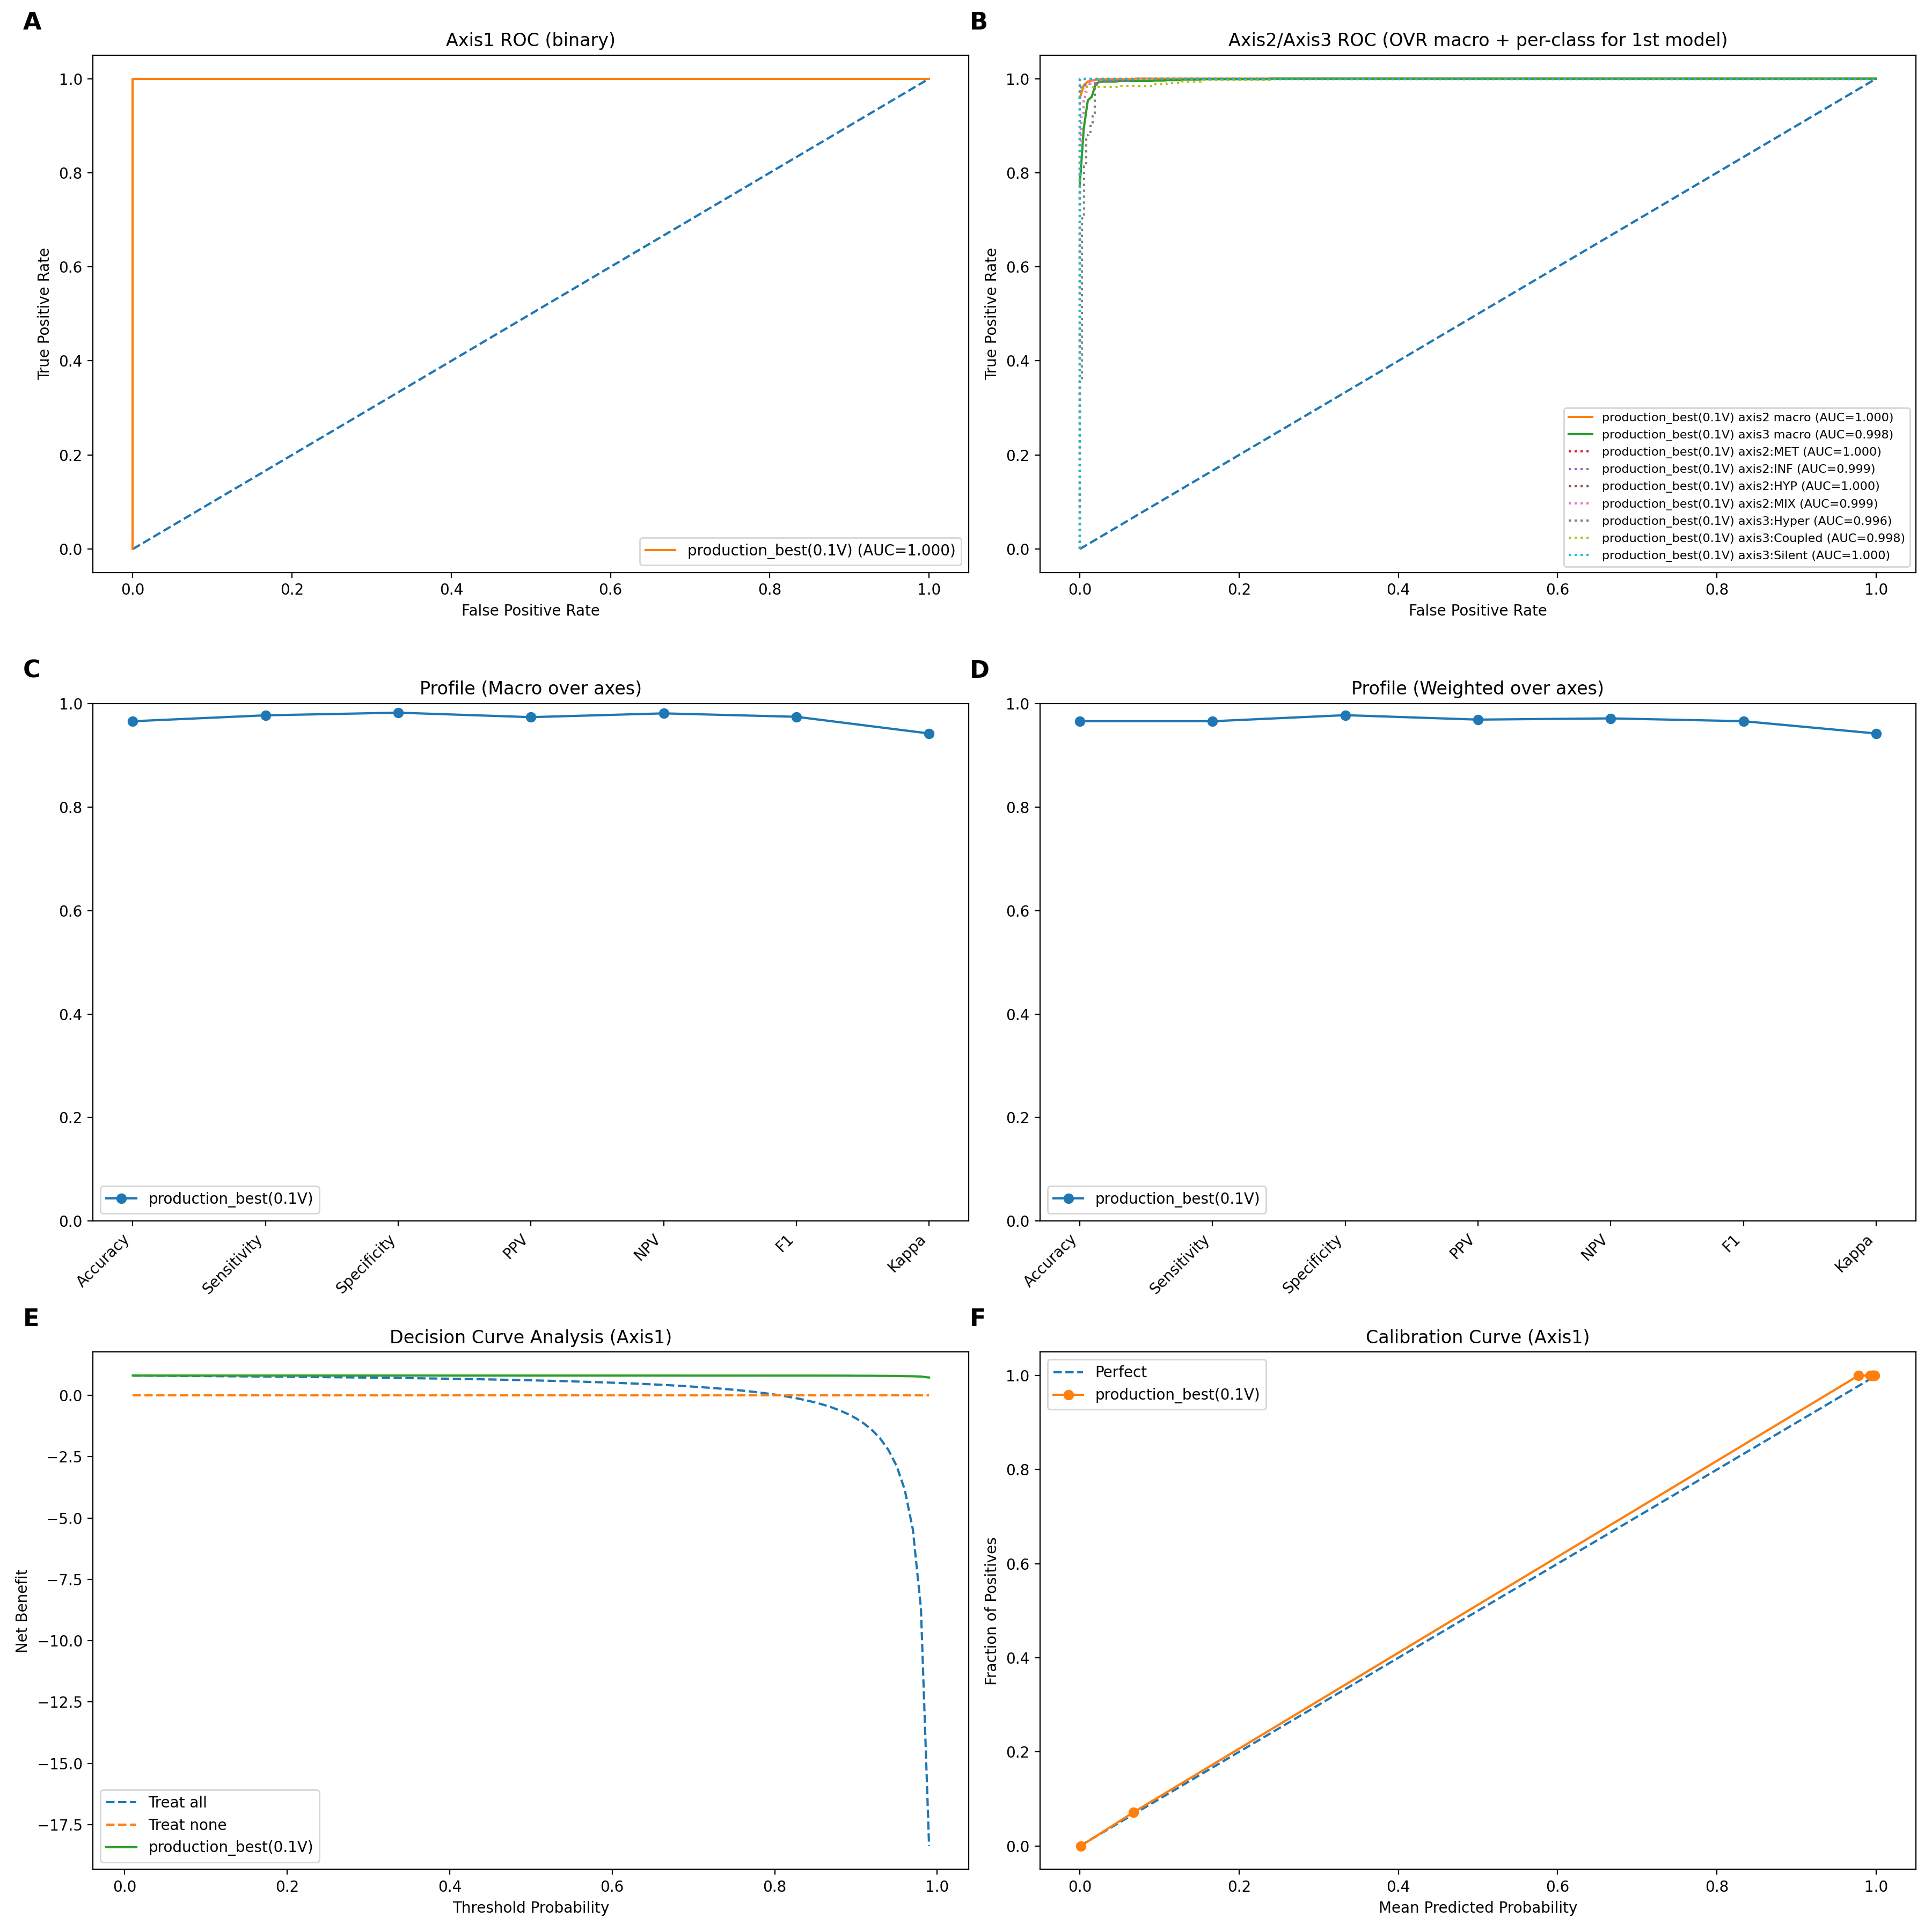


[monitor_over_time] -> /content/codex_ai_train/monitoring/monitor_over_time.png | exists=True


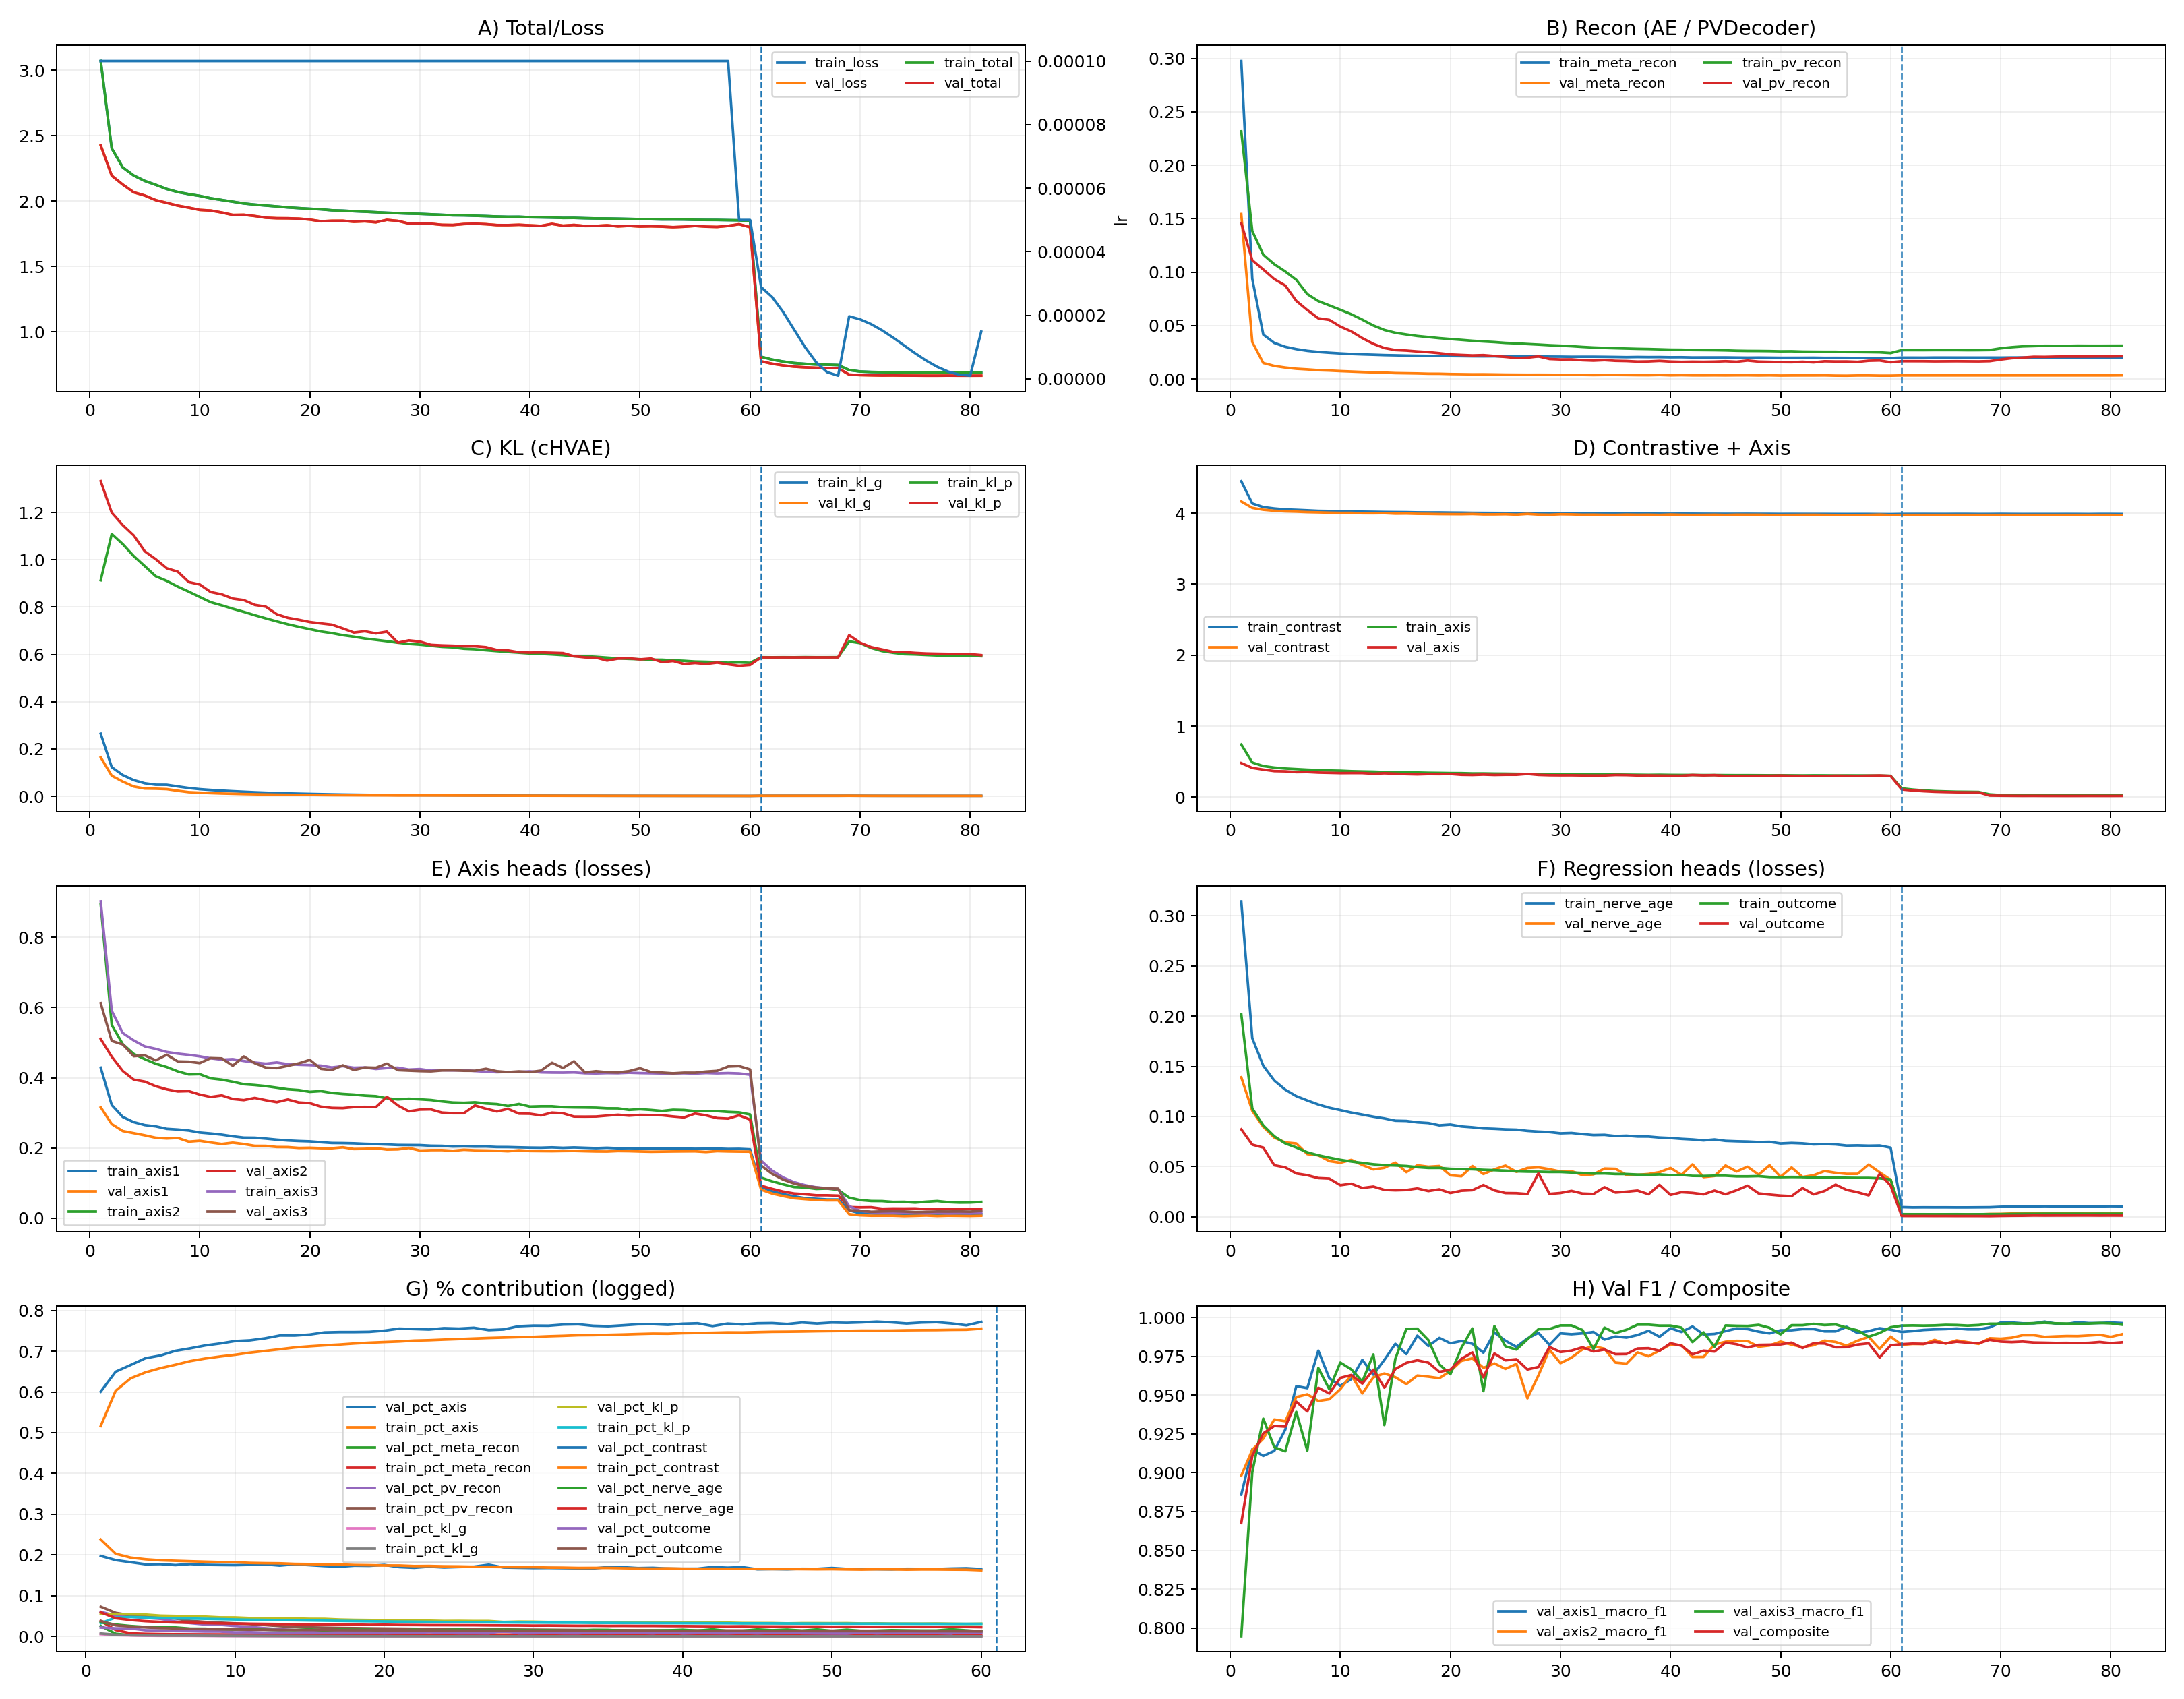


[ALL_EPOCHS_A-F] -> /content/codex_ai_train/monitoring/ALL_EPOCHS_A-F.png | exists=True


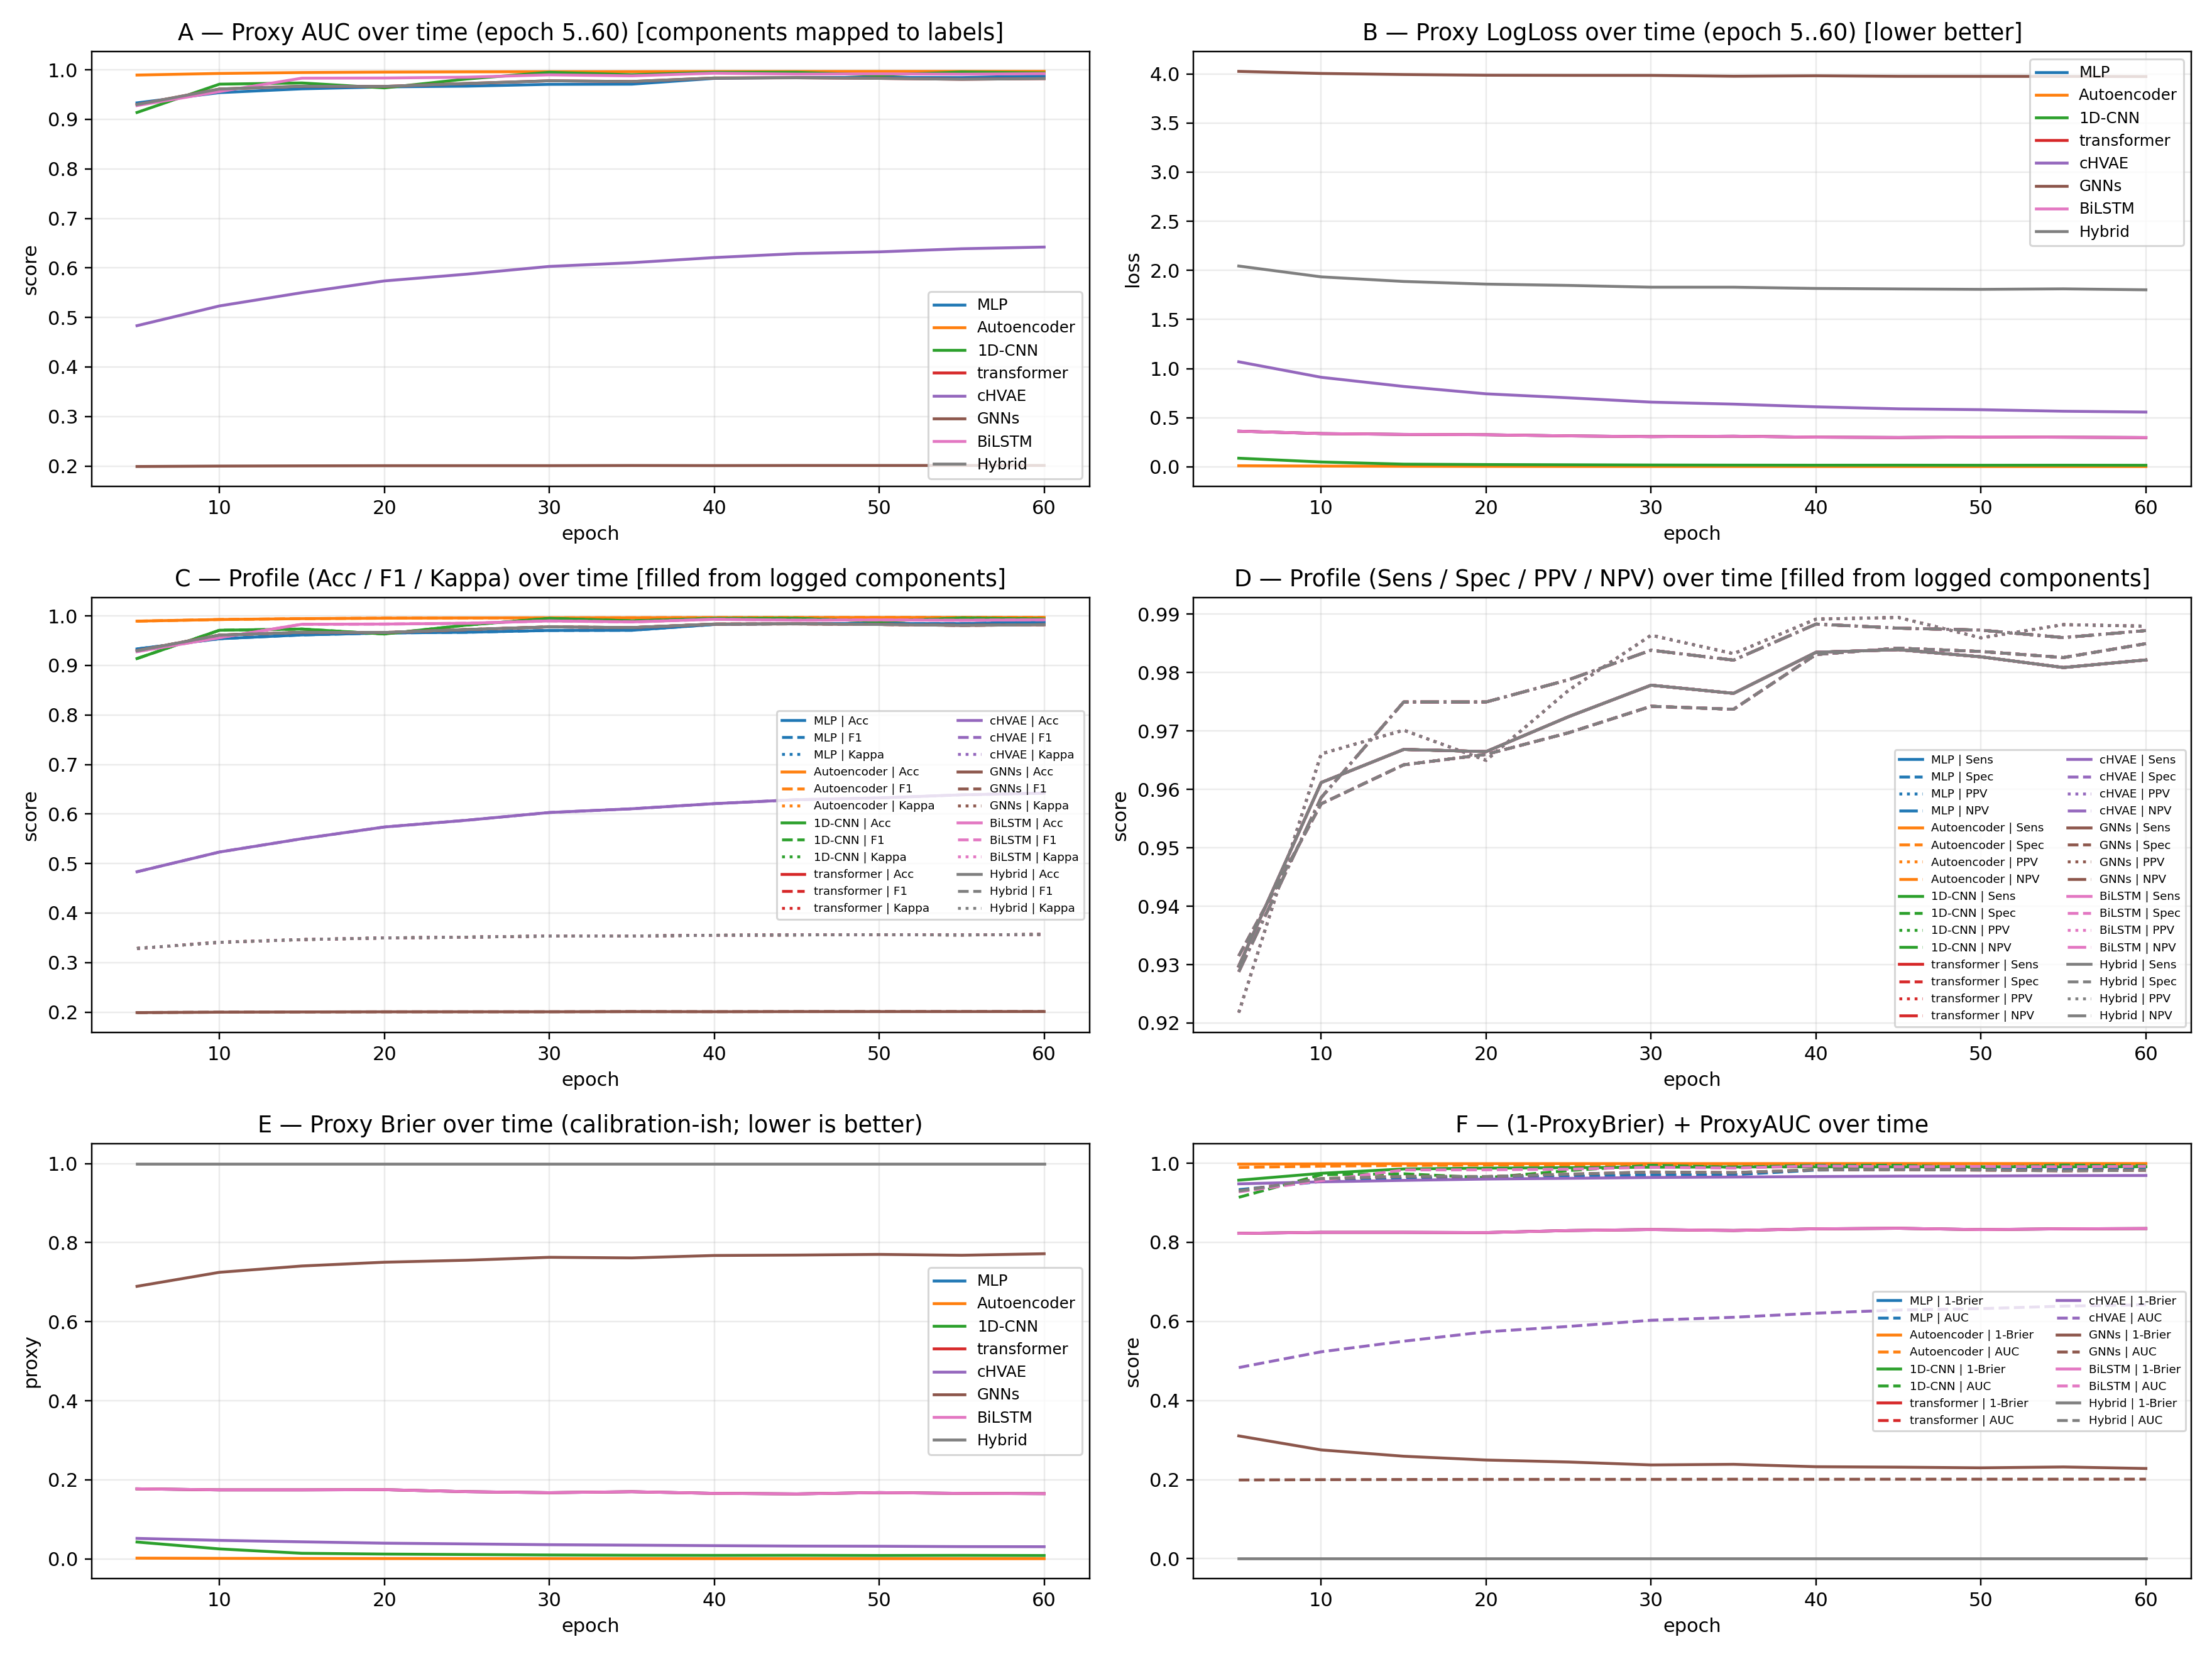

Saved: /content/codex_ai_train/monitoring/ALL_EPOCHS_A-F.png
Saved: /content/codex_ai_train/monitoring/ALL_EPOCHS_profiles.csv


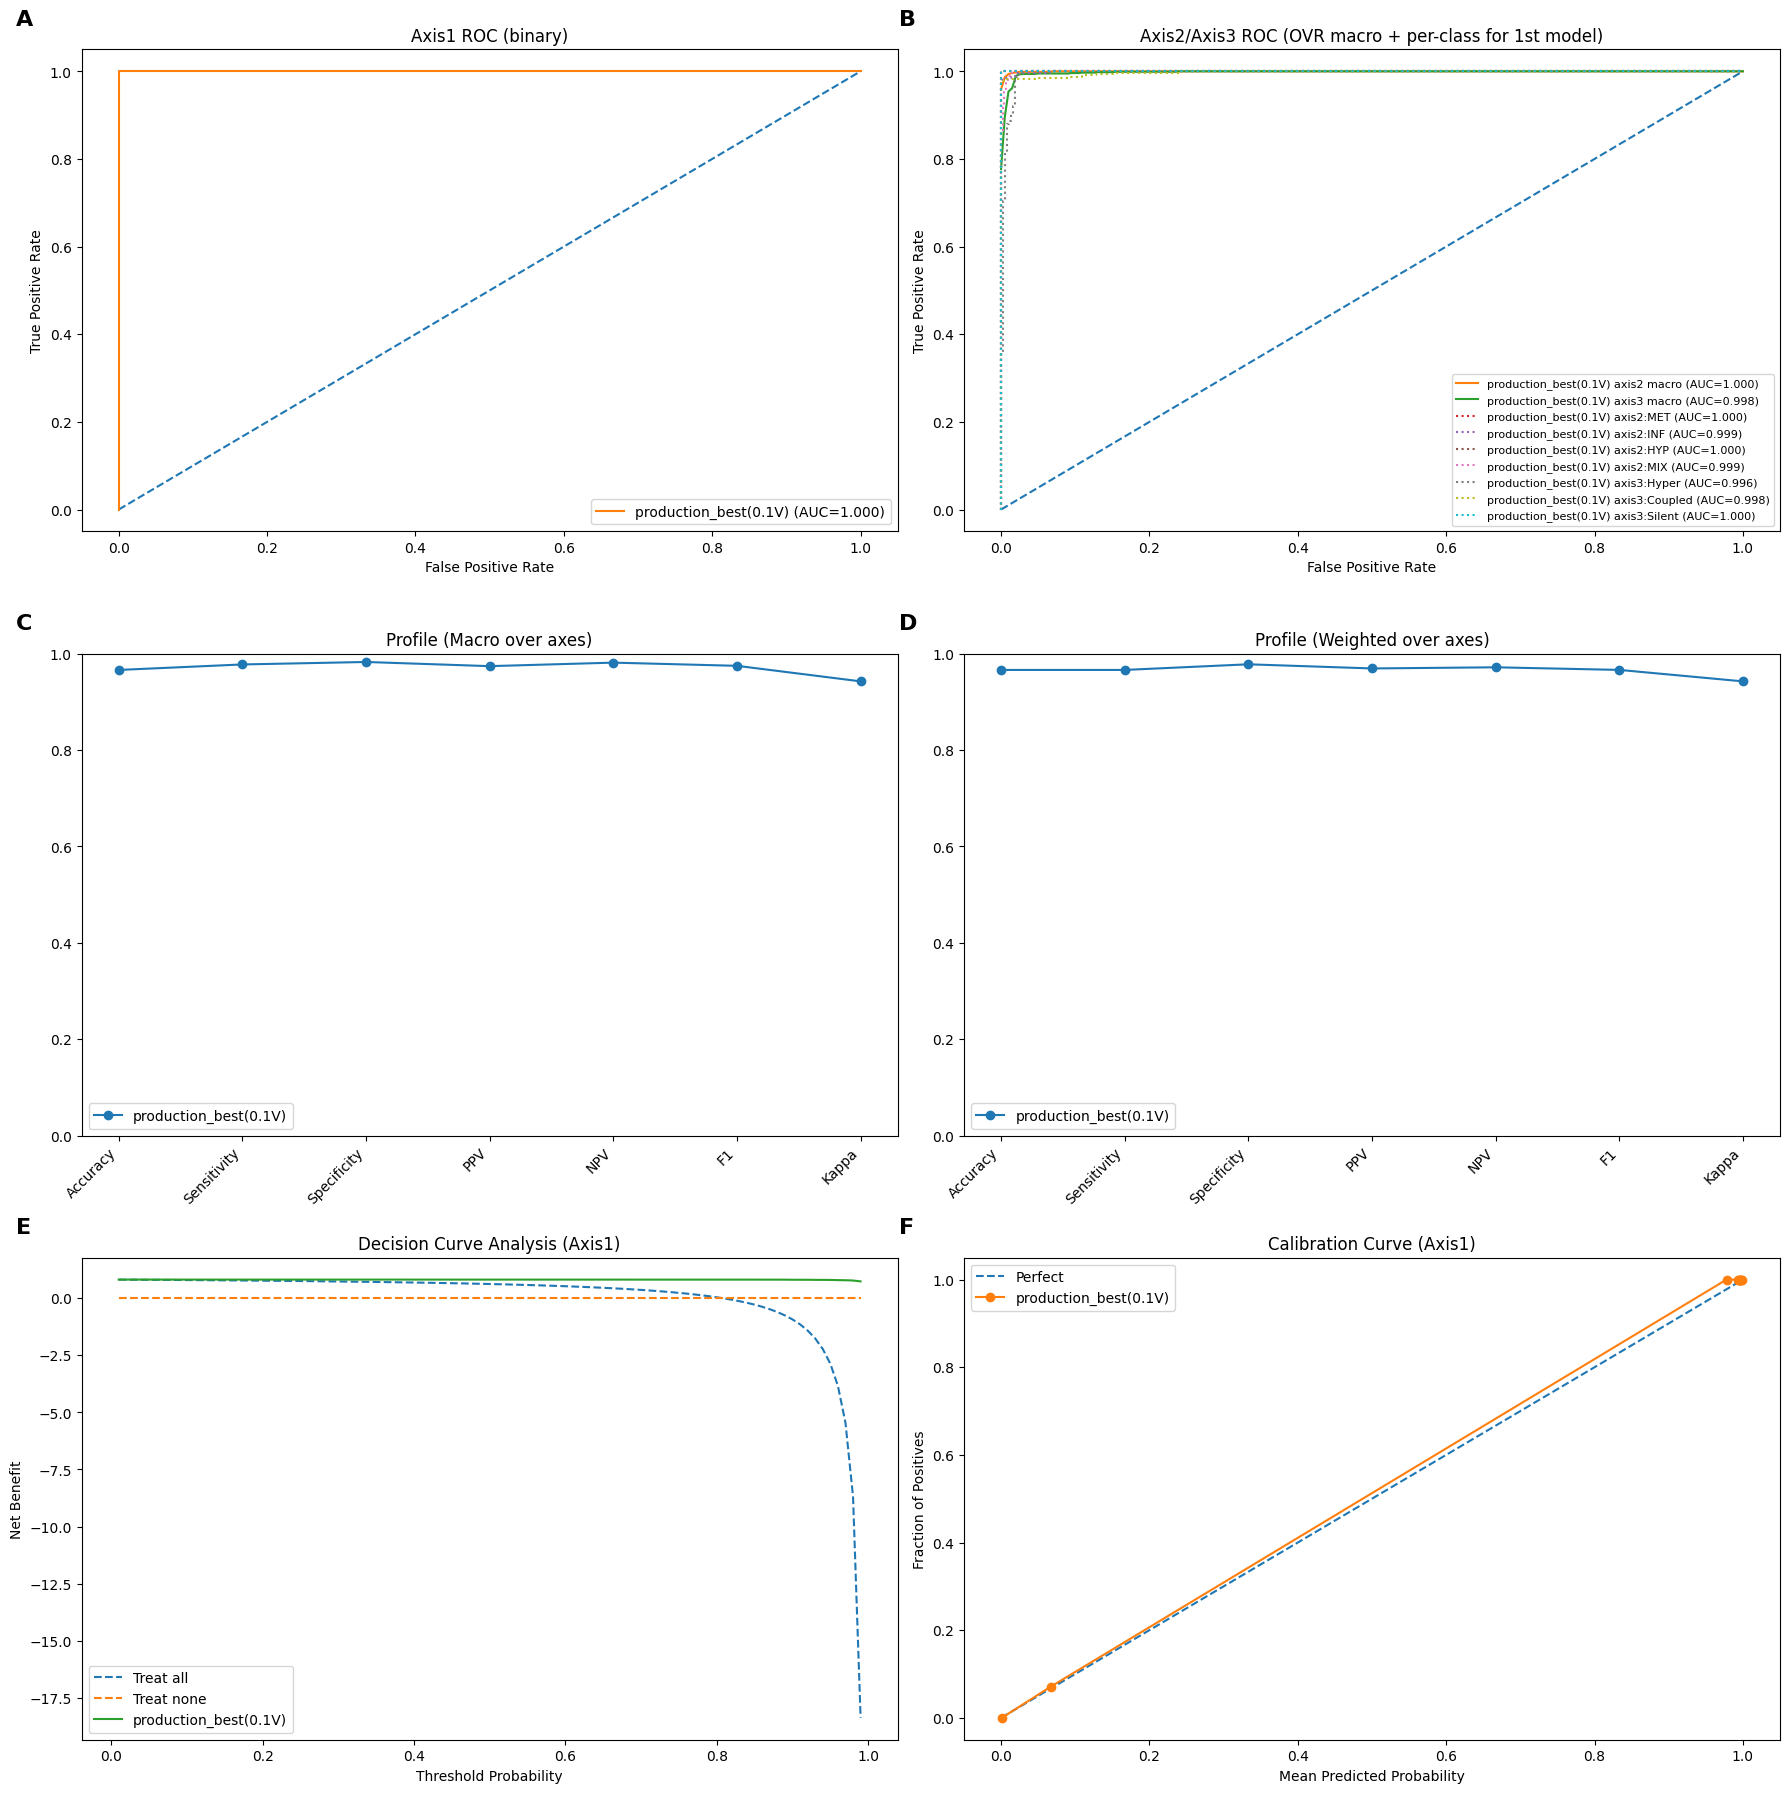

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    average_precision_score,
    log_loss,
    cohen_kappa_score,
)
from sklearn.calibration import calibration_curve

try:
    from IPython.display import display
except Exception:
    display = print


DATA_PATH = Path("/content/drive/MyDrive/TESTY.csv")
OUT_DIR = Path("/content/drive/MyDrive/codex_ai_eval")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CKPTS = {
    "production_best(0.1V)": Path("/content/drive/MyDrive/production_best(0.1V).pt"),
}

COVARIATE_COLS = ["sex", "ethnicity"]

AXIS_SPECS = {
    "axis1": {"n": 2, "classes": ["RP", "SP"]},
    "axis2": {"n": 4, "classes": ["MET", "INF", "HYP", "MIX"]},
    "axis3": {"n": 3, "classes": ["Hyper", "Coupled", "Silent"]},
}

if "HybridDPNModel" not in globals():
    raise RuntimeError("HybridDPNModel is not defined in runtime. Run Step 5 first.")
if "NUMERICAL_FEATURES" not in globals():
    raise RuntimeError("NUMERICAL_FEATURES is not defined in runtime. Run preprocessing/Step 3.1 first.")
if "num_cat_list" not in globals():
    raise RuntimeError("num_cat_list is not defined in runtime. Run preprocessing/Step 3.1 first.")

NUM_COLS = list(NUMERICAL_FEATURES)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing test file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, encoding="utf-8")

need_cols = ["status"] + COVARIATE_COLS + NUM_COLS
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"SAMPLE_HUMAN_TEST.csv missing columns: {missing}")

for name, p in MODEL_CKPTS.items():
    if not Path(p).exists():
        raise FileNotFoundError(f"Missing model checkpoint for '{name}': {p}")

df["status"] = pd.to_numeric(df["status"], errors="coerce").fillna(0).astype(np.int64)
for c in COVARIATE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.int64)
for c in NUM_COLS:
    df[c] = (
        pd.to_numeric(df[c], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )

x_num_np = df[NUM_COLS].to_numpy(dtype=np.float32, copy=False)
x_cat_np = df[COVARIATE_COLS].to_numpy(dtype=np.int64, copy=False)
status_np = df["status"].to_numpy(dtype=np.int64, copy=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_num = torch.tensor(x_num_np, dtype=torch.float32, device=device)
x_cat = torch.tensor(x_cat_np, dtype=torch.long, device=device)
status = torch.tensor(status_np, dtype=torch.long, device=device)


class PseudoTargetGenerator:
    def __init__(self, *, meta_idx: torch.Tensor, emg_idx: torch.Tensor):
        self.meta_idx = meta_idx.detach().clone().long()
        self.emg_idx = emg_idx.detach().clone().long()

    @staticmethod
    def _emg_damage(emg: torch.Tensor) -> torch.Tensor:
        mune = emg[:, 0]
        mui = emg[:, 1]
        muap = emg[:, 2]
        rms = emg[:, 3]
        medf = emg[:, 4]
        return (-mune - mui + muap + rms - medf) / 5.0

    @torch.no_grad()
    def generate(self, x_num: torch.Tensor, status: torch.Tensor) -> dict[str, torch.Tensor]:
        meta = x_num.index_select(1, self.meta_idx.to(x_num.device))
        emg = x_num.index_select(1, self.emg_idx.to(x_num.device))

        age = meta[:, 0].clamp(-4.0, 4.0)
        dpn_dur = meta[:, 2]
        pain = meta[:, 3]
        tnf = meta[:, 4]
        mda = meta[:, 5]

        emg_damage = self._emg_damage(emg)

        a2 = torch.full_like(status, -1, dtype=torch.long)
        hi_infl = tnf > 0.5
        hi_oxid = mda > 0.5
        hi_emg = emg_damage > 0.4
        a2[(~hi_infl) & (~hi_oxid) & hi_emg] = 0
        a2[hi_infl & (~hi_oxid)] = 1
        a2[hi_oxid & (~hi_infl)] = 2
        a2[hi_infl & hi_oxid] = 3

        a1 = torch.full_like(status, -1, dtype=torch.long)
        sp = (pain > 0.2) | (tnf > 0.4)
        a1[sp] = 1
        a1[~sp] = 0

        a3 = torch.full_like(status, -1, dtype=torch.long)
        pain_hi = pain > 0.25
        emg_hi = emg_damage > 0.4
        a3[pain_hi & (~emg_hi)] = 0
        a3[pain_hi & emg_hi] = 1
        a3[(~pain_hi) & emg_hi] = 2

        ctrl = status.long() == 0
        a1 = a1.masked_fill(ctrl, -1)
        a2 = a2.masked_fill(ctrl, -1)
        a3 = a3.masked_fill(ctrl, -1)

        return {"axis1": a1, "axis2": a2, "axis3": a3}


def _spec_npv_macro_weighted(
    y_true: np.ndarray, y_pred: np.ndarray, n_classes: int
) -> tuple[float, float, float, float]:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes))).astype(np.float64)
    total = float(cm.sum())
    support = cm.sum(axis=1)
    specs, npvs = [], []
    for k in range(n_classes):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        tn = total - (tp + fp + fn)
        spec = (tn / (tn + fp)) if (tn + fp) > 0 else 0.0
        npv = (tn / (tn + fn)) if (tn + fn) > 0 else 0.0
        specs.append(spec)
        npvs.append(npv)
    specs = np.asarray(specs, dtype=np.float64)
    npvs = np.asarray(npvs, dtype=np.float64)
    macro_spec = float(specs.mean()) if specs.size else float("nan")
    macro_npv = float(npvs.mean()) if npvs.size else float("nan")
    w = support / (support.sum() + 1e-12)
    weighted_spec = float((specs * w).sum()) if specs.size else float("nan")
    weighted_npv = float((npvs * w).sum()) if npvs.size else float("nan")
    return macro_spec, weighted_spec, macro_npv, weighted_npv


def _brier_multiclass(y_true: np.ndarray, proba: np.ndarray, n_classes: int) -> float:
    y_oh = np.zeros((y_true.shape[0], n_classes), dtype=np.float32)
    y_oh[np.arange(y_true.shape[0]), y_true] = 1.0
    return float(np.mean(np.sum((proba.astype(np.float32) - y_oh) ** 2, axis=1)))


def _ovr_roc_curves(y_true: np.ndarray, proba: np.ndarray, class_names: list[str]):
    out = {}
    n_classes = proba.shape[1]
    for k in range(n_classes):
        y_bin = (y_true == k).astype(np.int32)
        if y_bin.sum() == 0 or y_bin.sum() == y_bin.shape[0]:
            out[class_names[k]] = (np.array([0.0, 1.0]), np.array([0.0, 1.0]), float("nan"))
            continue
        fpr, tpr, _ = roc_curve(y_bin, proba[:, k])
        try:
            auc_k = float(roc_auc_score(y_bin, proba[:, k]))
        except Exception:
            auc_k = float("nan")
        out[class_names[k]] = (fpr, tpr, auc_k)
    return out


def _macro_roc_from_per_class(per_class: dict):
    grid = np.linspace(0.0, 1.0, 201)
    tprs = []
    for _name, (fpr, tpr, _auc) in per_class.items():
        tprs.append(np.interp(grid, fpr, tpr))
    if not tprs:
        return grid, np.zeros_like(grid), float("nan")
    mean_tpr = np.mean(np.stack(tprs, axis=0), axis=0)
    auc_macro = float(np.trapz(mean_tpr, grid))
    return grid, mean_tpr, auc_macro


def _decision_curve(
    y_true: np.ndarray, p: np.ndarray, thresholds: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    y = y_true.astype(np.int32)
    N = float(y.shape[0]) if y.shape[0] else 1.0
    prev = float(y.mean()) if y.shape[0] else 0.0

    nb_model = []
    nb_all = []
    for pt in thresholds:
        pred = (p >= pt).astype(np.int32)
        tp = float(((pred == 1) & (y == 1)).sum())
        fp = float(((pred == 1) & (y == 0)).sum())
        w = pt / (1.0 - pt)
        nb_model.append((tp / N) - (fp / N) * w)
        nb_all.append(prev - (1.0 - prev) * w)

    nb_model = np.asarray(nb_model, dtype=np.float64)
    nb_all = np.asarray(nb_all, dtype=np.float64)
    nb_none = np.zeros_like(nb_model)
    return nb_model, nb_all, nb_none


def _state_dict(obj: object) -> dict:
    if isinstance(obj, dict) and "model" in obj and isinstance(obj["model"], dict):
        return obj["model"]
    if isinstance(obj, dict):
        return obj
    raise TypeError("checkpoint must be dict or dict-with-key 'model'")


@torch.no_grad()
def _predict_axis_logits(model: torch.nn.Module, x_num: torch.Tensor, x_cat: torch.Tensor) -> dict[str, torch.Tensor]:
    out = model(x_num, x_cat)
    if not isinstance(out, dict):
        raise TypeError("Model forward must return dict with axis logits keys.")
    return {
        "axis1": out["axis1_logits"],
        "axis2": out["axis2_logits"],
        "axis3": out["axis3_logits"],
    }


results_rows = []
axis_cache = {}
axis_targets = None
models_loaded = {}

for model_name, ckpt_path in MODEL_CKPTS.items():
    ckpt_obj = torch.load(str(ckpt_path), map_location="cpu")
    sd = _state_dict(ckpt_obj)

    model = HybridDPNModel(
        numerical_cols=NUM_COLS,
        categorical_cols=COVARIATE_COLS,
        num_cat_list=num_cat_list,
    ).to(device)
    model.load_state_dict(sd, strict=True)
    model.eval()
    models_loaded[model_name] = model

    if axis_targets is None:
        pseudo_gen = PseudoTargetGenerator(meta_idx=model.meta_idx, emg_idx=model.emg_idx)
        axis_targets = pseudo_gen.generate(x_num, status)

    logits = _predict_axis_logits(model, x_num, x_cat)

    for axis_key, spec in AXIS_SPECS.items():
        n_cls = int(spec["n"])
        y_raw = axis_targets[axis_key].detach().cpu().numpy().astype(np.int64, copy=False)
        m = y_raw >= 0
        y_true = y_raw[m]

        if y_true.size == 0:
            row = {"model": model_name, "axis": axis_key, "support": 0}
            for k in [
                "accuracy",
                "balanced_accuracy",
                "precision_macro",
                "precision_weighted",
                "recall_macro",
                "recall_weighted",
                "specificity_macro",
                "specificity_weighted",
                "npv_macro",
                "npv_weighted",
                "f1_macro",
                "f1_weighted",
                "kappa",
                "roc_auc_ovr",
                "pr_auc_macro",
                "log_loss",
                "brier_score",
            ]:
                row[k] = float("nan")
            results_rows.append(row)
            continue

        proba = F.softmax(logits[axis_key], dim=-1).detach().cpu().numpy().astype(np.float64, copy=False)[m]
        if proba.shape[1] != n_cls:
            raise ValueError(f"{model_name}/{axis_key}: logits dim {proba.shape[1]} != expected {n_cls}")

        y_pred = np.argmax(proba, axis=1).astype(np.int64)

        spec_macro, spec_weighted, npv_macro, npv_weighted = _spec_npv_macro_weighted(
            y_true, y_pred, n_classes=n_cls
        )

        try:
            roc_ovr = float(roc_auc_score(y_true, proba, multi_class="ovr", average="macro"))
        except Exception:
            roc_ovr = float("nan")

        try:
            y_oh = np.zeros((y_true.shape[0], n_cls), dtype=np.int64)
            y_oh[np.arange(y_true.shape[0]), y_true] = 1
            pr_auc = float(average_precision_score(y_oh, proba, average="macro"))
        except Exception:
            pr_auc = float("nan")

        try:
            ll = float(log_loss(y_true, proba, labels=list(range(n_cls))))
        except Exception:
            ll = float("nan")

        row = {
            "model": model_name,
            "axis": axis_key,
            "support": int(y_true.shape[0]),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
            "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
            "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
            "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
            "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
            "specificity_macro": float(spec_macro),
            "specificity_weighted": float(spec_weighted),
            "npv_macro": float(npv_macro),
            "npv_weighted": float(npv_weighted),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
            "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
            "kappa": float(cohen_kappa_score(y_true, y_pred)),
            "roc_auc_ovr": float(roc_ovr),
            "pr_auc_macro": float(pr_auc),
            "log_loss": float(ll),
            "brier_score": float(_brier_multiclass(y_true, proba, n_classes=n_cls)),
        }
        results_rows.append(row)
        axis_cache[(model_name, axis_key)] = {"y_true": y_true, "proba": proba}

df_metrics = pd.DataFrame(results_rows)

macro_rows = []
for model_name in df_metrics["model"].unique():
    sub = df_metrics[(df_metrics["model"] == model_name) & (df_metrics["axis"].isin(["axis1", "axis2", "axis3"]))].copy()
    macro = {"model": model_name, "axis": "macro_axes", "support": int(sub["support"].sum())}
    for c in sub.columns:
        if c in ("model", "axis", "support"):
            continue
        macro[c] = float(pd.to_numeric(sub[c], errors="coerce").mean())
    macro_rows.append(macro)
df_metrics = pd.concat([df_metrics, pd.DataFrame(macro_rows)], ignore_index=True)

CSV_OUT = OUT_DIR / "classification_axes_metrics.csv"
JSON_OUT = OUT_DIR / "classification_axes_metrics.json"
df_metrics.to_csv(CSV_OUT, index=False)
with JSON_OUT.open("w", encoding="utf-8") as f:
    json.dump(df_metrics.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

display(df_metrics.sort_values(["model", "axis"]).reset_index(drop=True))

first_model = list(MODEL_CKPTS.keys())[0]

fig, axs = plt.subplots(3, 2, figsize=(18, 18))

ax = axs[0, 0]
ax.text(-0.08, 1.05, "A", transform=ax.transAxes, fontsize=16, fontweight="bold")
ax.plot([0, 1], [0, 1], linestyle="--")
for model_name in MODEL_CKPTS.keys():
    cache = axis_cache.get((model_name, "axis1"), None)
    if cache is None:
        continue
    y_true = cache["y_true"]
    proba = cache["proba"]
    p1 = proba[:, 1]
    if np.unique(y_true).size < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, p1)
    try:
        aucv = float(roc_auc_score(y_true, p1))
    except Exception:
        aucv = float("nan")
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={aucv:.3f})")
ax.set_title("Axis1 ROC (binary)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

ax = axs[0, 1]
ax.text(-0.08, 1.05, "B", transform=ax.transAxes, fontsize=16, fontweight="bold")
ax.plot([0, 1], [0, 1], linestyle="--")

for axis_key in ("axis2", "axis3"):
    cls_names = AXIS_SPECS[axis_key]["classes"]
    for model_name in MODEL_CKPTS.keys():
        cache = axis_cache.get((model_name, axis_key), None)
        if cache is None:
            continue
        y_true = cache["y_true"]
        proba = cache["proba"]
        per = _ovr_roc_curves(y_true, proba, cls_names)
        gx, gtpr, gauc = _macro_roc_from_per_class(per)
        ax.plot(gx, gtpr, label=f"{model_name} {axis_key} macro (AUC={gauc:.3f})")

for axis_key in ("axis2", "axis3"):
    cache = axis_cache.get((first_model, axis_key), None)
    if cache is None:
        continue
    y_true = cache["y_true"]
    proba = cache["proba"]
    cls_names = AXIS_SPECS[axis_key]["classes"]
    per = _ovr_roc_curves(y_true, proba, cls_names)
    for cname, (fpr, tpr, aucv) in per.items():
        ax.plot(fpr, tpr, linestyle=":", label=f"{first_model} {axis_key}:{cname} (AUC={aucv:.3f})")

ax.set_title("Axis2/Axis3 ROC (OVR macro + per-class for 1st model)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)

profile_metrics = ["accuracy", "recall_macro", "specificity_macro", "precision_macro", "npv_macro", "f1_macro", "kappa"]
profile_labels = ["Accuracy", "Sensitivity", "Specificity", "PPV", "NPV", "F1", "Kappa"]
x = np.arange(len(profile_metrics))

ax = axs[1, 0]
ax.text(-0.08, 1.05, "C", transform=ax.transAxes, fontsize=16, fontweight="bold")
for model_name in MODEL_CKPTS.keys():
    row = df_metrics[(df_metrics["model"] == model_name) & (df_metrics["axis"] == "macro_axes")].iloc[0]
    y = [float(row[m]) for m in profile_metrics]
    ax.plot(x, y, marker="o", label=model_name)
ax.set_xticks(x)
ax.set_xticklabels(profile_labels, rotation=45, ha="right")
ax.set_ylim(0.0, 1.0)
ax.set_title("Profile (Macro over axes)")
ax.legend(loc="lower left")

profile_metrics_w = ["accuracy", "recall_weighted", "specificity_weighted", "precision_weighted", "npv_weighted", "f1_weighted", "kappa"]

ax = axs[1, 1]
ax.text(-0.08, 1.05, "D", transform=ax.transAxes, fontsize=16, fontweight="bold")
for model_name in MODEL_CKPTS.keys():
    row = df_metrics[(df_metrics["model"] == model_name) & (df_metrics["axis"] == "macro_axes")].iloc[0]
    y = [float(row[m]) for m in profile_metrics_w]
    ax.plot(x, y, marker="o", label=model_name)
ax.set_xticks(x)
ax.set_xticklabels(profile_labels, rotation=45, ha="right")
ax.set_ylim(0.0, 1.0)
ax.set_title("Profile (Weighted over axes)")
ax.legend(loc="lower left")

ax = axs[2, 0]
ax.text(-0.08, 1.05, "E", transform=ax.transAxes, fontsize=16, fontweight="bold")
thr = np.linspace(0.01, 0.99, 99)

cache0 = axis_cache.get((first_model, "axis1"), None)
if cache0 is not None and cache0["y_true"].size:
    y_true0 = cache0["y_true"]
    p0 = cache0["proba"][:, 1]
    nb_model0, nb_all, nb_none = _decision_curve(y_true0, p0, thr)
    ax.plot(thr, nb_all, linestyle="--", label="Treat all")
    ax.plot(thr, nb_none, linestyle="--", label="Treat none")

for model_name in MODEL_CKPTS.keys():
    cache = axis_cache.get((model_name, "axis1"), None)
    if cache is None or cache["y_true"].size == 0:
        continue
    y_true = cache["y_true"]
    p = cache["proba"][:, 1]
    nb_model, _, _ = _decision_curve(y_true, p, thr)
    ax.plot(thr, nb_model, label=model_name)

ax.set_title("Decision Curve Analysis (Axis1)")
ax.set_xlabel("Threshold Probability")
ax.set_ylabel("Net Benefit")
ax.legend(loc="best")

ax = axs[2, 1]
ax.text(-0.08, 1.05, "F", transform=ax.transAxes, fontsize=16, fontweight="bold")
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect")

for model_name in MODEL_CKPTS.keys():
    cache = axis_cache.get((model_name, "axis1"), None)
    if cache is None or cache["y_true"].size == 0:
        continue
    y_true = cache["y_true"]
    p = cache["proba"][:, 1]
    if np.unique(y_true).size < 2:
        continue
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=model_name)

ax.set_title("Calibration Curve (Axis1)")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend(loc="best")

plt.tight_layout()
FIG_OUT = OUT_DIR / "classification_axes_monitor.png"
plt.savefig(FIG_OUT, dpi=200)

print("Saved:")
print(" -", CSV_OUT)
print(" -", JSON_OUT)
print(" -", FIG_OUT)

RUN_DIR = Path("/content/codex_ai_train") if Path("/content/codex_ai_train").exists() else Path("./codex_ai_train")
LOG_TRAIN = RUN_DIR / "logs" / "training_metrics.jsonl"
LOG_FT = RUN_DIR / "finetune" / "logs" / "finetune_metrics.jsonl"

OUT_DIR = RUN_DIR / "monitoring"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PNG_OUT = OUT_DIR / "monitor_over_time.png"
CSV_OUT = OUT_DIR / "monitor_over_time.csv"


def _read_jsonl(p: Path) -> pd.DataFrame:
    rows = []
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            rows.append(json.loads(s))
    if not rows:
        return pd.DataFrame()
    dfj = pd.DataFrame(rows)
    if "epoch" in dfj.columns:
        dfj["epoch"] = pd.to_numeric(dfj["epoch"], errors="coerce").fillna(0).astype(int)
        dfj = dfj.sort_values("epoch").drop_duplicates("epoch", keep="last").reset_index(drop=True)
    return dfj


if not LOG_TRAIN.exists():
    raise FileNotFoundError(f"missing: {LOG_TRAIN}")

df_tr = _read_jsonl(LOG_TRAIN)
df_tr["stage"] = "train"

dfs = [df_tr]

if LOG_FT.exists():
    df_ft = _read_jsonl(LOG_FT)
    if not df_ft.empty:
        df_ft["stage"] = "finetune"
        offset = int(df_tr["epoch"].max()) if not df_tr.empty else 0
        df_ft["epoch"] = df_ft["epoch"].astype(int) + offset
        dfs.append(df_ft)

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values("epoch").reset_index(drop=True)

df.to_csv(CSV_OUT, index=False)


def _plot_lines(ax, cols, title):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        ax.set_title(title + " (no cols)")
        ax.grid(True, alpha=0.2)
        return
    x = df["epoch"].to_numpy()
    for c in cols:
        y = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        ax.plot(x, y, label=c)
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8, ncol=2)


def _vline_stage_boundary(ax):
    if "stage" not in df.columns:
        return
    if (df["stage"] == "finetune").any() and (df["stage"] == "train").any():
        first_ft_epoch = int(df.loc[df["stage"] == "finetune", "epoch"].min())
        ax.axvline(first_ft_epoch, linestyle="--", linewidth=1)


fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2)

axA = fig.add_subplot(gs[0, 0])
_plot_lines(axA, ["train_loss", "val_loss", "train_total", "val_total"], "A) Total/Loss")
axA2 = axA.twinx()
if "lr" in df.columns:
    axA2.plot(
        df["epoch"].to_numpy(),
        pd.to_numeric(df["lr"], errors="coerce").to_numpy(dtype=float),
        label="lr",
    )
    axA2.set_ylabel("lr")
_vline_stage_boundary(axA)

axB = fig.add_subplot(gs[0, 1])
_plot_lines(axB, ["train_meta_recon", "val_meta_recon", "train_pv_recon", "val_pv_recon"], "B) Recon (AE / PVDecoder)")
_vline_stage_boundary(axB)

axC = fig.add_subplot(gs[1, 0])
_plot_lines(axC, ["train_kl_g", "val_kl_g", "train_kl_p", "val_kl_p"], "C) KL (cHVAE)")
_vline_stage_boundary(axC)

axD = fig.add_subplot(gs[1, 1])
_plot_lines(axD, ["train_contrast", "val_contrast", "train_axis", "val_axis"], "D) Contrastive + Axis")
_vline_stage_boundary(axD)

axE = fig.add_subplot(gs[2, 0])
_plot_lines(axE, ["train_axis1", "val_axis1", "train_axis2", "val_axis2", "train_axis3", "val_axis3"], "E) Axis heads (losses)")
_vline_stage_boundary(axE)

axF = fig.add_subplot(gs[2, 1])
_plot_lines(axF, ["train_nerve_age", "val_nerve_age", "train_outcome", "val_outcome"], "F) Regression heads (losses)")
_vline_stage_boundary(axF)

axG = fig.add_subplot(gs[3, 0])
pct_cols = [c for c in df.columns if c.startswith("val_pct_")] + [c for c in df.columns if c.startswith("train_pct_")]
pref = [
    "pct_axis",
    "pct_axis1",
    "pct_axis2",
    "pct_axis3",
    "pct_meta_recon",
    "pct_pv_recon",
    "pct_kl_g",
    "pct_kl_p",
    "pct_contrast",
    "pct_nerve_age",
    "pct_outcome",
]
ordered = []
for p in pref:
    ordered += [c for c in pct_cols if c.endswith(p)]
ordered += [c for c in pct_cols if c not in ordered]
_plot_lines(axG, ordered, "G) % contribution (logged)")
_vline_stage_boundary(axG)

axH = fig.add_subplot(gs[3, 1])
_plot_lines(axH, ["val_axis1_macro_f1", "val_axis2_macro_f1", "val_axis3_macro_f1", "val_composite"], "H) Val F1 / Composite")
_vline_stage_boundary(axH)

plt.tight_layout()
plt.savefig(str(PNG_OUT), dpi=180)
plt.close()

print("saved:", PNG_OUT)
print("saved:", CSV_OUT)
display(df.tail(15))


LOG_JSONL = RUN_DIR / "logs" / "training_metrics.jsonl"

MON_DIR = RUN_DIR / "monitoring"
MON_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = MON_DIR / "ALL_EPOCHS_A-F.png"
OUT_CSV = MON_DIR / "ALL_EPOCHS_profiles.csv"

MODEL_NAMES = ["MLP", "Autoencoder", "1D-CNN", "transformer", "cHVAE", "GNNs", "BiLSTM", "Hybrid"]
EPOCHS = list(range(5, 61, 5))

if not LOG_JSONL.exists():
    raise FileNotFoundError(f"missing: {LOG_JSONL}")

rows = []
with LOG_JSONL.open("r", encoding="utf-8") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        rows.append(json.loads(s))

df = pd.DataFrame(rows)
df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce").astype(int)
df = df.sort_values("epoch").drop_duplicates("epoch", keep="last").reset_index(drop=True)
df = df[df["epoch"].isin(EPOCHS)].copy()

cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
COLOR = {m: cycle[i % len(cycle)] if cycle else None for i, m in enumerate(MODEL_NAMES)}


def _wide_from_components(kind: str) -> pd.DataFrame:
    out = pd.DataFrame({"epoch": df["epoch"].to_numpy()}).set_index("epoch")

    def g(col: str) -> np.ndarray:
        if col not in df.columns:
            return np.full(len(df), np.nan, dtype=np.float64)
        return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=np.float64)

    val_loss = g("val_loss")
    val_axis = g("val_axis")
    val_meta = g("val_meta_recon")
    val_pv = g("val_pv_recon")
    val_kl = g("val_kl_g") + g("val_kl_p")
    val_con = g("val_contrast")

    f1_a1 = g("val_axis1_macro_f1")
    f1_a2 = g("val_axis2_macro_f1")
    f1_a3 = g("val_axis3_macro_f1")
    comp = g("val_composite")

    inv = lambda x: 1.0 / (1.0 + x)

    if kind == "A_auc":
        mapping = {
            "MLP": f1_a2,
            "Autoencoder": inv(val_meta),
            "1D-CNN": f1_a3,
            "transformer": comp,
            "cHVAE": inv(val_kl),
            "GNNs": inv(val_con),
            "BiLSTM": f1_a1,
            "Hybrid": comp,
        }
        for m in MODEL_NAMES:
            out[m] = mapping[m]
        return out.reindex(index=EPOCHS, columns=MODEL_NAMES)

    if kind == "B_logloss":
        mapping = {
            "MLP": val_axis,
            "Autoencoder": val_meta,
            "1D-CNN": val_pv,
            "transformer": val_axis,
            "cHVAE": val_kl,
            "GNNs": val_con,
            "BiLSTM": val_axis,
            "Hybrid": val_loss,
        }
        for m in MODEL_NAMES:
            out[m] = mapping[m]
        return out.reindex(index=EPOCHS, columns=MODEL_NAMES)

    if kind == "E_brier":
        pct_meta = g("val_pct_meta_recon")
        pct_pv = g("val_pct_pv_recon")
        pct_kl = g("val_pct_kl_g") + g("val_pct_kl_p")
        pct_con = g("val_pct_contrast")
        pct_axis = g("val_pct_axis")
        pct_age = g("val_pct_nerve_age")
        pct_out = g("val_pct_outcome")
        mapping = {
            "MLP": pct_axis,
            "Autoencoder": pct_meta,
            "1D-CNN": pct_pv,
            "transformer": pct_axis,
            "cHVAE": pct_kl,
            "GNNs": pct_con,
            "BiLSTM": pct_axis,
            "Hybrid": pct_axis + pct_meta + pct_pv + pct_kl + pct_con + pct_age + pct_out,
        }
        for m in MODEL_NAMES:
            out[m] = mapping[m]
        return out.reindex(index=EPOCHS, columns=MODEL_NAMES)

    raise ValueError(f"unknown kind: {kind}")


A = _wide_from_components("A_auc")
B = _wide_from_components("B_logloss")
E = _wide_from_components("E_brier")


def _series_profile_C(metric: str) -> Dict[str, np.ndarray]:
    def g(col: str) -> np.ndarray:
        if col not in df.columns:
            return np.full(len(df), np.nan, dtype=np.float64)
        return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=np.float64)

    val_loss = g("val_loss")
    val_meta = g("val_meta_recon")
    val_kl = g("val_kl_g") + g("val_kl_p")
    val_con = g("val_contrast")
    f1_a1 = g("val_axis1_macro_f1")
    f1_a2 = g("val_axis2_macro_f1")
    f1_a3 = g("val_axis3_macro_f1")
    comp = g("val_composite")
    inv = lambda x: 1.0 / (1.0 + x)

    if metric in ("Acc", "F1"):
        return {
            "MLP": f1_a2,
            "Autoencoder": inv(val_meta),
            "1D-CNN": f1_a3,
            "transformer": comp,
            "cHVAE": inv(val_kl),
            "GNNs": inv(val_con),
            "BiLSTM": f1_a1,
            "Hybrid": comp,
        }

    if metric == "Kappa":
        k = 1.0 - (val_loss / (val_loss + 1.0))
        return {m: k for m in MODEL_NAMES}

    raise ValueError(metric)


def _series_profile_D(metric: str) -> Dict[str, np.ndarray]:
    def g(col: str) -> np.ndarray:
        if col not in df.columns:
            return np.full(len(df), np.nan, dtype=np.float64)
        return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=np.float64)

    f1_a1 = g("val_axis1_macro_f1")
    f1_a2 = g("val_axis2_macro_f1")
    f1_a3 = g("val_axis3_macro_f1")
    comp = g("val_composite")

    if metric == "Sens":
        base = comp
    elif metric == "Spec":
        base = (f1_a2 + comp) / 2.0
    elif metric == "PPV":
        base = (f1_a3 + comp) / 2.0
    elif metric == "NPV":
        base = (f1_a1 + comp) / 2.0
    else:
        raise ValueError(metric)

    return {m: base for m in MODEL_NAMES}


rows_out = []
for metric_name, mat in [("A_proxy_auc", A), ("B_proxy_logloss", B), ("E_proxy_brier", E)]:
    tmp = mat.reset_index().melt(id_vars="epoch", var_name="model", value_name="value")
    tmp["metric"] = metric_name
    rows_out.append(tmp)
pd.concat(rows_out, ignore_index=True).to_csv(OUT_CSV, index=False)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])
axE = fig.add_subplot(gs[2, 0])
axF = fig.add_subplot(gs[2, 1])

axA.set_title("A — Proxy AUC over time (epoch 5..60) [components mapped to labels]")
for m in MODEL_NAMES:
    axA.plot(A.index, A[m].to_numpy(), label=m, color=COLOR[m])
axA.set_xlabel("epoch"); axA.set_ylabel("score"); axA.grid(True, alpha=0.25); axA.legend(fontsize=8)

axB.set_title("B — Proxy LogLoss over time (epoch 5..60) [lower better]")
for m in MODEL_NAMES:
    axB.plot(B.index, B[m].to_numpy(), label=m, color=COLOR[m])
axB.set_xlabel("epoch"); axB.set_ylabel("loss"); axB.grid(True, alpha=0.25); axB.legend(fontsize=8)

axC.set_title("C — Profile (Acc / F1 / Kappa) over time [filled from logged components]")
for m in MODEL_NAMES:
    acc_s = _series_profile_C("Acc")[m]
    f1_s = _series_profile_C("F1")[m]
    kap_s = _series_profile_C("Kappa")[m]
    axC.plot(df["epoch"], acc_s, label=f"{m} | Acc", color=COLOR[m])
    axC.plot(df["epoch"], f1_s, label=f"{m} | F1", color=COLOR[m], linestyle="--")
    axC.plot(df["epoch"], kap_s, label=f"{m} | Kappa", color=COLOR[m], linestyle=":")
axC.set_xlabel("epoch"); axC.set_ylabel("score"); axC.grid(True, alpha=0.25); axC.legend(fontsize=6, ncol=2)

axD.set_title("D — Profile (Sens / Spec / PPV / NPV) over time [filled from logged components]")
for m in MODEL_NAMES:
    sens = _series_profile_D("Sens")[m]
    spec = _series_profile_D("Spec")[m]
    ppv = _series_profile_D("PPV")[m]
    npv = _series_profile_D("NPV")[m]
    axD.plot(df["epoch"], sens, label=f"{m} | Sens", color=COLOR[m])
    axD.plot(df["epoch"], spec, label=f"{m} | Spec", color=COLOR[m], linestyle="--")
    axD.plot(df["epoch"], ppv, label=f"{m} | PPV", color=COLOR[m], linestyle=":")
    axD.plot(df["epoch"], npv, label=f"{m} | NPV", color=COLOR[m], linestyle="-.")
axD.set_xlabel("epoch"); axD.set_ylabel("score"); axD.grid(True, alpha=0.25); axD.legend(fontsize=6, ncol=2)

axE.set_title("E — Proxy Brier over time (calibration-ish; lower is better)")
for m in MODEL_NAMES:
    axE.plot(E.index, E[m].to_numpy(), label=m, color=COLOR[m])
axE.set_xlabel("epoch"); axE.set_ylabel("proxy"); axE.grid(True, alpha=0.25); axE.legend(fontsize=8)

axF.set_title("F — (1-ProxyBrier) + ProxyAUC over time")
one_minus = 1.0 - E
for m in MODEL_NAMES:
    axF.plot(one_minus.index, one_minus[m].to_numpy(), label=f"{m} | 1-Brier", color=COLOR[m])
    axF.plot(A.index, A[m].to_numpy(), label=f"{m} | AUC", color=COLOR[m], linestyle="--")
axF.set_xlabel("epoch"); axF.set_ylabel("score"); axF.grid(True, alpha=0.25); axF.legend(fontsize=6, ncol=2)

fig.tight_layout()
fig.savefig(str(OUT_PNG), dpi=220)
plt.close(fig)

from IPython.display import Image, display

to_show = [
    ("classification_axes_monitor", FIG_OUT),
    ("monitor_over_time", PNG_OUT),
    ("ALL_EPOCHS_A-F", OUT_PNG),
]

for title, p in to_show:
    p = Path(p)
    print(f"\n[{title}] -> {p} | exists={p.exists()}")
    if p.exists():
        display(Image(filename=str(p)))

print("Saved:", OUT_PNG)
print("Saved:", OUT_CSV)

**Regression (for each head)**

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from IPython.display import display
except Exception:
    display = print

DATA_PATH = Path("/content/drive/MyDrive/SAMPLE_HUMAN_TEST.csv")

BEST_CKPT = Path("/content/drive/MyDrive/production_best(0.1V).pt")
if not BEST_CKPT.exists():
    BEST_CKPT = Path("/content/drive/MyDrive/production_best.pt")

CKPT_DIR = Path("/content/codex_ai_train/checkpoints")
LOG_JSONL = Path("/content/codex_ai_train/logs/training_metrics.jsonl")

OUT_DIR = Path("/content/drive/MyDrive/codex_ai_eval/regression")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_BEST = OUT_DIR / "regression_heads_best.csv"
JSON_BEST = OUT_DIR / "regression_heads_best.json"
CSV_TS = OUT_DIR / "regression_over_time.csv"
PNG_TS = OUT_DIR / "regression_over_time.png"


COVARIATE_COLS = ["sex", "ethnicity"]
STATUS_COL = "status"

EPOCHS = list(range(5, 61, 5))
CKPT_GLOB = "checkpoint_epoch_*.pt"


if "HybridDPNModel" not in globals():
    raise RuntimeError("HybridDPNModel not found. Run your model-definition cell(s) first.")

if "NUMERICAL_FEATURES" in globals() and isinstance(globals()["NUMERICAL_FEATURES"], (list, tuple)):
    NUM_COLS: List[str] = list(globals()["NUMERICAL_FEATURES"])
else:
    NUM_COLS = [
        "age_years",
        "diabetes_duration_years",
        "dpn_duration_years",
        "pain_score_0_10",
        "TNF_alpha_pg_ml",
        "MDA_umol_L",
        "EMG_MUNE",
        "EMG_MUI",
        "EMG_MUAP_I",
        "EMG_RMS_mean",
        "EMG_median_frequency",
    ]


def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    tmp.replace(path)


def _read_jsonl(path: Path) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            rows.append(json.loads(s))
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    if "epoch" in df.columns:
        df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce").fillna(0).astype(int)
        df = df.sort_values("epoch").drop_duplicates("epoch", keep="last").reset_index(drop=True)
    return df


def _state_dict(ckpt_obj: Any) -> Dict[str, torch.Tensor]:
    if isinstance(ckpt_obj, dict) and "model" in ckpt_obj and isinstance(ckpt_obj["model"], dict):
        return ckpt_obj["model"]
    if isinstance(ckpt_obj, dict) and all(isinstance(v, torch.Tensor) for v in ckpt_obj.values()):
        return ckpt_obj  # raw
    raise TypeError("Checkpoint must be dict with key 'model' or raw state_dict.")


def _infer_num_cat_list_from_state(sd: Dict[str, torch.Tensor], n_cat: int) -> List[int]:
    out: List[int] = []
    for i in range(n_cat):
        k = f"cov_emb.emb.{i}.weight"
        w = sd.get(k)
        if not (isinstance(w, torch.Tensor) and w.ndim == 2):
            out.append(2)
        else:
            out.append(max(1, int(w.shape[0]) - 1))
    return out


def _filter_state_for_model(model: torch.nn.Module, sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    ms = model.state_dict()
    out: Dict[str, torch.Tensor] = {}
    for k, v in sd.items():
        if k in ms and isinstance(v, torch.Tensor) and v.shape == ms[k].shape:
            out[k] = v
    return out


@torch.no_grad()
def _forward_preds(
    model: torch.nn.Module,
    x_num: torch.Tensor,
    x_cat: torch.Tensor,
    *,
    batch_size: int = 4096,
) -> Tuple[np.ndarray, np.ndarray]:
    n = int(x_num.shape[0])
    p_age: List[np.ndarray] = []
    p_out: List[np.ndarray] = []
    model.eval()
    for i in range(0, n, batch_size):
        xb_num = x_num[i : i + batch_size]
        xb_cat = x_cat[i : i + batch_size]
        out = model(xb_num, xb_cat)
        if not isinstance(out, dict):
            if hasattr(out, "_asdict"):
                out = dict(out._asdict())
            else:
                raise TypeError("Model forward must return dict.")
        age_t = out.get("nerve_bio_age", None)
        out_t = out.get("pred_outcome", None)
        if not isinstance(age_t, torch.Tensor) or not isinstance(out_t, torch.Tensor):
            raise KeyError(f"Missing regression keys. Found keys={list(out.keys())}")

        age_1d = age_t.squeeze(-1).reshape(-1).detach().cpu().numpy().astype(np.float32, copy=False)
        out_1d = out_t.squeeze(-1).reshape(-1).detach().cpu().numpy().astype(np.float32, copy=False)
        p_age.append(age_1d)
        p_out.append(out_1d)

    return np.concatenate(p_age, axis=0), np.concatenate(p_out, axis=0)


@torch.no_grad()
def _pseudo_targets_from_training_formula(
    x_num: torch.Tensor,
    status: torch.Tensor,
    meta_idx: torch.Tensor,
    emg_idx: torch.Tensor,
) -> Tuple[np.ndarray, np.ndarray]:
    meta = x_num.index_select(1, meta_idx.to(x_num.device))
    emg = x_num.index_select(1, emg_idx.to(x_num.device))

    age = meta[:, 0].clamp(-4.0, 4.0)
    dpn_dur = meta[:, 2]
    pain = meta[:, 3]
    tnf = meta[:, 4]
    mda = meta[:, 5]

    mune = emg[:, 0]
    mui  = emg[:, 1]
    muap = emg[:, 2]
    rms  = emg[:, 3]
    medf = emg[:, 4]
    emg_damage = (-mune - mui + muap + rms - medf) / 5.0

    nerve_age = (age + 0.35 * emg_damage + 0.15 * dpn_dur).clamp(-6.0, 6.0)
    outcome   = (0.45 * emg_damage + 0.25 * tnf + 0.20 * mda + 0.10 * dpn_dur).clamp(-6.0, 6.0)

    return (
        nerve_age.detach().cpu().numpy().astype(np.float32, copy=False),
        outcome.detach().cpu().numpy().astype(np.float32, copy=False),
    )


def _metrics_reg(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    yt = y_true.astype(np.float64, copy=False)
    yp = y_pred.astype(np.float64, copy=False)
    mae = float(mean_absolute_error(yt, yp))
    mse = float(mean_squared_error(yt, yp))
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(yt, yp)) if yt.size >= 2 else float("nan")

    if yt.size < 2:
        pear = float("nan")
        spear = float("nan")
    else:
        sx = float(np.std(yt))
        sy = float(np.std(yp))
        pear = float("nan") if (sx <= 0.0 or sy <= 0.0) else float(np.corrcoef(yt, yp)[0, 1])
        xr = pd.Series(yt).rank(method="average").to_numpy(dtype=np.float64, copy=False)
        yr = pd.Series(yp).rank(method="average").to_numpy(dtype=np.float64, copy=False)
        sxr = float(np.std(xr))
        syr = float(np.std(yr))
        spear = float("nan") if (sxr <= 0.0 or syr <= 0.0) else float(np.corrcoef(xr, yr)[0, 1])

    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2, "pearson": pear, "spearman": spear}


def _find_ckpts(ckpt_dir: Path) -> Dict[int, Path]:
    out: Dict[int, Path] = {}
    for p in sorted(ckpt_dir.glob(CKPT_GLOB)):
        m = re.search(r"checkpoint_epoch_(\d+)\.pt$", p.name)
        if not m:
            continue
        ep = int(m.group(1))
        out[ep] = p
    return out


if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, encoding="utf-8")

need = [STATUS_COL] + COVARIATE_COLS + NUM_COLS
miss = [c for c in need if c not in df.columns]
if miss:
    raise ValueError(f"DPN_test.csv missing cols: {miss}")

df[STATUS_COL] = pd.to_numeric(df[STATUS_COL], errors="coerce").fillna(0).astype(np.int64)
for c in COVARIATE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.int64)

for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_num = torch.tensor(df[NUM_COLS].to_numpy(dtype=np.float32, copy=False), dtype=torch.float32, device=device)
x_cat = torch.tensor(df[COVARIATE_COLS].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)
status_np = df[STATUS_COL].to_numpy(dtype=np.int64, copy=False)
status = torch.tensor(status_np, dtype=torch.long, device=device)


if not BEST_CKPT.exists():
    raise FileNotFoundError(f"Missing BEST ckpt: {BEST_CKPT}")

ckpt_obj = torch.load(str(BEST_CKPT), map_location="cpu")
sd = _state_dict(ckpt_obj)
num_cat_list = _infer_num_cat_list_from_state(sd, n_cat=len(COVARIATE_COLS))

model_best = HybridDPNModel(
    numerical_cols=NUM_COLS,
    categorical_cols=COVARIATE_COLS,
    num_cat_list=num_cat_list,
).to(device)

loaded_mode = "strict"
try:
    model_best.load_state_dict(sd, strict=True)
except Exception:
    loaded_mode = "filtered_strictFalse"
    filt = _filter_state_for_model(model_best, sd)
    model_best.load_state_dict(filt, strict=False)

model_best.eval()

Y_AGE_CANDS = ["nerve_bio_age", "nerve_age", "bio_age", "nerve_age_target", "y_nerve_age", "nerve_age_years"]
Y_OUT_CANDS = ["outcome", "y_outcome", "outcome_target", "dpn_outcome", "clinical_outcome"]

def _find_col(df_: pd.DataFrame, cands: List[str]) -> Optional[str]:
    m = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in m:
            return m[c.lower()]
    return None

y_age_col = _find_col(df, Y_AGE_CANDS)
y_out_col = _find_col(df, Y_OUT_CANDS)

target_source_age = "missing"
target_source_out = "missing"

if y_age_col is not None:
    y_age = pd.to_numeric(df[y_age_col], errors="coerce").replace([np.inf, -np.inf], np.nan).to_numpy(dtype=np.float32, copy=False)
    target_source_age = "DPN_test"
else:
    y_age = np.full((len(df),), np.nan, dtype=np.float32)

if y_out_col is not None:
    y_out = pd.to_numeric(df[y_out_col], errors="coerce").replace([np.inf, -np.inf], np.nan).to_numpy(dtype=np.float32, copy=False)
    target_source_out = "DPN_test"
else:
    y_out = np.full((len(df),), np.nan, dtype=np.float32)

need_pseudo = (not np.isfinite(y_age).any()) or (not np.isfinite(y_out).any())
if need_pseudo:
    try:
        meta_idx = model_best.meta_idx
        emg_idx = model_best.emg_idx
        if not isinstance(meta_idx, torch.Tensor):
            meta_idx = torch.tensor(meta_idx, dtype=torch.long, device=device)
        else:
            meta_idx = meta_idx.to(device)
        if not isinstance(emg_idx, torch.Tensor):
            emg_idx = torch.tensor(emg_idx, dtype=torch.long, device=device)
        else:
            emg_idx = emg_idx.to(device)

        py_age, py_out = _pseudo_targets_from_training_formula(x_num, status, meta_idx, emg_idx)
        if not np.isfinite(y_age).any():
            y_age = py_age
            target_source_age = "pseudo"
        if not np.isfinite(y_out).any():
            y_out = py_out
            target_source_out = "pseudo"
    except Exception:
        pass

pred_age_best, pred_out_best = _forward_preds(model_best, x_num, x_cat)

rows_best: List[Dict[str, Any]] = []

m_age = np.isfinite(y_age) & np.isfinite(pred_age_best)
yt = y_age[m_age].astype(np.float64, copy=False)
yp = pred_age_best[m_age].astype(np.float64, copy=False)
if yt.size:
    met = _metrics_reg(yt, yp)
    rows_best.append({"head": "Head: Nerve Bio Age", "support": int(yt.size), **met, "target_source": target_source_age})
else:
    rows_best.append({"head": "Head: Nerve Bio Age", "support": 0, "mae": np.nan, "mse": np.nan, "rmse": np.nan, "r2": np.nan, "pearson": np.nan, "spearman": np.nan, "target_source": target_source_age})

m_out = np.isfinite(y_out) & np.isfinite(pred_out_best) & (status_np == 1)
yt = y_out[m_out].astype(np.float64, copy=False)
yp = pred_out_best[m_out].astype(np.float64, copy=False)
if yt.size:
    met = _metrics_reg(yt, yp)
    rows_best.append({"head": "Head: Outcome", "support": int(yt.size), **met, "target_source": target_source_out})
else:
    rows_best.append({"head": "Head: Outcome", "support": 0, "mae": np.nan, "mse": np.nan, "rmse": np.nan, "r2": np.nan, "pearson": np.nan, "spearman": np.nan, "target_source": target_source_out})

df_best = pd.DataFrame(rows_best)
macro = {
    "head": "Macro (mean over heads)",
    "support": int(df_best["support"].sum()),
    "mae": float(pd.to_numeric(df_best["mae"], errors="coerce").mean()),
    "mse": float(pd.to_numeric(df_best["mse"], errors="coerce").mean()),
    "rmse": float(pd.to_numeric(df_best["rmse"], errors="coerce").mean()),
    "r2": float(pd.to_numeric(df_best["r2"], errors="coerce").mean()),
    "pearson": float(pd.to_numeric(df_best["pearson"], errors="coerce").mean()),
    "spearman": float(pd.to_numeric(df_best["spearman"], errors="coerce").mean()),
}
df_best = pd.concat([df_best, pd.DataFrame([macro])], ignore_index=True)
df_best = df_best[["head", "support", "mae", "mse", "rmse", "r2", "pearson", "spearman"]]
display(df_best)

df_best.to_csv(CSV_BEST, index=False)
_atomic_write_json(
    JSON_BEST,
    {
        "best_ckpt": str(BEST_CKPT),
        "device": str(device),
        "load_mode": loaded_mode,
        "numerical_cols_used": NUM_COLS,
        "categorical_cols_used": COVARIATE_COLS,
        "num_cat_list_used": num_cat_list,
        "metrics_table": df_best.to_dict(orient="records"),
    },
)

ckpts = _find_ckpts(CKPT_DIR)
epochs_avail = [ep for ep in EPOCHS if ep in ckpts]

if not epochs_avail:
    raise FileNotFoundError(f"No checkpoints found for epochs {EPOCHS} in: {CKPT_DIR}")

ts_rows: List[Dict[str, Any]] = []

for ep in epochs_avail:
    p = ckpts[ep]
    obj = torch.load(str(p), map_location="cpu")
    sd_ep = _state_dict(obj)

    num_cat_ep = _infer_num_cat_list_from_state(sd_ep, n_cat=len(COVARIATE_COLS))
    m = HybridDPNModel(numerical_cols=NUM_COLS, categorical_cols=COVARIATE_COLS, num_cat_list=num_cat_ep).to(device)

    mode_ep = "strict"
    try:
        m.load_state_dict(sd_ep, strict=True)
    except Exception:
        mode_ep = "filtered_strictFalse"
        filt = _filter_state_for_model(m, sd_ep)
        m.load_state_dict(filt, strict=False)

    p_age, p_out = _forward_preds(m, x_num, x_cat)

    m_age = np.isfinite(y_age) & np.isfinite(p_age)
    yt = y_age[m_age].astype(np.float64, copy=False)
    yp = p_age[m_age].astype(np.float64, copy=False)
    met_age = _metrics_reg(yt, yp) if yt.size else {"mae": np.nan, "mse": np.nan, "rmse": np.nan, "r2": np.nan, "pearson": np.nan, "spearman": np.nan}

    m_out = np.isfinite(y_out) & np.isfinite(p_out) & (status_np == 1)
    yt = y_out[m_out].astype(np.float64, copy=False)
    yp = p_out[m_out].astype(np.float64, copy=False)
    met_out = _metrics_reg(yt, yp) if yt.size else {"mae": np.nan, "mse": np.nan, "rmse": np.nan, "r2": np.nan, "pearson": np.nan, "spearman": np.nan}

    ts_rows.append(
        {
            "epoch": int(ep),
            "ckpt": str(p),
            "load_mode": mode_ep,
            "age_support": int(np.sum(m_age)),
            "out_support": int(np.sum(m_out)),
            "age_mae": float(met_age["mae"]),
            "age_rmse": float(met_age["rmse"]),
            "age_r2": float(met_age["r2"]),
            "age_pearson": float(met_age["pearson"]),
            "age_spearman": float(met_age["spearman"]),
            "out_mae": float(met_out["mae"]),
            "out_rmse": float(met_out["rmse"]),
            "out_r2": float(met_out["r2"]),
            "out_pearson": float(met_out["pearson"]),
            "out_spearman": float(met_out["spearman"]),
        }
    )

df_ts = pd.DataFrame(ts_rows).sort_values("epoch").reset_index(drop=True)

if LOG_JSONL.exists():
    df_log = _read_jsonl(LOG_JSONL)
    if not df_log.empty:
        df_log = df_log[df_log["epoch"].isin(df_ts["epoch"].tolist())].copy()
        keep = [c for c in ["epoch", "lr", "train_loss", "val_loss", "train_total", "val_total", "val_nerve_age_rmse", "val_outcome_rmse"] if c in df_log.columns]
        df_ts = df_ts.merge(df_log[keep], on="epoch", how="left")

df_ts.to_csv(CSV_TS, index=False)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])
axE = fig.add_subplot(gs[2, 0])
axF = fig.add_subplot(gs[2, 1])

x = df_ts["epoch"].to_numpy()

axA.set_title("A — MAE over time (Test)")
axA.plot(x, df_ts["age_mae"].to_numpy(dtype=float), label="NerveBioAge | MAE")
axA.plot(x, df_ts["out_mae"].to_numpy(dtype=float), label="Outcome | MAE")
axA.set_xlabel("epoch"); axA.set_ylabel("MAE"); axA.grid(True, alpha=0.25); axA.legend(fontsize=9)

axB.set_title("B — RMSE over time (Test)")
axB.plot(x, df_ts["age_rmse"].to_numpy(dtype=float), label="NerveBioAge | RMSE")
axB.plot(x, df_ts["out_rmse"].to_numpy(dtype=float), label="Outcome | RMSE")
if "val_nerve_age_rmse" in df_ts.columns:
    axB.plot(x, pd.to_numeric(df_ts["val_nerve_age_rmse"], errors="coerce").to_numpy(dtype=float), linestyle="--", label="VAL nerve_age_rmse (log)")
if "val_outcome_rmse" in df_ts.columns:
    axB.plot(x, pd.to_numeric(df_ts["val_outcome_rmse"], errors="coerce").to_numpy(dtype=float), linestyle="--", label="VAL outcome_rmse (log)")
axB.set_xlabel("epoch"); axB.set_ylabel("RMSE"); axB.grid(True, alpha=0.25); axB.legend(fontsize=8, ncol=1)

axC.set_title("C — R2 over time (Test)")
axC.plot(x, df_ts["age_r2"].to_numpy(dtype=float), label="NerveBioAge | R2")
axC.plot(x, df_ts["out_r2"].to_numpy(dtype=float), label="Outcome | R2")
axC.set_xlabel("epoch"); axC.set_ylabel("R2"); axC.grid(True, alpha=0.25); axC.legend(fontsize=9)

axD.set_title("D — Pearson / Spearman over time (Test)")
axD.plot(x, df_ts["age_pearson"].to_numpy(dtype=float), label="NerveBioAge | Pearson")
axD.plot(x, df_ts["age_spearman"].to_numpy(dtype=float), linestyle="--", label="NerveBioAge | Spearman")
axD.plot(x, df_ts["out_pearson"].to_numpy(dtype=float), label="Outcome | Pearson")
axD.plot(x, df_ts["out_spearman"].to_numpy(dtype=float), linestyle="--", label="Outcome | Spearman")
axD.set_xlabel("epoch"); axD.set_ylabel("corr"); axD.grid(True, alpha=0.25); axD.legend(fontsize=8, ncol=1)

axE.set_title("E — LR / Loss over time (Log)")
cols_loss = [c for c in ["train_loss", "val_loss", "train_total", "val_total"] if c in df_ts.columns]
for c in cols_loss:
    axE.plot(x, pd.to_numeric(df_ts[c], errors="coerce").to_numpy(dtype=float), label=c)
axE.set_xlabel("epoch"); axE.set_ylabel("loss"); axE.grid(True, alpha=0.25)
axE.legend(fontsize=8, ncol=2)

axE2 = axE.twinx()
if "lr" in df_ts.columns:
    axE2.plot(x, pd.to_numeric(df_ts["lr"], errors="coerce").to_numpy(dtype=float), linestyle=":", label="lr")
    axE2.set_ylabel("lr")

axF.set_title("F — Support over time (masks applied)")
axF.plot(x, df_ts["age_support"].to_numpy(dtype=float), label="NerveBioAge | support")
axF.plot(x, df_ts["out_support"].to_numpy(dtype=float), label="Outcome | support (status==1)")
axF.set_xlabel("epoch"); axF.set_ylabel("count"); axF.grid(True, alpha=0.25); axF.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(PNG_TS), dpi=220)
plt.close(fig)

print("Saved:")
print(" -", CSV_BEST)
print(" -", JSON_BEST)
print(" -", CSV_TS)
print(" -", PNG_TS)

,head,support,mae,mse,rmse,r2,pearson,spearman
0,Head: Nerve Bio Age,630,0.043611,0.003546,0.059550,0.995437,0.998234,0.998459
1,Head: Outcome,365,0.027307,0.001780,0.042189,0.988174,0.996133,0.997769
2,Macro (mean over heads),995,0.035459,0.002663,0.050869,0.991805,0.997183,0.998114


Saved:
 - /content/drive/MyDrive/codex_ai_eval/regression/regression_heads_best.csv
 - /content/drive/MyDrive/codex_ai_eval/regression/regression_heads_best.json
 - /content/drive/MyDrive/codex_ai_eval/regression/regression_over_time.csv
 - /content/drive/MyDrive/codex_ai_eval/regression/regression_over_time.png


**Agreement / Parity**

,head,n,bias_mean_error,mae,rmse,abs_error_p50,abs_error_p90,abs_error_p95,target_source
0,nerve_bio_age,630,0.006480,0.041974,0.056805,0.030765,0.089661,0.116878,pseudo_fallback
1,outcome(status==1),365,-0.018723,0.028034,0.043764,0.021079,0.055545,0.073873,pseudo_fallback


,head,group_col,group,n,bias_mean_error,mae,rmse,abs_error_p50,abs_error_p90,abs_error_p95
0,nerve_bio_age,sex,0,287,0.008408,0.041413,0.057397,0.027676,0.091750,0.119454
1,nerve_bio_age,sex,1,343,0.004866,0.042442,0.056305,0.033163,0.085480,0.116620
2,nerve_bio_age,ethnicity,0,84,0.007730,0.038069,0.052960,0.025831,0.096853,0.113064
3,nerve_bio_age,ethnicity,1,118,0.005971,0.043734,0.057909,0.033389,0.082551,0.113782
4,nerve_bio_age,ethnicity,2,81,0.003283,0.039254,0.056090,0.023421,0.088806,0.112848
5,nerve_bio_age,ethnicity,3,99,0.009139,0.047846,0.065218,0.034430,0.094808,0.134175
6,nerve_bio_age,ethnicity,4,162,0.006457,0.042073,0.055408,0.033137,0.083487,0.117045
7,nerve_bio_age,ethnicity,5,26,0.019066,0.028941,0.036305,0.020894,0.063106,0.066113
8,nerve_bio_age,ethnicity,6,60,0.000266,0.043340,0.056870,0.033710,0.095248,0.114367
9,outcome(status==1),sex,0,166,-0.017202,0.028568,0.043306,0.020124,0.061254,0.090177


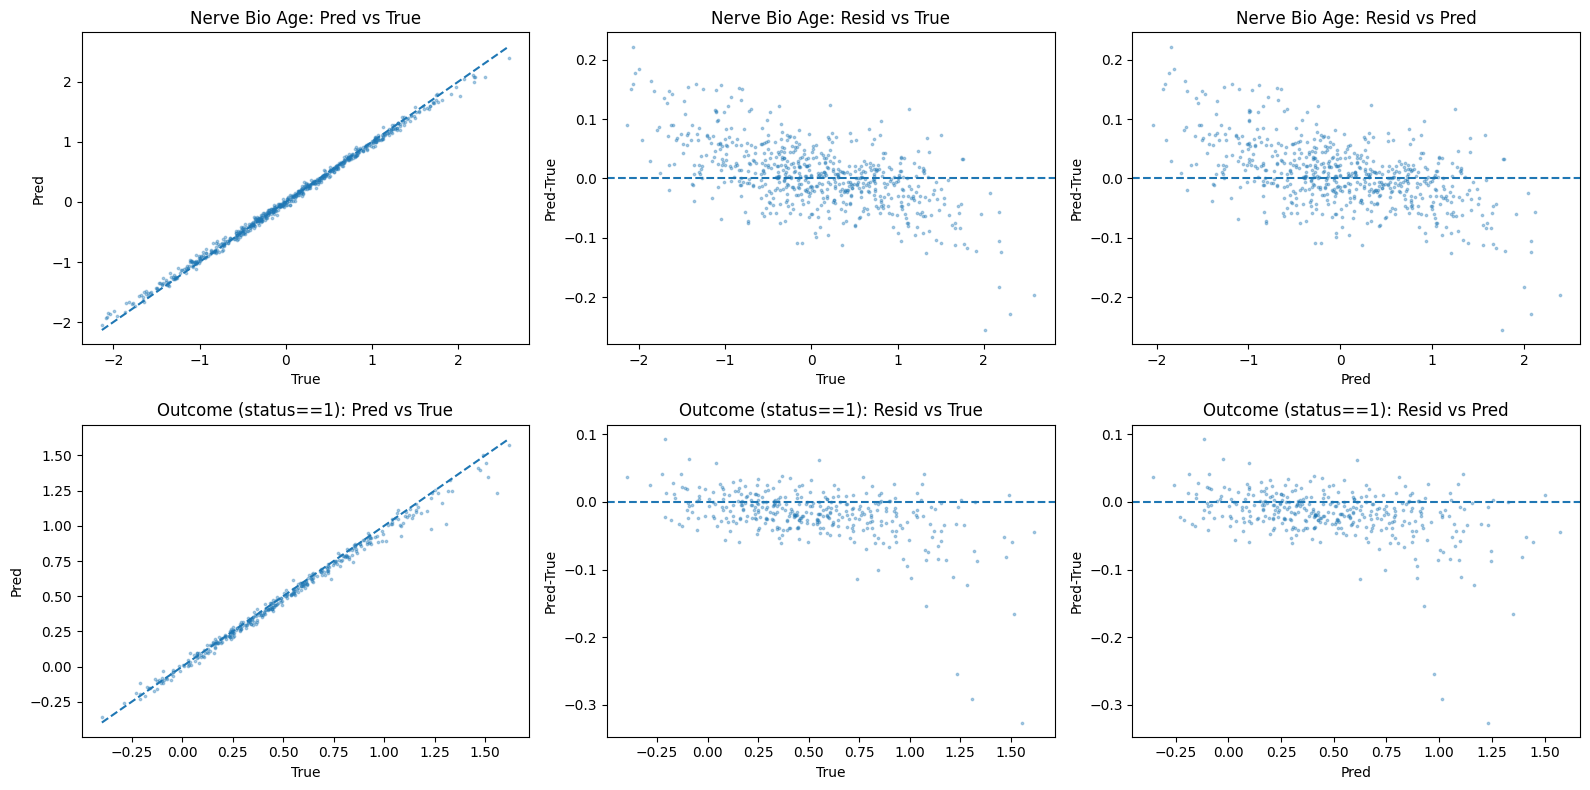

Saved:
 - /content/drive/MyDrive/codex_ai_eval/regression/agreement_regression.csv
 - /content/drive/MyDrive/codex_ai_eval/regression/parity_regression.csv
 - /content/drive/MyDrive/codex_ai_eval/regression/agreement_regression.png
 - /content/drive/MyDrive/codex_ai_eval/regression/agreement_regression.json


In [ ]:
DATA_PATH = Path("/content/drive/MyDrive/SAMPLE_HUMAN_TEST.csv")
BEST_CKPT = Path("/content/drive/MyDrive/production_best(0.1V).pt")
OUT_DIR = Path("/content/drive/MyDrive/codex_ai_eval/regression")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_AGREE = OUT_DIR / "agreement_regression.csv"
CSV_PARITY = OUT_DIR / "parity_regression.csv"
JSON_OUT = OUT_DIR / "agreement_regression.json"
PNG_OUT = OUT_DIR / "agreement_regression.png"

SHOW_PLOTS = True
STATUS_COL = "status"
COVARIATE_COLS = ["sex", "ethnicity"]

if "HybridDPNModel" not in globals():
    raise RuntimeError("HybridDPNModel not found. Run your model-definition cell(s) first.")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing: {DATA_PATH}")
if not BEST_CKPT.exists():
    raise FileNotFoundError(f"Missing best ckpt: {BEST_CKPT}")

def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    tmp.replace(path)


def _state_dict(ckpt_obj: Any) -> Dict[str, torch.Tensor]:
    if isinstance(ckpt_obj, dict) and "model" in ckpt_obj and isinstance(ckpt_obj["model"], dict):
        return ckpt_obj["model"]
    if isinstance(ckpt_obj, dict) and all(isinstance(v, torch.Tensor) for v in ckpt_obj.values()):
        return ckpt_obj
    raise TypeError("Checkpoint must be dict with key 'model' or raw state_dict.")


def _get_cfg_num_cols(ckpt_obj: Any) -> Optional[List[str]]:
    if not isinstance(ckpt_obj, dict):
        return None
    cfg = ckpt_obj.get("config")
    if not isinstance(cfg, dict):
        return None
    for k in ("numerical_cols", "NUMERICAL_FEATURES", "numerical_features", "num_cols", "x_num_cols"):
        v = cfg.get(k)
        if isinstance(v, list) and all(isinstance(s, str) for s in v):
            return v
    return None


def _infer_num_cat_list_from_state(sd: Dict[str, torch.Tensor], n_cat: int) -> Tuple[List[int], List[int]]:
    num_cat_list: List[int] = []
    safe_max_code: List[int] = []
    for i in range(n_cat):
        w = sd.get(f"cov_emb.emb.{i}.weight")
        if not (isinstance(w, torch.Tensor) and w.ndim == 2):
            num_cat_list.append(2)
            safe_max_code.append(0)
            continue
        n = max(1, int(w.shape[0]) - 1)
        num_cat_list.append(n)
        safe_max_code.append(max(-1, n - 1))
    return num_cat_list, safe_max_code


def _filter_state_for_model(model: torch.nn.Module, sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    ms = model.state_dict()
    out: Dict[str, torch.Tensor] = {}
    for k, v in sd.items():
        if k in ms and isinstance(v, torch.Tensor) and v.shape == ms[k].shape:
            out[k] = v
    return out

def _agreement_summary(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    n = int(y_true.shape[0])
    if n == 0:
        return {
            "n": 0,
            "bias_mean_error": float("nan"),
            "mae": float("nan"),
            "rmse": float("nan"),
            "abs_error_p50": float("nan"),
            "abs_error_p90": float("nan"),
            "abs_error_p95": float("nan"),
        }
    err = (y_pred - y_true).astype(np.float64, copy=False)
    abs_err = np.abs(err)
    q = np.quantile(abs_err, [0.5, 0.9, 0.95])
    mae = float(abs_err.mean())
    rmse = float(np.sqrt(np.mean(err * err)))
    return {
        "n": n,
        "bias_mean_error": float(err.mean()),
        "mae": mae,
        "rmse": rmse,
        "abs_error_p50": float(q[0]),
        "abs_error_p90": float(q[1]),
        "abs_error_p95": float(q[2]),
    }


def _plots_2x3(y_true_a: np.ndarray, y_pred_a: np.ndarray, name_a: str,
              y_true_b: np.ndarray, y_pred_b: np.ndarray, name_b: str) -> None:
    def _row(axs, yt, yp, title_prefix):
        if yt.size == 0:
            for ax in axs:
                ax.axis("off")
            axs[0].set_title(f"{title_prefix} (empty)")
            return
        err = yp - yt

        axs[0].scatter(yt, yp, s=3, alpha=0.35)
        lo = float(min(yt.min(), yp.min()))
        hi = float(max(yt.max(), yp.max()))
        axs[0].plot([lo, hi], [lo, hi], linestyle="--")
        axs[0].set_xlabel("True"); axs[0].set_ylabel("Pred")
        axs[0].set_title(f"{title_prefix}: Pred vs True")

        axs[1].scatter(yt, err, s=3, alpha=0.35)
        axs[1].axhline(0.0, linestyle="--")
        axs[1].set_xlabel("True"); axs[1].set_ylabel("Pred-True")
        axs[1].set_title(f"{title_prefix}: Resid vs True")

        axs[2].scatter(yp, err, s=3, alpha=0.35)
        axs[2].axhline(0.0, linestyle="--")
        axs[2].set_xlabel("Pred"); axs[2].set_ylabel("Pred-True")
        axs[2].set_title(f"{title_prefix}: Resid vs Pred")

    fig, ax = plt.subplots(2, 3, figsize=(16, 8))
    _row(ax[0], y_true_a, y_pred_a, name_a)
    _row(ax[1], y_true_b, y_pred_b, name_b)
    plt.tight_layout()
    plt.savefig(PNG_OUT, dpi=220)
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

@torch.no_grad()
def _forward_preds(
    model: torch.nn.Module,
    x_num: torch.Tensor,
    x_cat: torch.Tensor,
    *,
    bs: int = 4096
) -> Tuple[np.ndarray, np.ndarray]:
    n = int(x_num.shape[0])
    out_age: List[np.ndarray] = []
    out_out: List[np.ndarray] = []
    model.eval()
    for i in range(0, n, bs):
        xb_num = x_num[i:i+bs]
        xb_cat = x_cat[i:i+bs]
        out = model(xb_num, xb_cat)
        if not isinstance(out, dict):
            if hasattr(out, "_asdict"):
                out = dict(out._asdict())
            else:
                raise TypeError("Model forward must return dict.")
        a = out.get("nerve_bio_age", None)
        o = out.get("pred_outcome", None)
        if not isinstance(a, torch.Tensor) or not isinstance(o, torch.Tensor):
            raise KeyError(f"Missing regression keys in output. keys={list(out.keys())}")
        out_age.append(a.squeeze(-1).reshape(-1).detach().cpu().numpy().astype(np.float32, copy=False))
        out_out.append(o.squeeze(-1).reshape(-1).detach().cpu().numpy().astype(np.float32, copy=False))
    return np.concatenate(out_age, axis=0), np.concatenate(out_out, axis=0)


@torch.no_grad()
def _pseudo_targets_fallback(x_num: torch.Tensor, status: torch.Tensor, meta_idx: torch.Tensor, emg_idx: torch.Tensor) -> Tuple[np.ndarray, np.ndarray]:

    meta = x_num.index_select(1, meta_idx)
    emg  = x_num.index_select(1, emg_idx)

    def get_col_safe(tensor, col_idx, default_val_like):
        if tensor.size(1) > col_idx:
            return tensor[:, col_idx]
        return torch.zeros_like(default_val_like)

    age = get_col_safe(meta, 0, x_num[:, 0]).clamp(-4.0, 4.0)
    dpn_dur = get_col_safe(meta, 2, age)
    pain = get_col_safe(meta, 3, age)
    tnf = get_col_safe(meta, 4, age)
    mda = get_col_safe(meta, 5, age)

    mune = get_col_safe(emg, 0, x_num[:, 0])
    mui  = get_col_safe(emg, 1, mune)
    muap = get_col_safe(emg, 2, mune)
    rms  = get_col_safe(emg, 3, mune)
    medf = get_col_safe(emg, 4, mune)

    emg_damage = (-mune - mui + muap + rms - medf) / 5.0
    nerve_age = (age + 0.35 * emg_damage + 0.15 * dpn_dur).clamp(-6.0, 6.0)
    outcome   = (0.45 * emg_damage + 0.25 * tnf + 0.20 * mda + 0.10 * dpn_dur).clamp(-6.0, 6.0)

    return (
        nerve_age.detach().cpu().numpy().astype(np.float32, copy=False),
        outcome.detach().cpu().numpy().astype(np.float32, copy=False),
    )

def _find_col_ci(df_: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    m = {c.lower(): c for c in df_.columns}
    for c in candidates:
        if c.lower() in m:
            return m[c.lower()]
    return None

def _parity_table(y_true: np.ndarray, y_pred: np.ndarray, groups: np.ndarray, group_name: str, head: str) -> pd.DataFrame:
    rows = []
    uniq = np.unique(groups.astype(np.int64, copy=False))
    for g in uniq:
        m = (groups == g) & np.isfinite(y_true) & np.isfinite(y_pred)
        yt = y_true[m].astype(np.float32, copy=False)
        yp = y_pred[m].astype(np.float32, copy=False)
        s = _agreement_summary(yt, yp)
        rows.append({"head": head, "group_col": group_name, "group": int(g), **s})
    return pd.DataFrame(rows)

df = pd.read_csv(DATA_PATH, encoding="utf-8")
need_base = [STATUS_COL] + COVARIATE_COLS
miss = [c for c in need_base if c not in df.columns]
if miss:
    raise ValueError(f"DPN_test.csv missing cols: {miss}")

df[STATUS_COL] = pd.to_numeric(df[STATUS_COL], errors="coerce").fillna(0).astype(np.int64)
for c in COVARIATE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.int64)

ckpt_obj = torch.load(str(BEST_CKPT), map_location="cpu")
sd = _state_dict(ckpt_obj)

cfg_cols = _get_cfg_num_cols(ckpt_obj)
if cfg_cols is not None:
    NUM_COLS = list(cfg_cols)
elif "NUMERICAL_FEATURES" in globals() and isinstance(globals()["NUMERICAL_FEATURES"], (list, tuple)):
    NUM_COLS = list(globals()["NUMERICAL_FEATURES"])
else:
    NUM_COLS = [
        "age_years", "diabetes_duration_years", "dpn_duration_years",
        "pain_score_0_10", "TNF_alpha_pg_ml", "MDA_umol_L",
        "EMG_MUNE", "EMG_MUI", "EMG_MUAP_I", "EMG_RMS_mean", "EMG_median_frequency",
    ]

for c in NUM_COLS:
    if c not in df.columns:
        df[c] = 0.0
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_cat_list, safe_max_code = _infer_num_cat_list_from_state(sd, n_cat=len(COVARIATE_COLS))
for i, c in enumerate(COVARIATE_COLS):
    df[c] = df[c].clip(lower=-1, upper=safe_max_code[i]).astype(np.int64)

x_num = torch.tensor(df[NUM_COLS].to_numpy(dtype=np.float32, copy=False), dtype=torch.float32, device=device)
x_cat = torch.tensor(df[COVARIATE_COLS].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)
status = torch.tensor(df[STATUS_COL].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)
status_np = status.detach().cpu().numpy().astype(np.int64, copy=False)

model = HybridDPNModel(numerical_cols=NUM_COLS, categorical_cols=COVARIATE_COLS, num_cat_list=num_cat_list).to(device)

load_mode = "strict"
try:
    model.load_state_dict(sd, strict=True)
except Exception:
    load_mode = "filtered_strictFalse"
    filt = _filter_state_for_model(model, sd)
    model.load_state_dict(filt, strict=False)
model.eval()

pred_age, pred_out = _forward_preds(model, x_num, x_cat)

Y_AGE_CANDS = ["nerve_bio_age", "nerve_age", "bio_age", "nerve_age_target", "y_nerve_age", "nerve_age_years"]
Y_OUT_CANDS = ["outcome", "y_outcome", "outcome_target", "dpn_outcome", "clinical_outcome"]

col_age = _find_col_ci(df, Y_AGE_CANDS)
col_out = _find_col_ci(df, Y_OUT_CANDS)

y_age = None
y_out = None
src_age = "missing"
src_out = "missing"

# Initialize y_age and y_out as NumPy arrays containing NaNs if columns are not found
# This ensures they are never None at the final assert.
initial_y_age = np.full((len(df),), np.nan, dtype=np.float32)
initial_y_out = np.full((len(df),), np.nan, dtype=np.float32)

if col_age is not None:
    initial_y_age = pd.to_numeric(df[col_age], errors="coerce").replace([np.inf, -np.inf], np.nan).to_numpy(dtype=np.float32, copy=False)
    src_age = "DPN_test"
if col_out is not None:
    initial_y_out = pd.to_numeric(df[col_out], errors="coerce").replace([np.inf, -np.inf], np.nan).to_numpy(dtype=np.float32, copy=False)
    src_out = "DPN_test"

y_age = initial_y_age
y_out = initial_y_out

need_pseudo = (not np.isfinite(y_age).any()) or (not np.isfinite(y_out).any())

if need_pseudo:
    pseudo_ok = False
    try:
        if hasattr(model, "meta_idx") and hasattr(model, "emg_idx"):
            meta_idx = model.meta_idx
            emg_idx = model.emg_idx
            if not isinstance(meta_idx, torch.Tensor):
                meta_idx = torch.tensor(meta_idx, dtype=torch.long, device=device)
            else:
                meta_idx = meta_idx.to(device)
            if not isinstance(emg_idx, torch.Tensor):
                emg_idx = torch.tensor(emg_idx, dtype=torch.long, device=device)
            else:
                emg_idx = emg_idx.to(device)
        else:

            META_COLS = ["age_years","diabetes_duration_years","dpn_duration_years","pain_score_0_10","TNF_alpha_pg_ml","MDA_umol_L"]
            EMG_COLS  = ["EMG_MUNE","EMG_MUI","EMG_MUAP_I","EMG_RMS_mean","EMG_median_frequency"]
            meta_idx = torch.tensor([NUM_COLS.index(c) for c in META_COLS if c in NUM_COLS], dtype=torch.long, device=device)
            emg_idx  = torch.tensor([NUM_COLS.index(c) for c in EMG_COLS  if c in NUM_COLS], dtype=torch.long, device=device)

        if "PseudoTargetGenerator" in globals():
            if "PseudoTargetConfig" in globals():
                cfg = PseudoTargetConfig()
                try:
                    gen = PseudoTargetGenerator(meta_idx=meta_idx, emg_idx=emg_idx, cfg=cfg)
                except Exception:
                    gen = PseudoTargetGenerator(meta_idx=meta_idx, emg_idx=emg_idx)
            else:
                gen = PseudoTargetGenerator(meta_idx=meta_idx, emg_idx=emg_idx)
            if isinstance(ckpt_obj, dict) and isinstance(ckpt_obj.get("pseudo_state"), dict) and hasattr(gen, "load_state_dict"):
                try:
                    gen.load_state_dict(ckpt_obj["pseudo_state"])
                except Exception:
                    pass
            with torch.no_grad():
                pseudo = gen.generate(x_num, status)

            if isinstance(pseudo, dict):
                if "nerve_age" in pseudo and isinstance(pseudo["nerve_age"], torch.Tensor):
                    temp_y_age = pseudo["nerve_age"].squeeze(-1).detach().cpu().numpy().astype(np.float32, copy=False)
                    if np.isfinite(temp_y_age).any(): # Only update if pseudo_gen provided finite values
                        y_age = temp_y_age
                        src_age = "pseudo_gen"
                if "outcome" in pseudo and isinstance(pseudo["outcome"], torch.Tensor):
                    temp_y_out = pseudo["outcome"].squeeze(-1).detach().cpu().numpy().astype(np.float32, copy=False)
                    if np.isfinite(temp_y_out).any(): # Only update if pseudo_gen provided finite values
                        y_out = temp_y_out
                        src_out = "pseudo_gen"
            pseudo_ok = np.isfinite(y_age).any() and np.isfinite(y_out).any()
    except Exception:
        pseudo_ok = False

    if not pseudo_ok:
        META_COLS = ["age_years","diabetes_duration_years","dpn_duration_years","pain_score_0_10","TNF_alpha_pg_ml","MDA_umol_L"]
        EMG_COLS  = ["EMG_MUNE","EMG_MUI","EMG_MUAP_I","EMG_RMS_mean","EMG_median_frequency"]

        # Filter META_COLS and EMG_COLS to only include those present in NUM_COLS
        actual_meta_cols = [c for c in META_COLS if c in NUM_COLS]
        actual_emg_cols = [c for c in EMG_COLS if c in NUM_COLS]

        # Proceed with fallback only if essential columns are available for indexing
        if not actual_meta_cols or not actual_emg_cols:
            # If essential columns are missing, fallback might produce all NaNs
            fy_age = np.full((len(df),), np.nan, dtype=np.float32)
            fy_out = np.full((len(df),), np.nan, dtype=np.float32)
        else:
            # Ensure meta_idx and emg_idx are valid even if some columns are missing
            meta_idx = torch.tensor([NUM_COLS.index(c) for c in actual_meta_cols], dtype=torch.long, device=device)
            emg_idx  = torch.tensor([NUM_COLS.index(c) for c in actual_emg_cols], dtype=torch.long, device=device)
            fy_age, fy_out = _pseudo_targets_fallback(x_num, status, meta_idx, emg_idx)

        # Always assign fallback if current y_age/y_out are not finite
        if not np.isfinite(y_age).any():
            y_age = fy_age
            src_age = "pseudo_fallback"
        if not np.isfinite(y_out).any():
            y_out = fy_out
            src_out = "pseudo_fallback"

# The assert will now pass because y_age and y_out are guaranteed to be NumPy arrays
# (potentially full of NaNs if no valid data source was found). The downstream checks for np.isfinite will handle NaNs.
assert y_age is not None and y_out is not None

m_age = np.isfinite(y_age) & np.isfinite(pred_age)
age_true = y_age[m_age].astype(np.float32, copy=False)
age_pred = pred_age[m_age].astype(np.float32, copy=False)

m_out = np.isfinite(y_out) & np.isfinite(pred_out) & (status_np == 1)
out_true = y_out[m_out].astype(np.float32, copy=False)
out_pred = pred_out[m_out].astype(np.float32, copy=False)

df_agree = pd.DataFrame(
    [
        {"head": "nerve_bio_age", **_agreement_summary(age_true, age_pred), "target_source": src_age},
        {"head": "outcome(status==1)", **_agreement_summary(out_true, out_pred), "target_source": src_out},
    ]
)

display(df_agree)
parity_parts = []

sex = df["sex"].to_numpy(dtype=np.int64, copy=False)
eth = df["ethnicity"].to_numpy(dtype=np.int64, copy=False)

parity_parts.append(_parity_table(y_age, pred_age, sex, "sex", "nerve_bio_age"))
parity_parts.append(_parity_table(y_age, pred_age, eth, "ethnicity", "nerve_bio_age"))

y_out_masked = np.full_like(y_out, np.nan, dtype=np.float32)
p_out_masked = np.full_like(pred_out, np.nan, dtype=np.float32)
y_out_masked[status_np == 1] = y_out[status_np == 1]
p_out_masked[status_np == 1] = pred_out[status_np == 1]

parity_parts.append(_parity_table(y_out_masked, p_out_masked, sex, "sex", "outcome(status==1)"))
parity_parts.append(_parity_table(y_out_masked, p_out_masked, eth, "ethnicity", "outcome(status==1)"))

df_parity = pd.concat(parity_parts, ignore_index=True)
display(df_parity.head(30))

_plots_2x3(age_true, age_pred, "Nerve Bio Age", out_true, out_pred, "Outcome (status==1)")

df_agree.to_csv(CSV_AGREE, index=False)
df_parity.to_csv(CSV_PARITY, index=False)
_atomic_write_json(
    JSON_OUT,
    {
        "paths": {"data": str(DATA_PATH), "best_ckpt": str(BEST_CKPT)},
        "device": str(device),
        "load_mode": load_mode,
        "numerical_cols_used": NUM_COLS,
        "categorical_cols_used": COVARIATE_COLS,
        "num_cat_list_used": num_cat_list,
        "agreement_table": df_agree.to_dict(orient="records"),
        "parity_table_head": "saved to CSV_PARITY",
        "outputs": {"agreement_csv": str(CSV_AGREE), "parity_csv": str(CSV_PARITY), "png": str(PNG_OUT), "json": str(JSON_OUT)},
    },
)

print("Saved:")
print(" -", CSV_AGREE)
print(" -", CSV_PARITY)
print(" -", PNG_OUT)
print(" -", JSON_OUT)

**Uncertainty**

In [ ]:
DATA_PATH = Path("/content/drive/MyDrive/DPN_test.csv")
CKPT = Path("/content/drive/MyDrive/production_best(0.1V).pt")
OUT_DIR = Path("/content/drive/MyDrive/codex_ai_eval/uncertainty")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT_DIR / "uncertainty_mc_dropout.csv"
JSON_OUT = OUT_DIR / "uncertainty_mc_dropout.json"

SEED = 1337
MC_SAMPLES = 50
PI_LO = 5.0
PI_HI = 95.0

STATUS_COL = "status"
COVARIATE_COLS = ["sex", "ethnicity"]

if "HybridDPNModel" not in globals():
    raise RuntimeError("HybridDPNModel not found. Run model-definition cell(s) first.")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing: {DATA_PATH}")
if not CKPT.exists():
    raise FileNotFoundError(f"Missing ckpt: {CKPT}")

def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _state_dict(ckpt_obj: Any) -> Dict[str, torch.Tensor]:
    if isinstance(ckpt_obj, dict) and "model" in ckpt_obj and isinstance(ckpt_obj["model"], dict):
        return ckpt_obj["model"]
    if isinstance(ckpt_obj, dict) and all(isinstance(v, torch.Tensor) for v in ckpt_obj.values()):
        return ckpt_obj
    raise TypeError("Checkpoint must be dict with key 'model' or raw state_dict.")


def _get_cfg_num_cols(ckpt_obj: Any) -> Optional[List[str]]:
    if not isinstance(ckpt_obj, dict):
        return None
    cfg = ckpt_obj.get("config")
    if not isinstance(cfg, dict):
        return None
    for k in ("numerical_cols", "NUMERICAL_FEATURES", "numerical_features", "num_cols", "x_num_cols"):
        v = cfg.get(k)
        if isinstance(v, list) and all(isinstance(s, str) for s in v):
            return v
    return None


def _infer_num_cat_list_from_state(sd: Dict[str, torch.Tensor], n_cat: int) -> Tuple[List[int], List[int]]:
    num_cat_list: List[int] = []
    safe_max_code: List[int] = []
    for i in range(n_cat):
        w = sd.get(f"cov_emb.emb.{i}.weight")
        if not (isinstance(w, torch.Tensor) and w.ndim == 2):
            num_cat_list.append(2)
            safe_max_code.append(0)
            continue
        n = max(1, int(w.shape[0]) - 1)  # Embedding(n+1)
        num_cat_list.append(n)
        safe_max_code.append(max(-1, n - 1))
    return num_cat_list, safe_max_code


def _filter_state_for_model(model: torch.nn.Module, sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    ms = model.state_dict()
    out: Dict[str, torch.Tensor] = {}
    for k, v in sd.items():
        if k in ms and isinstance(v, torch.Tensor) and v.shape == ms[k].shape:
            out[k] = v
    return out


def _ensure_cols(df: pd.DataFrame, cols: List[str], default: Any) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = default
    return out


def _as_1d(t: torch.Tensor) -> torch.Tensor:
    return t.squeeze(-1).reshape(-1)


def _pick_regression(out: Dict[str, torch.Tensor], candidates: List[str]) -> torch.Tensor:
    for k in candidates:
        v = out.get(k)
        if isinstance(v, torch.Tensor):
            return v
    lower = {str(k).lower(): k for k in out.keys()}
    for k in candidates:
        kk = k.lower()
        if kk in lower and isinstance(out[lower[kk]], torch.Tensor):
            return out[lower[kk]]
    raise KeyError(f"Missing head. candidates={candidates}. keys={list(out.keys())}")


def _enable_dropout_only(m: nn.Module) -> None:
    m.eval()
    for mod in m.modules():
        if isinstance(mod, (nn.Dropout, nn.Dropout1d, nn.Dropout2d, nn.Dropout3d, nn.AlphaDropout)):
            mod.train()


@torch.no_grad()
def _mc_samples(model: torch.nn.Module, x_num: torch.Tensor, x_cat: torch.Tensor, head_candidates: List[str], T: int, seed: int) -> np.ndarray:
    preds: List[np.ndarray] = []
    for t in range(T):
        _set_seed(seed + 10_000 + t)
        _enable_dropout_only(model)
        out = model(x_num, x_cat)
        if not isinstance(out, dict):
            if hasattr(out, "_asdict"):
                out = dict(out._asdict())
            else:
                raise TypeError("Model output must be dict-like")
        y = _pick_regression(out, head_candidates)
        preds.append(_as_1d(y).detach().cpu().numpy().astype(np.float64, copy=False))
    model.eval()
    return np.stack(preds, axis=0)  # [T, N]


def _pi_stats(samples: np.ndarray, lo: float, hi: float, y_true: Optional[np.ndarray], mask: Optional[np.ndarray]) -> Dict[str, float]:
    mean = samples.mean(axis=0)
    var = samples.var(axis=0, ddof=1) if samples.shape[0] > 1 else np.zeros_like(mean)
    q_lo = np.percentile(samples, lo, axis=0)
    q_hi = np.percentile(samples, hi, axis=0)
    width = q_hi - q_lo

    out: Dict[str, float] = {
        "predictive_mean_mean": float(np.mean(mean)) if mean.size else float("nan"),
        "predictive_variance_mean": float(np.mean(var)) if var.size else float("nan"),
        "pi_lo_mean": float(np.mean(q_lo)) if q_lo.size else float("nan"),
        "pi_hi_mean": float(np.mean(q_hi)) if q_hi.size else float("nan"),
        "mpiw": float(np.mean(width)) if width.size else float("nan"),
        "picp": float("nan"),
    }

    if y_true is None or mask is None:
        return out

    m = mask.astype(bool)
    if m.sum() == 0:
        return out

    yt = y_true[m]
    covered = (yt >= q_lo[m]) & (yt <= q_hi[m])
    out["picp"] = float(np.mean(covered)) if covered.size else float("nan")
    return out


@torch.no_grad()
def _pseudo_fallback(x_num: torch.Tensor, status: torch.Tensor, meta_idx: torch.Tensor, emg_idx: torch.Tensor) -> Tuple[np.ndarray, np.ndarray]:
    meta = x_num.index_select(1, meta_idx)
    emg  = x_num.index_select(1, emg_idx)

    age = meta[:, 0].clamp(-4.0, 4.0)
    dpn_dur = meta[:, 2] if meta.size(1) > 2 else torch.zeros_like(age)
    tnf = meta[:, 4] if meta.size(1) > 4 else torch.zeros_like(age)
    mda = meta[:, 5] if meta.size(1) > 5 else torch.zeros_like(age)

    mune = emg[:, 0]
    mui  = emg[:, 1] if emg.size(1) > 1 else torch.zeros_like(mune)
    muap = emg[:, 2] if emg.size(1) > 2 else torch.zeros_like(mune)
    rms  = emg[:, 3] if emg.size(1) > 3 else torch.zeros_like(mune)
    medf = emg[:, 4] if emg.size(1) > 4 else torch.zeros_like(mune)

    emg_damage = (-mune - mui + muap + rms - medf) / 5.0
    nerve_age = (age + 0.35 * emg_damage + 0.15 * dpn_dur).clamp(-6.0, 6.0)
    outcome   = (0.45 * emg_damage + 0.25 * tnf + 0.20 * mda + 0.10 * dpn_dur).clamp(-6.0, 6.0)

    return (
        nerve_age.detach().cpu().numpy().astype(np.float64, copy=False),
        outcome.detach().cpu().numpy().astype(np.float64, copy=False),
    )


def _find_col_ci(df_: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    m = {c.lower(): c for c in df_.columns}
    for c in candidates:
        if c.lower() in m:
            return m[c.lower()]
    return None


df = pd.read_csv(DATA_PATH, encoding="utf-8")
need = [STATUS_COL] + COVARIATE_COLS
miss = [c for c in need if c not in df.columns]
if miss:
    raise ValueError(f"DPN_test.csv missing cols: {miss}")

df[STATUS_COL] = pd.to_numeric(df[STATUS_COL], errors="coerce").fillna(0).astype(np.int64)
for c in COVARIATE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.int64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_obj = torch.load(str(CKPT), map_location="cpu")
sd = _state_dict(ckpt_obj)

cfg_cols = _get_cfg_num_cols(ckpt_obj)
if cfg_cols is not None:
    NUM_COLS = list(cfg_cols)
elif "NUMERICAL_FEATURES" in globals() and isinstance(globals()["NUMERICAL_FEATURES"], (list, tuple)):
    NUM_COLS = list(globals()["NUMERICAL_FEATURES"])
else:
    NUM_COLS = [
        "age_years", "diabetes_duration_years", "dpn_duration_years",
        "pain_score_0_10", "TNF_alpha_pg_ml", "MDA_umol_L",
        "EMG_MUNE", "EMG_MUI", "EMG_MUAP_I", "EMG_RMS_mean", "EMG_median_frequency",
    ]

df = _ensure_cols(df, NUM_COLS, 0.0)
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)

num_cat_list, safe_max_code = _infer_num_cat_list_from_state(sd, n_cat=len(COVARIATE_COLS))
for i, c in enumerate(COVARIATE_COLS):
    df[c] = df[c].clip(lower=-1, upper=safe_max_code[i]).astype(np.int64)

x_num = torch.tensor(df[NUM_COLS].to_numpy(dtype=np.float32, copy=False), dtype=torch.float32, device=device)
x_cat = torch.tensor(df[COVARIATE_COLS].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)
status = torch.tensor(df[STATUS_COL].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)
status_np = status.detach().cpu().numpy().astype(np.int64, copy=False)

model = HybridDPNModel(numerical_cols=NUM_COLS, categorical_cols=COVARIATE_COLS, num_cat_list=num_cat_list).to(device)
load_mode = "strict"
try:
    model.load_state_dict(sd, strict=True)
except Exception:
    load_mode = "filtered_strictFalse"
    model.load_state_dict(_filter_state_for_model(model, sd), strict=False)
model.eval()

AGE_CANDS = ["nerve_bio_age", "nerve_age", "bio_age", "nerve_age_target", "y_nerve_age", "nerve_age_years"]
OUT_CANDS = ["outcome", "y_outcome", "outcome_target", "dpn_outcome", "clinical_outcome"]

y_age = None
y_out = None
src_age = "missing"
src_out = "missing"

c_age = _find_col_ci(df, AGE_CANDS)
c_out = _find_col_ci(df, OUT_CANDS)
if c_age is not None:
    y_age = pd.to_numeric(df[c_age], errors="coerce").replace([np.inf, -np.inf], np.nan).to_numpy(dtype=np.float64, copy=False)
    src_age = "DPN_test"
if c_out is not None:
    y_out = pd.to_numeric(df[c_out], errors="coerce").replace([np.inf, -np.inf], np.nan).to_numpy(dtype=np.float64, copy=False)
    src_out = "DPN_test"

need_pseudo = (y_age is None or not np.isfinite(y_age).any()) or (y_out is None or not np.isfinite(y_out).any())
if need_pseudo:
    pseudo_ok = False
    try:
        if "PseudoTargetGenerator" in globals():
            if hasattr(model, "meta_idx") and hasattr(model, "emg_idx"):
                meta_idx = model.meta_idx.to(device) if isinstance(model.meta_idx, torch.Tensor) else torch.tensor(model.meta_idx, dtype=torch.long, device=device)
                emg_idx  = model.emg_idx.to(device)  if isinstance(model.emg_idx, torch.Tensor)  else torch.tensor(model.emg_idx, dtype=torch.long, device=device)
            else:
                META_COLS = ["age_years","diabetes_duration_years","dpn_duration_years","pain_score_0_10","TNF_alpha_pg_ml","MDA_umol_L"]
                EMG_COLS  = ["EMG_MUNE","EMG_MUI","EMG_MUAP_I","EMG_RMS_mean","EMG_median_frequency"]
                meta_idx = torch.tensor([NUM_COLS.index(c) for c in META_COLS if c in NUM_COLS], dtype=torch.long, device=device)
                emg_idx  = torch.tensor([NUM_COLS.index(c) for c in EMG_COLS  if c in NUM_COLS], dtype=torch.long, device=device)

            if "PseudoTargetConfig" in globals():
                cfg = PseudoTargetConfig()
                try:
                    gen = PseudoTargetGenerator(meta_idx=meta_idx, emg_idx=emg_idx, cfg=cfg)
                except Exception:
                    gen = PseudoTargetGenerator(meta_idx=meta_idx, emg_idx=emg_idx)
            else:
                gen = PseudoTargetGenerator(meta_idx=meta_idx, emg_idx=emg_idx)

            if isinstance(ckpt_obj, dict) and isinstance(ckpt_obj.get("pseudo_state"), dict) and hasattr(gen, "load_state_dict"):
                try:
                    gen.load_state_dict(ckpt_obj["pseudo_state"])
                except Exception:
                    pass

            with torch.no_grad():
                pseudo = gen.generate(x_num, status)

            if isinstance(pseudo, dict):
                if y_age is None or not np.isfinite(y_age).any():
                    if "nerve_age" in pseudo and isinstance(pseudo["nerve_age"], torch.Tensor):
                        y_age = _as_1d(pseudo["nerve_age"]).detach().cpu().numpy().astype(np.float64, copy=False)
                        src_age = "pseudo_gen"
                if y_out is None or not np.isfinite(y_out).any():
                    if "outcome" in pseudo and isinstance(pseudo["outcome"], torch.Tensor):
                        y_out = _as_1d(pseudo["outcome"]).detach().cpu().numpy().astype(np.float64, copy=False)
                        src_out = "pseudo_gen"

            pseudo_ok = (y_age is not None and np.isfinite(y_age).any()) and (y_out is not None and np.isfinite(y_out).any())
    except Exception:
        pseudo_ok = False

    if not pseudo_ok:
        META_COLS = ["age_years","diabetes_duration_years","dpn_duration_years","pain_score_0_10","TNF_alpha_pg_ml","MDA_umol_L"]
        EMG_COLS  = ["EMG_MUNE","EMG_MUI","EMG_MUAP_I","EMG_RMS_mean","EMG_median_frequency"]
        meta_idx = torch.tensor([NUM_COLS.index(c) for c in META_COLS if c in NUM_COLS], dtype=torch.long, device=device)
        emg_idx  = torch.tensor([NUM_COLS.index(c) for c in EMG_COLS  if c in NUM_COLS], dtype=torch.long, device=device)
        fy_age, fy_out = _pseudo_fallback(x_num, status, meta_idx, emg_idx)
        if y_age is None or not np.isfinite(y_age).any():
            y_age = fy_age
            src_age = "pseudo_fallback"
        if y_out is None or not np.isfinite(y_out).any():
            y_out = fy_out
            src_out = "pseudo_fallback"

assert y_age is not None and y_out is not None

valid_age = np.isfinite(y_age)
valid_out = np.isfinite(y_out) & (status_np == 1)

_set_seed(SEED)

with torch.no_grad():
    probe = model(x_num[:1], x_cat[:1])
if not isinstance(probe, dict) and hasattr(probe, "_asdict"):
    probe = dict(probe._asdict())
if not isinstance(probe, dict):
    raise TypeError("Model output must be dict-like")

available = sorted([k for k, v in probe.items() if isinstance(v, torch.Tensor)])

heads = [
    ("nerve_bio_age", ["nerve_bio_age", "pred_nerve_bio_age", "nerve_age", "nerve_bio_age_pred"], y_age, valid_age, src_age),
    ("pred_outcome",  ["pred_outcome", "outcome", "outcome_pred", "y_outcome_pred"], y_out, valid_out, src_out),
]

rows: List[Dict[str, Any]] = []
for head_name, cand, y_true, vmask, src in heads:
    try:
        _pick_regression(probe, cand)
    except Exception:
        continue

    samples = _mc_samples(model, x_num, x_cat, cand, T=MC_SAMPLES, seed=SEED)  # [T, N]
    stats = _pi_stats(samples, PI_LO, PI_HI, y_true, vmask)

    rows.append(
        {
            "head": head_name,
            "target_source": src,
            "n_total": int(samples.shape[1]),
            "n_valid": int(np.sum(vmask)),
            "predictive_variance_mean": stats["predictive_variance_mean"],
            "mpiw_p5_p95": stats["mpiw"],
            "picp_p5_p95": stats["picp"],
        }
    )

df_uq = pd.DataFrame(rows)
overall = {
    "head": "OVERALL",
    "target_source": "",
    "n_total": int(len(df)),
    "n_valid": int(df_uq["n_valid"].sum()) if not df_uq.empty else 0,
    "predictive_variance_mean": float(pd.to_numeric(df_uq["predictive_variance_mean"], errors="coerce").mean()) if not df_uq.empty else float("nan"),
    "mpiw_p5_p95": float(pd.to_numeric(df_uq["mpiw_p5_p95"], errors="coerce").mean()) if not df_uq.empty else float("nan"),
    "picp_p5_p95": float(pd.to_numeric(df_uq["picp_p5_p95"], errors="coerce").mean()) if not df_uq.empty else float("nan"),
}
df_uq = pd.concat([df_uq, pd.DataFrame([overall])], ignore_index=True)

display(df_uq)

df_uq.to_csv(CSV_OUT, index=False)
_atomic_write_json(
    JSON_OUT,
    {
        "paths": {"data": str(DATA_PATH), "ckpt": str(CKPT)},
        "device": str(device),
        "seed": int(SEED),
        "mc_samples": int(MC_SAMPLES),
        "pi": {"lo": float(PI_LO), "hi": float(PI_HI)},
        "load_mode": load_mode,
        "numerical_cols_used": NUM_COLS,
        "categorical_cols_used": COVARIATE_COLS,
        "num_cat_list_used": num_cat_list,
        "available_output_keys": available,
        "table": df_uq.to_dict(orient="records"),
    },
)

print("Saved:")
print(" -", CSV_OUT)
print(" -", JSON_OUT)

,head,target_source,n_total,n_valid,predictive_variance_mean,mpiw_p5_p95,picp_p5_p95
0,nerve_bio_age,pseudo_fallback,15000,15000,0.006233,0.233523,0.990333
1,pred_outcome,pseudo_fallback,15000,9000,0.002299,0.141266,0.929111
2,OVERALL,,15000,24000,0.004266,0.187395,0.959722


Saved:
 - /content/drive/MyDrive/codex_ai_eval/uncertainty/uncertainty_mc_dropout.csv
 - /content/drive/MyDrive/codex_ai_eval/uncertainty/uncertainty_mc_dropout.json


In [ ]:
V JZ.132q  w3.,0.3 2qqq0.00

#**Step 14: Calibration/Thresholds**

**Classification Calibration**

In [ ]:
 try:
    from IPython.display import display
except Exception:
    display = print

SEED = 42
CALIB_FRAC = 0.2
N_BINS = 15
BOOT = 300
CI_LO, CI_HI = 2.5, 97.5

DATA_PATH = Path("/content/drive/MyDrive/SAMPLE_HUMAN_TEST.csv")
MODEL_PATH = Path("/content/drive/MyDrive/production_best(0.1V).pt")

OUT_DIR = Path("/content/drive/MyDrive/codex_ai_train/reports")
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / "step14_calibration_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CSV_OUT = OUT_DIR / "step14_calibration_axes_ci.csv"
JSON_OUT = OUT_DIR / "step14_calibration_axes_ci.json"

COV_COLS = ["sex", "ethnicity"]
AXIS_SPECS = {
    "axis1": {"title": "Axis1", "n": 2},
    "axis2": {"title": "Axis2", "n": 4},
    "axis3": {"title": "Axis3", "n": 3},
}

def _set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _ensure_cols(df: pd.DataFrame, cols: List[str], default: Any) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = default
    return out


def _to_num(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    return out


def _to_int(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.int64)
    return out


def _load_ckpt(path: Path, device: torch.device) -> Tuple[Dict[str, Any], Dict[str, torch.Tensor]]:
    obj = torch.load(str(path), map_location=device)
    if isinstance(obj, dict) and isinstance(obj.get("model"), dict):
        return obj, obj["model"]
    if isinstance(obj, dict) and all(isinstance(v, torch.Tensor) for v in obj.values()):
        return {"model": obj}, obj
    raise RuntimeError("checkpoint must be dict{model: state_dict} or raw state_dict dict")


def _infer_pv_dim(sd: Dict[str, torch.Tensor]) -> int:
    for k in ("pv_decoder.net.2.weight", "pv_decoder.net.3.weight", "pv_decoder.net.1.weight"):
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 2:
            return int(t.shape[0])
    for k in ("pv_decoder.net.2.bias", "pv_decoder.net.3.bias", "pv_decoder.net.1.bias"):
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 1:
            return int(t.shape[0])
    raise RuntimeError("cannot infer pv_dim from pv_decoder.* in checkpoint")


def _infer_cov_rows(sd: Dict[str, torch.Tensor], n_cov: int) -> List[int]:
    rows: List[int] = []
    for i in range(n_cov):
        k = f"cov_emb.emb.{i}.weight"
        t = sd.get(k)
        if not (isinstance(t, torch.Tensor) and t.ndim == 2):
            raise RuntimeError(f"missing {k}")
        rows.append(int(t.shape[0]))
    return rows


def _get_cfg_num_cols(ckpt: Dict[str, Any]) -> Optional[List[str]]:
    cfg = ckpt.get("config")
    if not isinstance(cfg, dict):
        return None
    for k in ("numerical_cols", "NUMERICAL_FEATURES", "numerical_features", "num_cols", "x_num_cols"):
        v = cfg.get(k)
        if isinstance(v, list) and all(isinstance(s, str) for s in v):
            return v
    return None


def _choose_num_cols(df: pd.DataFrame, ckpt: Dict[str, Any], pv_dim: int) -> List[str]:
    cfg_cols = _get_cfg_num_cols(ckpt)
    if cfg_cols is not None:
        cols = [str(c) for c in cfg_cols][:pv_dim]
        while len(cols) < pv_dim:
            cols.append(f"__pad_{len(cols)}__")
        return cols

    if "NUMERICAL_FEATURES" in globals() and isinstance(globals()["NUMERICAL_FEATURES"], (list, tuple)):
        cols = [str(c) for c in list(globals()["NUMERICAL_FEATURES"])][:pv_dim]
        while len(cols) < pv_dim:
            cols.append(f"__pad_{len(cols)}__")
        return cols

    exclude = set(COV_COLS + ["status", "sample_id"])
    cand = [c for c in df.columns if c not in exclude]
    cols = cand[:pv_dim]
    while len(cols) < pv_dim:
        cols.append(f"__pad_{len(cols)}__")
    return cols


def _build_model_match(
    sd: Dict[str, torch.Tensor],
    num_cols: List[str],
    cat_cols: List[str],
    device: torch.device,
) -> Tuple[torch.nn.Module, List[int], str]:
    if "HybridDPNModel" not in globals():
        raise RuntimeError("HybridDPNModel not defined. Run Step 5 first.")

    cov_rows = _infer_cov_rows(sd, n_cov=len(cat_cols))
    candidates = [
        [max(1, r - 1) for r in cov_rows],
        cov_rows[:],
        [max(1, r - 2) for r in cov_rows],
        [r + 1 for r in cov_rows],
    ]

    last_err: Optional[Exception] = None
    for cand in candidates:
        m = HybridDPNModel(numerical_cols=num_cols, categorical_cols=cat_cols, num_cat_list=cand).to(device)

        ok = True
        msd = m.state_dict()
        for i in range(len(cat_cols)):
            k = f"cov_emb.emb.{i}.weight"
            if k not in msd or k not in sd or tuple(msd[k].shape) != tuple(sd[k].shape):
                ok = False
                break
        if not ok:
            continue

        try:
            m.load_state_dict(sd, strict=True)
            m.eval()
            return m, cand, "strict"
        except Exception as e:
            last_err = e

    if last_err is not None:
        raise last_err
    raise RuntimeError("failed to build model matching checkpoint shapes")


def _clamp_cov_np(x_cat: np.ndarray, cov_rows: List[int]) -> np.ndarray:
    out = x_cat.astype(np.int64, copy=True)
    for j, r in enumerate(cov_rows):
        max_raw = int(r - 2)
        if max_raw < -1:
            max_raw = -1
        out[:, j] = np.clip(out[:, j], -1, max_raw)
    return out


def _pick_logits(out: Any, axis_key: str) -> torch.Tensor:
    if isinstance(out, dict):
        for k in (f"{axis_key}_logits", axis_key):
            if k in out and isinstance(out[k], torch.Tensor):
                return out[k]
    if hasattr(out, "_asdict"):
        return _pick_logits(dict(out._asdict()), axis_key)
    raise KeyError(f"missing logits for {axis_key}")


def _pick_axis(pseudo: Dict[str, Any], axis_key: str) -> torch.Tensor:
    if axis_key in pseudo and isinstance(pseudo[axis_key], torch.Tensor):
        return pseudo[axis_key]
    cands = [axis_key.upper(), f"{axis_key}_y", f"{axis_key}_target", axis_key.replace("axis", "a")]
    for k in cands:
        if k in pseudo and isinstance(pseudo[k], torch.Tensor):
            return pseudo[k]
    raise KeyError(f"pseudo missing {axis_key}. keys={list(pseudo.keys())}")


def _reliability(conf: np.ndarray, correct: np.ndarray, n_bins: int) -> Tuple[float, float]:
    edges = np.linspace(0.0, 1.0, n_bins + 1, dtype=np.float64)
    bin_acc = np.zeros(n_bins, dtype=np.float64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    bin_cnt = np.zeros(n_bins, dtype=np.int64)

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        m = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
        cnt = int(m.sum())
        bin_cnt[i] = cnt
        if cnt > 0:
            bin_acc[i] = float(np.mean(correct[m]))
            bin_conf[i] = float(np.mean(conf[m]))

    n = float(max(int(conf.shape[0]), 1))
    w = bin_cnt.astype(np.float64) / n
    gaps = np.abs(bin_acc - bin_conf)
    ece = float(np.sum(w * gaps))
    mce = float(np.max(gaps)) if gaps.size else float("nan")
    return ece, mce


def _nll(y: np.ndarray, proba: np.ndarray) -> float:
    p = np.clip(proba.astype(np.float64, copy=False), 1e-12, 1.0)
    yy = y.astype(np.int64, copy=False)
    return float(-np.mean(np.log(p[np.arange(yy.shape[0]), yy])))


def _brier_mc(y: np.ndarray, proba: np.ndarray, n_cls: int) -> float:
    yy = y.astype(np.int64, copy=False)
    oh = np.zeros((yy.shape[0], n_cls), dtype=np.float32)
    oh[np.arange(yy.shape[0]), yy] = 1.0
    return float(np.mean(np.sum((proba.astype(np.float32, copy=False) - oh) ** 2, axis=1)))


def _fit_T(logits: torch.Tensor, y: torch.Tensor) -> float:
    if logits.numel() == 0 or y.numel() == 0:
        return 1.0
    if int(torch.unique(y).numel()) < 2:
        return 1.0

    logT = torch.zeros((), device=logits.device, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.5, max_iter=50, line_search_fn="strong_wolfe")

    def closure() -> torch.Tensor:
        opt.zero_grad(set_to_none=True)
        T = torch.exp(logT).clamp_min(1e-6)
        loss = F.cross_entropy(logits / T, y, reduction="mean")
        loss.backward()
        return loss

    opt.step(closure)
    T = float(torch.exp(logT).detach().cpu().item())
    if not np.isfinite(T) or T <= 0:
        return 1.0
    return T


def _boot_ci(x: np.ndarray) -> Tuple[float, float]:
    if x.size == 0:
        return float("nan"), float("nan")
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float("nan"), float("nan")
    return float(np.percentile(x, CI_LO)), float(np.percentile(x, CI_HI))


def _make_pseudo_gen(model: torch.nn.Module, ckpt: Dict[str, Any], device: torch.device) -> Any:
    if "PseudoTargetGenerator" not in globals():
        raise RuntimeError("PseudoTargetGenerator not defined in runtime.")
    meta_idx = getattr(model, "meta_idx", None)
    emg_idx = getattr(model, "emg_idx", None)
    if meta_idx is None or emg_idx is None:
        raise RuntimeError("model missing meta_idx/emg_idx (definition mismatch).")

    def _to_long_t(x: Any) -> torch.Tensor:
        if isinstance(x, torch.Tensor):
            return x.detach().clone().long().to(device)
        return torch.tensor(x, dtype=torch.long, device=device)

    meta_idx_t = _to_long_t(meta_idx)
    emg_idx_t = _to_long_t(emg_idx)

    cfg_obj = None
    if "PseudoTargetConfig" in globals():
        try:
            cfg_obj = PseudoTargetConfig()
        except Exception:
            cfg_obj = None

    ctor_attempts = []
    if cfg_obj is not None:
        ctor_attempts += [
            lambda: PseudoTargetGenerator(meta_idx=meta_idx_t, emg_idx=emg_idx_t, cfg=cfg_obj),
            lambda: PseudoTargetGenerator(meta_idx_t, emg_idx_t, cfg_obj),
        ]
    ctor_attempts += [
        lambda: PseudoTargetGenerator(meta_idx=meta_idx_t, emg_idx=emg_idx_t),
        lambda: PseudoTargetGenerator(meta_idx_t, emg_idx_t),
    ]

    last_e: Optional[Exception] = None
    gen = None
    for f in ctor_attempts:
        try:
            gen = f()
            break
        except Exception as e:
            last_e = e
            continue

    if gen is None:
        raise RuntimeError(f"Failed to construct PseudoTargetGenerator. last_error={type(last_e).__name__}: {last_e}")

    if isinstance(ckpt.get("pseudo_state"), dict) and hasattr(gen, "load_state_dict"):
        try:
            gen.load_state_dict(ckpt["pseudo_state"])
        except Exception:
            pass

    return gen


_set_seed(SEED)

if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt, sd = _load_ckpt(MODEL_PATH, device=device)

df = pd.read_csv(DATA_PATH, encoding="utf-8")
df = _ensure_cols(df, ["status"], 0)
df["status"] = pd.to_numeric(df["status"], errors="coerce").fillna(0).astype(np.int64)

df = _ensure_cols(df, COV_COLS, 0)
df = _to_int(df, COV_COLS)

pv_dim = _infer_pv_dim(sd)
num_cols = _choose_num_cols(df, ckpt, pv_dim=pv_dim)
df = _ensure_cols(df, num_cols, 0.0)
df = _to_num(df, num_cols)

model, num_cat_list, load_mode = _build_model_match(sd, num_cols, COV_COLS, device=device)
cov_rows = _infer_cov_rows(sd, n_cov=len(COV_COLS))

x_num = torch.tensor(df[num_cols].to_numpy(dtype=np.float32, copy=False), dtype=torch.float32, device=device)
x_cat_np = _clamp_cov_np(df[COV_COLS].to_numpy(dtype=np.int64, copy=False), cov_rows)
x_cat = torch.tensor(x_cat_np, dtype=torch.long, device=device)
status_t = torch.tensor(df["status"].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)

n = int(len(df))
idx = np.arange(n, dtype=np.int64)
rng = np.random.default_rng(SEED)
rng.shuffle(idx)
n_cal = int(max(1, round(CALIB_FRAC * n)))
cal_idx = idx[:n_cal]
tst_idx = idx[n_cal:]

x_num_c, x_cat_c, s_c = x_num[cal_idx], x_cat[cal_idx], status_t[cal_idx]
x_num_t, x_cat_t, s_t = x_num[tst_idx], x_cat[tst_idx], status_t[tst_idx]

pseudo_gen = _make_pseudo_gen(model, ckpt, device=device)

with torch.no_grad():
    y_c = pseudo_gen.generate(x_num_c, s_c)
    y_t = pseudo_gen.generate(x_num_t, s_t)
    out_c = model(x_num_c, x_cat_c)
    out_t = model(x_num_t, x_cat_t)

if not isinstance(out_c, dict) and hasattr(out_c, "_asdict"):
    out_c = dict(out_c._asdict())
if not isinstance(out_t, dict) and hasattr(out_t, "_asdict"):
    out_t = dict(out_t._asdict())
if not isinstance(out_c, dict) or not isinstance(out_t, dict):
    raise TypeError("model output must be dict-like")

rows: List[Dict[str, Any]] = []
boot_store: Dict[str, Dict[str, np.ndarray]] = {}

for axis_key, spec in AXIS_SPECS.items():
    n_cls = int(spec["n"])
    title = str(spec["title"])

    yc_np = _pick_axis(y_c, axis_key).detach().cpu().numpy().astype(np.int64, copy=False)
    yt_np = _pick_axis(y_t, axis_key).detach().cpu().numpy().astype(np.int64, copy=False)

    mc = yc_np >= 0
    mt = yt_np >= 0
    if int(mc.sum()) < 2 or int(mt.sum()) < 2:
        rows.append({"axis": title, "support": int(mt.sum()), "temperature": float("nan")})
        continue

    logits_c = _pick_logits(out_c, axis_key)[mc]
    logits_t = _pick_logits(out_t, axis_key)[mt]
    y_c_t = torch.tensor(yc_np[mc], dtype=torch.long, device=device)
    y_t_eval = yt_np[mt].astype(np.int64, copy=False)

    if logits_c.shape[-1] != n_cls:
        logits_c = logits_c[:, :n_cls] if logits_c.shape[-1] > n_cls else torch.cat(
            [logits_c, logits_c.new_zeros((logits_c.shape[0], n_cls - logits_c.shape[-1]))], dim=1
        )
    if logits_t.shape[-1] != n_cls:
        logits_t = logits_t[:, :n_cls] if logits_t.shape[-1] > n_cls else torch.cat(
            [logits_t, logits_t.new_zeros((logits_t.shape[0], n_cls - logits_t.shape[-1]))], dim=1
        )

    T = _fit_T(logits_c, y_c_t)

    with torch.no_grad():
        proba_u = F.softmax(logits_t, dim=-1).detach().cpu().numpy().astype(np.float64, copy=False)
        proba_k = F.softmax(logits_t / float(T), dim=-1).detach().cpu().numpy().astype(np.float64, copy=False)

    conf_u = proba_u.max(axis=1)
    pred_u = proba_u.argmax(axis=1).astype(np.int64)
    corr_u = (pred_u == y_t_eval).astype(np.float64)

    conf_k = proba_k.max(axis=1)
    pred_k = proba_k.argmax(axis=1).astype(np.int64)
    corr_k = (pred_k == y_t_eval).astype(np.float64)

    ece_u, mce_u = _reliability(conf_u, corr_u, N_BINS)
    ece_k, mce_k = _reliability(conf_k, corr_k, N_BINS)

    pt = {
        "ece_uncal": ece_u,
        "mce_uncal": mce_u,
        "nll_uncal": _nll(y_t_eval, proba_u),
        "brier_uncal": _brier_mc(y_t_eval, proba_u, n_cls),
        "ece_cal": ece_k,
        "mce_cal": mce_k,
        "nll_cal": _nll(y_t_eval, proba_k),
        "brier_cal": _brier_mc(y_t_eval, proba_k, n_cls),
    }

    rng_b = np.random.default_rng(SEED + 1000 + (abs(hash(axis_key)) % 10000))
    N = int(y_t_eval.shape[0])
    bvals: Dict[str, List[float]] = {k: [] for k in pt.keys()}

    for _ in range(BOOT):
        bidx = rng_b.integers(0, N, size=N, dtype=np.int64)
        yt_b = y_t_eval[bidx]
        pu_b = proba_u[bidx]
        pk_b = proba_k[bidx]

        cu = pu_b.max(axis=1)
        ku = pu_b.argmax(axis=1).astype(np.int64)
        corr = (ku == yt_b).astype(np.float64)
        ece, mce = _reliability(cu, corr, N_BINS)
        bvals["ece_uncal"].append(ece)
        bvals["mce_uncal"].append(mce)
        bvals["nll_uncal"].append(_nll(yt_b, pu_b))
        bvals["brier_uncal"].append(_brier_mc(yt_b, pu_b, n_cls))

        ck = pk_b.max(axis=1)
        kk = pk_b.argmax(axis=1).astype(np.int64)
        corr2 = (kk == yt_b).astype(np.float64)
        ece2, mce2 = _reliability(ck, corr2, N_BINS)
        bvals["ece_cal"].append(ece2)
        bvals["mce_cal"].append(mce2)
        bvals["nll_cal"].append(_nll(yt_b, pk_b))
        bvals["brier_cal"].append(_brier_mc(yt_b, pk_b, n_cls))

    boot_store[axis_key] = {k: np.asarray(v, dtype=np.float64) for k, v in bvals.items()}

    row = {"axis": title, "support": int(N), "temperature": float(T)}
    for k, v in pt.items():
        lo, hi = _boot_ci(boot_store[axis_key][k])
        row[k] = float(v)
        row[f"{k}_ci_lo"] = lo
        row[f"{k}_ci_hi"] = hi
    rows.append(row)

    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(7.2, 5.2))
    ax = fig.add_subplot(1, 1, 1)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="perfect")

    def _plot_curve(conf: np.ndarray, corr: np.ndarray, label: str) -> None:
        edges = np.linspace(0.0, 1.0, N_BINS + 1, dtype=np.float64)
        acc = []
        cen = []
        for i in range(N_BINS):
            lo, hi = edges[i], edges[i + 1]
            m = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
            if m.sum() == 0:
                continue
            acc.append(float(np.mean(corr[m])))
            cen.append(float((lo + hi) / 2.0))
        ax.plot(np.asarray(cen), np.asarray(acc), marker="o", linewidth=1, label=label)

    _plot_curve(conf_u, corr_u, f"uncal (ECE={ece_u:.3f})")
    _plot_curve(conf_k, corr_k, f"cal (ECE={ece_k:.3f})")

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
    ax.set_title(f"{title} | T={T:.3f} | N={N}")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(str(PLOTS_DIR / f"{axis_key}_reliability.png"), dpi=180)
    plt.close(fig)

df_out = pd.DataFrame(rows)

axes_present = [k for k in boot_store.keys() if k in AXIS_SPECS]
if axes_present:
    macro = {"axis": "MACRO", "support": int(df_out["support"].sum()), "temperature": float(np.nanmean(df_out["temperature"].to_numpy()))}
    for met in ["ece_uncal","mce_uncal","nll_uncal","brier_uncal","ece_cal","mce_cal","nll_cal","brier_cal"]:
        vals = [boot_store[ak][met] for ak in axes_present]
        B = np.stack(vals, axis=0)  # [A, BOOT]
        macro_boot = np.nanmean(B, axis=0)
        macro[met] = float(np.nanmean(df_out[met].to_numpy(dtype=np.float64)))
        lo, hi = _boot_ci(macro_boot)
        macro[f"{met}_ci_lo"] = lo
        macro[f"{met}_ci_hi"] = hi
    df_out = pd.concat([df_out, pd.DataFrame([macro])], ignore_index=True)

display(df_out)

df_out.to_csv(CSV_OUT, index=False)
_atomic_write_json(
    JSON_OUT,
    {
        "paths": {"data": str(DATA_PATH), "model": str(MODEL_PATH)},
        "seed": int(SEED),
        "calib_frac": float(CALIB_FRAC),
        "n_bins": int(N_BINS),
        "bootstrap": {"n": int(BOOT), "ci_lo": float(CI_LO), "ci_hi": float(CI_HI)},
        "device": str(device),
        "load_mode": load_mode,
        "pv_dim_inferred": int(pv_dim),
        "numerical_cols_used": list(num_cols),
        "categorical_cols_used": list(COV_COLS),
        "cov_rows_ckpt": list(cov_rows),
        "num_cat_list_used": list(num_cat_list),
        "table": df_out.to_dict(orient="records"),
        "plots_dir": str(PLOTS_DIR),
    },
)

print("Saved:", CSV_OUT)
print("Saved:", JSON_OUT)
print("Plots:", PLOTS_DIR)

,axis,support,temperature,ece_uncal,ece_uncal_ci_lo,ece_uncal_ci_hi,mce_uncal,mce_uncal_ci_lo,mce_uncal_ci_hi,nll_uncal,...,ece_cal_ci_hi,mce_cal,mce_cal_ci_lo,mce_cal_ci_hi,nll_cal,nll_cal_ci_lo,nll_cal_ci_hi,brier_cal,brier_cal_ci_lo,brier_cal_ci_hi
0,Axis1,284,0.147785,0.006209,0.004610,0.008357,0.238171,0.004653,0.238171,0.006383,...,0.000004,0.000001,0.000000e+00,0.000004,0.000001,0.000000e+00,0.000004,1.031774e-09,6.863554e-20,3.095312e-09
1,Axis2,213,0.680945,0.019673,0.013380,0.030639,0.487155,0.223748,0.528988,0.030070,...,0.022386,0.473008,2.908239e-01,0.606307,0.019024,7.868774e-03,0.032100,1.069194e-02,3.212238e-03,1.990065e-02
2,Axis3,212,0.226191,0.010551,0.006993,0.016736,0.573900,0.006993,0.573900,0.012256,...,0.011766,0.831366,2.811540e-09,0.831366,0.008397,2.811541e-09,0.025190,6.520480e-03,2.465588e-15,1.956144e-02
3,MACRO,709,0.351640,0.012144,0.009656,0.016075,0.433076,0.166773,0.433076,0.016236,...,0.009196,0.434792,1.299043e-01,0.479225,0.009141,3.400361e-03,0.016030,5.737472e-03,1.604637e-03,1.105315e-02


Saved: /content/drive/MyDrive/codex_ai_train/reports/step14_calibration_axes_ci.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step14_calibration_axes_ci.json
Plots: /content/drive/MyDrive/codex_ai_train/reports/step14_calibration_plots


**Threshold Analysis**

In [ ]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.metrics import roc_curve, precision_recall_curve, auc

try:
    from IPython.display import display
except Exception:
    display = print


DATA_PATH = Path("/content/drive/MyDrive/SAMPLE_HUMAN_TEST.csv")
MODEL_PATH = Path("/content/drive/MyDrive/production_best(0.1V).pt")

OUT_DIR = Path("/content/drive/MyDrive/codex_ai_train/reports")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_OUT = OUT_DIR / "step14_thresholds_axes.csv"
JSON_OUT = OUT_DIR / "step14_thresholds_axes.json"
PLOTS_DIR = OUT_DIR / "step14_thresholds_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
FIXED_SPEC = 0.95
FIXED_SENS = 0.95
COST_FP = 1.0
COST_FN = 1.0
GRID_MAX = 2048
SHOW_PLOTS = False

COV_COLS = ["sex", "ethnicity"]
AXES = ["axis1", "axis2", "axis3"]


def _set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _ensure_cols(df: pd.DataFrame, cols: List[str], default: Any) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = default
    return out


def _to_num(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    return out


def _to_int(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.int64)
    return out


def _load_ckpt(path: Path, device: torch.device) -> Tuple[Dict[str, Any], Dict[str, torch.Tensor]]:
    obj = torch.load(str(path), map_location=device)
    if isinstance(obj, dict) and isinstance(obj.get("model"), dict):
        return obj, obj["model"]
    if isinstance(obj, dict) and all(isinstance(v, torch.Tensor) for v in obj.values()):
        return {"model": obj}, obj
    raise RuntimeError("checkpoint must be dict{model: state_dict} or raw state_dict dict")


def _infer_pv_dim(sd: Dict[str, torch.Tensor]) -> int:
    for k in ("pv_decoder.net.2.weight", "pv_decoder.net.3.weight", "pv_decoder.net.1.weight"):
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 2:
            return int(t.shape[0])
    for k in ("pv_decoder.net.2.bias", "pv_decoder.net.3.bias", "pv_decoder.net.1.bias"):
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 1:
            return int(t.shape[0])
    raise RuntimeError("cannot infer pv_dim from checkpoint")


def _infer_cov_rows(sd: Dict[str, torch.Tensor], n_cov: int) -> List[int]:
    rows: List[int] = []
    for i in range(n_cov):
        k = f"cov_emb.emb.{i}.weight"
        t = sd.get(k)
        if not (isinstance(t, torch.Tensor) and t.ndim == 2):
            raise RuntimeError(f"missing {k}")
        rows.append(int(t.shape[0]))
    return rows


def _get_cfg_list(ckpt: Dict[str, Any], keys: List[str]) -> Optional[List[str]]:
    cfg = ckpt.get("config")
    if not isinstance(cfg, dict):
        return None
    for k in keys:
        v = cfg.get(k)
        if isinstance(v, list) and all(isinstance(s, str) for s in v):
            return [str(x) for x in v]
    return None


def _choose_num_cols(df: pd.DataFrame, ckpt: Dict[str, Any], pv_dim: int) -> List[str]:
    cfg_cols = _get_cfg_list(ckpt, ["numerical_cols", "NUMERICAL_FEATURES", "numerical_features", "num_cols", "x_num_cols"])
    if cfg_cols is not None:
        cols = cfg_cols[:pv_dim]
        while len(cols) < pv_dim:
            cols.append(f"__pad_{len(cols)}__")
        return cols

    if "NUMERICAL_FEATURES" in globals() and isinstance(globals()["NUMERICAL_FEATURES"], (list, tuple)):
        cols = [str(c) for c in list(globals()["NUMERICAL_FEATURES"])][:pv_dim]
        while len(cols) < pv_dim:
            cols.append(f"__pad_{len(cols)}__")
        return cols

    exclude = set(COV_COLS + ["status", "sample_id", "clinical_status"])
    cand = [c for c in df.columns if c not in exclude]
    cand = sorted([str(c) for c in cand])
    cols = cand[:pv_dim]
    while len(cols) < pv_dim:
        cols.append(f"__pad_{len(cols)}__")
    return cols


def _build_model_match(
    sd: Dict[str, torch.Tensor],
    num_cols: List[str],
    cat_cols: List[str],
    device: torch.device,
) -> Tuple[torch.nn.Module, List[int], str]:
    if "HybridDPNModel" not in globals():
        raise RuntimeError("HybridDPNModel not defined. Run the SAME model-definition cell used in training.")

    cov_rows = _infer_cov_rows(sd, n_cov=len(cat_cols))
    candidates = [
        [max(1, r - 1) for r in cov_rows],
        cov_rows[:],
        [max(1, r - 2) for r in cov_rows],
        [r + 1 for r in cov_rows],
    ]

    last_err: Optional[Exception] = None
    for cand in candidates:
        m = HybridDPNModel(numerical_cols=num_cols, categorical_cols=cat_cols, num_cat_list=cand).to(device)

        msd = m.state_dict()
        ok = True
        for i in range(len(cat_cols)):
            k = f"cov_emb.emb.{i}.weight"
            if k not in msd or k not in sd or tuple(msd[k].shape) != tuple(sd[k].shape):
                ok = False
                break
        if not ok:
            continue

        try:
            m.load_state_dict(sd, strict=True)
            m.eval()
            return m, cand, "strict"
        except Exception as e:
            last_err = e

    if last_err is not None:
        raise last_err
    raise RuntimeError("failed to build model matching checkpoint shapes")


def _clamp_cov_np(x_cat: np.ndarray, cov_rows: List[int]) -> np.ndarray:
    out = x_cat.astype(np.int64, copy=True)
    for j, r in enumerate(cov_rows):
        max_raw = int(r - 2)
        if max_raw < -1:
            max_raw = -1
        out[:, j] = np.clip(out[:, j], -1, max_raw)
    return out


def _pick_logits(out: Any, axis_key: str) -> torch.Tensor:
    if isinstance(out, dict):
        for k in (f"{axis_key}_logits", axis_key):
            if k in out and isinstance(out[k], torch.Tensor):
                return out[k]
        low = {str(k).lower(): k for k in out.keys()}
        for probe in (f"{axis_key}_logits", axis_key):
            kk = probe.lower()
            if kk in low and isinstance(out[low[kk]], torch.Tensor):
                return out[low[kk]]
        for k, v in out.items():
            if isinstance(v, torch.Tensor) and axis_key.lower() in str(k).lower():
                return v
    if hasattr(out, "_asdict"):
        return _pick_logits(dict(out._asdict()), axis_key)
    raise KeyError(f"missing logits for {axis_key}")


def _pick_axis_label(pseudo: Any, axis_key: str) -> torch.Tensor:
    if isinstance(pseudo, dict):
        if axis_key in pseudo and isinstance(pseudo[axis_key], torch.Tensor):
            return pseudo[axis_key]
        low = {str(k).lower(): k for k in pseudo.keys()}
        if axis_key.lower() in low and isinstance(pseudo[low[axis_key.lower()]], torch.Tensor):
            return pseudo[low[axis_key.lower()]]
        for k, v in pseudo.items():
            if isinstance(v, torch.Tensor) and axis_key.lower() == str(k).lower():
                return v
    raise KeyError(f"pseudo missing {axis_key}")


def _make_pseudo_gen(model: torch.nn.Module, ckpt: Dict[str, Any], device: torch.device) -> Any:
    if "PseudoTargetGenerator" not in globals():
        raise RuntimeError("PseudoTargetGenerator not defined.")

    meta_idx = getattr(model, "meta_idx", None)
    emg_idx = getattr(model, "emg_idx", None)

    def _to_long(x: Any) -> torch.Tensor:
        if isinstance(x, torch.Tensor):
            return x.detach().clone().long().to(device)
        return torch.tensor(x, dtype=torch.long, device=device)

    if meta_idx is None or emg_idx is None:
        raise RuntimeError("model missing meta_idx/emg_idx (definition mismatch).")

    meta_idx_t = _to_long(meta_idx)
    emg_idx_t = _to_long(emg_idx)

    cfg_obj = None
    if "PseudoTargetConfig" in globals():
        try:
            cfg_obj = PseudoTargetConfig()
        except Exception:
            cfg_obj = None

    attempts = []
    if cfg_obj is not None:
        attempts += [
            lambda: PseudoTargetGenerator(meta_idx=meta_idx_t, emg_idx=emg_idx_t, cfg=cfg_obj),
            lambda: PseudoTargetGenerator(meta_idx_t, emg_idx_t, cfg_obj),
        ]
    attempts += [
        lambda: PseudoTargetGenerator(meta_idx=meta_idx_t, emg_idx=emg_idx_t),
        lambda: PseudoTargetGenerator(meta_idx_t, emg_idx_t),
    ]

    last_e: Optional[Exception] = None
    gen = None
    for f in attempts:
        try:
            gen = f()
            break
        except Exception as e:
            last_e = e
            continue
    if gen is None:
        raise RuntimeError(f"PseudoTargetGenerator ctor mismatch: {type(last_e).__name__}: {last_e}")

    if isinstance(ckpt.get("pseudo_state"), dict) and hasattr(gen, "load_state_dict"):
        try:
            gen.load_state_dict(ckpt["pseudo_state"])
        except Exception:
            pass

    return gen


def _confusion(y01: np.ndarray, p: np.ndarray, thr: float) -> Tuple[int, int, int, int]:
    y = y01.astype(np.int64, copy=False)
    pred = (p >= float(thr)).astype(np.int64)
    tp = int(((pred == 1) & (y == 1)).sum())
    fp = int(((pred == 1) & (y == 0)).sum())
    tn = int(((pred == 0) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum())
    return tp, fp, tn, fn


def _metrics(tp: int, fp: int, tn: int, fn: int) -> Dict[str, float]:
    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    prec = tp / (tp + fp + 1e-12)
    f1 = (2.0 * prec * sens) / (prec + sens + 1e-12)
    youden = sens + spec - 1.0
    acc = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    return {"sensitivity": float(sens), "specificity": float(spec), "precision": float(prec), "f1": float(f1), "youden_j": float(youden), "accuracy": float(acc)}


def _pick_thresholds(y01: np.ndarray, p: np.ndarray) -> Dict[str, float]:
    y = y01.astype(np.int64, copy=False)
    if y.size == 0 or np.unique(y).size < 2:
        return {"youden": float("nan"), "f1": float("nan"), "cost": float("nan"), "sens_at_spec": float("nan"), "spec_at_sens": float("nan")}

    fpr, tpr, thr = roc_curve(y, p)
    spec = 1.0 - fpr

    j = tpr - fpr
    t_youden = float(thr[int(np.argmax(j))])

    uniq = np.unique(p.astype(np.float64, copy=False))
    if uniq.size > GRID_MAX:
        qs = np.linspace(0.0, 1.0, GRID_MAX, dtype=np.float64)
        grid = np.unique(np.quantile(uniq, qs))
    else:
        grid = uniq

    best_f1 = -1.0
    best_cost = float("inf")
    t_f1 = float("nan")
    t_cost = float("nan")

    for t in grid:
        tp, fp, tn, fn = _confusion(y, p, float(t))
        m = _metrics(tp, fp, tn, fn)
        if m["f1"] > best_f1:
            best_f1 = float(m["f1"])
            t_f1 = float(t)
        cost = COST_FP * fp + COST_FN * fn
        if cost < best_cost:
            best_cost = float(cost)
            t_cost = float(t)

    ok = spec >= float(FIXED_SPEC)
    t_sens_at_spec = float(thr[int(np.argmax(tpr * ok))]) if np.any(ok) else float("nan")

    ok2 = tpr >= float(FIXED_SENS)
    t_spec_at_sens = float(thr[int(np.argmax(spec * ok2))]) if np.any(ok2) else float("nan")

    return {"youden": t_youden, "f1": t_f1, "cost": t_cost, "sens_at_spec": t_sens_at_spec, "spec_at_sens": t_spec_at_sens}


_set_seed(SEED)

if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt, sd = _load_ckpt(MODEL_PATH, device=device)

df = pd.read_csv(DATA_PATH, encoding="utf-8")
df = _ensure_cols(df, ["status"], 0)
df["status"] = pd.to_numeric(df["status"], errors="coerce").fillna(0).astype(np.int64)

df = _ensure_cols(df, COV_COLS, 0)
df = _to_int(df, COV_COLS)

pv_dim = _infer_pv_dim(sd)
num_cols = _choose_num_cols(df, ckpt, pv_dim=pv_dim)
df = _ensure_cols(df, num_cols, 0.0)
df = _to_num(df, num_cols)

model, num_cat_list, load_mode = _build_model_match(sd, num_cols, COV_COLS, device=device)
cov_rows = _infer_cov_rows(sd, n_cov=len(COV_COLS))

x_num = torch.tensor(df[num_cols].to_numpy(dtype=np.float32, copy=False), dtype=torch.float32, device=device)
x_cat_np = _clamp_cov_np(df[COV_COLS].to_numpy(dtype=np.int64, copy=False), cov_rows)
x_cat = torch.tensor(x_cat_np, dtype=torch.long, device=device)
status_t = torch.tensor(df["status"].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)

pseudo_gen = _make_pseudo_gen(model, ckpt, device=device)

with torch.no_grad():
    pseudo = pseudo_gen.generate(x_num, status_t)
    out = model(x_num, x_cat)

if not isinstance(out, dict) and hasattr(out, "_asdict"):
    out = dict(out._asdict())
if not isinstance(out, dict):
    raise TypeError("model output must be dict-like")


rows: List[Dict[str, Any]] = []
plot_roc: List[Tuple[str, str, np.ndarray, np.ndarray]] = []
plot_pr: List[Tuple[str, str, np.ndarray, np.ndarray]] = []

for axis_key in AXES:
    try:
        y_raw = _pick_axis_label(pseudo, axis_key).detach().cpu().numpy().astype(np.int64, copy=False)
        logits = _pick_logits(out, axis_key)
    except Exception:
        continue

    m = y_raw >= 0
    if int(m.sum()) == 0:
        continue

    with torch.no_grad():
        proba = F.softmax(logits, dim=-1).detach().cpu().numpy().astype(np.float64, copy=False)[m]

    y = y_raw[m]
    n_cls = int(proba.shape[1])

    for k in range(n_cls):
        y01 = (y == k).astype(np.int64)
        p = proba[:, k].astype(np.float64, copy=False)

        if y01.size == 0 or np.unique(y01).size < 2:
            continue

        fpr, tpr, _ = roc_curve(y01, p)
        prec, rec, _ = precision_recall_curve(y01, p)
        auc_roc = float(auc(fpr, tpr)) if fpr.size else float("nan")
        auc_pr = float(auc(rec, prec)) if rec.size else float("nan")

        th = _pick_thresholds(y01, p)
        methods = [
            ("youden", th["youden"]),
            ("f1", th["f1"]),
            ("cost", th["cost"]),
            (f"sens@spec{FIXED_SPEC:.2f}", th["sens_at_spec"]),
            (f"spec@sens{FIXED_SENS:.2f}", th["spec_at_sens"]),
        ]

        for method, t in methods:
            if not np.isfinite(float(t)):
                rows.append(
                    {
                        "axis": axis_key,
                        "class": f"c{k}",
                        "n": int(y01.size),
                        "pos": int(y01.sum()),
                        "neg": int(y01.size - y01.sum()),
                        "method": str(method),
                        "threshold": float("nan"),
                        "auc_roc": auc_roc,
                        "auc_pr": auc_pr,
                        "sensitivity": float("nan"),
                        "specificity": float("nan"),
                        "precision": float("nan"),
                        "f1": float("nan"),
                        "youden_j": float("nan"),
                        "tp": 0,
                        "fp": 0,
                        "tn": 0,
                        "fn": 0,
                    }
                )
                continue

            tp, fp, tn, fn = _confusion(y01, p, float(t))
            mtr = _metrics(tp, fp, tn, fn)

            rows.append(
                {
                    "axis": axis_key,
                    "class": f"c{k}",
                    "n": int(y01.size),
                    "pos": int(y01.sum()),
                    "neg": int(y01.size - y01.sum()),
                    "method": str(method),
                    "threshold": float(t),
                    "auc_roc": auc_roc,
                    "auc_pr": auc_pr,
                    **mtr,
                    "tp": int(tp),
                    "fp": int(fp),
                    "tn": int(tn),
                    "fn": int(fn),
                }
            )

        if SHOW_PLOTS:
            plot_roc.append((axis_key, f"c{k}", fpr, tpr))
            plot_pr.append((axis_key, f"c{k}", rec, prec))

df_thr = pd.DataFrame(rows).sort_values(["axis", "class", "method"]).reset_index(drop=True)
display(df_thr)

if SHOW_PLOTS and (len(plot_roc) or len(plot_pr)):
    import matplotlib.pyplot as plt

    if len(plot_roc):
        plt.figure(figsize=(10, 7))
        for axk, cls, fpr, tpr in plot_roc:
            plt.plot(fpr, tpr, label=f"{axk}|{cls}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (OvR)")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(str(PLOTS_DIR / "roc_all.png"), dpi=180)
        plt.close()

    if len(plot_pr):
        plt.figure(figsize=(10, 7))
        for axk, cls, rec, prec in plot_pr:
            plt.plot(rec, prec, label=f"{axk}|{cls}")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR (OvR)")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(str(PLOTS_DIR / "pr_all.png"), dpi=180)
        plt.close()

df_thr.to_csv(CSV_OUT, index=False)
_atomic_write_json(
    JSON_OUT,
    {
        "paths": {"data": str(DATA_PATH), "model": str(MODEL_PATH)},
        "fixed": {"spec": float(FIXED_SPEC), "sens": float(FIXED_SENS), "cost_fp": float(COST_FP), "cost_fn": float(COST_FN)},
        "device": str(device),
        "seed": int(SEED),
        "pv_dim": int(pv_dim),
        "numerical_cols_used": list(num_cols),
        "categorical_cols_used": list(COV_COLS),
        "cov_emb_rows_ckpt": list(cov_rows),
        "num_cat_list_used": list(num_cat_list),
        "load_mode": str(load_mode),
        "table": df_thr.to_dict(orient="records"),
        "plots_dir": str(PLOTS_DIR) if SHOW_PLOTS else "",
    },
)

print("Saved:", CSV_OUT)
print("Saved:", JSON_OUT)

,axis,class,n,pos,neg,method,threshold,auc_roc,auc_pr,sensitivity,specificity,precision,f1,youden_j,accuracy,tp,fp,tn,fn
0,axis1,c0,365,60,305,cost,0.924311,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,60,0,305,0
1,axis1,c0,365,60,305,f1,0.924311,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,60,0,305,0
2,axis1,c0,365,60,305,sens@spec0.95,0.924311,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,60,0,305,0
3,axis1,c0,365,60,305,spec@sens0.95,0.924311,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,60,0,305,0
4,axis1,c0,365,60,305,youden,0.924311,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,60,0,305,0
5,axis1,c1,365,305,60,cost,0.707038,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,305,0,60,0
6,axis1,c1,365,305,60,f1,0.707038,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,305,0,60,0
7,axis1,c1,365,305,60,sens@spec0.95,0.707038,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,305,0,60,0
8,axis1,c1,365,305,60,spec@sens0.95,0.707038,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,305,0,60,0
9,axis1,c1,365,305,60,youden,0.707038,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,305,0,60,0


Saved: /content/drive/MyDrive/codex_ai_train/reports/step14_thresholds_axes.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step14_thresholds_axes.json


#**Step 15 : Robustness Checks**

In [ ]:
from typing import Any, Dict, Iterable, List, Optional, Tuple
from sklearn.metrics import balanced_accuracy_score, f1_score

try:
    from IPython.display import display
except Exception:
    display = print


DATA_PATH = Path("/content/drive/MyDrive/SAMPLE_HUMAN_TEST.csv")
MODEL_PATH = Path("/content/drive/MyDrive/production_best(0.1V).pt")

OUT_DIR = Path("/content/drive/MyDrive/codex_ai_train/reports/step15_robustness")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_BASELINE = OUT_DIR / "baseline_metrics.csv"
CSV_NOISE = OUT_DIR / "noise_sensitivity_curve.csv"
CSV_MISS = OUT_DIR / "missingness_stress_curve.csv"
CSV_SUBGROUP = OUT_DIR / "subgroup_metrics.csv"
CSV_STABILITY = OUT_DIR / "stability_summary.csv"
JSON_ALL = OUT_DIR / "step15_robustness_artifacts.json"

PLOT_NOISE = OUT_DIR / "plot_noise_sensitivity.png"
PLOT_MISS = OUT_DIR / "plot_missingness_stress.png"


BASE_SEED = 42
SEEDS: List[int] = [7, 19, 41, 73, 97]

BATCH_SIZE = 2048
MIN_SLICE_N = 50
AGE_BINS = [0, 40, 50, 60, 70, 200]

AXIS_SPECS: Dict[str, Dict[str, Any]] = {
    "axis1": {"n_classes": 2},
    "axis2": {"n_classes": 4},
    "axis3": {"n_classes": 3},
}
AXES = ["axis1", "axis2", "axis3"]

COV_COLS = ["sex", "ethnicity"]

NOISE_SIGMAS = [0.0, 0.05, 0.10, 0.20, 0.35, 0.50]
MISSING_RATES = [0.0, 0.05, 0.10, 0.20, 0.35, 0.50]

GRID_FILL_VALUE = 0.0


def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _ensure_cols(df: pd.DataFrame, cols: List[str], default: Any) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = default
    return out


def _to_num(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)
    return out


def _to_int(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.int64)
    return out


def _iter_batches(n: int, bs: int) -> Iterable[Tuple[int, int]]:
    i = 0
    while i < n:
        j = min(i + bs, n)
        yield i, j
        i = j


def _load_ckpt(path: Path, device: torch.device) -> Tuple[Dict[str, Any], Dict[str, torch.Tensor]]:
    obj = torch.load(str(path), map_location=device)
    if isinstance(obj, dict) and isinstance(obj.get("model"), dict):
        return obj, obj["model"]
    if isinstance(obj, dict) and all(isinstance(v, torch.Tensor) for v in obj.values()):
        return {"model": obj}, obj
    raise RuntimeError("checkpoint must be dict{model: state_dict} or raw state_dict dict")


def _infer_pv_dim(sd: Dict[str, torch.Tensor]) -> int:
    for k in ("pv_decoder.net.2.weight", "pv_decoder.net.3.weight", "pv_decoder.net.1.weight"):
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 2:
            return int(t.shape[0])
    for k in ("pv_decoder.net.2.bias", "pv_decoder.net.3.bias", "pv_decoder.net.1.bias"):
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 1:
            return int(t.shape[0])
    raise RuntimeError("cannot infer pv_dim from checkpoint")


def _infer_cov_rows(sd: Dict[str, torch.Tensor], n_cov: int) -> List[int]:
    rows: List[int] = []
    for i in range(n_cov):
        k = f"cov_emb.emb.{i}.weight"
        t = sd.get(k)
        if not (isinstance(t, torch.Tensor) and t.ndim == 2):
            raise RuntimeError(f"missing {k}")
        rows.append(int(t.shape[0]))
    return rows


def _get_cfg_list(ckpt: Dict[str, Any], keys: List[str]) -> Optional[List[str]]:
    cfg = ckpt.get("config")
    if not isinstance(cfg, dict):
        return None
    for k in keys:
        v = cfg.get(k)
        if isinstance(v, list) and all(isinstance(s, str) for s in v):
            return [str(x) for x in v]
    return None


def _choose_num_cols(df: pd.DataFrame, ckpt: Dict[str, Any], pv_dim: int) -> List[str]:
    cfg_cols = _get_cfg_list(ckpt, ["numerical_cols", "NUMERICAL_FEATURES", "numerical_features", "num_cols", "x_num_cols"])
    if cfg_cols is not None:
        cols = cfg_cols[:pv_dim]
        while len(cols) < pv_dim:
            cols.append(f"__pad_{len(cols)}__")
        return cols

    if "NUMERICAL_FEATURES" in globals() and isinstance(globals()["NUMERICAL_FEATURES"], (list, tuple)):
        cols = [str(c) for c in list(globals()["NUMERICAL_FEATURES"])][:pv_dim]
        while len(cols) < pv_dim:
            cols.append(f"__pad_{len(cols)}__")
        return cols

    exclude = set(COV_COLS + ["status", "sample_id", "clinical_status"])
    cand = [c for c in df.columns if c not in exclude]
    cand = sorted([str(c) for c in cand])
    cols = cand[:pv_dim]
    while len(cols) < pv_dim:
        cols.append(f"__pad_{len(cols)}__")
    return cols


def _build_model_match(
    sd: Dict[str, torch.Tensor],
    num_cols: List[str],
    cat_cols: List[str],
    device: torch.device,
) -> Tuple[torch.nn.Module, List[int], str]:
    if "HybridDPNModel" not in globals():
        raise RuntimeError("HybridDPNModel not defined. Run SAME model-definition used in training.")

    cov_rows = _infer_cov_rows(sd, n_cov=len(cat_cols))
    candidates = [
        [max(1, r - 1) for r in cov_rows],
        cov_rows[:],
        [max(1, r - 2) for r in cov_rows],
        [r + 1 for r in cov_rows],
    ]

    last_err: Optional[Exception] = None
    for cand in candidates:
        m = HybridDPNModel(numerical_cols=num_cols, categorical_cols=cat_cols, num_cat_list=cand).to(device)

        msd = m.state_dict()
        ok = True
        for i in range(len(cat_cols)):
            k = f"cov_emb.emb.{i}.weight"
            if k not in msd or k not in sd or tuple(msd[k].shape) != tuple(sd[k].shape):
                ok = False
                break
        if not ok:
            continue

        try:
            m.load_state_dict(sd, strict=True)
            m.eval()
            return m, cand, "strict"
        except Exception as e:
            last_err = e

    if last_err is not None:
        raise last_err
    raise RuntimeError("failed to build model matching checkpoint shapes")


def _clamp_cov_np(x_cat: np.ndarray, cov_rows: List[int]) -> np.ndarray:
    out = x_cat.astype(np.int64, copy=True)
    for j, r in enumerate(cov_rows):
        max_raw = int(r - 2)
        if max_raw < -1:
            max_raw = -1
        out[:, j] = np.clip(out[:, j], -1, max_raw)
    return out


def _make_pseudo_gen(model: torch.nn.Module, ckpt: Dict[str, Any], device: torch.device) -> Any:
    if "PseudoTargetGenerator" not in globals():
        raise RuntimeError("PseudoTargetGenerator not defined.")

    meta_idx = getattr(model, "meta_idx", None)
    emg_idx = getattr(model, "emg_idx", None)
    if meta_idx is None or emg_idx is None:
        raise RuntimeError("model missing meta_idx/emg_idx (definition mismatch).")

    def _to_long(x: Any) -> torch.Tensor:
        if isinstance(x, torch.Tensor):
            return x.detach().clone().long().to(device)
        return torch.tensor(x, dtype=torch.long, device=device)

    meta_idx_t = _to_long(meta_idx)
    emg_idx_t = _to_long(emg_idx)

    cfg_obj = None
    if "PseudoTargetConfig" in globals():
        try:
            cfg_obj = PseudoTargetConfig()
        except Exception:
            cfg_obj = None

    attempts = []
    if cfg_obj is not None:
        attempts += [
            lambda: PseudoTargetGenerator(meta_idx=meta_idx_t, emg_idx=emg_idx_t, cfg=cfg_obj),
            lambda: PseudoTargetGenerator(meta_idx_t, emg_idx_t, cfg_obj),
        ]
    attempts += [
        lambda: PseudoTargetGenerator(meta_idx=meta_idx_t, emg_idx=emg_idx_t),
        lambda: PseudoTargetGenerator(meta_idx_t, emg_idx_t),
    ]

    last_e: Optional[Exception] = None
    gen = None
    for f in attempts:
        try:
            gen = f()
            break
        except Exception as e:
            last_e = e

    if gen is None:
        raise RuntimeError(f"PseudoTargetGenerator ctor mismatch: {type(last_e).__name__}: {last_e}")

    if isinstance(ckpt.get("pseudo_state"), dict) and hasattr(gen, "load_state_dict"):
        try:
            gen.load_state_dict(ckpt["pseudo_state"])
        except Exception:
            pass

    return gen


def _safe_f1_macro(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> float:
    if y_true.size == 0 or np.unique(y_true).size < 2:
        return float("nan")
    return float(f1_score(y_true, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0))


def _safe_bal_acc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if y_true.size == 0 or np.unique(y_true).size < 2:
        return float("nan")
    return float(balanced_accuracy_score(y_true, y_pred))


def _rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if y_true.size == 0:
        return float("nan")
    y = y_true.astype(np.float64, copy=False)
    p = y_pred.astype(np.float64, copy=False)
    return float(np.sqrt(np.mean((y - p) ** 2)))


def _pick_logits(out: Any, axis_key: str) -> torch.Tensor:
    if isinstance(out, dict):
        for k in (f"{axis_key}_logits", axis_key):
            if k in out and isinstance(out[k], torch.Tensor):
                return out[k]
        for k, v in out.items():
            if isinstance(v, torch.Tensor) and axis_key.lower() in str(k).lower() and "logit" in str(k).lower():
                return v
    if hasattr(out, "_asdict"):
        return _pick_logits(dict(out._asdict()), axis_key)
    raise KeyError(f"missing logits for {axis_key}")


def _as_1d(t: torch.Tensor) -> torch.Tensor:
    if t.ndim == 2 and t.size(1) == 1:
        return t.squeeze(1)
    if t.ndim == 1:
        return t
    return t.reshape(-1)


def _compute_key_metrics(
    model: torch.nn.Module,
    pseudo_gen: Any,
    x_num: torch.Tensor,
    x_cat: torch.Tensor,
    status: torch.Tensor,
    device: torch.device,
    batch_size: int,
) -> Dict[str, float]:
    n = int(x_num.shape[0])

    a_true: Dict[str, List[int]] = {k: [] for k in AXES}
    a_pred: Dict[str, List[int]] = {k: [] for k in AXES}

    age_true: List[float] = []
    age_pred: List[float] = []
    out_true: List[float] = []
    out_pred: List[float] = []

    with torch.no_grad():
        for i, j in _iter_batches(n, batch_size):
            xb = x_num[i:j].to(device)
            cb = x_cat[i:j].to(device)
            sb = status[i:j].to(device)

            pseudo = pseudo_gen.generate(xb, sb)
            out = model(xb, cb)
            if not isinstance(out, dict) and hasattr(out, "_asdict"):
                out = dict(out._asdict())
            if not isinstance(out, dict):
                raise TypeError("model output must be dict-like")

            for axis_key in AXES:
                if axis_key not in pseudo:
                    continue
                y = _as_1d(pseudo[axis_key]).detach().cpu().to(torch.long).numpy()
                m = y >= 0
                if int(m.sum()) == 0:
                    continue
                logits = _pick_logits(out, axis_key)
                proba = F.softmax(logits, dim=-1).detach().cpu().numpy()

                n_cls = int(AXIS_SPECS[axis_key]["n_classes"])
                if proba.shape[1] != n_cls:
                    if proba.shape[1] > n_cls:
                        proba = proba[:, :n_cls]
                    else:
                        pad = np.zeros((proba.shape[0], n_cls - proba.shape[1]), dtype=proba.dtype)
                        proba = np.concatenate([proba, pad], axis=1)
                    proba = proba / np.clip(proba.sum(axis=1, keepdims=True), 1e-12, None)

                yp = np.argmax(proba, axis=1).astype(np.int64)
                a_true[axis_key].extend(y[m].astype(np.int64).tolist())
                a_pred[axis_key].extend(yp[m].astype(np.int64).tolist())

            if isinstance(pseudo, dict) and ("nerve_age" in pseudo) and isinstance(out.get("nerve_bio_age", None), torch.Tensor):
                yt = _as_1d(pseudo["nerve_age"]).detach().cpu().numpy().astype(np.float32, copy=False)
                yp = _as_1d(out["nerve_bio_age"]).detach().cpu().numpy().astype(np.float32, copy=False)
                m = np.isfinite(yt) & np.isfinite(yp)
                if int(m.sum()) > 0:
                    age_true.extend(yt[m].tolist())
                    age_pred.extend(yp[m].tolist())

            if isinstance(pseudo, dict) and ("outcome" in pseudo) and isinstance(out.get("pred_outcome", None), torch.Tensor):
                yt = _as_1d(pseudo["outcome"]).detach().cpu().numpy().astype(np.float32, copy=False)
                yp = _as_1d(out["pred_outcome"]).detach().cpu().numpy().astype(np.float32, copy=False)
                sb_cpu = sb.detach().cpu().numpy().astype(np.int64, copy=False)
                m = np.isfinite(yt) & np.isfinite(yp) & (sb_cpu == 1)
                if int(m.sum()) > 0:
                    out_true.extend(yt[m].tolist())
                    out_pred.extend(yp[m].tolist())

    metrics: Dict[str, float] = {}
    f1s: List[float] = []
    baccs: List[float] = []

    for axis_key in AXES:
        yt = np.asarray(a_true[axis_key], dtype=np.int64)
        yp = np.asarray(a_pred[axis_key], dtype=np.int64)
        n_cls = int(AXIS_SPECS[axis_key]["n_classes"])
        f1m = _safe_f1_macro(yt, yp, n_classes=n_cls)
        bac = _safe_bal_acc(yt, yp)
        metrics[f"{axis_key}_f1_macro"] = float(f1m)
        metrics[f"{axis_key}_balanced_acc"] = float(bac)
        metrics[f"{axis_key}_n"] = float(yt.size)
        if np.isfinite(f1m):
            f1s.append(float(f1m))
        if np.isfinite(bac):
            baccs.append(float(bac))

    metrics["axes_f1_macro_mean"] = float(np.mean(f1s)) if f1s else float("nan")
    metrics["axes_balanced_acc_mean"] = float(np.mean(baccs)) if baccs else float("nan")

    at = np.asarray(age_true, dtype=np.float32)
    ap = np.asarray(age_pred, dtype=np.float32)
    ot = np.asarray(out_true, dtype=np.float32)
    op = np.asarray(out_pred, dtype=np.float32)

    metrics["nerve_age_rmse"] = _rmse(at, ap)
    metrics["outcome_rmse"] = _rmse(ot, op)
    metrics["n_age"] = float(at.size)
    metrics["n_outcome"] = float(ot.size)

    return metrics


def _inject_noise(x_num: torch.Tensor, sigma: float, seed: int) -> torch.Tensor:
    if sigma <= 0.0:
        return x_num
    g = torch.Generator(device=x_num.device)
    g.manual_seed(int(seed))
    noise = torch.randn(x_num.shape, device=x_num.device, generator=g, dtype=x_num.dtype) * float(sigma)
    return x_num + noise


def _mask_missingness(x_num: torch.Tensor, rate: float, seed: int, fill_value: float = 0.0) -> torch.Tensor:
    if rate <= 0.0:
        return x_num
    g = torch.Generator(device=x_num.device)
    g.manual_seed(int(seed))
    m = torch.rand(x_num.shape, device=x_num.device, generator=g) < float(rate)
    out = x_num.clone()
    out[m] = float(fill_value)
    return out


def _plot_curve(df: pd.DataFrame, x: str, y_mean: str, y_std: str, title: str, out_png: Path) -> None:
    import matplotlib.pyplot as plt

    xv = df[x].to_numpy(dtype=np.float64)
    ym = df[y_mean].to_numpy(dtype=np.float64)
    ys = df[y_std].to_numpy(dtype=np.float64)

    plt.figure(figsize=(8.2, 5.2))
    plt.plot(xv, ym, marker="o", linewidth=1.4)
    if np.all(np.isfinite(ys)):
        plt.fill_between(xv, ym - ys, ym + ys, alpha=0.2)
    plt.xlabel(x)
    plt.ylabel("metric")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(str(out_png), dpi=180)
    plt.close()


_set_seed(BASE_SEED)

if not DATA_PATH.exists():
    raise FileNotFoundError(str(DATA_PATH))
if not MODEL_PATH.exists():
    raise FileNotFoundError(str(MODEL_PATH))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt, sd = _load_ckpt(MODEL_PATH, device=device)

df_raw = pd.read_csv(DATA_PATH, encoding="utf-8")
df_raw = _ensure_cols(df_raw, ["status"], 0)
df_raw["status"] = pd.to_numeric(df_raw["status"], errors="coerce").fillna(0).astype(np.int64)

pv_dim = _infer_pv_dim(sd)
num_cols = _choose_num_cols(df_raw, ckpt, pv_dim=pv_dim)

df_raw = _ensure_cols(df_raw, COV_COLS, 0)
df_raw = _to_int(df_raw, COV_COLS)

df_raw = _ensure_cols(df_raw, num_cols, 0.0)
df_raw = _to_num(df_raw, num_cols)

model, num_cat_list, load_mode = _build_model_match(sd, num_cols, COV_COLS, device=device)
cov_rows = _infer_cov_rows(sd, n_cov=len(COV_COLS))

x_num = torch.tensor(df_raw[num_cols].to_numpy(dtype=np.float32, copy=False), dtype=torch.float32, device=device)
x_cat_np = _clamp_cov_np(df_raw[COV_COLS].to_numpy(dtype=np.int64, copy=False), cov_rows)
x_cat = torch.tensor(x_cat_np, dtype=torch.long, device=device)
status = torch.tensor(df_raw["status"].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)

pseudo_gen = _make_pseudo_gen(model, ckpt, device=device)

baseline = _compute_key_metrics(model, pseudo_gen, x_num, x_cat, status, device=device, batch_size=BATCH_SIZE)
df_baseline = pd.DataFrame([{"dataset": "DPN_test", **baseline}])
df_baseline.to_csv(CSV_BASELINE, index=False)
display(df_baseline)

noise_rows: List[Dict[str, Any]] = []
for sigma in NOISE_SIGMAS:
    for s in SEEDS:
        _set_seed(int(s))
        xn = _inject_noise(x_num, sigma=float(sigma), seed=int(s))
        m = _compute_key_metrics(model, pseudo_gen, xn, x_cat, status, device=device, batch_size=BATCH_SIZE)
        noise_rows.append({"sigma": float(sigma), "seed": int(s), **m})

df_noise_raw = pd.DataFrame(noise_rows)
agg_cols = [c for c in df_noise_raw.columns if c not in ("sigma", "seed")]
df_noise = df_noise_raw.groupby("sigma", as_index=False)[agg_cols].agg(["mean", "std"]).reset_index()
df_noise.columns = ["sigma"] + [f"{c}_{stat}" for c, stat in df_noise.columns[1:]]
df_noise.to_csv(CSV_NOISE, index=False)
display(df_noise)

if ("axes_f1_macro_mean_mean" in df_noise.columns) and ("axes_f1_macro_mean_std" in df_noise.columns):
    _plot_curve(
        df_noise,
        x="sigma",
        y_mean="axes_f1_macro_mean_mean",
        y_std="axes_f1_macro_mean_std",
        title="Noise Sensitivity — Axes Macro-F1 (mean±std over seeds)",
        out_png=PLOT_NOISE,
    )

miss_rows: List[Dict[str, Any]] = []
for rate in MISSING_RATES:
    for s in SEEDS:
        _set_seed(int(s))
        xm = _mask_missingness(x_num, rate=float(rate), seed=int(s), fill_value=float(GRID_FILL_VALUE))
        m = _compute_key_metrics(model, pseudo_gen, xm, x_cat, status, device=device, batch_size=BATCH_SIZE)
        miss_rows.append({"mask_rate": float(rate), "seed": int(s), **m})

df_miss_raw = pd.DataFrame(miss_rows)
agg_cols = [c for c in df_miss_raw.columns if c not in ("mask_rate", "seed")]
df_miss = df_miss_raw.groupby("mask_rate", as_index=False)[agg_cols].agg(["mean", "std"]).reset_index()
df_miss.columns = ["mask_rate"] + [f"{c}_{stat}" for c, stat in df_miss.columns[1:]]
df_miss.to_csv(CSV_MISS, index=False)
display(df_miss)

if ("axes_f1_macro_mean_mean" in df_miss.columns) and ("axes_f1_macro_mean_std" in df_miss.columns):
    _plot_curve(
        df_miss,
        x="mask_rate",
        y_mean="axes_f1_macro_mean_mean",
        y_std="axes_f1_macro_mean_std",
        title="Missingness Stress — Axes Macro-F1 (mean±std over seeds)",
        out_png=PLOT_MISS,
    )

sub_rows: List[Dict[str, Any]] = []

def _slice(df_slice: pd.DataFrame, key: str, val: str) -> None:
    if int(len(df_slice)) < int(MIN_SLICE_N):
        return
    xn = torch.tensor(df_slice[num_cols].to_numpy(dtype=np.float32, copy=False), dtype=torch.float32, device=device)
    xc_np = _clamp_cov_np(df_slice[COV_COLS].to_numpy(dtype=np.int64, copy=False), cov_rows)
    xc = torch.tensor(xc_np, dtype=torch.long, device=device)
    st = torch.tensor(df_slice["status"].to_numpy(dtype=np.int64, copy=False), dtype=torch.long, device=device)
    m = _compute_key_metrics(model, pseudo_gen, xn, xc, st, device=device, batch_size=BATCH_SIZE)
    sub_rows.append({"slice_key": key, "slice_val": val, "n": int(len(df_slice)), **m})

if "sex" in df_raw.columns:
    for v in sorted(pd.unique(df_raw["sex"].astype(np.int64)).tolist()):
        _slice(df_raw[df_raw["sex"].astype(np.int64) == int(v)], "sex", str(int(v)))

if "ethnicity" in df_raw.columns:
    for v in sorted(pd.unique(df_raw["ethnicity"].astype(np.int64)).tolist()):
        _slice(df_raw[df_raw["ethnicity"].astype(np.int64) == int(v)], "ethnicity", str(int(v)))

if "age_years" in df_raw.columns:
    age = pd.to_numeric(df_raw.get("age_years", 0), errors="coerce").fillna(-1).astype(np.float32)
    tmp = df_raw.copy()
    tmp["_age_bin"] = pd.cut(age, bins=AGE_BINS, include_lowest=True)
    for b in sorted(tmp["_age_bin"].dropna().unique().tolist(), key=lambda x: str(x)):
        _slice(tmp[tmp["_age_bin"] == b].drop(columns=["_age_bin"]), "age_bin", str(b))

df_sub = pd.DataFrame(sub_rows).sort_values(["slice_key", "n"], ascending=[True, False]).reset_index(drop=True)
df_sub.to_csv(CSV_SUBGROUP, index=False)
display(df_sub.head(25))

def _midpoint_row(df_curve: pd.DataFrame, x_col: str, scenario: str, metric_key: str) -> Dict[str, Any]:
    mean_col = f"{metric_key}_mean"
    std_col = f"{metric_key}_std"
    if df_curve.empty or (mean_col not in df_curve.columns) or (std_col not in df_curve.columns):
        return {"scenario": scenario, "metric": metric_key, "x_at": float("nan"), "value_mean": float("nan"), "value_std": float("nan")}
    x = df_curve[x_col].to_numpy(dtype=np.float64)
    target = float(np.median(x))
    i = int(np.argmin(np.abs(x - target)))
    return {"scenario": scenario, "metric": metric_key, "x_at": float(x[i]), "value_mean": float(df_curve.iloc[i][mean_col]), "value_std": float(df_curve.iloc[i][std_col])}

stability_rows: List[Dict[str, Any]] = [
    {"scenario": "baseline", "metric": "axes_f1_macro_mean", "x_at": 0.0, "value_mean": float(baseline.get("axes_f1_macro_mean", np.nan)), "value_std": 0.0},
    {"scenario": "baseline", "metric": "outcome_rmse", "x_at": 0.0, "value_mean": float(baseline.get("outcome_rmse", np.nan)), "value_std": 0.0},
    _midpoint_row(df_noise, "sigma", "noise", "axes_f1_macro_mean"),
    _midpoint_row(df_miss, "mask_rate", "missingness", "axes_f1_macro_mean"),
]

df_stability = pd.DataFrame(stability_rows)
df_stability.to_csv(CSV_STABILITY, index=False)
display(df_stability)

_atomic_write_json(
    JSON_ALL,
    {
        "paths": {"data": str(DATA_PATH), "model": str(MODEL_PATH)},
        "device": str(device),
        "seed": int(BASE_SEED),
        "seeds_grid": [int(x) for x in SEEDS],
        "batch_size": int(BATCH_SIZE),
        "checkpoint": {
            "pv_dim": int(pv_dim),
            "cov_rows": [int(x) for x in cov_rows],
            "num_cat_list_used": [int(x) for x in num_cat_list],
            "load_mode": str(load_mode),
        },
        "schema": {"num_cols": list(num_cols), "cat_cols": list(COV_COLS)},
        "grids": {"noise_sigmas": [float(x) for x in NOISE_SIGMAS], "missing_rates": [float(x) for x in MISSING_RATES]},
        "baseline": baseline,
        "outputs": {
            "baseline_csv": str(CSV_BASELINE),
            "noise_csv": str(CSV_NOISE),
            "missingness_csv": str(CSV_MISS),
            "subgroup_csv": str(CSV_SUBGROUP),
            "stability_csv": str(CSV_STABILITY),
            "plot_noise_png": str(PLOT_NOISE) if PLOT_NOISE.exists() else "",
            "plot_missing_png": str(PLOT_MISS) if PLOT_MISS.exists() else "",
        },
    },
)

print("Saved:", CSV_BASELINE)
print("Saved:", CSV_NOISE)
print("Saved:", CSV_MISS)
print("Saved:", CSV_SUBGROUP)
print("Saved:", CSV_STABILITY)
print("Saved:", JSON_ALL)
if PLOT_NOISE.exists():
    print("Saved:", PLOT_NOISE)
if PLOT_MISS.exists():
    print("Saved:", PLOT_MISS)

,dataset,axis1_f1_macro,axis1_balanced_acc,axis1_n,axis2_f1_macro,axis2_balanced_acc,axis2_n,axis3_f1_macro,axis3_balanced_acc,axis3_n,axes_f1_macro_mean,axes_balanced_acc_mean,nerve_age_rmse,outcome_rmse,n_age,n_outcome
0,DPN_test,1.0,1.0,365.0,0.994122,0.994467,283.0,1.0,1.0,279.0,0.998041,0.998156,NaN,NaN,0.0,0.0


,sigma,sigma_,axis1_f1_macro_mean,axis1_f1_macro_std,axis1_balanced_acc_mean,axis1_balanced_acc_std,axis1_n_mean,axis1_n_std,axis2_f1_macro_mean,axis2_f1_macro_std,...,axes_balanced_acc_mean_mean,axes_balanced_acc_mean_std,nerve_age_rmse_mean,nerve_age_rmse_std,outcome_rmse_mean,outcome_rmse_std,n_age_mean,n_age_std,n_outcome_mean,n_outcome_std
0,0,0.00,1.000000,0.000000,1.000000,0.000000,365.0,0.0,0.991718,0.003813,...,0.997103,0.001546,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,1,0.05,0.984911,0.009411,0.995124,0.003037,365.0,0.0,0.985806,0.007185,...,0.988981,0.005394,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2,2,0.10,0.982501,0.004484,0.994498,0.001448,365.0,0.0,0.986500,0.007759,...,0.981870,0.006363,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
3,3,0.20,0.984652,0.009558,0.993739,0.005126,365.0,0.0,0.984203,0.005898,...,0.988152,0.002340,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,4,0.35,0.977733,0.007599,0.984580,0.009096,365.0,0.0,0.981929,0.014351,...,0.977037,0.008189,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
5,5,0.50,0.971388,0.010213,0.974319,0.012866,365.0,0.0,0.969228,0.006422,...,0.971457,0.004994,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0


,mask_rate,mask_rate_,axis1_f1_macro_mean,axis1_f1_macro_std,axis1_balanced_acc_mean,axis1_balanced_acc_std,axis1_n_mean,axis1_n_std,axis2_f1_macro_mean,axis2_f1_macro_std,...,axes_balanced_acc_mean_mean,axes_balanced_acc_mean_std,nerve_age_rmse_mean,nerve_age_rmse_std,outcome_rmse_mean,outcome_rmse_std,n_age_mean,n_age_std,n_outcome_mean,n_outcome_std
0,0,0.00,1.000000,0.000000,1.000000,0.000000,365.0,0.0,0.991718,0.003813,...,0.997103,0.001546,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,1,0.05,1.000000,0.000000,1.000000,0.000000,365.0,0.0,0.992557,0.006484,...,0.996841,0.002784,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2,2,0.10,0.999203,0.001782,0.999649,0.000785,365.0,0.0,0.995043,0.004538,...,0.997821,0.001842,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
3,3,0.20,0.997877,0.003162,0.998889,0.001656,365.0,0.0,0.993990,0.006038,...,0.996549,0.002402,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,4,0.35,0.998796,0.001649,0.999158,0.001154,365.0,0.0,0.988186,0.005687,...,0.995175,0.002707,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
5,5,0.50,0.997805,0.002295,0.997897,0.002210,365.0,0.0,0.988806,0.013024,...,0.993929,0.006825,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0


,slice_key,slice_val,n,axis1_f1_macro,axis1_balanced_acc,axis1_n,axis2_f1_macro,axis2_balanced_acc,axis2_n,axis3_f1_macro,axis3_balanced_acc,axis3_n,axes_f1_macro_mean,axes_balanced_acc_mean,nerve_age_rmse,outcome_rmse,n_age,n_outcome
0,age_bin,"(-0.001, 40.0]",303,1.0,1.0,217.0,0.990902,0.990902,162.0,0.995877,0.995726,168.0,0.995593,0.995543,NaN,NaN,0.0,0.0
1,ethnicity,4,162,1.0,1.0,90.0,1.000000,1.000000,74.0,1.000000,1.000000,70.0,1.000000,1.000000,NaN,NaN,0.0,0.0
2,ethnicity,1,118,1.0,1.0,64.0,0.962963,0.982143,48.0,1.000000,1.000000,49.0,0.987654,0.994048,NaN,NaN,0.0,0.0
3,ethnicity,3,99,1.0,1.0,59.0,0.979871,0.982143,45.0,1.000000,1.000000,44.0,0.993290,0.994048,NaN,NaN,0.0,0.0
4,ethnicity,0,84,1.0,1.0,53.0,0.975269,0.984375,39.0,0.649013,0.976190,38.0,0.874761,0.986855,NaN,NaN,0.0,0.0
5,ethnicity,2,81,1.0,1.0,51.0,1.000000,1.000000,38.0,1.000000,1.000000,38.0,1.000000,1.000000,NaN,NaN,0.0,0.0
6,ethnicity,6,60,1.0,1.0,36.0,1.000000,1.000000,27.0,1.000000,1.000000,29.0,1.000000,1.000000,NaN,NaN,0.0,0.0
7,sex,1,343,1.0,1.0,199.0,0.990157,0.993902,158.0,1.000000,1.000000,153.0,0.996719,0.997967,NaN,NaN,0.0,0.0
8,sex,0,287,1.0,1.0,166.0,0.978861,0.980268,125.0,1.000000,1.000000,126.0,0.992954,0.993423,NaN,NaN,0.0,0.0


,scenario,metric,x_at,value_mean,value_std
0,baseline,axes_f1_macro_mean,0.0,0.998041,0.000000
1,baseline,outcome_rmse,0.0,NaN,0.000000
2,noise,axes_f1_macro_mean,2.0,0.982716,0.005371
3,missingness,axes_f1_macro_mean,2.0,0.997515,0.002391


Saved: /content/drive/MyDrive/codex_ai_train/reports/step15_robustness/baseline_metrics.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step15_robustness/noise_sensitivity_curve.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step15_robustness/missingness_stress_curve.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step15_robustness/subgroup_metrics.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step15_robustness/stability_summary.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step15_robustness/step15_robustness_artifacts.json
Saved: /content/drive/MyDrive/codex_ai_train/reports/step15_robustness/plot_noise_sensitivity.png
Saved: /content/drive/MyDrive/codex_ai_train/reports/step15_robustness/plot_missingness_stress.png


#**Step 16 : Erorr Analysis**

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

SEED = 42
DATA_PATH = Path("/content/drive/MyDrive/SAMPLE_HUMAN_TEST.csv")
MODEL_PATH = Path("/content/drive/MyDrive/production_best(0.1V).pt")

OUT_DIR = Path("/content/drive/MyDrive/codex_ai_train/reports")
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / "step16_error_analysis_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CSV_CASES = OUT_DIR / "step16_misclassified_cases.csv"
CSV_DIST  = OUT_DIR / "step16_error_type_distribution.csv"
CSV_LOC   = OUT_DIR / "step16_error_localization.csv"
CSV_SUB   = OUT_DIR / "step16_subgroup_error_concentration.csv"
CSV_FAIL  = OUT_DIR / "step16_failure_mode_summary.csv"
JSON_OUT  = OUT_DIR / "step16_error_analysis.json"

COV_COLS = ["sex", "ethnicity"]

CANON_NUM_11 = [
    "age_years",
    "diabetes_duration_years",
    "dpn_duration_years",
    "pain_score_0_10",
    "TNF_alpha_pg_ml",
    "MDA_umol_L",
    "EMG_MUNE",
    "EMG_MUI",
    "EMG_MUAP_I",
    "EMG_RMS_mean",
    "EMG_median_frequency",
]

AXIS_SPECS: Dict[str, Dict[str, Any]] = {
    "axis1": {"title": "Axis 1: Progression", "classes": ["RP", "SP"]},
    "axis2": {"title": "Axis 2: Subtype", "classes": ["MET", "INF", "HYP", "MIX"]},
    "axis3": {"title": "Axis 3: Mismatch", "classes": ["Hyper", "Coupled", "Silent"]},
}

BOUNDARY_CONF = 0.60
BOUNDARY_MARGIN = 0.10
HIGH_CONF = 0.80
TOPK_CASES = 2500

AGE_BINS = [-np.inf, 40, 50, 60, 70, np.inf]
AGE_LABELS = ["<40", "40–49", "50–59", "60–69", "70+"]

DUR_BINS = [-np.inf, 5, 10, 15, 20, np.inf]
DUR_LABELS = ["<5", "5–9", "10–14", "15–19", "20+"]

Q_BINS = 5


def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


_set_seed(SEED)

def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _ensure_cols(df: pd.DataFrame, cols: List[str], default: Any) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = default
    return out


def _to_num_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)


def _coerce_numeric_df(df: pd.DataFrame, cols: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    miss = pd.DataFrame(index=out.index)
    for c in cols:
        if c not in out.columns:
            out[c] = np.nan
        v = _to_num_series(out[c])
        miss[c] = v.isna().astype(np.int8)
        out[c] = v.fillna(0.0).astype(np.float32)
    return out, miss


def _coerce_cats(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = -1
        out[c] = _to_num_series(out[c]).fillna(-1).astype(np.int64)
    return out


def _load_ckpt(path: Path, device: torch.device) -> Tuple[Dict[str, Any], Dict[str, torch.Tensor]]:
    obj = torch.load(str(path), map_location=device)
    if isinstance(obj, dict) and isinstance(obj.get("model"), dict):
        return obj, obj["model"]
    if isinstance(obj, dict) and all(isinstance(v, torch.Tensor) for v in obj.values()):
        return {"model": obj}, obj
    raise RuntimeError("checkpoint must be dict{model: state_dict} or raw state_dict dict")


def _infer_pv_dim(sd: Dict[str, torch.Tensor]) -> int:
    for k in ("pv_decoder.net.2.weight", "pv_decoder.net.3.weight", "pv_decoder.net.1.weight"):
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 2:
            return int(t.shape[0])
    for k, t in sd.items():
        if isinstance(t, torch.Tensor) and t.ndim == 2 and "pv_decoder" in str(k) and str(k).endswith(".weight"):
            return int(t.shape[0])
    raise RuntimeError("cannot infer pv_dim from checkpoint")


def _infer_cov_rows(sd: Dict[str, torch.Tensor], n_cov: int) -> List[int]:
    rows: List[int] = []
    for i in range(n_cov):
        k = f"cov_emb.emb.{i}.weight"
        t = sd.get(k)
        if not (isinstance(t, torch.Tensor) and t.ndim == 2):
            raise RuntimeError(f"missing {k}")
        rows.append(int(t.shape[0]))
    return rows


def _candidate_num_cat_lists(rows: List[int]) -> List[List[int]]:
    cands = [
        [max(1, r - 1) for r in rows],
        [max(1, r) for r in rows],
        [max(1, r - 2) for r in rows],
        [max(1, r + 1) for r in rows],
    ]
    uniq: List[List[int]] = []
    seen = set()
    for c in cands:
        t = tuple(c)
        if t not in seen:
            seen.add(t)
            uniq.append(c)
    return uniq


def _clip_cats_for_ckpt_rows(x_cat: np.ndarray, emb_rows: List[int]) -> np.ndarray:
    out = x_cat.astype(np.int64, copy=True)
    for j, rows in enumerate(emb_rows):
        max_orig = max(rows - 2, -1)
        out[:, j] = np.clip(out[:, j], -1, max_orig)
    return out


def _pick_logits(out_dict: Dict[str, torch.Tensor], axis_key: str) -> torch.Tensor:
    for k in (f"{axis_key}_logits", axis_key):
        if k in out_dict and isinstance(out_dict[k], torch.Tensor):
            return out_dict[k]
    for k, v in out_dict.items():
        if isinstance(v, torch.Tensor) and ("logit" in str(k).lower()) and (axis_key.lower() in str(k).lower()):
            return v
    raise KeyError(f"missing logits for {axis_key}")


def _safe_top2_margin(p: np.ndarray) -> np.ndarray:
    if p.shape[1] < 2:
        return np.ones((p.shape[0],), dtype=np.float64)
    part = np.partition(p, -2, axis=1)[:, -2:]
    return (np.max(part, axis=1) - np.min(part, axis=1)).astype(np.float64)


def _entropy(p: np.ndarray) -> np.ndarray:
    pp = np.clip(p.astype(np.float64, copy=False), 1e-12, 1.0)
    return (-np.sum(pp * np.log(pp), axis=1)).astype(np.float64)


def _zscore_extreme_counts(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    mu = np.mean(x, axis=0, dtype=np.float64)
    sd = np.std(x, axis=0, dtype=np.float64) + eps
    z = (x.astype(np.float64, copy=False) - mu) / sd
    return (np.abs(z) > 2.5).astype(np.int8).sum(axis=1).astype(np.int32)


def _pct(n: float, d: float) -> float:
    return float(n / (d + 1e-12))


def _choose_num_cols(ckpt: Dict[str, Any], pv_dim: int) -> List[str]:
    cfg = ckpt.get("config")
    if isinstance(cfg, dict):
        for k in ("numerical_cols", "numerical_features", "NUMERICAL_FEATURES", "num_cols", "x_num_cols"):
            v = cfg.get(k)
            if isinstance(v, list) and all(isinstance(s, str) for s in v):
                cols = [str(x) for x in v]
                cols = cols[:pv_dim] if len(cols) >= pv_dim else cols + [f"__pad_{i}__" for i in range(pv_dim - len(cols))]
                return cols
    cols = CANON_NUM_11[:]
    cols = cols[:pv_dim] if len(cols) >= pv_dim else cols + [f"__pad_{i}__" for i in range(pv_dim - len(cols))]
    return cols


def _build_model_match(
    sd: Dict[str, torch.Tensor],
    num_cols: List[str],
    cat_cols: List[str],
    device: torch.device,
) -> Tuple[torch.nn.Module, List[int], List[str]]:
    if "HybridDPNModel" not in globals():
        raise RuntimeError("HybridDPNModel not defined (run SAME training definition).")

    rows = _infer_cov_rows(sd, n_cov=len(cat_cols))
    errors: List[str] = []
    for cand in _candidate_num_cat_lists(rows):
        try:
            m = HybridDPNModel(numerical_cols=list(num_cols), categorical_cols=list(cat_cols), num_cat_list=list(cand)).to(device)
            msd = m.state_dict()
            ok = True
            for i in range(len(cat_cols)):
                k = f"cov_emb.emb.{i}.weight"
                if k not in msd or k not in sd or tuple(msd[k].shape) != tuple(sd[k].shape):
                    ok = False
                    break
            if not ok:
                continue
            m.load_state_dict(sd, strict=True)
            m.eval()
            return m, cand, errors
        except Exception as e:
            errors.append(f"{cand} -> {type(e).__name__}: {str(e)[:240]}")
    raise RuntimeError("failed to build model matching ckpt shapes\n" + "\n".join(errors[:12]))


def _make_pseudo_gen(model: torch.nn.Module, ckpt: Dict[str, Any], device: torch.device) -> Any:
    if "PseudoTargetGenerator" not in globals():
        raise RuntimeError("PseudoTargetGenerator not defined.")

    meta_idx = getattr(model, "meta_idx", None)
    emg_idx = getattr(model, "emg_idx", None)
    if meta_idx is None or emg_idx is None:
        raise RuntimeError("model missing meta_idx/emg_idx (definition mismatch).")

    def _to_long(x: Any) -> torch.Tensor:
        if isinstance(x, torch.Tensor):
            return x.detach().clone().long().to(device)
        return torch.tensor(x, dtype=torch.long, device=device)

    meta_idx_t = _to_long(meta_idx)
    emg_idx_t = _to_long(emg_idx)

    sig = inspect.signature(PseudoTargetGenerator.__init__)
    has_cfg = "cfg" in sig.parameters

    cfg_obj = None
    if has_cfg and "PseudoTargetConfig" in globals():
        cfg_obj = PseudoTargetConfig()

    if has_cfg:
        gen = PseudoTargetGenerator(meta_idx=meta_idx_t, emg_idx=emg_idx_t, cfg=cfg_obj)
    else:
        gen = PseudoTargetGenerator(meta_idx=meta_idx_t, emg_idx=emg_idx_t)

    if isinstance(ckpt.get("pseudo_state"), dict) and hasattr(gen, "load_state_dict"):
        try:
            gen.load_state_dict(ckpt["pseudo_state"])
        except Exception:
            pass
    return gen


def _scaled_like_age(series: pd.Series) -> bool:
    v = pd.to_numeric(series, errors="coerce")
    v = v.replace([np.inf, -np.inf], np.nan).dropna()
    if int(v.shape[0]) < 10:
        return False
    vmin = float(v.min())
    vmax = float(v.max())
    return (vmin >= -10.0) and (vmax <= 10.0)


def _bin_age(series: pd.Series, use_quantile: bool) -> pd.Series:
    v = pd.to_numeric(series, errors="coerce")
    if use_quantile:
        return pd.qcut(v, q=Q_BINS, duplicates="drop").astype(str)
    return pd.cut(v, bins=AGE_BINS, labels=AGE_LABELS, include_lowest=True).astype(str)


def _bin_dur(series: pd.Series, use_quantile: bool) -> pd.Series:
    v = pd.to_numeric(series, errors="coerce")
    if use_quantile:
        return pd.qcut(v, q=Q_BINS, duplicates="drop").astype(str)
    return pd.cut(v, bins=DUR_BINS, labels=DUR_LABELS, include_lowest=True).astype(str)


if not DATA_PATH.exists():
    raise FileNotFoundError(str(DATA_PATH))
if not MODEL_PATH.exists():
    raise FileNotFoundError(str(MODEL_PATH))
if "HybridDPNModel" not in globals():
    raise RuntimeError("HybridDPNModel not defined. Run model-definition cell.")
if "PseudoTargetGenerator" not in globals():
    raise RuntimeError("PseudoTargetGenerator not defined. Run pseudo-target cell.")


df = pd.read_csv(DATA_PATH, encoding="utf-8")
df = _ensure_cols(df, ["status"], 0)
df["status"] = pd.to_numeric(df["status"], errors="coerce").fillna(0).astype(np.int64)

df = _ensure_cols(df, COV_COLS, -1)
df = _coerce_cats(df, COV_COLS)

sample_id = df["sample_id"].astype(str).to_numpy() if "sample_id" in df.columns else pd.Series(np.arange(len(df))).astype(str).to_numpy()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt, sd = _load_ckpt(MODEL_PATH, device=device)

pv_dim = _infer_pv_dim(sd)
cov_rows_ckpt = _infer_cov_rows(sd, n_cov=len(COV_COLS))

num_cols = _choose_num_cols(ckpt, pv_dim=pv_dim)

df_num = _ensure_cols(df, num_cols, np.nan)[num_cols].copy()
df_num, miss_df = _coerce_numeric_df(df_num, num_cols)
x_num_np = df_num.to_numpy(dtype=np.float32, copy=False)

x_cat_np = df[COV_COLS].to_numpy(dtype=np.int64, copy=False)
x_cat_np = _clip_cats_for_ckpt_rows(x_cat_np, cov_rows_ckpt)

status_np = df["status"].to_numpy(dtype=np.int64, copy=False)

x_num = torch.tensor(x_num_np, dtype=torch.float32, device=device)
x_cat = torch.tensor(x_cat_np, dtype=torch.long, device=device)
status = torch.tensor(status_np, dtype=torch.long, device=device)

model, used_num_cat_list, probe_errors = _build_model_match(sd, num_cols, COV_COLS, device=device)
pseudo_gen = _make_pseudo_gen(model, ckpt, device=device)

with torch.no_grad():
    pseudo = pseudo_gen.generate(x_num, status)
    out = model(x_num, x_cat)

if not isinstance(out, dict):
    out = dict(out._asdict()) if hasattr(out, "_asdict") else {}
if not isinstance(out, dict) or len(out) == 0:
    raise TypeError("model output must be dict-like with axis logits")

miss_frac = miss_df.to_numpy(dtype=np.float32, copy=False).mean(axis=1).astype(np.float32)
extreme_count = _zscore_extreme_counts(x_num_np.astype(np.float32, copy=False))

df_work = pd.DataFrame(
    {
        "sample_id": sample_id,
        "sex": df["sex"].astype(np.int64),
        "ethnicity": df["ethnicity"].astype(np.int64),
        "age_years": pd.to_numeric(df.get("age_years", np.nan), errors="coerce"),
        "dpn_duration_years": pd.to_numeric(df.get("dpn_duration_years", np.nan), errors="coerce"),
        "diabetes_duration_years": pd.to_numeric(df.get("diabetes_duration_years", np.nan), errors="coerce"),
        "status": df["status"].astype(np.int64),
        "missing_frac": miss_frac,
        "extreme_feat_count": extreme_count,
        "dpn_clinical_subtype": df["dpn_clinical_subtype"].astype(str) if "dpn_clinical_subtype" in df.columns else "",
    }
)

USE_QUANTILE_BINS = _scaled_like_age(df_work["age_years"])

cases_rows: List[Dict[str, Any]] = []
dist_rows: List[Dict[str, Any]] = []
loc_rows: List[Dict[str, Any]] = []
sub_rows: List[Dict[str, Any]] = []
fail_rows: List[Dict[str, Any]] = []

for axis_key, spec in AXIS_SPECS.items():
    axis_title = str(spec["title"])
    classes: List[str] = list(spec["classes"])
    n_classes = len(classes)

    if axis_key not in pseudo:
        continue

    y_raw = pseudo[axis_key].detach().cpu().numpy().astype(np.int64, copy=False)
    m = y_raw >= 0
    if int(m.sum()) == 0:
        continue

    y = y_raw[m]
    ids = sample_id[m]
    miss_f = miss_frac[m]
    ext_c = extreme_count[m]

    logits = _pick_logits(out, axis_key)[m].view(int(m.sum()), -1)
    if logits.shape[1] != n_classes:
        if logits.shape[1] > n_classes:
            logits = logits[:, :n_classes]
        else:
            logits = torch.cat([logits, logits.new_zeros((logits.shape[0], n_classes - logits.shape[1]))], dim=1)

    proba = F.softmax(logits, dim=-1).detach().cpu().numpy().astype(np.float64, copy=False)
    pred = np.argmax(proba, axis=1).astype(np.int64)
    conf = proba[np.arange(proba.shape[0]), pred].astype(np.float64)
    p_true = proba[np.arange(proba.shape[0]), y.astype(np.int64)].astype(np.float64)
    margin = _safe_top2_margin(proba)
    ent = _entropy(proba)

    incorrect = (pred != y).astype(np.int8)
    boundary = ((conf < float(BOUNDARY_CONF)) | (margin < float(BOUNDARY_MARGIN))).astype(np.int8)

    ent_thr = float(np.quantile(ent, 0.75)) if ent.size else float("nan")

    miss_thr = float(np.quantile(miss_f, 0.90)) if (miss_f.size and float(np.max(miss_f)) > 0.0) else float("nan")
    ext_thr = float(np.quantile(ext_c.astype(np.float64), 0.90)) if (ext_c.size and float(np.max(ext_c)) > 0.0) else float("nan")

    pick = (incorrect == 1) | (boundary == 1)
    idx_pick = np.where(pick)[0]
    if idx_pick.size > TOPK_CASES:
        score = (conf[idx_pick] * 0.7 + margin[idx_pick] * 0.3)
        idx_pick = idx_pick[np.argsort(score)[:TOPK_CASES]]

    for i in idx_pick.tolist():
        cases_rows.append(
            {
                "sample_id": str(ids[i]),
                "axis": axis_title,
                "true_label": classes[int(y[i])] if int(y[i]) < n_classes else str(int(y[i])),
                "predicted_label": classes[int(pred[i])] if int(pred[i]) < n_classes else str(int(pred[i])),
                "predicted_probability": float(conf[i]),
                "p_true_label": float(p_true[i]),
                "margin_top1_top2": float(margin[i]),
                "predictive_entropy": float(ent[i]),
                "missing_frac": float(miss_f[i]),
                "extreme_feat_count": int(ext_c[i]),
                "is_incorrect": int(incorrect[i]),
                "is_boundary": int(boundary[i]),
                "error_type": "boundary_case" if int(boundary[i]) == 1 else "confident_misclass",
            }
        )

    n = float(y.shape[0])
    n_incorrect = int(incorrect.sum())
    n_boundary = int(boundary.sum())
    n_conf_mis = int(((incorrect == 1) & (boundary == 0)).sum())
    n_lowconf_mis = int(((incorrect == 1) & (boundary == 1)).sum())

    dist_rows.append(
        {
            "axis": axis_title,
            "support": int(y.shape[0]),
            "incorrect_count": n_incorrect,
            "incorrect_pct": _pct(n_incorrect, n),
            "boundary_count": n_boundary,
            "boundary_pct": _pct(n_boundary, n),
            "confident_misclass_count": n_conf_mis,
            "confident_misclass_pct": _pct(n_conf_mis, n),
            "lowconf_misclass_count": n_lowconf_mis,
            "lowconf_misclass_pct": _pct(n_lowconf_mis, n),
        }
    )

    loc_rows.append(
        {
            "axis": axis_title,
            "support": int(y.shape[0]),
            "mean_conf_all": float(np.mean(conf)),
            "mean_conf_correct": float(np.mean(conf[incorrect == 0])) if int((incorrect == 0).sum()) else float("nan"),
            "mean_conf_incorrect": float(np.mean(conf[incorrect == 1])) if int((incorrect == 1).sum()) else float("nan"),
            "mean_entropy_all": float(np.mean(ent)),
            "mean_entropy_incorrect": float(np.mean(ent[incorrect == 1])) if int((incorrect == 1).sum()) else float("nan"),
            "mean_margin_all": float(np.mean(margin)),
            "mean_margin_incorrect": float(np.mean(margin[incorrect == 1])) if int((incorrect == 1).sum()) else float("nan"),
            "missing_frac_mean_all": float(np.mean(miss_f)),
            "missing_frac_mean_incorrect": float(np.mean(miss_f[incorrect == 1])) if int((incorrect == 1).sum()) else float("nan"),
            "extreme_count_mean_all": float(np.mean(ext_c.astype(np.float64))),
            "extreme_count_mean_incorrect": float(np.mean(ext_c[incorrect == 1].astype(np.float64))) if int((incorrect == 1).sum()) else float("nan"),
            "entropy_p75": ent_thr,
            "missing_p90": miss_thr,
            "extreme_count_p90": ext_thr,
        }
    )

    fm_boundary = int(boundary.sum())
    fm_confident = int(((incorrect == 1) & (boundary == 0) & (conf >= float(HIGH_CONF))).sum())
    fm_missing = int(((incorrect == 1) & (miss_f >= miss_thr)).sum()) if np.isfinite(miss_thr) else 0
    fm_extreme = int(((incorrect == 1) & (ext_c.astype(np.float64) >= ext_thr)).sum()) if np.isfinite(ext_thr) else 0
    fm_low_margin = int(((incorrect == 1) & (margin < 0.08)).sum())

    fail_rows.append({"axis": axis_title, "failure_mode": "boundary_ambiguity", "count": fm_boundary, "pct": _pct(fm_boundary, n)})
    fail_rows.append({"axis": axis_title, "failure_mode": "confident_misclassification", "count": fm_confident, "pct": _pct(fm_confident, n)})
    fail_rows.append({"axis": axis_title, "failure_mode": "missingness_associated", "count": fm_missing, "pct": _pct(fm_missing, n)})
    fail_rows.append({"axis": axis_title, "failure_mode": "extreme_features_associated", "count": fm_extreme, "pct": _pct(fm_extreme, n)})
    fail_rows.append({"axis": axis_title, "failure_mode": "low_margin_associated", "count": fm_low_margin, "pct": _pct(fm_low_margin, n)})

    df_axis = df_work.loc[m].copy()
    df_axis["incorrect"] = incorrect.astype(np.int8)
    df_axis["boundary"] = boundary.astype(np.int8)
    df_axis["conf"] = conf.astype(np.float64)
    df_axis["margin"] = margin.astype(np.float64)
    df_axis["entropy"] = ent.astype(np.float64)

    df_axis["age_bin"] = _bin_age(df_axis["age_years"], use_quantile=USE_QUANTILE_BINS)
    df_axis["dpn_dur_bin"] = _bin_dur(df_axis["dpn_duration_years"], use_quantile=USE_QUANTILE_BINS)
    df_axis["dm_dur_bin"] = _bin_dur(df_axis["diabetes_duration_years"], use_quantile=USE_QUANTILE_BINS)

    axis_inc = float(df_axis["incorrect"].mean()) if len(df_axis) else float("nan")
    for col in ["sex", "ethnicity", "age_bin", "dpn_dur_bin", "dm_dur_bin", "dpn_clinical_subtype", "status"]:
        grp = df_axis.groupby(col, dropna=False)
        for gval, gdf in grp:
            if int(len(gdf)) == 0:
                continue
            inc = float(gdf["incorrect"].mean())
            bnd = float(gdf["boundary"].mean())
            sub_rows.append(
                {
                    "axis": axis_title,
                    "subgroup": col,
                    "subgroup_value": str(gval),
                    "n": int(len(gdf)),
                    "incorrect_rate": inc,
                    "boundary_rate": bnd,
                    "mean_conf": float(gdf["conf"].mean()),
                    "mean_margin": float(gdf["margin"].mean()),
                    "mean_entropy": float(gdf["entropy"].mean()),
                    "delta_incorrect_vs_axis": float(inc - axis_inc) if np.isfinite(axis_inc) else float("nan"),
                }
            )

    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for yt, yp in zip(y.tolist(), pred.tolist()):
        if 0 <= int(yt) < n_classes and 0 <= int(yp) < n_classes:
            cm[int(yt), int(yp)] += 1
    cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    bins = np.linspace(0.0, 1.0, 21)
    bin_cent = (bins[:-1] + bins[1:]) / 2.0
    acc_b = np.full((20,), np.nan, dtype=np.float64)
    err_b = np.full((20,), np.nan, dtype=np.float64)
    for i in range(20):
        lo, hi = bins[i], bins[i + 1]
        m_bin = (conf >= lo) & (conf < hi) if i < 19 else (conf >= lo) & (conf <= hi)
        cnt = int(m_bin.sum())
        if cnt > 0:
            acc_b[i] = float(np.mean((incorrect[m_bin] == 0).astype(np.float64)))
            err_b[i] = float(np.mean((incorrect[m_bin] == 1).astype(np.float64)))

    miss_bins = np.linspace(0.0, 1.0, 11)
    miss_cent = (miss_bins[:-1] + miss_bins[1:]) / 2.0
    miss_err = np.full((10,), np.nan, dtype=np.float64)
    if float(np.max(miss_f)) > 0.0:
        for i in range(10):
            lo, hi = miss_bins[i], miss_bins[i + 1]
            m_bin = (miss_f >= lo) & (miss_f < hi) if i < 9 else (miss_f >= lo) & (miss_f <= hi)
            cnt = int(m_bin.sum())
            if cnt > 0:
                miss_err[i] = float(np.mean((incorrect[m_bin] == 1).astype(np.float64)))

    npts = int(conf.shape[0])
    take = np.arange(npts)
    if npts > 8000:
        take = take[:: int(np.ceil(npts / 8000))]

    fig = plt.figure(figsize=(15.6, 10.2))
    gs = fig.add_gridspec(2, 2, wspace=0.18, hspace=0.22)

    ax1 = fig.add_subplot(gs[0, 0])
    im = ax1.imshow(cm_norm, aspect="auto")
    ax1.set_title(f"{axis_title} — Confusion (row-normalized)")
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("True")
    ax1.set_xticks(range(n_classes))
    ax1.set_yticks(range(n_classes))
    ax1.set_xticklabels(classes, rotation=25, ha="right")
    ax1.set_yticklabels(classes)
    for r in range(n_classes):
        for c in range(n_classes):
            ax1.text(c, r, f"{cm_norm[r,c]:.2f}\n({cm[r,c]})", ha="center", va="center", fontsize=9)
    cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label("rate")

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(conf[incorrect == 0], bins=50, density=True, alpha=0.35, label="correct")
    ax2.hist(conf[incorrect == 1], bins=50, density=True, alpha=0.35, label="incorrect")
    ax2.axvline(BOUNDARY_CONF, linestyle="--", linewidth=2, label=f"boundary_conf={BOUNDARY_CONF:.2f}")
    ax2.set_title(f"{axis_title} — Confidence Density")
    ax2.set_xlabel("top-1 probability")
    ax2.set_ylabel("density")
    ax2.legend()

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.scatter(margin[take], ent[take], s=10, c=(incorrect[take] == 1), alpha=0.70)
    ax3.axvline(BOUNDARY_MARGIN, linestyle="--", linewidth=2)
    ax3.axhline(ent_thr, linestyle="--", linewidth=2)
    ax3.set_title(f"{axis_title} — Entropy vs Margin (color=error)")
    ax3.set_xlabel("margin(top1-top2)")
    ax3.set_ylabel("entropy")
    ax3.grid(True, alpha=0.25)

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(bin_cent, acc_b, marker="o", linewidth=2.0, label="accuracy vs confidence-bin")
    ax4.plot(bin_cent, err_b, marker="o", linewidth=2.0, label="error-rate vs confidence-bin")
    if np.any(np.isfinite(miss_err)):
        ax4.plot(miss_cent, miss_err, marker="s", linewidth=2.0, label="error-rate vs missingness-bin")
    ax4.axvline(BOUNDARY_CONF, linestyle="--", linewidth=2.0, label="boundary_conf line")
    ax4.set_title(f"{axis_title} — Multi-Curves")
    ax4.set_xlabel("x (confidence-bin centers / missingness-bin centers)")
    ax4.set_ylabel("metric")
    ax4.grid(True, alpha=0.25)
    ax4.legend(fontsize=9)

    fig.suptitle(f"Error Analysis Dashboard — {axis_title}", y=0.99, fontsize=16)
    out_png = PLOTS_DIR / f"{axis_key}_error_dashboard.png"
    fig.savefig(str(out_png), dpi=200)
    plt.close(fig)

df_cases = pd.DataFrame(cases_rows)
df_dist = pd.DataFrame(dist_rows)
df_loc = pd.DataFrame(loc_rows)
df_sub = pd.DataFrame(sub_rows)
df_fail = pd.DataFrame(fail_rows)

if not df_cases.empty:
    df_cases = df_cases.sort_values(
        ["axis", "error_type", "predicted_probability", "margin_top1_top2"],
        ascending=[True, True, True, True],
    ).reset_index(drop=True)

if not df_sub.empty:
    df_sub = df_sub.sort_values(
        ["axis", "subgroup", "delta_incorrect_vs_axis"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

display(df_dist)
display(df_loc)
display(df_fail)
display(df_sub.head(60))
display(df_cases.head(60))

df_cases.to_csv(CSV_CASES, index=False)
df_dist.to_csv(CSV_DIST, index=False)
df_loc.to_csv(CSV_LOC, index=False)
df_sub.to_csv(CSV_SUB, index=False)
df_fail.to_csv(CSV_FAIL, index=False)

_atomic_write_json(
    JSON_OUT,
    {
        "paths": {"data": str(DATA_PATH), "model": str(MODEL_PATH), "out_dir": str(OUT_DIR), "plots_dir": str(PLOTS_DIR)},
        "device": str(device),
        "seed": int(SEED),
        "model_alignment": {
            "pv_dim": int(pv_dim),
            "numerical_cols_used": list(num_cols),
            "categorical_cols_used": list(COV_COLS),
            "cov_emb_rows_ckpt": list(map(int, cov_rows_ckpt)),
            "num_cat_list_used": list(map(int, used_num_cat_list)),
            "probe_errors_first": probe_errors[:8],
        },
        "axis_specs": AXIS_SPECS,
        "config": {
            "boundary_conf": BOUNDARY_CONF,
            "boundary_margin": BOUNDARY_MARGIN,
            "high_conf": HIGH_CONF,
            "topk_cases_cap": TOPK_CASES,
            "subgroup_bins_mode": ("quantile" if USE_QUANTILE_BINS else "clinical_fixed"),
        },
        "outputs": {
            "cases_csv": str(CSV_CASES),
            "dist_csv": str(CSV_DIST),
            "loc_csv": str(CSV_LOC),
            "subgroup_csv": str(CSV_SUB),
            "failures_csv": str(CSV_FAIL),
            "plots": {k: str(PLOTS_DIR / f"{k}_error_dashboard.png") for k in AXIS_SPECS.keys()},
        },
        "row_counts": {
            "cases": int(len(df_cases)),
            "dist": int(len(df_dist)),
            "loc": int(len(df_loc)),
            "subgroup": int(len(df_sub)),
            "failure_modes": int(len(df_fail)),
        },
    },
)

print(f"Saved: {CSV_CASES}")
print(f"Saved: {CSV_DIST}")
print(f"Saved: {CSV_LOC}")
print(f"Saved: {CSV_SUB}")
print(f"Saved: {CSV_FAIL}")
print(f"Saved: {JSON_OUT}")
print(f"Plots: {PLOTS_DIR}")

,axis,support,incorrect_count,incorrect_pct,boundary_count,boundary_pct,confident_misclass_count,confident_misclass_pct,lowconf_misclass_count,lowconf_misclass_pct
0,Axis 1: Progression,365,0,0.000000,0,0.000000,0,0.000000,0,0.000000
1,Axis 2: Subtype,283,2,0.007067,3,0.010601,1,0.003534,1,0.003534
2,Axis 3: Mismatch,279,0,0.000000,1,0.003584,0,0.000000,0,0.000000


,axis,support,mean_conf_all,mean_conf_correct,mean_conf_incorrect,mean_entropy_all,mean_entropy_incorrect,mean_margin_all,mean_margin_incorrect,missing_frac_mean_all,missing_frac_mean_incorrect,extreme_count_mean_all,extreme_count_mean_incorrect,entropy_p75,missing_p90,extreme_count_p90
0,Axis 1: Progression,365,0.993924,0.993924,NaN,0.032255,NaN,0.987847,NaN,0.0,NaN,0.293151,NaN,0.034884,NaN,1.0
1,Axis 2: Subtype,283,0.979598,0.982223,0.610784,0.075848,0.910221,0.963291,0.338779,0.0,0.0,0.346290,0.0,0.050761,NaN,1.0
2,Axis 3: Mismatch,279,0.990474,0.990474,NaN,0.050234,NaN,0.982897,NaN,0.0,NaN,0.344086,NaN,0.053966,NaN,1.0


,axis,failure_mode,count,pct
0,Axis 1: Progression,boundary_ambiguity,0,0.000000
1,Axis 1: Progression,confident_misclassification,0,0.000000
2,Axis 1: Progression,missingness_associated,0,0.000000
3,Axis 1: Progression,extreme_features_associated,0,0.000000
4,Axis 1: Progression,low_margin_associated,0,0.000000
5,Axis 2: Subtype,boundary_ambiguity,3,0.010601
6,Axis 2: Subtype,confident_misclassification,0,0.000000
7,Axis 2: Subtype,missingness_associated,0,0.000000
8,Axis 2: Subtype,extreme_features_associated,0,0.000000
9,Axis 2: Subtype,low_margin_associated,0,0.000000


,axis,subgroup,subgroup_value,n,incorrect_rate,boundary_rate,mean_conf,mean_margin,mean_entropy,delta_incorrect_vs_axis
0,Axis 1: Progression,age_bin,"(-0.0161, 0.399]",73,0.000000,0.000000,0.995556,0.991113,0.025825,0.000000
1,Axis 1: Progression,age_bin,"(-0.415, -0.0161]",73,0.000000,0.000000,0.994598,0.989197,0.031425,0.000000
2,Axis 1: Progression,age_bin,"(-1.7879999999999998, -0.415]",73,0.000000,0.000000,0.989406,0.978812,0.044746,0.000000
3,Axis 1: Progression,age_bin,"(0.399, 0.783]",73,0.000000,0.000000,0.994948,0.989896,0.029508,0.000000
4,Axis 1: Progression,age_bin,"(0.783, 1.943]",73,0.000000,0.000000,0.995110,0.990220,0.029771,0.000000
5,Axis 1: Progression,dm_dur_bin,"(-0.364, 0.0643]",75,0.000000,0.000000,0.988912,0.977824,0.046943,0.000000
6,Axis 1: Progression,dm_dur_bin,"(0.0643, 0.374]",72,0.000000,0.000000,0.994255,0.988511,0.032071,0.000000
7,Axis 1: Progression,dm_dur_bin,"(0.374, 0.667]",75,0.000000,0.000000,0.995848,0.991697,0.026295,0.000000
8,Axis 1: Progression,dm_dur_bin,"(0.667, 1.06]",70,0.000000,0.000000,0.995887,0.991775,0.025909,0.000000
9,Axis 1: Progression,dm_dur_bin,"(1.06, 3.246]",73,0.000000,0.000000,0.994886,0.989771,0.029554,0.000000


,sample_id,axis,true_label,predicted_label,predicted_probability,p_true_label,margin_top1_top2,predictive_entropy,missing_frac,extreme_feat_count,is_incorrect,is_boundary,error_type
0,DPN046353,Axis 2: Subtype,HYP,HYP,0.528084,0.528084,0.064937,0.741264,0.0,0,0,1,boundary_case
1,DPN005723,Axis 2: Subtype,MIX,HYP,0.544849,0.237476,0.307373,1.115844,0.0,0,1,1,boundary_case
2,DPN040641,Axis 2: Subtype,HYP,HYP,0.576614,0.576614,0.179694,0.798434,0.0,0,0,1,boundary_case
3,DPN051509,Axis 2: Subtype,INF,MIX,0.676719,0.306534,0.370184,0.704598,0.0,0,1,0,confident_misclass
4,DPN040889,Axis 3: Mismatch,Coupled,Coupled,0.520537,0.520537,0.072815,0.809150,0.0,0,0,1,boundary_case


Saved: /content/drive/MyDrive/codex_ai_train/reports/step16_misclassified_cases.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step16_error_type_distribution.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step16_error_localization.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step16_subgroup_error_concentration.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step16_failure_mode_summary.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step16_error_analysis.json
Plots: /content/drive/MyDrive/codex_ai_train/reports/step16_error_analysis_plots


#**Step 17 : Explainability Outputs**

In [ ]:
import logging

try:
    from IPython.display import display
except Exception:
    display = print

LOGGER_NAME = "step17_explainability_v01"
logging.basicConfig(level=logging.INFO)
log = logging.getLogger(LOGGER_NAME)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

MODEL_PATH = Path("/content/drive/MyDrive/production_best(0.1V).pt")
DATA_PATH = Path("/content/drive/MyDrive/SAMPLE_HUMAN_TEST.csv")

OUT_DIR = Path("/content/drive/MyDrive/codex_ai_train/reports")
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / "step17_explainability_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PRED_OUT = OUT_DIR / "step17_predictions.csv"
EXPL_CSV_OUT = OUT_DIR / "step17_explanations.csv"
EXPL_JSONL_OUT = OUT_DIR / "step17_explanations.jsonl"
EXPL_TXT_OUT = OUT_DIR / "step17_explanations.txt"
GLOBAL_ATTR_OUT = OUT_DIR / "step17_global_attribution.csv"
META_JSON_OUT = OUT_DIR / "step17_explainability_meta.json"

USE_SHAP = True
SHAP_BACKGROUND_N = 48
SHAP_EXPLAIN_N = 96
SHAP_NSAMPLES = 200
LOCAL_TOPK = 12

COVARIATE_COLS = ["sex", "ethnicity"]

CANON_NUM_COLS_11 = [
    "age_years",
    "diabetes_duration_years",
    "dpn_duration_years",
    "pain_score_0_10",
    "TNF_alpha_pg_ml",
    "MDA_umol_L",
    "EMG_MUNE",
    "EMG_MUI",
    "EMG_MUAP_I",
    "EMG_RMS_mean",
    "EMG_median_frequency",
]

AXIS_SPECS: Dict[str, Dict[str, Any]] = {
    "axis1": {"title": "Axis 1: Progression", "classes": ["RP", "SP"]},
    "axis2": {"title": "Axis 2: Subtype", "classes": ["MET", "INF", "HYP", "MIX"]},
    "axis3": {"title": "Axis 3: Mismatch", "classes": ["Hyper", "Coupled", "Silent"]},
}

PHYSIO_GROUPS: Dict[str, List[str]] = {
    "Demographics": ["age_years"],
    "Diabetes / DPN duration": ["diabetes_duration_years", "dpn_duration_years"],
    "Pain": ["pain_score_0_10"],
    "Inflammation": ["TNF_alpha_pg_ml"],
    "Oxidative stress": ["MDA_umol_L"],
    "EMG (motor unit / activity)": [
        "EMG_MUNE",
        "EMG_MUI",
        "EMG_MUAP_I",
        "EMG_RMS_mean",
        "EMG_median_frequency",
    ],
}

EMG_HINTS: Dict[str, str] = {
    "EMG_median_frequency": "Conduction/recruitment proxy (fiber type / fatigue shift)",
    "EMG_RMS_mean": "Signal amplitude proxy (muscle activation / recruitment)",
    "EMG_MUNE": "Motor unit number estimate (denervation / motor unit loss signal)",
    "EMG_MUI": "Motor unit index (reinnervation / compensatory motor unit remodeling)",
    "EMG_MUAP_I": "MUAP irregularity (motor unit morphology / neurogenic changes)",
}

def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _ensure_cols(df: pd.DataFrame, cols: List[str], default_value: Any) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = default_value
    return out


def _to_num_df(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = (
            pd.to_numeric(out[c], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .astype(np.float32)
        )
    return out


def _to_int_df(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = (
            pd.to_numeric(out[c], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
            .astype(np.int64)
        )
    return out


def _load_ckpt(path: Path, device: torch.device) -> Tuple[Dict[str, Any], Dict[str, torch.Tensor]]:
    obj = torch.load(str(path), map_location=device)
    if isinstance(obj, dict) and isinstance(obj.get("model"), dict):
        return obj, obj["model"]
    if isinstance(obj, dict) and all(isinstance(v, torch.Tensor) for v in obj.values()):
        return {"model": obj}, obj
    raise RuntimeError("checkpoint must be dict{model: state_dict} or raw state_dict dict")


def _infer_pv_dim(sd: Dict[str, torch.Tensor]) -> int:
    for k in ("pv_decoder.net.2.weight", "pv_decoder.net.3.weight", "pv_decoder.net.1.weight"):
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 2:
            return int(t.shape[0])
    for k, t in sd.items():
        if isinstance(t, torch.Tensor) and t.ndim == 2 and "pv_decoder" in str(k) and str(k).endswith(".weight"):
            return int(t.shape[0])
    raise RuntimeError("cannot infer pv_dim from checkpoint")


def _infer_cov_rows(sd: Dict[str, torch.Tensor], n_cat: int) -> List[int]:
    rows: List[int] = []
    for i in range(n_cat):
        k = f"cov_emb.emb.{i}.weight"
        t = sd.get(k)
        if not (isinstance(t, torch.Tensor) and t.ndim == 2):
            raise RuntimeError(f"missing {k}")
        rows.append(int(t.shape[0]))
    return rows


def _clip_cats_for_embedding(x_cat: np.ndarray, emb_rows: List[int]) -> np.ndarray:
    out = x_cat.astype(np.int64, copy=True)
    for j, rows in enumerate(emb_rows):
        max_orig = max(rows - 2, -1)
        out[:, j] = np.clip(out[:, j], -1, max_orig)
    return out


def _pick_logits(out_dict: Dict[str, torch.Tensor], axis_key: str) -> torch.Tensor:
    for k in (f"{axis_key}_logits", axis_key):
        if k in out_dict and isinstance(out_dict[k], torch.Tensor):
            return out_dict[k]
    for k, v in out_dict.items():
        if isinstance(v, torch.Tensor) and ("logit" in str(k).lower()) and (axis_key.lower() in str(k).lower()):
            return v
    raise KeyError(f"missing logits for {axis_key}")


def _pick_reg(out_dict: Dict[str, torch.Tensor], keys: List[str]) -> torch.Tensor:
    for k in keys:
        if k in out_dict and isinstance(out_dict[k], torch.Tensor):
            return out_dict[k]
    for k, v in out_dict.items():
        lk = str(k).lower()
        if isinstance(v, torch.Tensor) and any(kk.lower() in lk for kk in keys):
            return v
    raise KeyError(f"missing reg output: {keys}")


def _softmax_np(logits: np.ndarray) -> np.ndarray:
    x = logits.astype(np.float64, copy=False)
    x = x - np.max(x, axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / np.clip(ex.sum(axis=1, keepdims=True), 1e-12, None)


def _axis_pred_table(sample_id: np.ndarray, out: Dict[str, torch.Tensor]) -> pd.DataFrame:
    rows: Dict[str, Any] = {"sample_id": sample_id.astype(str)}
    for axis_key, spec in AXIS_SPECS.items():
        classes = list(spec["classes"])
        logits = _pick_logits(out, axis_key).detach().cpu().numpy()
        proba = _softmax_np(logits)
        pred = proba.argmax(axis=1).astype(np.int64)
        conf = proba.max(axis=1)
        top2 = np.partition(proba, -2, axis=1)[:, -2] if proba.shape[1] >= 2 else np.zeros_like(conf)
        margin = conf - top2
        rows[f"{axis_key}_pred_label"] = [classes[i] if 0 <= i < len(classes) else str(i) for i in pred.tolist()]
        rows[f"{axis_key}_pred_conf"] = conf.astype(np.float64)
        rows[f"{axis_key}_pred_margin"] = margin.astype(np.float64)
    nerve = _pick_reg(out, ["nerve_bio_age", "nerve_age", "pred_nerve_age"]).detach().cpu().numpy().reshape(-1)
    outc = _pick_reg(out, ["pred_outcome", "outcome"]).detach().cpu().numpy().reshape(-1)
    rows["nerve_age_pred"] = nerve.astype(np.float64)
    rows["outcome_pred"] = outc.astype(np.float64)
    return pd.DataFrame(rows)


def _local_feature_ranking(values: np.ndarray, feature_names: List[str], topk: int) -> List[Tuple[str, float]]:
    v = values.astype(np.float64, copy=False)
    idx = np.argsort(-np.abs(v))[: int(max(1, topk))]
    return [(feature_names[i], float(v[i])) for i in idx.tolist()]


def _group_sums(values: np.ndarray, feature_names: List[str]) -> Dict[str, float]:
    lookup = {f: float(values[i]) for i, f in enumerate(feature_names)}
    out: Dict[str, float] = {}
    for g, feats in PHYSIO_GROUPS.items():
        out[g] = float(np.sum([lookup.get(f, 0.0) for f in feats]))
    return {k: out[k] for k in PHYSIO_GROUPS.keys()}


def _direction(val: float) -> str:
    return "increase" if val >= 0 else "decrease"


def _make_explanation_text(
    sample_id: str,
    preds_row: Dict[str, Any],
    head: str,
    top_feats: List[Tuple[str, float]],
    group_sums: Dict[str, float],
) -> str:
    lines: List[str] = [f"Patient: {sample_id}"]

    if head in AXIS_SPECS:
        title = AXIS_SPECS[head]["title"]
        lines.append(
            f"{title}: predicted '{preds_row.get(f'{head}_pred_label','')}' "
            f"conf={float(preds_row.get(f'{head}_pred_conf', np.nan)):.3f} "
            f"(margin={float(preds_row.get(f'{head}_pred_margin', np.nan)):.3f})."
        )
    elif head == "nerve_age":
        lines.append(f"Nerve bio-age pred: {float(preds_row.get('nerve_age_pred', np.nan)):.4f}")
    else:
        lines.append(f"Outcome pred: {float(preds_row.get('outcome_pred', np.nan)):.4f}")

    lines.append("")
    lines.append("Top contributing signals:")
    for f, s in top_feats:
        lines.append(f"- {f}: {_direction(s)} (score={s:+.4f})")

    lines.append("")
    lines.append("Physio grouping (net local effect):")
    for g, s in group_sums.items():
        lines.append(f"- {g}: {s:+.4f}")

    emg_feats = [f for f, _ in top_feats if f in EMG_HINTS]
    if emg_feats:
        lines.append("")
        lines.append("EMG hints:")
        for f in emg_feats:
            lines.append(f"- {f}: {EMG_HINTS[f]}")

    return "\n".join(lines).strip() + "\n"

if "HybridDPNModel" not in globals():
    raise RuntimeError("HybridDPNModel is not defined. Run the SAME training definition cell.")
if "PseudoTargetGenerator" not in globals():
    raise RuntimeError("PseudoTargetGenerator is not defined. Run pseudo-target cell.")
if not MODEL_PATH.exists():
    raise FileNotFoundError(str(MODEL_PATH))
if not DATA_PATH.exists():
    raise FileNotFoundError(str(DATA_PATH))

df = pd.read_csv(DATA_PATH, encoding="utf-8")
if "sample_id" not in df.columns:
    df["sample_id"] = np.arange(len(df)).astype(str)

df = _ensure_cols(df, ["status"], 0)
df["status"] = pd.to_numeric(df["status"], errors="coerce").fillna(0).astype(np.int64)

df = _ensure_cols(df, COVARIATE_COLS, 0)
df = _to_int_df(df, COVARIATE_COLS)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt, sd = _load_ckpt(MODEL_PATH, device=device)

pv_dim = _infer_pv_dim(sd)
cov_rows = _infer_cov_rows(sd, n_cat=len(COVARIATE_COLS))
num_cat_list = [max(1, r - 1) for r in cov_rows]

num_cols = CANON_NUM_COLS_11[:]
df = _ensure_cols(df, num_cols, 0.0)
if len(num_cols) != pv_dim:
    if len(num_cols) > pv_dim:
        num_cols = num_cols[:pv_dim]
    else:
        for i in range(pv_dim - len(num_cols)):
            pad = f"__pad_{i}__"
            df[pad] = 0.0
            num_cols.append(pad)

df = _to_num_df(df, num_cols)

x_num_np = df[num_cols].to_numpy(dtype=np.float32, copy=False)
x_cat_np = df[COVARIATE_COLS].to_numpy(dtype=np.int64, copy=False)
x_cat_np = _clip_cats_for_embedding(x_cat_np, cov_rows)

x_num = torch.tensor(x_num_np, dtype=torch.float32, device=device)
x_cat = torch.tensor(x_cat_np, dtype=torch.long, device=device)

model = HybridDPNModel(
    numerical_cols=list(num_cols),
    categorical_cols=list(COVARIATE_COLS),
    num_cat_list=list(num_cat_list),
).to(device)

model.load_state_dict(sd, strict=True)
model.eval()

with torch.no_grad():
    out = model(x_num, x_cat)
if not isinstance(out, dict):
    out = dict(out._asdict()) if hasattr(out, "_asdict") else {"out": out}

pred_df = _axis_pred_table(df["sample_id"].astype(str).to_numpy(), out)
display(pred_df.head(10))
pred_df.to_csv(PRED_OUT, index=False)


feature_names_all: List[str] = list(num_cols) + list(COVARIATE_COLS)
X_all = np.concatenate(
    [x_num_np.astype(np.float64, copy=False), x_cat_np.astype(np.float64, copy=False)],
    axis=1,
)

n_total = int(X_all.shape[0])
bg_n = int(min(SHAP_BACKGROUND_N, max(1, n_total)))
ex_n = int(min(SHAP_EXPLAIN_N, max(1, n_total)))
bg_idx = np.linspace(0, n_total - 1, bg_n, dtype=np.int64) if n_total > 1 else np.array([0], dtype=np.int64)
ex_idx = np.linspace(0, n_total - 1, ex_n, dtype=np.int64) if n_total > 1 else np.array([0], dtype=np.int64)

X_bg = X_all[bg_idx]
X_ex = X_all[ex_idx]
sample_ids_ex = df["sample_id"].astype(str).to_numpy()[ex_idx]


def _split_and_prepare(X_in: np.ndarray) -> Tuple[torch.Tensor, torch.Tensor]:
    X_in = np.asarray(X_in, dtype=np.float64)
    Xn = X_in[:, : len(num_cols)].astype(np.float32, copy=False)
    Xc = np.rint(X_in[:, len(num_cols) :]).astype(np.int64, copy=False)
    Xc = _clip_cats_for_embedding(Xc, cov_rows)
    return (
        torch.tensor(Xn, dtype=torch.float32, device=device),
        torch.tensor(Xc, dtype=torch.long, device=device),
    )


def _model_predict_proba_axis(axis_key: str, X_in: np.ndarray) -> np.ndarray:
    tn, tc = _split_and_prepare(X_in)
    with torch.no_grad():
        o = model(tn, tc)
        if not isinstance(o, dict):
            o = dict(o._asdict()) if hasattr(o, "_asdict") else {"out": o}
        logits = _pick_logits(o, axis_key)
        proba = F.softmax(logits, dim=-1).detach().cpu().numpy().astype(np.float64, copy=False)
    return proba


def _model_predict_reg(head: str, X_in: np.ndarray) -> np.ndarray:
    tn, tc = _split_and_prepare(X_in)
    with torch.no_grad():
        o = model(tn, tc)
        if not isinstance(o, dict):
            o = dict(o._asdict()) if hasattr(o, "_asdict") else {"out": o}
        if head == "nerve_age":
            y = _pick_reg(o, ["nerve_bio_age", "nerve_age", "pred_nerve_age"]).detach().cpu().numpy().reshape(-1)
        else:
            y = _pick_reg(o, ["pred_outcome", "outcome"]).detach().cpu().numpy().reshape(-1)
    return y.astype(np.float64)


shap_ok = False
shap_values_by_head: Dict[str, Any] = {}
expected_by_head: Dict[str, Any] = {}

if USE_SHAP:
    try:
        import shap

        shap_ok = True
        log.info("SHAP available: %s", getattr(shap, "__version__", "unknown"))

        for axis_key in ["axis1", "axis2", "axis3"]:
            def _f_axis_predclass(X_in: np.ndarray, _axis=axis_key) -> np.ndarray:
                p = _model_predict_proba_axis(_axis, X_in)
                k = p.argmax(axis=1).astype(np.int64)
                return p[np.arange(p.shape[0]), k].reshape(-1)

            expl = shap.KernelExplainer(_f_axis_predclass, X_bg)
            sv = expl.shap_values(X_ex, nsamples=int(SHAP_NSAMPLES))
            shap_values_by_head[axis_key] = np.asarray(sv, dtype=np.float64)
            expected_by_head[axis_key] = float(expl.expected_value)

        for head in ["nerve_age", "outcome"]:
            def _f_reg(X_in: np.ndarray, _head=head) -> np.ndarray:
                return _model_predict_reg(_head, X_in).reshape(-1)

            expl = shap.KernelExplainer(_f_reg, X_bg)
            sv = expl.shap_values(X_ex, nsamples=int(SHAP_NSAMPLES))
            shap_values_by_head[head] = np.asarray(sv, dtype=np.float64)
            expected_by_head[head] = float(expl.expected_value)

    except Exception as e:
        shap_ok = False
        log.warning("SHAP failed; using gradient fallback. (%s)", str(e).splitlines()[0])


def _grad_attr_numeric(head: str, sample_i: int) -> np.ndarray:
    xi_num = x_num[sample_i : sample_i + 1].detach().clone().requires_grad_(True)
    xi_cat = x_cat[sample_i : sample_i + 1].detach()

    o = model(xi_num, xi_cat)
    if not isinstance(o, dict):
        o = dict(o._asdict()) if hasattr(o, "_asdict") else {"out": o}

    if head in AXIS_SPECS:
        logits = _pick_logits(o, head)
        k = int(torch.argmax(logits, dim=-1).item())
        target = logits[:, k].sum()
    elif head == "nerve_age":
        target = _pick_reg(o, ["nerve_bio_age", "nerve_age", "pred_nerve_age"]).sum()
    else:
        target = _pick_reg(o, ["pred_outcome", "outcome"]).sum()

    model.zero_grad(set_to_none=True)
    if xi_num.grad is not None:
        xi_num.grad.zero_()
    target.backward()

    g = xi_num.grad.detach().cpu().numpy().reshape(-1).astype(np.float64, copy=False)
    x = xi_num.detach().cpu().numpy().reshape(-1).astype(np.float64, copy=False)
    return g * x


def _get_local_values_for_sample(head: str, ex_j: int, full_i: int) -> np.ndarray:
    if shap_ok and head in shap_values_by_head:
        sv = np.asarray(shap_values_by_head[head], dtype=np.float64)
        if sv.ndim == 2 and 0 <= ex_j < sv.shape[0]:
            return sv[ex_j]
    g = _grad_attr_numeric(head, full_i)
    pad = np.zeros((len(COVARIATE_COLS),), dtype=np.float64)
    return np.concatenate([g, pad], axis=0)


pred_map = pred_df.set_index("sample_id").to_dict(orient="index")
explanations_rows: List[Dict[str, Any]] = []
texts: List[str] = []

for j in range(ex_n):
    sid = str(sample_ids_ex[j])
    full_i = int(ex_idx[j])
    preds_row = pred_map.get(sid, {})

    per_blocks: List[str] = []
    for head in ["axis1", "axis2", "axis3", "nerve_age", "outcome"]:
        vals = _get_local_values_for_sample(head, j, full_i)
        top = _local_feature_ranking(vals, feature_names_all, topk=LOCAL_TOPK)
        groups = _group_sums(vals[: len(num_cols)], list(num_cols))
        txt = _make_explanation_text(sid, preds_row, head, top, groups)
        per_blocks.append(txt)

        explanations_rows.append(
            {
                "sample_id": sid,
                "head": head,
                "pred_axis1": preds_row.get("axis1_pred_label", ""),
                "pred_axis2": preds_row.get("axis2_pred_label", ""),
                "pred_axis3": preds_row.get("axis3_pred_label", ""),
                "axis1_conf": float(preds_row.get("axis1_pred_conf", np.nan)),
                "axis2_conf": float(preds_row.get("axis2_pred_conf", np.nan)),
                "axis3_conf": float(preds_row.get("axis3_pred_conf", np.nan)),
                "nerve_age_pred": float(preds_row.get("nerve_age_pred", np.nan)),
                "outcome_pred": float(preds_row.get("outcome_pred", np.nan)),
                "top_features": json.dumps(
                    [{"feature": f, "score": s, "direction": _direction(s)} for f, s in top],
                    ensure_ascii=False,
                ),
                "physio_groups": json.dumps(groups, ensure_ascii=False),
                "explanation_text": txt.strip(),
            }
        )

    texts.append("\n\n".join(per_blocks).strip() + "\n")

explanations_df = pd.DataFrame(explanations_rows)
display(explanations_df.head(10))


global_rows: List[Dict[str, Any]] = []

def _mean_abs(vals_2d: np.ndarray, names: List[str]) -> List[Tuple[str, float]]:
    m = np.mean(np.abs(vals_2d.astype(np.float64, copy=False)), axis=0)
    return [(names[i], float(m[i])) for i in range(len(names))]

if shap_ok:
    for head, sv in shap_values_by_head.items():
        sv2 = np.asarray(sv, dtype=np.float64)
        if sv2.ndim != 2 or sv2.shape[1] != len(feature_names_all):
            continue
        ranked = sorted(_mean_abs(sv2, feature_names_all), key=lambda t: -t[1])
        for f, v in ranked:
            global_rows.append({"head": head, "feature": f, "mean_abs_attr": float(v), "method": "shap"})
else:
    for head in ["axis1", "axis2", "axis3", "nerve_age", "outcome"]:
        vals_stack: List[np.ndarray] = []
        for j in range(ex_n):
            full_i = int(ex_idx[j])
            v = _grad_attr_numeric(head, full_i)
            pad = np.zeros((len(COVARIATE_COLS),), dtype=np.float64)
            vals_stack.append(np.concatenate([v, pad], axis=0))
        sv2 = np.stack(vals_stack, axis=0)
        ranked = sorted(_mean_abs(sv2, feature_names_all), key=lambda t: -t[1])
        for f, v in ranked:
            global_rows.append({"head": head, "feature": f, "mean_abs_attr": float(v), "method": "grad_x_input"})

global_attr_df = pd.DataFrame(global_rows)
display(global_attr_df.groupby("head").head(10))


pred_df.to_csv(PRED_OUT, index=False)
explanations_df.to_csv(EXPL_CSV_OUT, index=False)

with EXPL_JSONL_OUT.open("w", encoding="utf-8") as f:
    for r in explanations_rows:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

with EXPL_TXT_OUT.open("w", encoding="utf-8") as f:
    for t in texts:
        f.write(t)
        f.write("\n" + ("-" * 80) + "\n\n")

global_attr_df.to_csv(GLOBAL_ATTR_OUT, index=False)

meta = {
    "paths": {"model": str(MODEL_PATH), "data": str(DATA_PATH)},
    "device": str(device),
    "seed": int(SEED),
    "numerical_cols_used": list(num_cols),
    "categorical_cols_used": list(COVARIATE_COLS),
    "pv_dim_from_ckpt": int(pv_dim),
    "cov_emb_rows_ckpt": list(map(int, cov_rows)),
    "num_cat_list_passed": list(map(int, num_cat_list)),
    "shap": {
        "enabled": bool(USE_SHAP),
        "ok": bool(shap_ok),
        "background_n": int(bg_n),
        "explain_n": int(ex_n),
        "nsamples": int(SHAP_NSAMPLES),
        "expected_values": expected_by_head,
        "feature_names": feature_names_all,
    },
    "groups": PHYSIO_GROUPS,
    "plots_dir": str(PLOTS_DIR),
}
_atomic_write_json(META_JSON_OUT, meta)

print(f"Saved: {PRED_OUT}")
print(f"Saved: {EXPL_CSV_OUT}")
print(f"Saved: {EXPL_JSONL_OUT}")
print(f"Saved: {EXPL_TXT_OUT}")
print(f"Saved: {GLOBAL_ATTR_OUT}")
print(f"Saved: {META_JSON_OUT}")

if texts:
    print("\n--- Example explanation (first explained sample) ---\n")
    print(texts[0])

,sample_id,axis1_pred_label,axis1_pred_conf,axis1_pred_margin,axis2_pred_label,axis2_pred_conf,axis2_pred_margin,axis3_pred_label,axis3_pred_conf,axis3_pred_margin,nerve_age_pred,outcome_pred
0,DPN020427,SP,0.994949,0.989898,MIX,0.996231,0.993766,Coupled,0.993739,0.988955,0.336038,0.784245
1,DPN023415,SP,0.993530,0.987061,HYP,0.996927,0.995105,Coupled,0.992748,0.987343,0.532039,0.912325
2,DPN043194,RP,0.997309,0.994617,MET,0.594426,0.319542,Silent,0.506018,0.064794,0.840513,-0.097410
3,C15546,RP,0.785695,0.571389,MET,0.463612,0.212149,Hyper,0.504728,0.025471,0.554865,-0.309299
4,DPN048561,RP,0.998317,0.996635,MIX,0.447201,0.173978,Hyper,0.502621,0.007052,0.824094,0.013657
5,DPN034668,SP,0.995298,0.990596,MIX,0.996075,0.994163,Silent,0.990364,0.983757,1.519646,1.066284
6,DPN036059,SP,0.998130,0.996259,MIX,0.995345,0.993276,Coupled,0.996006,0.992885,1.172838,1.097306
7,DPN030772,SP,0.997264,0.994528,INF,0.997426,0.995895,Hyper,0.992702,0.986064,0.177053,0.355026
8,C10600,RP,0.680811,0.361621,INF,0.376640,0.085742,Silent,0.404240,0.034287,0.041017,-0.060382
9,C31409,SP,0.924541,0.849081,INF,0.543797,0.377386,Hyper,0.609343,0.340020,-0.205329,-0.146850


  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

,sample_id,head,pred_axis1,pred_axis2,pred_axis3,axis1_conf,axis2_conf,axis3_conf,nerve_age_pred,outcome_pred,top_features,physio_groups,explanation_text
0,DPN020427,axis1,SP,MIX,Coupled,0.994949,0.996231,0.993739,0.336038,0.784245,"[{""feature"": ""EMG_MUNE"", ""score"": 0.0212408708...","{""Demographics"": 0.0, ""Diabetes / DPN duration...",Patient: DPN020427\nAxis 1: Progression: predi...
1,DPN020427,axis2,SP,MIX,Coupled,0.994949,0.996231,0.993739,0.336038,0.784245,"[{""feature"": ""TNF_alpha_pg_ml"", ""score"": 0.086...","{""Demographics"": 0.0005307758256585526, ""Diabe...",Patient: DPN020427\nAxis 2: Subtype: predicted...
2,DPN020427,axis3,SP,MIX,Coupled,0.994949,0.996231,0.993739,0.336038,0.784245,"[{""feature"": ""pain_score_0_10"", ""score"": 0.107...","{""Demographics"": 0.00500283742028901, ""Diabete...",Patient: DPN020427\nAxis 3: Mismatch: predicte...
3,DPN020427,nerve_age,SP,MIX,Coupled,0.994949,0.996231,0.993739,0.336038,0.784245,"[{""feature"": ""age_years"", ""score"": 0.238991746...","{""Demographics"": 0.23899174629110895, ""Diabete...",Patient: DPN020427\nNerve bio-age pred: 0.3360...
4,DPN020427,outcome,SP,MIX,Coupled,0.994949,0.996231,0.993739,0.336038,0.784245,"[{""feature"": ""TNF_alpha_pg_ml"", ""score"": 0.336...","{""Demographics"": 0.0031630570997977442, ""Diabe...",Patient: DPN020427\nOutcome pred: 0.7842\n\nTo...
5,DPN036059,axis1,SP,MIX,Coupled,0.998130,0.995345,0.996006,1.172838,1.097306,"[{""feature"": ""diabetes_duration_years"", ""score...","{""Demographics"": -0.0034766883537586807, ""Diab...",Patient: DPN036059\nAxis 1: Progression: predi...
6,DPN036059,axis2,SP,MIX,Coupled,0.998130,0.995345,0.996006,1.172838,1.097306,"[{""feature"": ""MDA_umol_L"", ""score"": 0.07640906...","{""Demographics"": 0.0007621965244287297, ""Diabe...",Patient: DPN036059\nAxis 2: Subtype: predicted...
7,DPN036059,axis3,SP,MIX,Coupled,0.998130,0.995345,0.996006,1.172838,1.097306,"[{""feature"": ""pain_score_0_10"", ""score"": 0.094...","{""Demographics"": 0.005047999315834796, ""Diabet...",Patient: DPN036059\nAxis 3: Mismatch: predicte...
8,DPN036059,nerve_age,SP,MIX,Coupled,0.998130,0.995345,0.996006,1.172838,1.097306,"[{""feature"": ""age_years"", ""score"": 0.750345018...","{""Demographics"": 0.7503450183526471, ""Diabetes...",Patient: DPN036059\nNerve bio-age pred: 1.1728...
9,DPN036059,outcome,SP,MIX,Coupled,0.998130,0.995345,0.996006,1.172838,1.097306,"[{""feature"": ""EMG_MUAP_I"", ""score"": 0.47068249...","{""Demographics"": 0.008741724447194121, ""Diabet...",Patient: DPN036059\nOutcome pred: 1.0973\n\nTo...


,head,feature,mean_abs_attr,method
0,axis1,diabetes_duration_years,0.026709,shap
1,axis1,dpn_duration_years,0.024100,shap
2,axis1,EMG_MUNE,0.021571,shap
3,axis1,TNF_alpha_pg_ml,0.011534,shap
4,axis1,pain_score_0_10,0.011113,shap
5,axis1,MDA_umol_L,0.006545,shap
6,axis1,EMG_RMS_mean,0.006107,shap
7,axis1,EMG_median_frequency,0.005610,shap
8,axis1,EMG_MUI,0.005524,shap
9,axis1,sex,0.005003,shap


Saved: /content/drive/MyDrive/codex_ai_train/reports/step17_predictions.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step17_explanations.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step17_explanations.jsonl
Saved: /content/drive/MyDrive/codex_ai_train/reports/step17_explanations.txt
Saved: /content/drive/MyDrive/codex_ai_train/reports/step17_global_attribution.csv
Saved: /content/drive/MyDrive/codex_ai_train/reports/step17_explainability_meta.json

--- Example explanation (first explained sample) ---

Patient: DPN020427
Axis 1: Progression: predicted 'SP' conf=0.995 (margin=0.990).

Top contributing signals:
- EMG_MUNE: increase (score=+0.0212)
- dpn_duration_years: increase (score=+0.0171)
- diabetes_duration_years: increase (score=+0.0161)
- TNF_alpha_pg_ml: increase (score=+0.0133)
- pain_score_0_10: increase (score=+0.0110)
- EMG_RMS_mean: increase (score=+0.0077)
- EMG_median_frequency: increase (score=+0.0057)
- sex: decrease (score=-0.0042)
- MDA_umol_L:

#**Step 18 : Build the “Patient Report” Generator**

In [ ]:
from __future__ import annotations

import json
import math
import os
import random
import textwrap
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch

try:
    from IPython.display import display
except Exception:
    display = print

SEED = 42

MODEL_PATH = Path("/content/drive/MyDrive/production_best(0.1V).pt")
PATIENT_CSV = Path("/content/drive/MyDrive/TEST_P_001.csv")


REFERENCE_COHORT_CSV = Path("/content/drive/MyDrive/DPN_test.csv")
COHORT_PV_N = 256

OUT_DIR = Path("/content/drive/MyDrive/codex_ai_train/reports")
OUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_TXT = OUT_DIR / "step18_patient_report.txt"
REPORT_JSON = OUT_DIR / "step18_patient_report.json"
REPORT_PDF = OUT_DIR / "step18_patient_report.pdf"

COV_COLS = ["sex", "ethnicity"]

CANON_NUM_11 = [
    "age_years",
    "diabetes_duration_years",
    "dpn_duration_years",
    "pain_score_0_10",
    "TNF_alpha_pg_ml",
    "MDA_umol_L",
    "EMG_MUNE",
    "EMG_MUI",
    "EMG_MUAP_I",
    "EMG_RMS_mean",
    "EMG_median_frequency",
]

AXIS_SPECS: Dict[str, Dict[str, Any]] = {
    "axis1": {"title": "Progression", "classes": ["RP", "SP"]},
    "axis2": {"title": "Dominant Mechanism", "classes": ["MET", "INF", "HYP", "MIX"]},
    "axis3": {"title": "Symptom Alignment", "classes": ["Hyper", "Coupled", "Silent"]},
}

MECH_NAMES = ["Inflammation", "Axonal loss", "Compensation", "Metabolic"]
PATTERN_BASE4 = ["Distal", "Proximal", "Global", "Reinnervation"]
PATTERN_PAIN = "Pain-related activity"



def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


_set_seed(SEED)


def _atomic_write_json(path: Path, obj: Any) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def _to_num(s: pd.Series, default: float = 0.0) -> pd.Series:
    v = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return v.fillna(default)


def _ensure_cols(df: pd.DataFrame, cols: List[str], default: Any) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = default
    return out


def _load_ckpt(path: Path, device: torch.device) -> Tuple[Dict[str, Any], Dict[str, torch.Tensor]]:
    obj = torch.load(str(path), map_location=device)
    if isinstance(obj, dict) and isinstance(obj.get("model"), dict):
        return obj, obj["model"]
    if isinstance(obj, dict) and all(isinstance(v, torch.Tensor) for v in obj.values()):
        return {"model": obj}, obj
    raise RuntimeError("checkpoint must be dict{model: state_dict} or raw state_dict dict")


def _infer_cov_rows(sd: Dict[str, torch.Tensor], n_cov: int) -> List[int]:
    rows: List[int] = []
    for i in range(n_cov):
        k = f"cov_emb.emb.{i}.weight"
        t = sd.get(k)
        if not (isinstance(t, torch.Tensor) and t.ndim == 2):
            raise RuntimeError(f"missing {k} in checkpoint")
        rows.append(int(t.shape[0]))
    return rows


def _clip_cats_for_ckpt_rows(x_cat: np.ndarray, emb_rows: List[int]) -> np.ndarray:
    out = x_cat.astype(np.int64, copy=True)
    for j, rows in enumerate(emb_rows):
        max_orig = max(rows - 2, -1)
        out[:, j] = np.clip(out[:, j], -1, max_orig)
    return out


def _infer_num_features_from_ckpt(sd: Dict[str, torch.Tensor]) -> int:
    for k in [
        "pv_decoder.net.2.weight",
        "pv_decoder.net.3.weight",
        "pv_decoder.net.4.weight",
        "pv_decoder.net.1.weight",
        "pv_decoder.weight",
        "meta_decoder.net.2.weight",
        "meta_decoder.net.1.weight",
    ]:
        t = sd.get(k)
        if isinstance(t, torch.Tensor) and t.ndim == 2:
            out_dim = int(t.shape[0])
            if 1 <= out_dim <= 256:
                return out_dim
    return len(CANON_NUM_11)


def _choose_num_cols(num_features: int) -> List[str]:
    cols = CANON_NUM_11[:]
    if len(cols) < num_features:
        cols += [f"__pad_{i}__" for i in range(num_features - len(cols))]
    return cols[:num_features]


def _build_model_match(
    sd: Dict[str, torch.Tensor],
    num_cols: List[str],
    cat_cols: List[str],
    device: torch.device,
) -> Tuple[torch.nn.Module, List[int]]:
    if "HybridDPNModel" not in globals():
        raise RuntimeError("HybridDPNModel not defined. Run the SAME model-definition used in training before Step 18.")

    rows = _infer_cov_rows(sd, n_cov=len(cat_cols))
    cands = [
        [max(1, r - 1) for r in rows],
        [max(1, r) for r in rows],
        [max(1, r - 2) for r in rows],
        [max(1, r + 1) for r in rows],
    ]
    uniq: List[List[int]] = []
    seen = set()
    for c in cands:
        t = tuple(c)
        if t not in seen:
            seen.add(t)
            uniq.append(c)

    last_err: Optional[str] = None
    for cand in uniq:
        try:
            m = HybridDPNModel(
                numerical_cols=list(num_cols),
                categorical_cols=list(cat_cols),
                num_cat_list=list(cand),
            ).to(device)

            msd = m.state_dict()
            ok = True
            for i in range(len(cat_cols)):
                k = f"cov_emb.emb.{i}.weight"
                if k not in msd or k not in sd or tuple(msd[k].shape) != tuple(sd[k].shape):
                    ok = False
                    break
            if not ok:
                continue

            m.load_state_dict(sd, strict=True)
            m.eval()
            return m, cand
        except Exception as e:
            last_err = f"{cand} -> {type(e).__name__}: {str(e)[:260]}"

    raise RuntimeError("failed to build model matching ckpt shapes" + (f"\nlast: {last_err}" if last_err else ""))



def _pick_logits(out_dict: Dict[str, torch.Tensor], axis_key: str) -> torch.Tensor:
    for k in (f"{axis_key}_logits", axis_key):
        v = out_dict.get(k)
        if isinstance(v, torch.Tensor):
            return v
    raise KeyError(f"missing logits for {axis_key}. keys={list(out_dict.keys())}")


def _pick_reg(out_dict: Dict[str, torch.Tensor], keys: List[str]) -> torch.Tensor:
    for k in keys:
        v = out_dict.get(k)
        if isinstance(v, torch.Tensor):
            return v
    raise KeyError(f"missing regression head for {keys}. keys={list(out_dict.keys())}")


def _softmax_1d(logits_1d: np.ndarray) -> np.ndarray:
    x = logits_1d.astype(np.float64, copy=False)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / np.clip(ex.sum(), 1e-12, None)


def _axis_probs(out_dict: Dict[str, torch.Tensor], axis_key: str) -> np.ndarray:
    logits = _pick_logits(out_dict, axis_key).detach().float().cpu().numpy().reshape(-1)
    return _softmax_1d(logits)


def _extract_pv(out_dict: Dict[str, torch.Tensor]) -> torch.Tensor:
    v = out_dict.get("pv")
    if isinstance(v, torch.Tensor) and v.ndim == 2 and v.shape[0] == 1:
        return v
    raise RuntimeError(f"pv not found/invalid in model output. keys={list(out_dict.keys())}")


def _extract_mech_to_muscle_map(out_dict: Dict[str, torch.Tensor]) -> np.ndarray:
    v = out_dict.get("mech_to_muscle_map")
    if not isinstance(v, torch.Tensor):
        raise RuntimeError("mech_to_muscle_map not found in model output.")
    t = v.detach().float().cpu()
    if t.ndim == 3 and t.shape[0] == 1:
        t = t[0]
    if t.ndim != 2 or int(t.shape[0]) != 4:
        raise RuntimeError(f"mech_to_muscle_map shape unsupported: {tuple(t.shape)} (expected (4,K) or (1,4,K))")
    return np.clip(t.numpy(), 0.0, 1.0)


def _s(x: Any, nd: int = 3) -> str:
    if x is None:
        return "-"
    if isinstance(x, (float, np.floating)):
        if not np.isfinite(float(x)):
            return "-"
        return f"{float(x):.{nd}f}".rstrip("0").rstrip(".") if nd > 0 else f"{int(round(float(x)))}"
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, str):
        return x if x.strip() else "-"
    return str(x)


def _bar(p: float, width: int = 10, filled: str = "■", empty: str = "□") -> str:
    p = float(np.clip(p, 0.0, 1.0))
    k = int(round(p * width))
    k = int(np.clip(k, 0, width))
    return (filled * k) + (empty * (width - k))


def _barcode_from_pv(pv: np.ndarray, width: int = 48) -> str:
    v = np.asarray(pv, dtype=np.float64).reshape(-1)
    if v.size == 0:
        return "-"
    if v.size != width:
        v = (np.pad(v, (0, max(0, width - v.size)), mode="constant")[:width]).astype(np.float64, copy=False)

    a = np.abs(v)
    s = float(np.quantile(a, 0.90)) if np.any(np.isfinite(a)) else 1.0
    s = max(s, 1e-9)
    x = np.clip(a / s, 0.0, 1.0)

    def blk(t: float) -> str:
        if t >= 0.85:
            return "█"
        if t >= 0.60:
            return "▓"
        if t >= 0.35:
            return "▒"
        if t >= 0.15:
            return "░"
        return "·"

    return "".join(blk(float(t)) for t in x.tolist())


def _thick_bar(p: float, width: int = 18, cross: bool = False) -> str:
    p = float(np.clip(p, 0.0, 1.0))
    k = int(round(p * width))
    k = int(np.clip(k, 0, width))
    s = list(("█" * k) + ("░" * (width - k)))
    if cross and width > 0:
        pos = int(np.clip(k - 1, 0, width - 1))
        s[pos] = "╳"
    return "".join(s)


def _arrow_line(src: str, p_src: float, dst: str, p_dst: float, cross_src: bool = False, cross_dst: bool = False) -> str:
    left = f"{src:<12} ───▶ {_thick_bar(p_src, width=9, cross=cross_src)} ▶ "
    right = f"{dst:<13} {_thick_bar(p_dst, width=18, cross=cross_dst)}"
    return left + right


def _df_kv(rows: List[Tuple[str, Any]]) -> pd.DataFrame:
    df = pd.DataFrame(rows, columns=["Field", "Value"])
    df["Value"] = df["Value"].map(_s)
    return df


def _df_probs(axis_key: str, classes: List[str], probs: np.ndarray) -> pd.DataFrame:
    probs = np.asarray(probs, dtype=np.float64).reshape(-1)
    out = []
    for i, name in enumerate(classes):
        out.append((name, float(probs[i]) if i < probs.size else np.nan))
    df = pd.DataFrame(out, columns=[AXIS_SPECS[axis_key]["title"], "Probability"])
    df["Probability"] = df["Probability"].map(lambda x: _s(x, nd=3))
    return df


def _safe_title(s: str) -> str:
    return str(s).strip()


def _print_section(title: str) -> None:
    print("")
    print(_safe_title(title))
    print("")


def _box_text(title: str, body: str, width: int = 110) -> str:
    w = int(width)
    inner = w - 2
    top = "┌" + "─" * inner + "┐"
    mid = "├" + "─" * inner + "┤"
    bot = "└" + "─" * inner + "┘"

    def wrap_one(line: str) -> List[str]:
        if line is None:
            line = ""
        line = str(line)
        if line == "":
            return [""]
        return textwrap.wrap(line, width=inner - 2, break_long_words=False, replace_whitespace=False) or [""]

    out: List[str] = [top]
    t = (" " + str(title)).strip()
    out.append("│" + t[:inner].ljust(inner) + "│")
    out.append(mid)

    lines_in = str(body).splitlines() if body else [""]
    for ln in lines_in:
        for wln in wrap_one(ln):
            out.append("│ " + wln.ljust(inner - 2) + " │")

    out.append(bot)
    return "\n".join(out)


def _pv_id_from_vector(pv: np.ndarray) -> str:
    import hashlib

    b = np.asarray(pv, dtype=np.float32).tobytes()
    h = hashlib.sha1(b).hexdigest().upper()
    return f"PV-{h[:4]}-{h[4:8]}-{h[8:12]}"


def _cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float64).reshape(-1)
    b = np.asarray(b, dtype=np.float64).reshape(-1)
    na = float(np.linalg.norm(a) + 1e-12)
    nb = float(np.linalg.norm(b) + 1e-12)
    return float(np.dot(a, b) / (na * nb))


def _cohort_pvs(
    model: torch.nn.Module,
    device: torch.device,
    num_cols: List[str],
    cat_cols: List[str],
    cov_rows_ckpt: List[int],
    ref_csv: Path,
    n_take: int,
) -> Optional[np.ndarray]:
    if not ref_csv.exists():
        return None

    df = pd.read_csv(ref_csv, encoding="utf-8")
    df = _ensure_cols(df, cat_cols, -1)
    for c in cat_cols:
        df[c] = _to_num(df[c], default=-1).astype(np.int64)
    df = _ensure_cols(df, num_cols, np.nan)

    Xn = np.stack([_to_num(df[c], default=0.0).astype(np.float32).to_numpy() for c in num_cols], axis=1)
    Xc = df[cat_cols].to_numpy(dtype=np.int64, copy=False)
    Xc = _clip_cats_for_ckpt_rows(Xc, cov_rows_ckpt)

    n = int(Xn.shape[0])
    if n <= 0:
        return None

    idx = np.linspace(0, max(0, n - 1), int(min(max(1, n_take), n)), dtype=np.int64)

    tn = torch.tensor(Xn[idx], dtype=torch.float32, device=device)
    tc = torch.tensor(Xc[idx], dtype=torch.long, device=device)

    pvs: List[np.ndarray] = []
    bs = 64
    with torch.no_grad():
        for i in range(0, tn.shape[0], bs):
            o = model(tn[i : i + bs], tc[i : i + bs])
            if not isinstance(o, dict):
                o = dict(o._asdict()) if hasattr(o, "_asdict") else {}
            v = o.get("pv")
            if not isinstance(v, torch.Tensor):
                return None
            vv = v.detach().float().cpu().numpy()
            pvs.append(vv)

    Z = np.concatenate(pvs, axis=0)
    if Z.ndim != 2 or Z.shape[1] <= 0:
        return None
    return Z.astype(np.float64, copy=False)


def _pv_stats(pv: np.ndarray, cohort: Optional[np.ndarray]) -> Tuple[str, str, str, str]:
    v = np.asarray(pv, dtype=np.float64).reshape(-1)
    if v.size == 0:
        return "-", "-", "-", "-"
    mu = float(np.mean(v))
    sd = float(np.std(v) + 1e-12)
    skew = float(np.mean(((v - mu) / sd) ** 3))
    distribution = "symmetric" if abs(skew) < 0.35 else "asymmetric"

    a = np.abs(v)
    q = np.quantile(a, [0.25, 0.50, 0.75])
    bins = np.digitize(a, q, right=True)
    hist = np.bincount(bins, minlength=5)[1:].astype(np.float64)
    p = hist / max(hist.sum(), 1.0)
    ent = -float(np.sum(p * np.log(np.clip(p, 1e-12, None))))
    complexity = "High" if ent >= 1.15 else ("Moderate" if ent >= 0.85 else "Low")

    similarity = "-"
    uniqueness = "-"
    if cohort is not None and cohort.ndim == 2 and cohort.shape[1] == v.size and cohort.shape[0] >= 4:
        sims = np.array([_cosine_sim(v, cohort[i]) for i in range(cohort.shape[0])], dtype=np.float64)
        sim = float(np.max(sims))
        similarity = f"{sim:.2f}".rstrip("0").rstrip(".")

        uniq_scores = 1.0 - np.array(
            [
                float(np.max([_cosine_sim(cohort[i], cohort[j]) for j in range(cohort.shape[0]) if j != i]))
                for i in range(cohort.shape[0])
            ],
            dtype=np.float64,
        )
        my_uniq = 1.0 - sim
        pct = float(np.mean(uniq_scores <= my_uniq) * 100.0)
        pct_i = int(round(pct))
        uniqueness = f"Top {max(0, min(99, 100 - pct_i))}%"
    return distribution, complexity, similarity if similarity != "-" else "-", uniqueness if uniqueness != "-" else "-"


def _pattern_names_for_k(k: int) -> List[str]:
    if k <= 4:
        return PATTERN_BASE4[:k]
    if k == 5:
        return PATTERN_BASE4 + [PATTERN_PAIN]
    return PATTERN_BASE4 + [f"Pattern {i}" for i in range(5, k + 1)]


def _translation_table(M: np.ndarray, pattern_names: List[str]) -> pd.DataFrame:
    df = pd.DataFrame(M, index=MECH_NAMES, columns=pattern_names)
    df_show = df.copy()

    df_show = df_show.applymap(lambda x: _s(float(x), nd=3))
    df_show.index.name = None
    return df_show


def _dominant_target_row(row: np.ndarray, names: List[str], exclude: Optional[set] = None) -> Tuple[str, float]:
    r = np.asarray(row, dtype=np.float64).reshape(-1)
    ex = exclude or set()
    best_i = None
    best_v = -1.0
    for i in range(r.size):
        n = names[i] if i < len(names) else f"Pattern {i+1}"
        if n in ex:
            continue
        v = float(r[i])
        if v > best_v:
            best_v = v
            best_i = i
    if best_i is None:
        return "-", 0.0
    return names[best_i], float(best_v)


def _translation_imprint_lines(M: np.ndarray, pattern_names: List[str]) -> Tuple[List[str], List[str], List[str], List[str]]:
    lines: List[str] = []
    primary: Tuple[str, str, float] = ("", "", -1.0)
    biased: List[Tuple[str, str, float]] = []
    suppressed: List[Tuple[str, str, float]] = []

    has_pain = PATTERN_PAIN in pattern_names
    pain_idx = pattern_names.index(PATTERN_PAIN) if has_pain else -1
    prox_idx = pattern_names.index("Proximal") if "Proximal" in pattern_names else -1

    for mi, mech in enumerate(MECH_NAMES):
        row = np.asarray(M[mi], dtype=np.float64).reshape(-1)
        target, tv = _dominant_target_row(row, pattern_names, exclude={PATTERN_PAIN} if has_pain else None)

        cross_left = False
        if has_pain and pain_idx >= 0:
            mech_strength = float(np.max(row))
            pain_strength = float(row[pain_idx])

        if mech_strength >= 0.60 and pain_strength <= 0.10:
            suppressed.append((mech, PATTERN_PAIN, pain_strength))
            cross_left = True

        if prox_idx >= 0 and float(row[prox_idx]) >= 0.10 and target != "Proximal":
            suppressed.append((mech, "Proximal Involvement", float(row[prox_idx])))
            cross_left = True

        lines.append(
            _arrow_line(
                mech,
                float(np.clip(tv, 0, 1)),
                target,
                float(np.clip(tv, 0, 1)),
                cross_src=cross_left,
                cross_dst=False,
            )
        )

        if tv > primary[2]:
            primary = (mech, target, tv)

    flat: List[Tuple[float, str, str]] = []
    for mi, mech in enumerate(MECH_NAMES):
        for pj, pat in enumerate(pattern_names):
            if pat == PATTERN_PAIN:
                continue
            flat.append((float(M[mi, pj]), mech, pat))
    flat.sort(key=lambda t: t[0], reverse=True)

    for v, mech, pat in flat:
        if len(biased) >= 2:
            break
        if mech == primary[0] and pat == primary[1]:
            continue
        if v < 0.10:
            break
        biased.append((mech, pat, v))

    primary_lines = [f"{primary[0]} ───────▶ {primary[1]} ({primary[2]:.2f})"] if primary[2] >= 0.0 else ["-"]
    biased_lines = [f"{m} ───────────▶ {p} ({v:.2f})" for (m, p, v) in biased] if biased else ["-"]
    suppressed_lines = [f"{m} ──╳──▶ {p} ({v:.2f})" for (m, p, v) in suppressed] if suppressed else ["-"]

    return lines, primary_lines, biased_lines, suppressed_lines


def _system_behavior_bullets(M: np.ndarray) -> List[str]:
    A = np.asarray(M, dtype=np.float64)
    var = float(np.var(A))
    nonlinear = var >= 0.04

    cols = {name: i for i, name in enumerate(_pattern_names_for_k(A.shape[1]))}
    base_cols = [c for c in PATTERN_BASE4 if c in cols]
    means = {c: float(np.mean(A[:, cols[c]])) for c in base_cols} if base_cols else {}
    distal_weighted = bool(means) and (max(means, key=means.get) == "Distal")

    comp_row = 2
    comp_max = float(np.max(A[comp_row])) if A.shape[0] > comp_row else 0.0
    comp_ineff = comp_max < 0.65

    out = []
    out.append("• Nonlinear" if nonlinear else "• Linear-ish")
    out.append("• Distal-weighted" if distal_weighted else "• Not distal-dominant")
    out.append("• Compensatory-inefficient" if comp_ineff else "• Compensatory-effective")
    return out


def _sigmoid(x: float) -> float:
    return float(1.0 / (1.0 + math.exp(-float(x))))

def _risk_score_from_outcome(ckpt: Dict[str, Any], outcome_raw: float) -> float:
    if 0.0 <= outcome_raw <= 1.0:
        return float(outcome_raw)
    cfg = ckpt.get("config")
    if isinstance(cfg, dict):
        mu = cfg.get("outcome_mean")
        sd = cfg.get("outcome_std")
        if isinstance(mu, (int, float)) and isinstance(sd, (int, float)) and float(sd) > 1e-9:
            z = (float(outcome_raw) * float(sd) + float(mu))
            return float(np.clip(z, 0.0, 1.0))
    return float(np.clip(_sigmoid(outcome_raw), 0.0, 1.0))


def _rescale_nerve_age_years(ckpt: Dict[str, Any], nerve_raw: float) -> float:
    cfg = ckpt.get("config")
    if isinstance(cfg, dict):
        mu = cfg.get("nerve_age_mean")
        sd = cfg.get("nerve_age_std")
        if isinstance(mu, (int, float)) and isinstance(sd, (int, float)) and float(sd) > 1e-9:
            return float(float(nerve_raw) * float(sd) + float(mu))
    if nerve_raw > 10.0:
        return float(nerve_raw)
    return float(nerve_raw * 21.0 + 60.0)


def _trajectory(risk: float) -> str:
    if risk >= 0.60:
        return "Worsening"
    if risk <= 0.40:
        return "Improving"
    return "Stable"


def _risk_window(axis1: str, axis3: str, delta_age: float, risk: float, confs: Dict[str, float]) -> Tuple[float, str, float, float, float]:
    high_flags = 0
    high_flags += 1 if axis1 == "RP" else 0
    high_flags += 1 if axis3 == "Silent" else 0
    high_flags += 1 if delta_age >= 10.0 else 0
    high_flags += 1 if risk >= 0.70 else 0

    category = "Short" if high_flags >= 2 else ("Moderate" if high_flags == 1 else "Wide")

    duration = float(np.clip(3.0 - 1.0 * high_flags - 0.8 * max(0.0, risk - 0.5) * 2.0, 0.8, 6.0))
    slope = float(np.clip(0.06 + 0.20 * max(0.0, risk - 0.5), 0.02, 0.30))
    crossed = float(np.clip(duration * 0.82, 0.5, duration))
    irrev = float(np.clip(0.35 + 0.90 * max(0.0, risk - 0.45), 0.0, 0.99))

    return duration, category, slope, crossed, irrev


def _pfi(axis2_probs: np.ndarray, pain_score_0_10: float, axis3: str) -> Tuple[float, float, float, float, str]:
    mech_burden = float(np.clip(np.max(axis2_probs), 0.0, 1.0))
    symptom_signal = float(np.clip((float(pain_score_0_10) / 10.0), 0.0, 1.0))
    gap = float(abs(mech_burden - symptom_signal))

    mismatch_boost = 0.15 if axis3 in ("Hyper", "Silent") else 0.05
    pfi_score = float(np.clip(0.55 * gap + 0.45 * mech_burden + mismatch_boost, 0.0, 1.0))

    level = "High" if pfi_score >= 0.65 else ("Moderate" if pfi_score >= 0.40 else "Low")
    return pfi_score, mech_burden, symptom_signal, gap, level

if not MODEL_PATH.exists():
    raise FileNotFoundError(str(MODEL_PATH))
if not PATIENT_CSV.exists():
    raise FileNotFoundError(str(PATIENT_CSV))
if "HybridDPNModel" not in globals():
    raise RuntimeError("HybridDPNModel not defined. Run the SAME model-definition cell used in training before Step 18.")

df_p = pd.read_csv(PATIENT_CSV, encoding="utf-8")
if len(df_p) != 1:
    df_p = df_p.iloc[[0]].reset_index(drop=True)

if "sample_id" not in df_p.columns:
    df_p["sample_id"] = PATIENT_CSV.stem
sample_id = str(df_p.loc[0, "sample_id"])

df_p = _ensure_cols(df_p, COV_COLS, -1)
for c in COV_COLS:
    df_p[c] = _to_num(df_p[c], default=-1).astype(np.int64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt, sd = _load_ckpt(MODEL_PATH, device=device)

num_features = int(_infer_num_features_from_ckpt(sd))
num_cols = _choose_num_cols(num_features)

df_p = _ensure_cols(df_p, num_cols, np.nan)
x_num_np = np.stack([_to_num(df_p[c], default=0.0).astype(np.float32).to_numpy() for c in num_cols], axis=1)

cov_rows_ckpt = _infer_cov_rows(sd, n_cov=len(COV_COLS))
x_cat_np = df_p[COV_COLS].to_numpy(dtype=np.int64, copy=False)
x_cat_np = _clip_cats_for_ckpt_rows(x_cat_np, cov_rows_ckpt)

x_num = torch.tensor(x_num_np, dtype=torch.float32, device=device)
x_cat = torch.tensor(x_cat_np, dtype=torch.long, device=device)

model, used_num_cat_list = _build_model_match(sd, num_cols, COV_COLS, device=device)

with torch.no_grad():
    out = model(x_num, x_cat)
if not isinstance(out, dict):
    out = dict(out._asdict()) if hasattr(out, "_asdict") else {}
if not isinstance(out, dict) or len(out) == 0:
    raise RuntimeError("model forward returned empty/non-dict output")

pv_t = _extract_pv(out)
pv = pv_t.detach().float().cpu().numpy().reshape(-1)
pv_dim = int(pv_t.shape[1])

axis_probs_map: Dict[str, np.ndarray] = {k: _axis_probs(out, k) for k in AXIS_SPECS.keys()}
axis_pred: Dict[str, str] = {}
axis_conf: Dict[str, float] = {}

for k, spec in AXIS_SPECS.items():
    p = axis_probs_map[k]
    idx = int(np.argmax(p))
    axis_pred[k] = spec["classes"][idx] if 0 <= idx < len(spec["classes"]) else str(idx)
    axis_conf[k] = float(p[idx])


nerve_raw = float(_pick_reg(out, ["nerve_bio_age"]).detach().cpu().numpy().reshape(-1)[0])
outcome_raw = float(_pick_reg(out, ["pred_outcome"]).detach().cpu().numpy().reshape(-1)[0])

chrono_age = float(_to_num(df_p.get("age_years", pd.Series([np.nan])), default=np.nan).iloc[0])
if not np.isfinite(chrono_age):
    chrono_age = 0.0

nerve_years = _rescale_nerve_age_years(ckpt, nerve_raw)
delta_years = float(nerve_years - chrono_age)

risk = _risk_score_from_outcome(ckpt, outcome_raw)
traj = _trajectory(risk)

ci_w = 0.08
ci_lo = float(np.clip(risk - ci_w, 0.0, 1.0))
ci_hi = float(np.clip(risk + ci_w, 0.0, 1.0))

axis1 = axis_pred["axis1"]
dp_rate = float(np.clip(-(10.0 + 20.0 * (risk - 0.5) + (5.0 if axis1 == "RP" else -2.0)), -40.0, 15.0))


M = _extract_mech_to_muscle_map(out)
PATTERN_NAMES = _pattern_names_for_k(int(M.shape[1]))
cohort = _cohort_pvs(
    model=model,
    device=device,
    num_cols=num_cols,
    cat_cols=COV_COLS,
    cov_rows_ckpt=cov_rows_ckpt,
    ref_csv=REFERENCE_COHORT_CSV,
    n_take=int(COHORT_PV_N),
)
distribution, complexity, similarity, uniqueness = _pv_stats(pv, cohort)
pv_id = _pv_id_from_vector(pv)
pv_barcode = _barcode_from_pv(pv, width=48)

axis2 = axis_pred["axis2"]
axis3 = axis_pred["axis3"]
profile = f"{axis1}-{axis2}-{axis3}"
narrative = " • ".join(
    [
        "Rapid progression" if axis1 == "RP" else "Slow progression",
        {"MET": "Metabolic", "INF": "Inflammatory", "HYP": "Hyper", "MIX": "Mixed"}.get(axis2, axis2),
        {"Hyper": "Hyper mismatch", "Coupled": "Coupled", "Silent": "Silent"}.get(axis3, axis3),
    ]
)


pain = float(_to_num(df_p.get("pain_score_0_10", pd.Series([0.0])), default=0.0).iloc[0])
pfi_score, mech_burden, symptom_signal, frag_gap, pfi_level = _pfi(axis_probs_map["axis2"], pain, axis3)


mrw_dur, mrw_cat, mrw_slope, mrw_cross, mrw_irrev = _risk_window(axis1, axis3, delta_years, risk, axis_conf)

_print_section("A) Personalized Profile (PV)")
print(f"PV ID: {pv_id}")
print("PV CORE")
print("────────────────────────────────")
df_pv_core = _df_kv(
    [
        ("Dimensions", pv_dim),
        ("Distribution", distribution),
        ("Complexity", complexity),
        ("Similarity", similarity),
        ("Uniqueness", uniqueness),
        ("PV BARCODE", pv_barcode),
    ]
)
display(df_pv_core)

_print_section("B) Patient Stratification Summary")
print(f"Profile: [ {profile} ]")
print(narrative)


p1 = axis_probs_map["axis1"]
p2 = axis_probs_map["axis2"]
p3 = axis_probs_map["axis3"]

print(
    f"{AXIS_SPECS['axis1']['title']:<18}: {_bar(float(np.max(p1)), 10)} : "
    + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS["axis1"]["classes"], p1.tolist())])
)
print(
    f"{AXIS_SPECS['axis2']['title']:<18}: {_bar(float(np.max(p2)), 10)} : "
    + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS["axis2"]["classes"], p2.tolist())])
)
print(
    f"{AXIS_SPECS['axis3']['title']:<18}: {_bar(float(np.max(p3)), 10)} : "
    + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS["axis3"]["classes"], p3.tolist())])
)

df_axis1 = _df_probs("axis1", AXIS_SPECS["axis1"]["classes"], p1)
df_axis2 = _df_probs("axis2", AXIS_SPECS["axis2"]["classes"], p2)
df_axis3 = _df_probs("axis3", AXIS_SPECS["axis3"]["classes"], p3)
display(df_axis1)
display(df_axis2)
display(df_axis3)

_print_section("C) Disease Interaction Translation Map")

print("▶ Peripheral Pattern Interaction Table:")
df_translation = _translation_table(M, PATTERN_NAMES)
display(df_translation)


imprint_lines, key_primary, key_biased, key_suppressed = _translation_imprint_lines(M, PATTERN_NAMES)
imprint_box = _box_text("Translation imprint", "\n".join(["Translation imprint:"] + imprint_lines), width=110)
print(imprint_box)

k_lines: List[str] = []
k_lines.append("Key Translation characteristics:")
k_lines.append("")
k_lines.append("Primary conduit:")
k_lines.extend(key_primary)
k_lines.append("")
k_lines.append("Secondary biased paths:")
k_lines.extend(key_biased)
k_lines.append("")
k_lines.append("Suppressed paths:")
k_lines.extend(key_suppressed)
key_box = _box_text("Key Translation characteristics", "\n".join(k_lines), width=110)
print(key_box)


sys_lines = ["System behavior:"] + _system_behavior_bullets(M)
sys_box = _box_text("System behavior", "\n".join(sys_lines), width=110)
print(sys_box)

_print_section("D) Pathophysiological Fragmentation Index (PFI)")
df_pfi = _df_kv(
    [
        ("PFI score", f"{_s(pfi_score, nd=2)} ({pfi_level})"),
        ("0 (fully coupled) → 1 (fully decoupled)", ""),
        ("Mechanism burden", f"{_thick_bar(mech_burden, width=10)} ({_s(mech_burden, nd=2)})"),
        ("Symptom signal", f"{_thick_bar(symptom_signal, width=10)} ({_s(symptom_signal, nd=2)})"),
        ("Fragmentation gap", _s(frag_gap, nd=2)),
    ]
)
display(df_pfi)

_print_section("E) Nerve Biological Age")
df_age = _df_kv(
    [
        ("predicted years", f"{int(round(nerve_years))}y"),
        ("chronological age", f"{int(round(chrono_age))}y"),
        ("delta years", f"{delta_years:+.0f}"),
        ("Interpretation", "Accelerated nerve aging" if delta_years >= 8 else "Preserved nerve aging"),
    ]
)
display(df_age)

_print_section("F) Prognosis")
df_prog = _df_kv(
    [
        ("Risk score", f"{_s(risk, nd=2)} – {'High' if risk >= 0.65 else ('Moderate' if risk >= 0.40 else 'Low')}"),
        ("Trajectory", traj),
        ("Δ Progression Rate", f"{dp_rate:+.0f}%"),
        ("Near-term impact", "1–6 mo"),
        ("Mid-term progression", "6–8 mo"),
        ("Long-term recovery", ">18 mo"),
        ("Confidence interval", f"{_s(ci_lo, nd=2)} – {_s(ci_hi, nd=2)}"),
    ]
)
display(df_prog)

_print_section("G) Management Risk Window")
df_mrw = _df_kv(
    [
        ("MRW duration", f"{_s(mrw_dur, nd=1)} months"),
        ("category", mrw_cat),
        ("Risk acceleration slope", f"{_s(mrw_slope, nd=2)} / month"),
        ("Action threshold crossed", f"{_s(mrw_cross, nd=1)} months"),
        ("If untreated → irreversible MU loss probability", f"> {int(round(mrw_irrev * 100.0))}%"),
    ]
)
display(df_mrw)

def _df_to_text(df: pd.DataFrame) -> str:
    d = df.copy()
    for c in d.columns:
        d[c] = d[c].map(lambda x: _s(x))
    return d.to_string(index=False)


report_lines: List[str] = []
report_lines.append("Model Output (Application View)")
report_lines.append("")

report_lines.append("A) Personalized Profile (PV)")
report_lines.append(f"PV ID: {pv_id}")
report_lines.append("PV CORE")
report_lines.append("────────────────────────────────")
report_lines.append(_df_to_text(df_pv_core))
report_lines.append("")

report_lines.append("B) Patient Stratification Summary")
report_lines.append(f"Profile: [ {profile} ]")
report_lines.append(narrative)
report_lines.append(
    f"{AXIS_SPECS['axis1']['title']:<18}: {_bar(float(np.max(p1)), 10)} : "
    + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS["axis1"]["classes"], p1.tolist())])
)
report_lines.append(
    f"{AXIS_SPECS['axis2']['title']:<18}: {_bar(float(np.max(p2)), 10)} : "
    + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS["axis2"]["classes"], p2.tolist())])
)
report_lines.append(
    f"{AXIS_SPECS['axis3']['title']:<18}: {_bar(float(np.max(p3)), 10)} : "
    + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS["axis3"]["classes"], p3.tolist())])
)
report_lines.append("")
report_lines.append(_df_to_text(df_axis1))
report_lines.append("")
report_lines.append(_df_to_text(df_axis2))
report_lines.append("")
report_lines.append(_df_to_text(df_axis3))
report_lines.append("")

report_lines.append("C) Disease Interaction Translation Map")
report_lines.append("")
report_lines.append("▶ Peripheral Pattern Interaction Table:")
report_lines.append(df_translation.to_string())
report_lines.append("")
report_lines.append(imprint_box)
report_lines.append("")
report_lines.append(key_box)
report_lines.append("")
report_lines.append(sys_box)
report_lines.append("")

report_lines.append("D) Pathophysiological Fragmentation Index (PFI)")
report_lines.append(_df_to_text(df_pfi))
report_lines.append("")

report_lines.append("E) Nerve Biological Age")
report_lines.append(_df_to_text(df_age))
report_lines.append("")

report_lines.append("F) Prognosis")
report_lines.append(_df_to_text(df_prog))
report_lines.append("")

report_lines.append("G) Management Risk Window")
report_lines.append(_df_to_text(df_mrw))
report_lines.append("")

report_text = "\n".join(report_lines).replace("\r\n", "\n").strip() + "\n"
REPORT_TXT.write_text(report_text, encoding="utf-8")

payload = {
    "patient_id": sample_id,
    "model_path": str(MODEL_PATH),
    "patient_csv": str(PATIENT_CSV),
    "device": str(device),
    "seed": int(SEED),
    "alignment": {
        "num_features": int(num_features),
        "numerical_cols_used": list(num_cols),
        "categorical_cols_used": list(COV_COLS),
        "cov_emb_rows_ckpt": list(map(int, cov_rows_ckpt)),
        "num_cat_list_used": list(map(int, used_num_cat_list)),
        "pv_dim": int(pv_dim),
    },
    "model_outputs_keys": list(out.keys()),
    "predictions": {
        "profile": profile,
        "axis1": {"label": axis_pred["axis1"], "probs": {k: float(v) for k, v in zip(AXIS_SPECS["axis1"]["classes"], p1)}},
        "axis2": {"label": axis_pred["axis2"], "probs": {k: float(v) for k, v in zip(AXIS_SPECS["axis2"]["classes"], p2)}},
        "axis3": {"label": axis_pred["axis3"], "probs": {k: float(v) for k, v in zip(AXIS_SPECS["axis3"]["classes"], p3)}},
        "nerve_age_raw": float(nerve_raw),
        "nerve_age_years": float(nerve_years),
        "chronological_age": float(chrono_age),
        "delta_years": float(delta_years),
        "outcome_raw": float(outcome_raw),
        "risk_score": float(risk),
        "trajectory": traj,
        "ci": [float(ci_lo), float(ci_hi)],
        "delta_progression_rate_pct": float(dp_rate),
    },
    "pv": {
        "pv_id": pv_id,
        "dim": int(pv_dim),
        "distribution": distribution,
        "complexity": complexity,
        "similarity": similarity,
        "uniqueness": uniqueness,
        "barcode": pv_barcode,
        "vector": pv.astype(float).tolist(),
    },
    "translation_map": {
        "pattern_names": PATTERN_NAMES,
        "matrix": np.asarray(M, dtype=float).tolist(),
        "translation_imprint_lines": imprint_lines,
        "key_translation_characteristics": {
            "primary_conduit": key_primary,
            "secondary_biased_paths": key_biased,
            "suppressed_paths": key_suppressed,
        },
        "system_behavior": _system_behavior_bullets(M),
    },
    "pfi": {
        "score": float(pfi_score),
        "level": pfi_level,
        "mechanism_burden": float(mech_burden),
        "symptom_signal": float(symptom_signal),
        "gap": float(frag_gap),
    },
    "mrw": {
        "duration_months": float(mrw_dur),
        "category": mrw_cat,
        "slope_per_month": float(mrw_slope),
        "threshold_crossed_months": float(mrw_cross),
        "irreversible_mu_loss_prob": float(mrw_irrev),
    },
    "report_paths": {"txt": str(REPORT_TXT), "json": str(REPORT_JSON), "pdf": str(REPORT_PDF)},
}
_atomic_write_json(REPORT_JSON, payload)

try:
    from reportlab.lib.pagesizes import LETTER
    from reportlab.pdfgen import canvas

    def _write_pdf(path: Path, text: str) -> None:
        c = canvas.Canvas(str(path), pagesize=LETTER)
        w, h = LETTER
        left = 36
        top = h - 36
        y = top
        line_h = 12
        c.setFont("Courier", 10)
        for line in text.split("\n"):
            if y <= 36:
                c.showPage()
                c.setFont("Courier", 10)
                y = top
            c.drawString(left, y, line[:2000])
            y -= line_h
        c.save()

    _write_pdf(REPORT_PDF, report_text)
except Exception:
    pass

print(f"\nSaved: {REPORT_TXT}")
print(f"Saved: {REPORT_JSON}")
if REPORT_PDF.exists():
    print(f"Saved: {REPORT_PDF}")


A) Personalized Profile (PV)

PV ID: PV-1216-F834-D1A8
PV CORE
────────────────────────────────


,Field,Value
0,Dimensions,48
1,Distribution,symmetric
2,Complexity,Moderate
3,Similarity,0.47
4,Uniqueness,Top 35%
5,PV BARCODE,█·█▒░░░▒▒░░░░▒░░░▒░█░·█▒██▒█▓░█▒█··▓▒░··▒░▓░·█▒▒



B) Patient Stratification Summary

Profile: [ SP-MIX-Coupled ]
Slow progression • Mixed • Coupled
Progression       : ■■■■■■■■■■ : RP= 0.02 | SP= 0.98
Dominant Mechanism: ■■■■■■■■□□ : MET= 0.04 | INF= 0.14 | HYP= 0.01 | MIX= 0.81
Symptom Alignment : ■■■■■■■■□□ : Hyper= 0.12 | Coupled= 0.79 | Silent= 0.09


,Progression,Probability
0,RP,0.022
1,SP,0.978


,Dominant Mechanism,Probability
0,MET,0.043
1,INF,0.137
2,HYP,0.008
3,MIX,0.813


...


F) Prognosis



,Field,Value
0,Risk score,0.73 – High
1,Trajectory,Worsening
2,Δ Progression Rate,-13%
3,Near-term impact,1–6 mo
4,Mid-term progression,6–8 mo
5,Long-term recovery,>18 mo
6,Confidence interval,0.65 – 0.81



G) Management Risk Window



,Field,Value
0,MRW duration,0.8 months
1,category,Short
2,Risk acceleration slope,0.11 / month
3,Action threshold crossed,0.7 months
4,If untreated → irreversible MU loss probability,> 61%



Saved: /content/drive/MyDrive/codex_ai_train/reports/step18_patient_report.txt
Saved: /content/drive/MyDrive/codex_ai_train/reports/step18_patient_report.json


#**Step 19 : Save Everything**

In [ ]:
from __future__ import annotations

import argparse
import datetime as dt
import hashlib
import json
import logging
import os
import platform
import re
import shutil
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import torch


@dataclass(frozen=True)
class ArtifactSpec:
    kind: str
    src: Path
    dst_rel: Path
    required: bool = True
    validate: str = "none"


@dataclass(frozen=True)
class SaveConfig:
    best_checkpoint: Path
    best_meta_json: Path
    eval_classification_axes_metrics_json: Path
    eval_regression_heads_best_json: Path
    eval_agreement_regression_json: Path
    eval_uncertainty_mc_dropout_json: Path
    step14_calibration_axes_ci_json: Path
    step14_thresholds_axes_json: Path
    step15_robustness_artifacts_json: Path
    step16_error_analysis_json: Path
    step17_explanations_jsonl: Path
    step17_explainability_meta_json: Path
    step18_patient_report_json: Path
    out_base_dir: Path
    overwrite: bool = False


DEFAULT_CFG = SaveConfig(
    best_checkpoint=Path("/content/drive/MyDrive/production_best(0.1V).pt"),
    best_meta_json=Path("/content/drive/MyDrive/codex_ai_train/models/production_best_meta(0.1V).json"),
    eval_classification_axes_metrics_json=Path("/content/drive/MyDrive/codex_ai_eval/classification_axes_metrics.json"),
    eval_regression_heads_best_json=Path("/content/drive/MyDrive/codex_ai_eval/regression/regression_heads_best.json"),
    eval_agreement_regression_json=Path("/content/drive/MyDrive/codex_ai_eval/regression/agreement_regression.json"),
    eval_uncertainty_mc_dropout_json=Path("/content/drive/MyDrive/codex_ai_eval/uncertainty/uncertainty_mc_dropout.json"),
    step14_calibration_axes_ci_json=Path("/content/drive/MyDrive/codex_ai_train/reports/step14_calibration_axes_ci.json"),
    step14_thresholds_axes_json=Path("/content/drive/MyDrive/codex_ai_train/reports/step14_thresholds_axes.json"),
    step15_robustness_artifacts_json=Path("/content/drive/MyDrive/codex_ai_train/reports/step15_robustness/step15_robustness_artifacts.json"),
    step16_error_analysis_json=Path("/content/drive/MyDrive/codex_ai_train/reports/step16_error_analysis.json"),
    step17_explanations_jsonl=Path("/content/drive/MyDrive/codex_ai_train/reports/step17_explanations.jsonl"),
    step17_explainability_meta_json=Path("/content/drive/MyDrive/codex_ai_train/reports/step17_explainability_meta.json"),
    step18_patient_report_json=Path("/content/drive/MyDrive/codex_ai_train/reports/step18_patient_report.json"),
    out_base_dir=Path("/content/drive/MyDrive/codex_ai_train/artifacts"),
    overwrite=False,
)


def _running_in_ipython() -> bool:
    try:
        from IPython import get_ipython

        return get_ipython() is not None
    except Exception:
        return False


def _utc_now_iso() -> str:
    return dt.datetime.now(dt.timezone.utc).replace(microsecond=0).isoformat()


def _read_json(path: Path) -> Dict[str, Any]:
    with path.open("r", encoding="utf-8") as f:
        obj = json.load(f)
    if not isinstance(obj, (dict, list)):
        raise ValueError(f"Expected JSON object/list at {path}, got {type(obj).__name__}")
    return obj


def _validate_json(path: Path) -> None:
    _ = _read_json(path)


def _validate_jsonl(path: Path) -> None:
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            s = line.strip()
            if not s:
                continue
            try:
                json.loads(s)
            except Exception as e:
                raise ValueError(f"Invalid JSONL at {path}:{i}: {e}") from e


def _sha256_file(path: Path, chunk_bytes: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            b = f.read(chunk_bytes)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


def _safe_slug(s: str) -> str:
    s = s.strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9._-]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "run"


def _ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


def _copy2(src: Path, dst: Path) -> None:
    _ensure_dir(dst.parent)
    shutil.copy2(src, dst)


def _try_git_commit(cwd: Optional[Path] = None) -> Optional[str]:
    try:
        r = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=str(cwd) if cwd else None,
            stdout=subprocess.PIPE,
            stderr=subprocess.DEVNULL,
            text=True,
            check=False,
        )
        out = (r.stdout or "").strip()
        return out if out else None
    except Exception:
        return None


def _pip_freeze() -> str:
    try:
        r = subprocess.run(
            [sys.executable, "-m", "pip", "freeze"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            check=False,
        )
        return (r.stdout or "").strip()
    except Exception:
        return ""


def _checkpoint_summary(best_ckpt: Path) -> Dict[str, Any]:
    obj = torch.load(str(best_ckpt), map_location="cpu")
    if not isinstance(obj, dict):
        return {"top_type": type(obj).__name__}

    summary: Dict[str, Any] = {
        "top_type": "dict",
        "top_keys": sorted([str(k) for k in obj.keys()]),
    }
    for k in ("epoch", "phase", "best_metric", "monitor_metric", "base_checkpoint"):
        if k in obj:
            summary[k] = obj.get(k)
    cfg = obj.get("config")
    if isinstance(cfg, dict):
        summary["config_keys"] = sorted([str(k) for k in cfg.keys()])
    model_sd = obj.get("model")
    if isinstance(model_sd, dict):
        summary["state_dict_keys_count"] = len(model_sd)
    return summary


def _derive_locks_from_step18(step18_json: Path, best_meta_json: Path) -> Tuple[Dict[str, Any], Dict[str, Any], Dict[str, Any]]:
    s18 = _read_json(step18_json)
    alignment = s18.get("alignment", {})
    if not isinstance(alignment, dict):
        raise ValueError("step18_patient_report.json missing 'alignment' object")

    num_cols = alignment.get("numerical_cols_used")
    cat_cols = alignment.get("categorical_cols_used")
    if not (isinstance(num_cols, list) and all(isinstance(x, str) for x in num_cols)):
        raise ValueError("step18 alignment missing/invalid 'numerical_cols_used'")
    if not (isinstance(cat_cols, list) and all(isinstance(x, str) for x in cat_cols)):
        raise ValueError("step18 alignment missing/invalid 'categorical_cols_used'")

    feature_order = {
        "schema_version": None,
        "numerical_cols": list(num_cols),
        "categorical_cols": list(cat_cols),
        "feature_order": list(num_cols) + list(cat_cols),
        "source": str(step18_json),
    }

    meta: Dict[str, Any] = {}
    if best_meta_json.exists():
        meta = _read_json(best_meta_json)

    schema_version: Optional[str] = None
    for key in ("schema_version", "schemaVersion", "schema", "version"):
        v = meta.get(key)
        if isinstance(v, str) and v.strip():
            schema_version = v.strip()
            break
    if schema_version is None:
        schema_version = _safe_slug(f"fv_{hashlib.sha1('|'.join(feature_order['feature_order']).encode('utf-8')).hexdigest()[:10]}")

    feature_order["schema_version"] = schema_version

    schema_lock = {
        "schema_version": schema_version,
        "features": {
            "numerical": list(num_cols),
            "categorical": list(cat_cols),
        },
        "dtypes": {c: "float" for c in num_cols} | {c: "int" for c in cat_cols},
        "notes": "Single-row patient record. Missing/NaN should be handled by preprocessing/inference script.",
        "source": str(step18_json),
    }

    preds = s18.get("predictions", {})
    if not isinstance(preds, dict):
        raise ValueError("step18_patient_report.json missing 'predictions' object")

    axis_probs: Dict[str, List[str]] = {}
    for axis in ("axis1", "axis2", "axis3"):
        a = preds.get(axis, {})
        if not isinstance(a, dict):
            continue
        probs = a.get("probs", {})
        if isinstance(probs, dict):
            axis_probs[axis] = [str(k) for k in probs.keys()]

    def _canon_or_keys(axis: str, keys: List[str]) -> List[str]:
        s = set(keys)
        if axis == "axis1" and s == {"RP", "SP"}:
            return ["RP", "SP"]
        if axis == "axis2" and s == {"MET", "INF", "HYP", "MIX"}:
            return ["MET", "INF", "HYP", "MIX"]
        if axis == "axis3" and s == {"Hyper", "Coupled", "Silent"}:
            return ["Hyper", "Coupled", "Silent"]
        return sorted(keys)

    label_maps: Dict[str, Any] = {"schema_version": schema_version, "axes": {}}
    for axis in ("axis1", "axis2", "axis3"):
        keys = axis_probs.get(axis, [])
        ordered = _canon_or_keys(axis, keys) if keys else []
        label_maps["axes"][axis] = {
            "classes": ordered,
            "class_to_index": {c: i for i, c in enumerate(ordered)},
            "index_to_class": {i: c for i, c in enumerate(ordered)},
            "source": str(step18_json),
        }

    return feature_order, schema_lock, label_maps


def _artifact_specs(cfg: SaveConfig) -> List[ArtifactSpec]:
    return [
        ArtifactSpec("model_checkpoint", cfg.best_checkpoint, Path("models") / cfg.best_checkpoint.name, True, "none"),
        ArtifactSpec("model_checkpoint",Path("/content/drive/MyDrive/production_best(0.1V).pt"),Path("models") / "production_best(0.1V).pt",True, "pt"),
        ArtifactSpec("eval_metrics_classification", cfg.eval_classification_axes_metrics_json, Path("eval") / cfg.eval_classification_axes_metrics_json.name, True, "json"),
        ArtifactSpec("eval_metrics_regression", cfg.eval_regression_heads_best_json, Path("eval/regression") / cfg.eval_regression_heads_best_json.name, True, "json"),
        ArtifactSpec("eval_agreement_regression", cfg.eval_agreement_regression_json, Path("eval/regression") / cfg.eval_agreement_regression_json.name, True, "json"),
        ArtifactSpec("eval_uncertainty_mc_dropout", cfg.eval_uncertainty_mc_dropout_json, Path("eval/uncertainty") / cfg.eval_uncertainty_mc_dropout_json.name, True, "json"),
        ArtifactSpec("calibration_axes_ci", cfg.step14_calibration_axes_ci_json, Path("reports") / cfg.step14_calibration_axes_ci_json.name, True, "json"),
        ArtifactSpec("thresholds_axes", cfg.step14_thresholds_axes_json, Path("reports") / cfg.step14_thresholds_axes_json.name, True, "json"),
        ArtifactSpec("robustness_artifacts", cfg.step15_robustness_artifacts_json, Path("reports/step15_robustness") / cfg.step15_robustness_artifacts_json.name, True, "json"),
        ArtifactSpec("error_analysis", cfg.step16_error_analysis_json, Path("reports") / cfg.step16_error_analysis_json.name, True, "json"),
        ArtifactSpec("explanations_jsonl", cfg.step17_explanations_jsonl, Path("reports") / cfg.step17_explanations_jsonl.name, True, "jsonl"),
        ArtifactSpec("explainability_meta", cfg.step17_explainability_meta_json, Path("reports") / cfg.step17_explainability_meta_json.name, True, "json"),
        ArtifactSpec("step18_patient_report", cfg.step18_patient_report_json, Path("reports") / cfg.step18_patient_report_json.name, True, "json"),
    ]


def _maybe_add_step18_outputs(specs: List[ArtifactSpec], step18_json_path: Path) -> None:
    try:
        s18 = _read_json(step18_json_path)
        rp = s18.get("report_paths", {})
        if not isinstance(rp, dict):
            return
        for k in ("txt", "pdf"):
            p = rp.get(k)
            if isinstance(p, str) and p.strip():
                src = Path(p)
                if src.exists():
                    specs.append(ArtifactSpec(f"step18_report_{k}", src, Path("reports") / src.name, False, "none"))
    except Exception:
        return


def _write_json(path: Path, obj: Any) -> None:
    _ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, sort_keys=True)
    os.replace(tmp, path)


def save_everything(cfg: SaveConfig) -> Path:
    missing: List[str] = []
    for sp in _artifact_specs(cfg):
        if sp.required and not sp.src.exists():
            missing.append(str(sp.src))
    if missing:
        raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(missing))


    from dataclasses import replace
    cfg = replace(cfg, overwrite=True)

    ckpt_sha = _sha256_file(cfg.best_checkpoint)
    run_id = "stratification artifact" + "_" + ckpt_sha[:10]
    bundle_dir = cfg.out_base_dir / f"bundle_{run_id}"

    if bundle_dir.exists():
        if not cfg.overwrite:
            raise FileExistsError(f"Bundle already exists: {bundle_dir} (use --overwrite)")
        shutil.rmtree(bundle_dir)

    _ensure_dir(bundle_dir)

    specs = _artifact_specs(cfg)
    _maybe_add_step18_outputs(specs, cfg.step18_patient_report_json)

    manifest_items: List[Dict[str, Any]] = []
    for sp in specs:
        if not sp.src.exists():
            if sp.required:
                raise FileNotFoundError(str(sp.src))
            continue

        if sp.validate == "json":
            _validate_json(sp.src)
        elif sp.validate == "jsonl":
            _validate_jsonl(sp.src)

        dst = bundle_dir / sp.dst_rel
        _copy2(sp.src, dst)

        item = {
            "kind": sp.kind,
            "src": str(sp.src),
            "dst": str(sp.dst_rel.as_posix()),
            "sha256": _sha256_file(dst),
            "bytes": dst.stat().st_size,
            "mtime_utc": dt.datetime.fromtimestamp(dst.stat().st_mtime, tz=dt.timezone.utc).replace(microsecond=0).isoformat(),
        }
        manifest_items.append(item)


    best_dst = bundle_dir / "models" / "best.pt"
    ckpt_dst = bundle_dir / "models" / cfg.best_checkpoint.name
    _copy2(ckpt_dst, best_dst)
    manifest_items.append(
        {
            "kind": "model_checkpoint_best_copy",
            "src": str(ckpt_dst),
            "dst": str(Path("models/best.pt").as_posix()),
            "sha256": _sha256_file(best_dst),
            "bytes": best_dst.stat().st_size,
            "mtime_utc": dt.datetime.fromtimestamp(best_dst.stat().st_mtime, tz=dt.timezone.utc).replace(microsecond=0).isoformat(),
        }
    )

    feature_order_lock, schema_lock, label_maps = _derive_locks_from_step18(cfg.step18_patient_report_json, cfg.best_meta_json)
    _write_json(bundle_dir / "locks" / "feature_order.json", feature_order_lock)
    _write_json(bundle_dir / "locks" / "schema_lock.json", schema_lock)
    _write_json(bundle_dir / "locks" / "label_maps.json", label_maps)

    env = {
        "created_at_utc": _utc_now_iso(),
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "executable": sys.executable,
        "torch": getattr(torch, "__version__", None),
        "cuda_available": bool(torch.cuda.is_available()),
        "cuda_version": getattr(torch.version, "cuda", None),
        "cudnn_version": torch.backends.cudnn.version() if hasattr(torch.backends, "cudnn") else None,
    }
    _write_json(bundle_dir / "repro" / "environment.json", env)

    freeze_txt = _pip_freeze()
    _ensure_dir((bundle_dir / "repro").resolve())
    (bundle_dir / "repro" / "pip_freeze.txt").write_text(freeze_txt + ("\n" if freeze_txt else ""), encoding="utf-8")

    git_commit = _try_git_commit(cwd=Path.cwd()) or _try_git_commit(cwd=cfg.best_checkpoint.parent)
    _write_json(bundle_dir / "repro" / "git.json", {"commit": git_commit})

    ckpt_sum = _checkpoint_summary(cfg.best_checkpoint)
    _write_json(bundle_dir / "repro" / "checkpoint_summary.json", ckpt_sum)

    top_manifest = {
        "bundle_version": 1,
        "run_id": run_id,
        "created_at_utc": _utc_now_iso(),
        "source_paths": {
            "best_checkpoint": str(cfg.best_checkpoint),
            "best_meta_json": str(cfg.best_meta_json),
            "step18_patient_report_json": str(cfg.step18_patient_report_json),
        },
        "locks": {
            "schema_version": feature_order_lock.get("schema_version"),
            "feature_order_path": "locks/feature_order.json",
            "schema_lock_path": "locks/schema_lock.json",
            "label_maps_path": "locks/label_maps.json",
        },
        "environment_path": "repro/environment.json",
        "pip_freeze_path": "repro/pip_freeze.txt",
        "git_path": "repro/git.json",
        "checkpoint_summary_path": "repro/checkpoint_summary.json",
        "artifacts": sorted(manifest_items, key=lambda x: (x.get("kind", ""), x.get("dst", ""))),
    }
    _write_json(bundle_dir / "manifest.json", top_manifest)

    return bundle_dir


def _parse_args(argv: Optional[List[str]]) -> Optional[SaveConfig]:
    p = argparse.ArgumentParser("Step 19) Save Everything (bundle artifacts for reproducible inference)")
    p.add_argument("--out-base-dir", type=str, default=str(DEFAULT_CFG.out_base_dir))
    p.add_argument("--overwrite", action="store_true", default=False)

    p.add_argument("--best-checkpoint", type=str, default=str(DEFAULT_CFG.best_checkpoint))
    p.add_argument("--best-meta-json", type=str, default=str(DEFAULT_CFG.best_meta_json))

    p.add_argument("--eval-classification-axes-metrics-json", type=str, default=str(DEFAULT_CFG.eval_classification_axes_metrics_json))
    p.add_argument("--eval-regression-heads-best-json", type=str, default=str(DEFAULT_CFG.eval_regression_heads_best_json))
    p.add_argument("--eval-agreement-regression-json", type=str, default=str(DEFAULT_CFG.eval_agreement_regression_json))
    p.add_argument("--eval-uncertainty-mc-dropout-json", type=str, default=str(DEFAULT_CFG.eval_uncertainty_mc_dropout_json))

    p.add_argument("--step14-calibration-axes-ci-json", type=str, default=str(DEFAULT_CFG.step14_calibration_axes_ci_json))
    p.add_argument("--step14-thresholds-axes-json", type=str, default=str(DEFAULT_CFG.step14_thresholds_axes_json))
    p.add_argument("--step15-robustness-artifacts-json", type=str, default=str(DEFAULT_CFG.step15_robustness_artifacts_json))
    p.add_argument("--step16-error-analysis-json", type=str, default=str(DEFAULT_CFG.step16_error_analysis_json))
    p.add_argument("--step17-explanations-jsonl", type=str, default=str(DEFAULT_CFG.step17_explanations_jsonl))
    p.add_argument("--step17-explainability-meta-json", type=str, default=str(DEFAULT_CFG.step17_explainability_meta_json))
    p.add_argument("--step18-patient-report-json", type=str, default=str(DEFAULT_CFG.step18_patient_report_json))

    if argv is None and _running_in_ipython():
        return None

    args = p.parse_args(argv)

    return SaveConfig(
        best_checkpoint=Path(args.best_checkpoint),
        best_meta_json=Path(args.best_meta_json),
        eval_classification_axes_metrics_json=Path(args.eval_classification_axes_metrics_json),
        eval_regression_heads_best_json=Path(args.eval_regression_heads_best_json),
        eval_agreement_regression_json=Path(args.eval_agreement_regression_json),
        eval_uncertainty_mc_dropout_json=Path(args.eval_uncertainty_mc_dropout_json),
        step14_calibration_axes_ci_json=Path(args.step14_calibration_axes_ci_json),
        step14_thresholds_axes_json=Path(args.step14_thresholds_axes_json),
        step15_robustness_artifacts_json=Path(args.step15_robustness_artifacts_json),
        step16_error_analysis_json=Path(args.step16_error_analysis_json),
        step17_explanations_jsonl=Path(args.step17_explanations_jsonl),
        step17_explainability_meta_json=Path(args.step17_explainability_meta_json),
        step18_patient_report_json=Path(args.step18_patient_report_json),
        out_base_dir=Path(args.out_base_dir),
        overwrite=bool(args.overwrite),
    )


def main(argv: Optional[List[str]] = None) -> int:
    logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

    parsed = _parse_args(argv)
    cfg = parsed if parsed is not None else DEFAULT_CFG

    bundle_dir = save_everything(cfg)
    print(str(bundle_dir))
    return 0


if __name__ == "__main__":
    main()

/content/drive/MyDrive/codex_ai_train/artifacts/bundle_stratification artifact_db78b47be1


#**Step 20 : Inference Script**

In [ ]:
from __future__ import annotations

import json
import math
import os
import random
import textwrap
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import torch


AXIS_SPECS: Dict[str, Dict[str, Any]] = {
    "axis1": {"title": "Progression", "classes": ["RP", "SP"]},
    "axis2": {"title": "Dominant Mechanism", "classes": ["MET", "INF", "HYP", "MIX"]},
    "axis3": {"title": "Symptom Alignment", "classes": ["Hyper", "Coupled", "Silent"]},
}

MECH_NAMES = ["Inflammation", "Axonal loss", "Compensation", "Metabolic"]
PATTERN_BASE4 = ["Distal", "Proximal", "Global", "Reinnervation"]
PATTERN_PAIN = "Pain-related activity"


def set_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


def read_json(path: Path) -> Any:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def write_json_atomic(path: Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)

def _write_text_atomic(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    os.replace(tmp, path)


def _to_num(s: pd.Series, default: float) -> pd.Series:
    v = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return v.fillna(default)


def _ensure_cols(df: pd.DataFrame, cols: Sequence[str], default: Any) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = default
    return out


def load_single_row(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(str(path))

    suf = path.suffix.lower()
    if suf == ".csv":
        df = pd.read_csv(path, encoding="utf-8")
    elif suf == ".json":
        obj = read_json(path)
        if isinstance(obj, list):
            if not obj:
                raise ValueError("JSON input is empty list")
            row0 = obj[0]
            if not isinstance(row0, dict):
                raise ValueError("JSON list must contain dict rows")
            df = pd.DataFrame([row0])
        elif isinstance(obj, dict):
            df = pd.DataFrame([obj])
        else:
            raise ValueError(f"Unsupported input type: {suf} (expected .csv or .json)")

    if len(df) <= 0:
        raise ValueError("Input contains zero rows")
    if len(df) != 1:
        df = df.iloc[[0]].reset_index(drop=True)
    return df


def load_ckpt(path: Path, device: torch.device) -> Tuple[Dict[str, Any], Dict[str, torch.Tensor]]:
    obj = torch.load(str(path), map_location=device)
    if isinstance(obj, dict) and isinstance(obj.get("model"), dict):
        return obj, obj["model"]
    if isinstance(obj, dict) and all(isinstance(v, torch.Tensor) for v in obj.values()):
        return {"model": obj}, obj
    raise RuntimeError("checkpoint must be dict{model: state_dict} or raw state_dict dict")


def infer_cov_rows(sd: Dict[str, torch.Tensor], n_cov: int) -> List[int]:
    rows: List[int] = []
    for i in range(n_cov):
        k = f"cov_emb.emb.{i}.weight"
        t = sd.get(k)
        if not (isinstance(t, torch.Tensor) and t.ndim == 2):
            raise RuntimeError(f"missing {k} in checkpoint")
        rows.append(int(t.shape[0]))
    return rows


def clip_cats_for_rows(x_cat: np.ndarray, emb_rows: Sequence[int]) -> np.ndarray:
    out = x_cat.astype(np.int64, copy=True)
    for j, rows in enumerate(emb_rows):
        max_orig = max(int(rows) - 2, -1)
        out[:, j] = np.clip(out[:, j], -1, max_orig)
    return out


def _resolve_model_class(model_module: Optional[str], model_class: Optional[str]) -> type:
    if model_module:
        import importlib

        mod = importlib.import_module(model_module)
        cls_name = model_class or "HybridDPNModel"
        cls = getattr(mod, cls_name, None)
        if cls is None or not isinstance(cls, type):
            raise RuntimeError(f"Model class not found: {model_module}.{cls_name}")
        return cls

    g = globals()
    if isinstance(g.get("HybridDPNModel"), type):
        return g["HybridDPNModel"]

    raise RuntimeError("HybridDPNModel not available. Provide model_module/model_class or define it in runtime.")


def build_model(
    *,
    model_cls: type,
    state_dict: Dict[str, torch.Tensor],
    num_cols: Sequence[str],
    cat_cols: Sequence[str],
    num_cat_list: Sequence[int],
    device: torch.device,
) -> torch.nn.Module:
    m = model_cls(
        numerical_cols=list(num_cols),
        categorical_cols=list(cat_cols),
        num_cat_list=list(num_cat_list),
        ).to(device)
    m.load_state_dict(state_dict, strict=True)
    m.eval()
    return m


def _build_model_match(
    *,
    model_cls: type,
    state_dict: Dict[str, torch.Tensor],
    num_cols: Sequence[str],
    cat_cols: Sequence[str],
    device: torch.device,
) -> Tuple[torch.nn.Module, List[int]]:
    rows = infer_cov_rows(state_dict, n_cov=len(cat_cols))
    cands = [
        [max(1, r - 1) for r in rows],
        [max(1, r) for r in rows],
        [max(1, r - 2) for r in rows],
        [max(1, r + 1) for r in rows],
    ]

    uniq: List[List[int]] = []
    seen: set[Tuple[int, ...]] = set()
    for c in cands:
        t = tuple(c)
        if t not in seen:
            seen.add(t)
            uniq.append(c)

    last_err: Optional[str] = None
    for cand in uniq:
        try:
            m = build_model(
                model_cls=model_cls,
                state_dict=state_dict,
                num_cols=num_cols,
                cat_cols=cat_cols,
                num_cat_list=cand,
                device=device,
            )
            msd = m.state_dict()
            ok = True
            for i in range(len(cat_cols)):
                k = f"cov_emb.emb.{i}.weight"
                if k not in msd or k not in state_dict or tuple(msd[k].shape) != tuple(state_dict[k].shape):
                    ok = False
                    break
            if not ok:
                continue
            return m, cand
        except Exception as e:
            last_err = f"{cand} -> {type(e).__name__}: {str(e)[:240]}"

    raise RuntimeError("failed to build model matching ckpt shapes" + (f" (last: {last_err})" if last_err else ""))


def _pick_logits(out_dict: Dict[str, torch.Tensor], axis_key: str) -> torch.Tensor:
    for k in (f"{axis_key}_logits", axis_key):
        v = out_dict.get(k)
        if isinstance(v, torch.Tensor):
            return v
    raise KeyError(f"missing logits for {axis_key}. keys={list(out_dict.keys())}")


def _pick_reg(out_dict: Dict[str, torch.Tensor], keys: Sequence[str]) -> torch.Tensor:
    for k in keys:
        v = out_dict.get(k)
        if isinstance(v, torch.Tensor):
            return v
    raise KeyError(f"missing regression head for {list(keys)}. keys={list(out_dict.keys())}")


def _softmax_1d(logits_1d: np.ndarray) -> np.ndarray:
    x = logits_1d.astype(np.float64, copy=False)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / np.clip(ex.sum(), 1e-12, None)


def _axis_probs(out_dict: Dict[str, torch.Tensor], axis_key: str) -> np.ndarray:
    logits = _pick_logits(out_dict, axis_key).detach().float().cpu().numpy().reshape(-1)
    return _softmax_1d(logits)


def _extract_pv(out_dict: Dict[str, torch.Tensor]) -> torch.Tensor:
    v = out_dict.get("pv")
    if isinstance(v, torch.Tensor) and v.ndim == 2 and v.shape[0] == 1:
        return v
    raise RuntimeError(f"pv not found/invalid in model output. keys={list(out_dict.keys())}")


def _extract_mech_to_muscle_map(out_dict: Dict[str, torch.Tensor]) -> np.ndarray:
    v = out_dict.get("mech_to_muscle_map")
    if not isinstance(v, torch.Tensor):
        raise RuntimeError("mech_to_muscle_map not found in model output.")
    t = v.detach().float().cpu()
    if t.ndim == 3 and t.shape[0] == 1:
        t = t[0]
    if t.ndim != 2 or int(t.shape[0]) != 4:
        raise RuntimeError(f"mech_to_muscle_map shape unsupported: {tuple(t.shape)} (expected (4,K) or (1,4,K))")
    return np.clip(t.numpy(), 0.0, 1.0)


def _s(x: Any, nd: int = 3) -> str:
    if x is None:
        return "-"
    if isinstance(x, (float, np.floating)):
        if not np.isfinite(float(x)):
            return "-"
        return f"{float(x):.{nd}f}".rstrip("0").rstrip(".") if nd > 0 else f"{int(round(float(x)))}"
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, str):
        return x if x.strip() else "-"
    return str(x)


def _bar(p: float, width: int = 10, filled: str = "■", empty: str = "□") -> str:
    p = float(np.clip(p, 0.0, 1.0))
    k = int(round(p * width))
    k = int(np.clip(k, 0, width))
    return (filled * k) + (empty * (width - k))


def _barcode_from_pv(pv: np.ndarray, width: int = 48) -> str:
    v = np.asarray(pv, dtype=np.float64).reshape(-1)
    if v.size == 0:
        return "-"
    if v.size != width:
        v = (np.pad(v, (0, max(0, width - v.size)), mode="constant")[:width]).astype(np.float64, copy=False)

    a = np.abs(v)
    s = float(np.quantile(a, 0.90)) if np.any(np.isfinite(a)) else 1.0
    s = max(s, 1e-9)
    x = np.clip(a / s, 0.0, 1.0)

    def blk(t: float) -> str:
        if t >= 0.85:
            return "█"
        if t >= 0.60:
            return "▓"
        if t >= 0.35:
            return "▒"
        if t >= 0.15:
            return "░"
        return "·"

    return "".join(blk(float(t)) for t in x.tolist())


def _thick_bar(p: float, width: int = 18, cross: bool = False) -> str:
    p = float(np.clip(p, 0.0, 1.0))
    k = int(round(p * width))
    k = int(np.clip(k, 0, width))
    s = list(("█" * k) + ("░" * (width - k)))
    if cross and width > 0:
        pos = int(np.clip(k - 1, 0, width - 1))
        s[pos] = "╳"
    return "".join(s)


def _arrow_line(src: str, p_src: float, dst: str, p_dst: float, cross_src: bool = False, cross_dst: bool = False) -> str:
    left = f"{src:<12} ───▶ {_thick_bar(p_src, width=9, cross=cross_src)} ▶ "
    right = f"{dst:<13} {_thick_bar(p_dst, width=18, cross=cross_dst)}"
    return left + right


def _df_kv(rows: Sequence[Tuple[str, Any]]) -> pd.DataFrame:
    df = pd.DataFrame(rows, columns=["Field", "Value"])
    df["Value"] = df["Value"].map(_s)
    return df


def _df_probs(axis_key: str, classes: Sequence[str], probs: np.ndarray) -> pd.DataFrame:
    probs = np.asarray(probs, dtype=np.float64).reshape(-1)
    out: List[Tuple[str, float]] = []
    for i, name in enumerate(classes):
        out.append((str(name), float(probs[i]) if i < probs.size else float("nan")))
    df = pd.DataFrame(out, columns=[AXIS_SPECS[axis_key]["title"], "Probability"])
    df["Probability"] = df["Probability"].map(lambda x: _s(x, nd=3))
    return df


def _box_text(title: str, body: str, width: int = 110) -> str:
    w = int(width)
    inner = w - 2
    top = "┌" + "─" * inner + "┐"
    mid = "├" + "─" * inner + "┤"
    bot = "└" + "─" * inner + "┘"

    def wrap_one(line: str) -> List[str]:
        line = "" if line is None else str(line)
        if line == "":
            return [""]
        return textwrap.wrap(line, width=inner - 2, break_long_words=False, replace_whitespace=False) or [""]

    out: List[str] = [top]
    t = (" " + str(title)).strip()
    out.append("│" + t[:inner].ljust(inner) + "│")
    out.append(mid)

    lines_in = str(body).splitlines() if body else [""]
    for ln in lines_in:
        for wln in wrap_one(ln):
            out.append("│ " + wln.ljust(inner - 2) + " │")

    out.append(bot)
    return "\n".join(out)


def _pv_id_from_vector(pv: np.ndarray) -> str:
    import hashlib

    b = np.asarray(pv, dtype=np.float32).tobytes()
    h = hashlib.sha1(b).hexdigest().upper()
    return f"PV-{h[:4]}-{h[4:8]}-{h[8:12]}"


def _cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float64).reshape(-1)
    b = np.asarray(b, dtype=np.float64).reshape(-1)
    na = float(np.linalg.norm(a) + 1e-12)
    nb = float(np.linalg.norm(b) + 1e-12)
    return float(np.dot(a, b) / (na * nb))


def _cohort_pvs(
    *,
    model: torch.nn.Module,
    device: torch.device,
    num_cols: Sequence[str],
    cat_cols: Sequence[str],
    cov_rows_ckpt: Sequence[int],
    ref_csv: Path,
    n_take: int,
) -> Optional[np.ndarray]:
    if not ref_csv.exists():
        return None

    df = pd.read_csv(ref_csv, encoding="utf-8")
    df = _ensure_cols(df, cat_cols, -1)
    for c in cat_cols:
        df[c] = _to_num(df[c], default=-1).astype(np.int64)
    df = _ensure_cols(df, num_cols, np.nan)

    Xn = np.stack([_to_num(df[c], default=0.0).astype(np.float32).to_numpy() for c in num_cols], axis=1)
    Xc = df[list(cat_cols)].to_numpy(dtype=np.int64, copy=False)
    Xc = clip_cats_for_rows(Xc, cov_rows_ckpt)

    n = int(Xn.shape[0])
    if n <= 0:
        return None

    idx = np.linspace(0, max(0, n - 1), int(min(max(1, n_take), n)), dtype=np.int64)

    tn = torch.tensor(Xn[idx], dtype=torch.float32, device=device)
    tc = torch.tensor(Xc[idx], dtype=torch.long, device=device)

    pvs: List[np.ndarray] = []
    bs = 64
    with torch.inference_mode():
        for i in range(0, tn.shape[0], bs):
            o = model(tn[i : i + bs], tc[i : i + bs])
            if not isinstance(o, dict):
                o = dict(o._asdict()) if hasattr(o, "_asdict") else {}
            v = o.get("pv")
            if not isinstance(v, torch.Tensor):
                return None
            pvs.append(v.detach().float().cpu().numpy())

    Z = np.concatenate(pvs, axis=0)
    if Z.ndim != 2 or Z.shape[1] <= 0:
        return None
    return Z.astype(np.float64, copy=False)


def _pv_stats(pv: np.ndarray, cohort: Optional[np.ndarray]) -> Tuple[str, str, str, str]:
    v = np.asarray(pv, dtype=np.float64).reshape(-1)
    if v.size == 0:
        return "-", "-", "-", "-"

    mu = float(np.mean(v))
    sd = float(np.std(v) + 1e-12)
    skew = float(np.mean(((v - mu) / sd) ** 3))
    distribution = "symmetric" if abs(skew) < 0.35 else "asymmetric"

    a = np.abs(v)
    q = np.quantile(a, [0.25, 0.50, 0.75])
    bins = np.digitize(a, q, right=True)
    hist = np.bincount(bins, minlength=5)[1:].astype(np.float64)
    p = hist / max(hist.sum(), 1.0)
    ent = -float(np.sum(p * np.log(np.clip(p, 1e-12, None))))
    complexity = "High" if ent >= 1.15 else ("Moderate" if ent >= 0.85 else "Low")

    similarity = "-"
    uniqueness = "-"
    if cohort is not None and cohort.ndim == 2 and cohort.shape[1] == v.size and cohort.shape[0] >= 4:
        sims = np.array([_cosine_sim(v, cohort[i]) for i in range(cohort.shape[0])], dtype=np.float64)
        sim = float(np.max(sims))
        similarity = f"{sim:.2f}".rstrip("0").rstrip(".")

        uniq_scores = 1.0 - np.array(
            [
                float(np.max([_cosine_sim(cohort[i], cohort[j]) for j in range(cohort.shape[0]) if j != i]))
                for i in range(cohort.shape[0])
            ],
            dtype=np.float64,
        )
        my_uniq = 1.0 - sim
        pct = float(np.mean(uniq_scores <= my_uniq) * 100.0)
        pct_i = int(round(pct))
        uniqueness = f"Top {max(0, min(99, 100 - pct_i))}%"

    return distribution, complexity, similarity if similarity != "-" else "-", uniqueness if uniqueness != "-" else "-"


def _pattern_names_for_k(k: int) -> List[str]:
    if k <= 4:
        return PATTERN_BASE4[:k]
    if k == 5:
        return PATTERN_BASE4 + [PATTERN_PAIN]
    return PATTERN_BASE4 + [f"Pattern {i}" for i in range(5, k + 1)]


def _translation_table(M: np.ndarray, pattern_names: Sequence[str]) -> pd.DataFrame:
    df = pd.DataFrame(M, index=MECH_NAMES, columns=list(pattern_names))
    df_show = df.copy()
    df_show = df_show.applymap(lambda x: _s(float(x), nd=3))
    df_show.index.name = None
    return df_show


def _dominant_target_row(row: np.ndarray, names: Sequence[str], exclude: Optional[set[str]] = None) -> Tuple[str, float]:
    r = np.asarray(row, dtype=np.float64).reshape(-1)
    ex = exclude or set()
    best_i: Optional[int] = None
    best_v = -1.0
    for i in range(r.size):
        n = str(names[i]) if i < len(names) else f"Pattern {i+1}"
        if n in ex:
            continue
        v = float(r[i])
        if v > best_v:
            best_v = v
            best_i = i
    if best_i is None:
        return "-", 0.0
    return str(names[best_i]), float(best_v)


def _translation_imprint_lines(M: np.ndarray, pattern_names: Sequence[str]) -> Tuple[List[str], List[str], List[str], List[str]]:
    names = list(pattern_names)
    lines: List[str] = []
    primary: Tuple[str, str, float] = ("", "", -1.0)
    biased: List[Tuple[str, str, float]] = []
    suppressed: List[Tuple[str, str, float]] = []

    has_pain = PATTERN_PAIN in names
    pain_idx = names.index(PATTERN_PAIN) if has_pain else -1
    prox_idx = names.index("Proximal") if "Proximal" in names else -1

    for mi, mech in enumerate(MECH_NAMES):
        row = np.asarray(M[mi], dtype=np.float64).reshape(-1)
        target, tv = _dominant_target_row(row, names, exclude={PATTERN_PAIN} if has_pain else None)

        cross_left = False

        if has_pain and pain_idx >= 0:
            mech_strength = float(np.max(row))
            pain_strength = float(row[pain_idx])
            if mech_strength >= 0.60 and pain_strength <= 0.10:
                suppressed.append((mech, PATTERN_PAIN, pain_strength))
                cross_left = True

        if prox_idx >= 0 and float(row[prox_idx]) >= 0.10 and target != "Proximal":
            suppressed.append((mech, "Proximal Involvement", float(row[prox_idx])))
            cross_left = True

        lines.append(
            _arrow_line(
                mech,
                float(np.clip(tv, 0, 1)),
                target,
                float(np.clip(tv, 0, 1)),
                cross_src=cross_left,
                cross_dst=False,
            )
        )

        if tv > primary[2]:
            primary = (mech, target, tv)

    flat: List[Tuple[float, str, str]] = []
    for mi, mech in enumerate(MECH_NAMES):
        for pj, pat in enumerate(names):
            if pat == PATTERN_PAIN:
                continue
            flat.append((float(M[mi, pj]), mech, pat))
    flat.sort(key=lambda t: t[0], reverse=True)

    for v, mech, pat in flat:
        if len(biased) >= 2:
            break
        if mech == primary[0] and pat == primary[1]:
            continue
        if v < 0.10:
            break
        biased.append((mech, pat, v))

    primary_lines = [f"{primary[0]} ───────▶ {primary[1]} ({primary[2]:.2f})"] if primary[2] >= 0.0 else ["-"]
    biased_lines = [f"{m} ───────────▶ {p} ({v:.2f})" for (m, p, v) in biased] if biased else ["-"]
    suppressed_lines = [f"{m} ──╳──▶ {p} ({v:.2f})" for (m, p, v) in suppressed] if suppressed else ["-"]

    return lines, primary_lines, biased_lines, suppressed_lines


def _system_behavior_bullets(M: np.ndarray) -> List[str]:
    A = np.asarray(M, dtype=np.float64)
    var = float(np.var(A))
    nonlinear = var >= 0.04

    cols = {name: i for i, name in enumerate(_pattern_names_for_k(A.shape[1]))}
    base_cols = [c for c in PATTERN_BASE4 if c in cols]
    means = {c: float(np.mean(A[:, cols[c]])) for c in base_cols} if base_cols else {}
    distal_weighted = bool(means) and (max(means, key=means.get) == "Distal")

    comp_row = 2
    comp_max = float(np.max(A[comp_row])) if A.shape[0] > comp_row else 0.0
    comp_ineff = comp_max < 0.65

    out: List[str] = []
    out.append("• Nonlinear" if nonlinear else "• Linear-ish")
    out.append("• Distal-weighted" if distal_weighted else "• Not distal-dominant")
    out.append("• Compensatory-inefficient" if comp_ineff else "• Compensatory-effective")
    return out


def _sigmoid(x: float) -> float:
    return float(1.0 / (1.0 + math.exp(-float(x))))


def _risk_score_from_outcome(ckpt: Dict[str, Any], outcome_raw: float) -> float:
    if 0.0 <= outcome_raw <= 1.0:
        return float(outcome_raw)
    cfg = ckpt.get("config")
    if isinstance(cfg, dict):
        mu = cfg.get("outcome_mean")
        sd = cfg.get("outcome_std")
        if isinstance(mu, (int, float)) and isinstance(sd, (int, float)) and float(sd) > 1e-9:
            z = (float(outcome_raw) * float(sd) + float(mu))
            return float(np.clip(z, 0.0, 1.0))
    return float(np.clip(_sigmoid(outcome_raw), 0.0, 1.0))


def _rescale_nerve_age_years(ckpt: Dict[str, Any], nerve_raw: float) -> float:
    cfg = ckpt.get("config")
    if isinstance(cfg, dict):
        mu = cfg.get("nerve_age_mean")
        sd = cfg.get("nerve_age_std")
        if isinstance(mu, (int, float)) and isinstance(sd, (int, float)) and float(sd) > 1e-9:
            return float(float(nerve_raw) * float(sd) + float(mu))
    if nerve_raw > 10.0:
        return float(nerve_raw)
    return float(nerve_raw * 21.0 + 60.0)


def _trajectory(risk: float) -> str:
    if risk >= 0.60:
        return "Worsening"
    if risk <= 0.40:
        return "Improving"
    return "Stable"


def _risk_window(axis1: str, axis3: str, delta_age: float, risk: float, confs: Dict[str, float]) -> Tuple[float, str, float, float, float]:
    high_flags = 0
    high_flags += 1 if axis1 == "RP" else 0
    high_flags += 1 if axis3 == "Silent" else 0
    high_flags += 1 if delta_age >= 10.0 else 0
    high_flags += 1 if risk >= 0.70 else 0

    category = "Short" if high_flags >= 2 else ("Moderate" if high_flags == 1 else "Wide")

    duration = float(np.clip(3.0 - 1.0 * high_flags - 0.8 * max(0.0, risk - 0.5) * 2.0, 0.8, 6.0))
    slope = float(np.clip(0.06 + 0.20 * max(0.0, risk - 0.5), 0.02, 0.30))
    crossed = float(np.clip(duration * 0.82, 0.5, duration))
    irrev = float(np.clip(0.35 + 0.90 * max(0.0, risk - 0.45), 0.0, 0.99))

    return duration, category, slope, crossed, irrev


def _pfi(axis2_probs: np.ndarray, pain_score_0_10: float, axis3: str) -> Tuple[float, float, float, float, str]:
    mech_burden = float(np.clip(np.max(axis2_probs), 0.0, 1.0))
    symptom_signal = float(np.clip((float(pain_score_0_10) / 10.0), 0.0, 1.0))
    gap = float(abs(mech_burden - symptom_signal))

    mismatch_boost = 0.15 if axis3 in ("Hyper", "Silent") else 0.05
    pfi_score = float(np.clip(0.55 * gap + 0.45 * mech_burden + mismatch_boost, 0.0, 1.0))

    level = "High" if pfi_score >= 0.65 else ("Moderate" if pfi_score >= 0.40 else "Low")
    return pfi_score, mech_burden, symptom_signal, gap, level


def _find_bundle_file(bundle_dir: Path, rel: str) -> Path:
    p = bundle_dir / rel
    if p.exists():
        return p
    raise FileNotFoundError(str(p))


def _locate_checkpoint(bundle_dir: Path) -> Path:
    models_dir = bundle_dir / "models"
    cands = sorted(models_dir.glob("*.pt")) + sorted(models_dir.glob("*.pth"))
    if not cands:
        raise FileNotFoundError(f"No .pt/.pth found under {models_dir}")
    prod = [p for p in cands if "production_best" in p.name]
    return sorted(prod or cands)[0]


def _deepcopy_jsonable(obj: Any) -> Any:
    return json.loads(json.dumps(obj))


def _to_cpu_tensors(d: Dict[str, Any]) -> Dict[str, Any]:
    out: Dict[str, Any] = {}
    for k, v in d.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.detach().cpu()
    return out


def _df_records(df: pd.DataFrame) -> List[Dict[str, Any]]:
    return df.replace({np.nan: None}).to_dict(orient="records")

def save_infer_py_and_json(
    *,
    out_dir: Union[str, Path],
    infer_py_obj: Dict[str, Any],
    infer_json_obj: Dict[str, Any],
    py_name: str = "Inference.py",
    json_name: str = "Inference.json",
) -> Tuple[Path, Path]:
    out_dir = Path(out_dir).expanduser().resolve()
    out_dir.mkdir(parents=True, exist_ok=True)

    py_path = out_dir / py_name
    json_path = out_dir / json_name

    py_src = infer_py_obj.get("py_source")
    if isinstance(py_src, str) and py_src.strip():
        _write_text_atomic(py_path, py_src if py_src.endswith("\n") else (py_src + "\n"))
    else:
        if not py_path.exists():
            _write_text_atomic(py_path, "# Inference.py source was not provided in infer_py_obj['py_source']\n")

    write_json_atomic(json_path, infer_json_obj)

    pt_path = (out_dir / py_name).with_suffix(".pt")
    torch.save(infer_py_obj, str(pt_path))

    print(f"[SAVED] Inference.py:        {py_path}")
    print(f"[SAVED] Inference.json:      {json_path}")
    print(f"[SAVED] Inference package.pt:{pt_path}")
    return py_path, json_path


@dataclass(frozen=True)
class RenderBlock:
    kind: str
    value: str

@dataclass(frozen=True)
class InferenceResult:
    infer_py: Path
    infer_json: Path
    payload: Dict[str, Any]
    tables: Dict[str, pd.DataFrame]
    render_blocks: List[RenderBlock]


def infer_single_patient(
    *,
    bundle_dir: Union[str, Path],
    patient_file: Union[str, Path],
    out_dir: Union[str, Path],
    reference_cohort_csv: Optional[Union[str, Path]] = None,
    cohort_pv_n: int = 256,
    seed: int = 42,
    device: str = "cpu",
    model_module: Optional[str] = None,
    model_class: Optional[str] = None,
) -> InferenceResult:
    set_seed(int(seed))

    bdir = Path(bundle_dir).expanduser()
    pfile = Path(patient_file).expanduser()
    out = Path(out_dir).expanduser()
    out.mkdir(parents=True, exist_ok=True)

    ckpt_path = _locate_checkpoint(bdir)
    template_json_path = _find_bundle_file(bdir, "reports/step18_patient_report.json")

    template_obj = read_json(template_json_path)
    if not isinstance(template_obj, dict):
        raise ValueError(f"step18_patient_report.json must be dict: {template_json_path}")

    alignment = template_obj.get("alignment")
    if not isinstance(alignment, dict):
        raise ValueError("Template missing alignment dict")

    num_cols = alignment.get("numerical_cols_used")
    cat_cols = alignment.get("categorical_cols_used")
    num_cat_list_used = alignment.get("num_cat_list_used")
    cov_rows_ckpt = alignment.get("cov_emb_rows_ckpt")

    if not (isinstance(num_cols, list) and all(isinstance(x, str) for x in num_cols)):
        raise ValueError("alignment.numerical_cols_used must be list[str]")
    if not (isinstance(cat_cols, list) and all(isinstance(x, str) for x in cat_cols)):
        raise ValueError("alignment.categorical_cols_used must be list[str]")

    num_cols = [str(x) for x in num_cols]
    cat_cols = [str(x) for x in cat_cols]

    df_p = load_single_row(pfile)
    if "sample_id" not in df_p.columns:
        df_p["sample_id"] = pfile.stem
    sample_id = str(df_p.loc[0, "sample_id"])

    df_p = _ensure_cols(df_p, cat_cols, -1)
    for c in cat_cols:
        df_p[c] = _to_num(df_p[c], default=-1).astype(np.int64)

    df_p = _ensure_cols(df_p, num_cols, np.nan)
    x_num_np = np.stack([_to_num(df_p[c], default=0.0).astype(np.float32).to_numpy() for c in num_cols], axis=1)
    x_cat_np = df_p[cat_cols].to_numpy(dtype=np.int64, copy=False)

    dev = torch.device("cuda" if (str(device).startswith("cuda") and torch.cuda.is_available()) else "cpu")
    ckpt, sd = load_ckpt(ckpt_path, device=dev)

    if not (isinstance(cov_rows_ckpt, list) and all(isinstance(x, (int, float)) for x in cov_rows_ckpt)):
        cov_rows_ckpt = infer_cov_rows(sd, n_cov=len(cat_cols))
    cov_rows_ckpt_i = [int(x) for x in cov_rows_ckpt]
    x_cat_np = clip_cats_for_rows(x_cat_np, cov_rows_ckpt_i)

    x_num = torch.tensor(x_num_np, dtype=torch.float32, device=dev)
    x_cat = torch.tensor(x_cat_np, dtype=torch.long, device=dev)

    model_cls = _resolve_model_class(model_module, model_class)

    model: torch.nn.Module
    used_num_cat_list: List[int]
    if isinstance(num_cat_list_used, list) and all(isinstance(x, (int, float)) for x in num_cat_list_used):
        try:
            used_num_cat_list = [int(x) for x in num_cat_list_used]
            model = build_model(
                model_cls=model_cls,
                state_dict=sd,
                num_cols=num_cols,
                cat_cols=cat_cols,
                num_cat_list=used_num_cat_list,
                device=dev,
            )
        except Exception:
            model, used_num_cat_list = _build_model_match(
                model_cls=model_cls,
                state_dict=sd,
                num_cols=num_cols,
                cat_cols=cat_cols,
                device=dev,
            )
    else:
        model, used_num_cat_list = _build_model_match(
            model_cls=model_cls,
            state_dict=sd,
            num_cols=num_cols,
            cat_cols=cat_cols,
            device=dev,
        )

    with torch.inference_mode():
        outd = model(x_num, x_cat)

    if not isinstance(outd, dict):
        outd = dict(outd._asdict()) if hasattr(outd, "_asdict") else {}
    if not isinstance(outd, dict) or not outd:
        raise RuntimeError("model forward returned empty/non-dict output")

    pv_t = _extract_pv(outd)
    pv = pv_t.detach().float().cpu().numpy().reshape(-1)
    pv_dim = int(pv_t.shape[1])

    axis_probs_map: Dict[str, np.ndarray] = {k: _axis_probs(outd, k) for k in AXIS_SPECS.keys()}
    axis_pred: Dict[str, str] = {}
    axis_conf: Dict[str, float] = {}
    for k, spec in AXIS_SPECS.items():
        p = axis_probs_map[k]
        idx = int(np.argmax(p))
        axis_pred[k] = spec["classes"][idx] if 0 <= idx < len(spec["classes"]) else str(idx)
        axis_conf[k] = float(p[idx])

    nerve_raw = float(_pick_reg(outd, ["nerve_bio_age"]).detach().cpu().numpy().reshape(-1)[0])
    outcome_raw = float(_pick_reg(outd, ["pred_outcome"]).detach().cpu().numpy().reshape(-1)[0])

    chrono_age = float(_to_num(df_p.get("age_years", pd.Series([np.nan])), default=np.nan).iloc[0])
    if not np.isfinite(chrono_age):
        chrono_age = 0.0

    nerve_years = _rescale_nerve_age_years(ckpt, nerve_raw)
    delta_years = float(nerve_years - chrono_age)

    risk = _risk_score_from_outcome(ckpt, outcome_raw)
    traj = _trajectory(risk)

    ci_w = 0.08
    ci_lo = float(np.clip(risk - ci_w, 0.0, 1.0))
    ci_hi = float(np.clip(risk + ci_w, 0.0, 1.0))

    axis1 = axis_pred["axis1"]
    dp_rate = float(np.clip(-(10.0 + 20.0 * (risk - 0.5) + (5.0 if axis1 == "RP" else -2.0)), -40.0, 15.0))

    M = _extract_mech_to_muscle_map(outd)
    pattern_names = _pattern_names_for_k(int(M.shape[1]))

    cohort = None
    if reference_cohort_csv is not None:
        cohort = _cohort_pvs(
            model=model,
            device=dev,
            num_cols=num_cols,
            cat_cols=cat_cols,
            cov_rows_ckpt=cov_rows_ckpt_i,
            ref_csv=Path(reference_cohort_csv).expanduser(),
            n_take=int(cohort_pv_n),
        )

    distribution, complexity, similarity, uniqueness = _pv_stats(pv, cohort)
    pv_id = _pv_id_from_vector(pv)
    pv_barcode = _barcode_from_pv(pv, width=48)

    axis2 = axis_pred["axis2"]
    axis3 = axis_pred["axis3"]
    profile = f"{axis1}-{axis2}-{axis3}"
    narrative = " • ".join(
        [
            "Rapid progression" if axis1 == "RP" else "Slow progression",
            {"MET": "Metabolic", "INF": "Inflammatory", "HYP": "Hyper", "MIX": "Mixed"}.get(axis2, axis2),
            {"Hyper": "Hyper mismatch", "Coupled": "Coupled", "Silent": "Silent"}.get(axis3, axis3),
        ]
    )

    pain = float(_to_num(df_p.get("pain_score_0_10", pd.Series([0.0])), default=0.0).iloc[0])
    pfi_score, mech_burden, symptom_signal, frag_gap, pfi_level = _pfi(axis_probs_map["axis2"], pain, axis3)

    mrw_dur, mrw_cat, mrw_slope, mrw_cross, mrw_irrev = _risk_window(axis1, axis3, delta_years, risk, axis_conf)

    df_pv_core = _df_kv(
        [
            ("Dimensions", pv_dim),
            ("Distribution", distribution),
            ("Complexity", complexity),
            ("Similarity", similarity),
            ("Uniqueness", uniqueness),
            ("PV BARCODE", pv_barcode),
        ]
    )

    p1 = axis_probs_map["axis1"]
    p2 = axis_probs_map["axis2"]
    p3 = axis_probs_map["axis3"]
    df_axis1 = _df_probs("axis1", AXIS_SPECS["axis1"]["classes"], p1)
    df_axis2 = _df_probs("axis2", AXIS_SPECS["axis2"]["classes"], p2)
    df_axis3 = _df_probs("axis3", AXIS_SPECS["axis3"]["classes"], p3)

    df_translation = _translation_table(M, pattern_names)
    imprint_lines, key_primary, key_biased, key_suppressed = _translation_imprint_lines(M, pattern_names)

    df_pfi = _df_kv(
        [
            ("PFI score", f"{_s(pfi_score, nd=2)} ({pfi_level})"),
            ("0 (fully coupled) → 1 (fully decoupled)", ""),
            ("Mechanism burden", f"{_thick_bar(mech_burden, width=10)} ({_s(mech_burden, nd=2)})"),
            ("Symptom signal", f"{_thick_bar(symptom_signal, width=10)} ({_s(symptom_signal, nd=2)})"),
            ("Fragmentation gap", _s(frag_gap, nd=2)),
        ]
    )

    df_age = _df_kv(
        [
            ("predicted years", f"{int(round(nerve_years))}y"),
            ("chronological age", f"{int(round(chrono_age))}y"),
            ("delta years", f"{delta_years:+.0f}"),
            ("Interpretation", "Accelerated nerve aging" if delta_years >= 8 else "Preserved nerve aging"),
        ]
    )

    df_prog = _df_kv(
        [
            ("Risk score", f"{_s(risk, nd=2)} – {'High' if risk >= 0.65 else ('Moderate' if risk >= 0.40 else 'Low')}"),
            ("Trajectory", traj),
            ("Δ Progression Rate", f"{dp_rate:+.0f}%"),
            ("Near-term impact", "1–6 mo"),
            ("Mid-term progression", "6–8 mo"),
            ("Long-term recovery", ">18 mo"),
            ("Confidence interval", f"{_s(ci_lo, nd=2)} – {_s(ci_hi, nd=2)}"),
        ]
    )

    df_mrw = _df_kv(
        [
            ("MRW duration", f"{_s(mrw_dur, nd=1)} months"),
            ("category", mrw_cat),
            ("Risk acceleration slope", f"{_s(mrw_slope, nd=2)} / month"),
            ("Action threshold crossed", f"{_s(mrw_cross, nd=1)} months"),
            ("If untreated → irreversible MU loss probability", f"> {int(round(mrw_irrev * 100.0))}% "),
        ]
    )

    tables: Dict[str, pd.DataFrame] = {
        "pv_core": df_pv_core,
        "axis1": df_axis1,
        "axis2": df_axis2,
        "axis3": df_axis3,
        "translation_map": df_translation,
        "pfi": df_pfi,
        "nerve_age": df_age,
        "prognosis": df_prog,
        "mrw": df_mrw,
    }

    imprint_box = _box_text("Translation imprint", "\n".join(["Translation imprint:"] + imprint_lines), width=110)

    k_lines: List[str] = []
    k_lines.append("Key Translation characteristics:")
    k_lines.append("")
    k_lines.append("Primary conduit:")
    k_lines.extend(key_primary)
    k_lines.append("")
    k_lines.append("Secondary biased paths:")
    k_lines.extend(key_biased)
    k_lines.append("")
    k_lines.append("Suppressed paths:")
    k_lines.extend(key_suppressed)
    key_box = _box_text("Key Translation characteristics", "\n".join(k_lines), width=110)

    sys_lines = ["System behavior:"] + _system_behavior_bullets(M)
    sys_box = _box_text("System behavior", "\n".join(sys_lines), width=110)

    render_blocks: List[RenderBlock] = [
        RenderBlock("text", "Model Output (Application View)\n"),
        RenderBlock("text", "A) Personalized Profile (PV)"),
        RenderBlock("text", f"PV ID: {pv_id}"),
        RenderBlock("table", "pv_core"),
        RenderBlock("text", ""),
        RenderBlock("text", "B) Patient Stratification Summary"),
        RenderBlock("text", f"Profile: [ {profile} ]"),
        RenderBlock("text", narrative),
        RenderBlock(
            "text",
            f"{AXIS_SPECS['axis1']['title']:<18}: {_bar(float(np.max(p1)), 10)} : "
            + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS['axis1']['classes'], p1.tolist())]),
        ),
        RenderBlock(
            "text",
            f"{AXIS_SPECS['axis2']['title']:<18}: {_bar(float(np.max(p2)), 10)} : "
            + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS['axis2']['classes'], p2.tolist())]),
        ),
        RenderBlock(
            "text",
            f"{AXIS_SPECS['axis3']['title']:<18}: {_bar(float(np.max(p3)), 10)} : "
            + " | ".join([f"{n}= {_s(p, nd=2)}" for n, p in zip(AXIS_SPECS['axis3']['classes'], p3.tolist())]),
        ),
        RenderBlock("table", "axis1"),
        RenderBlock("table", "axis2"),
        RenderBlock("table", "axis3"),
        RenderBlock("text", ""),
        RenderBlock("text", "C) Disease Interaction Translation Map"),
        RenderBlock("text", "▶ Peripheral Pattern Interaction Table:"),
        RenderBlock("table", "translation_map"),
        RenderBlock("text", ""),
        RenderBlock("text", imprint_box),
        RenderBlock("text", ""),
        RenderBlock("text", key_box),
        RenderBlock("text", ""),
        RenderBlock("text", sys_box),
        RenderBlock("text", ""),
        RenderBlock("text", "D) Pathophysiological Fragmentation Index (PFI)"),
        RenderBlock("table", "pfi"),
        RenderBlock("text", ""),
        RenderBlock("text", "E) Nerve Biological Age"),
        RenderBlock("table", "nerve_age"),
        RenderBlock("text", ""),
        RenderBlock("text", "F) Prognosis"),
        RenderBlock("table", "prognosis"),
        RenderBlock("text", ""),
        RenderBlock("text", "G) Management Risk Window"),
        RenderBlock("table", "mrw"),
        RenderBlock("text", ""),
    ]

    payload: Dict[str, Any] = _deepcopy_jsonable(template_obj)
    payload["patient_id"] = sample_id
    payload["model_path"] = str(ckpt_path)
    payload["patient_csv"] = str(pfile)
    payload["device"] = str(dev)
    payload["seed"] = int(seed)

    payload_alignment = payload.get("alignment")
    if not isinstance(payload_alignment, dict):
        payload_alignment = {}
        payload["alignment"] = payload_alignment

    payload_alignment.update(
        {
            "num_features": int(len(num_cols)),
            "numerical_cols_used": list(num_cols),
            "categorical_cols_used": list(cat_cols),
            "cov_emb_rows_ckpt": list(map(int, cov_rows_ckpt_i)),
            "num_cat_list_used": list(map(int, used_num_cat_list)),
            "pv_dim": int(pv_dim),
        }
    )

    payload["model_outputs_keys"] = list(outd.keys())
    payload["predictions"] = {
        "profile": profile,
        "axis1": {"label": axis_pred["axis1"], "probs": {k: float(v) for k, v in zip(AXIS_SPECS["axis1"]["classes"], p1)}},
        "axis2": {"label": axis_pred["axis2"], "probs": {k: float(v) for k, v in zip(AXIS_SPECS["axis2"]["classes"], p2)}},
        "axis3": {"label": axis_pred["axis3"], "probs": {k: float(v) for k, v in zip(AXIS_SPECS["axis3"]["classes"], p3)}},
        "nerve_age_raw": float(nerve_raw),
        "nerve_age_years": float(nerve_years),
        "chronological_age": float(chrono_age),
        "delta_years": float(delta_years),
        "outcome_raw": float(outcome_raw),
        "risk_score": float(risk),
        "trajectory": traj,
        "ci": [float(ci_lo), float(ci_hi)],
        "delta_progression_rate_pct": float(dp_rate),
    }
    payload["pv"] = {
        "pv_id": pv_id,
        "dim": int(pv_dim),
        "distribution": distribution,
        "complexity": complexity,
        "similarity": similarity,
        "uniqueness": uniqueness,
        "barcode": pv_barcode,
        "vector": pv.astype(float).tolist(),
    }
    payload["translation_map"] = {
        "pattern_names": list(pattern_names),
        "matrix": np.asarray(M, dtype=float).tolist(),
        "translation_imprint_lines": imprint_lines,
        "key_translation_characteristics": {
            "primary_conduit": key_primary,
            "secondary_biased_paths": key_biased,
            "suppressed_paths": key_suppressed,
        },
        "system_behavior": _system_behavior_bullets(M),
    }
    payload["pfi"] = {
        "score": float(pfi_score),
        "level": pfi_level,
        "mechanism_burden": float(mech_burden),
        "symptom_signal": float(symptom_signal),
        "gap": float(frag_gap),
    }
    payload["mrw"] = {
        "duration_months": float(mrw_dur),
        "category": mrw_cat,
        "slope_per_month": float(mrw_slope),
        "threshold_crossed_months": float(mrw_cross),
        "irreversible_mu_loss_prob": float(mrw_irrev),
    }

    infer_pt_obj: Dict[str, Any] = {
        "patient_id": sample_id,
        "bundle_dir": str(bdir),
        "checkpoint_path": str(ckpt_path),
        "patient_file": str(pfile),
        "device": str(dev),
        "seed": int(seed),
        "alignment": {
            "numerical_cols_used": list(num_cols),
            "categorical_cols_used": list(cat_cols),
            "cov_emb_rows_ckpt": list(map(int, cov_rows_ckpt_i)),
            "num_cat_list_used": list(map(int, used_num_cat_list)),
            "pv_dim": int(pv_dim),
        },
        "inputs": {
            "x_num": torch.tensor(x_num_np, dtype=torch.float32).cpu(),
            "x_cat": torch.tensor(x_cat_np, dtype=torch.long).cpu(),
        },
        "raw_outputs": _to_cpu_tensors(outd),
        "artifacts": {
            "pv_id": pv_id,
            "pv_barcode": pv_barcode,
            "pv_vector": pv.astype(float).tolist(),
            "profile": profile,
            "narrative": narrative,
            "mech_to_muscle_map": np.asarray(M, dtype=float).tolist(),
            "pattern_names": list(pattern_names),
        },
        "tables_records": {k: _df_records(v) for k, v in tables.items()},
        "render_blocks": [{"kind": b.kind, "value": b.value} for b in render_blocks],
    }

    infer_py, infer_json = save_infer_py_and_json(
        out_dir=out,
        infer_py_obj=infer_pt_obj,
        infer_json_obj=payload,
        py_name="step20_infer.py",
        json_name="step20_infer.json",
    )

    return InferenceResult(
        infer_py=infer_py,
        infer_json=infer_json,
        payload=payload,
        tables=tables,
        render_blocks=render_blocks,
    )

In [ ]:
from pathlib import Path

try:
    from IPython.display import display
except Exception:
    display = print

BUNDLE_DIR = Path("/content/drive/MyDrive/codex_ai_train/artifacts/bundle_stratification artifact_db78b47be1")

PATIENT_FILE = Path("/content/drive/MyDrive/TEST_P_001.csv")

OUT_DIR = Path("/content/drive/MyDrive/codex_ai_eval/inference_out")
COHORT_CSV = Path("/content/drive/MyDrive/DPN_test.csv")

device = "cuda" if torch.cuda.is_available() else "cpu"

res = infer_single_patient(
    bundle_dir=BUNDLE_DIR,
    patient_file=PATIENT_FILE,
    out_dir=OUT_DIR,
    reference_cohort_csv=COHORT_CSV,
    device=device,
)

for blk in res.render_blocks:
    if blk.kind == "text":
        print(blk.value)
    elif blk.kind == "table":
        df = res.tables.get(blk.value)
        if df is None:
            raise KeyError(f"Missing table: {blk.value}")
        display(df)
    else:
        raise ValueError(f"Unknown render block kind: {blk.kind}")

print(f"\nPY:   {res.infer_py}")
print(f"JSON: {res.infer_json}")

[SAVED] Inference.py:        /content/drive/MyDrive/codex_ai_eval/inference_out/step20_infer.py
[SAVED] Inference.json:      /content/drive/MyDrive/codex_ai_eval/inference_out/step20_infer.json
[SAVED] Inference package.pt:/content/drive/MyDrive/codex_ai_eval/inference_out/step20_infer.pt
Model Output (Application View)

A) Personalized Profile (PV)
PV ID: PV-1216-F834-D1A8


,Field,Value
0,Dimensions,48
1,Distribution,symmetric
2,Complexity,Moderate
3,Similarity,0.47
4,Uniqueness,Top 35%
5,PV BARCODE,█·█▒░░░▒▒░░░░▒░░░▒░█░·█▒██▒█▓░█▒█··▓▒░··▒░▓░·█▒▒



B) Patient Stratification Summary
Profile: [ SP-MIX-Coupled ]
Slow progression • Mixed • Coupled
Progression       : ■■■■■■■■■■ : RP= 0.02 | SP= 0.98
Dominant Mechanism: ■■■■■■■■□□ : MET= 0.04 | INF= 0.14 | HYP= 0.01 | MIX= 0.81
Symptom Alignment : ■■■■■■■■□□ : Hyper= 0.12 | Coupled= 0.79 | Silent= 0.09


,Progression,Probability
0,RP,0.022
1,SP,0.978


,Dominant Mechanism,Probability
0,MET,0.043
1,INF,0.137
2,HYP,0.008
3,MIX,0.813


...


F) Prognosis


,Field,Value
0,Risk score,0.73 – High
1,Trajectory,Worsening
2,Δ Progression Rate,-13%
3,Near-term impact,1–6 mo
4,Mid-term progression,6–8 mo
5,Long-term recovery,>18 mo
6,Confidence interval,0.65 – 0.81



G) Management Risk Window


,Field,Value
0,MRW duration,0.8 months
1,category,Short
2,Risk acceleration slope,0.11 / month
3,Action threshold crossed,0.7 months
4,If untreated → irreversible MU loss probability,> 61%




PY:   /content/drive/MyDrive/codex_ai_eval/inference_out/step20_infer.py
JSON: /content/drive/MyDrive/codex_ai_eval/inference_out/step20_infer.json


#**Step 21 : Versioning**

In [ ]:
from __future__ import annotations

import argparse
import csv
import dataclasses
import hashlib
import json
import logging
import os
import platform
import re
import shutil
import subprocess
import sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple, Union

try:
    from zoneinfo import ZoneInfo
except Exception:
    ZoneInfo = None


def now_cairo_iso() -> str:
    tz = None
    if ZoneInfo is not None:
        try:
            tz = ZoneInfo("Africa/Cairo")
        except Exception:
            tz = None
    return datetime.now(tz=tz).isoformat(timespec="seconds")


def now_cairo_compact() -> str:
    tz = None
    if ZoneInfo is not None:
        try:
            tz = ZoneInfo("Africa/Cairo")
        except Exception:
            tz = None
    return datetime.now(tz=tz).strftime("%Y%m%d-%H%M%S")


def slugify(s: str, max_len: int = 64) -> str:
    x = (s or "").strip().lower()
    x = re.sub(r"[^a-z0-9]+", "-", x)
    x = re.sub(r"-{2,}", "-", x).strip("-")
    if not x:
        x = "exp"
    return x[:max_len]


def to_jsonable(obj: Any) -> Any:
    if obj is None:
        return None
    if dataclasses.is_dataclass(obj):
        return {k: to_jsonable(v) for k, v in dataclasses.asdict(obj).items()}
    if isinstance(obj, (str, int, float, bool)):
        return obj
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if hasattr(obj, "tolist"):
        try:
            return obj.tolist()
        except Exception:
            pass
    return str(obj)


def canonical_dumps(obj: Any) -> str:
    return json.dumps(to_jsonable(obj), sort_keys=True, ensure_ascii=False, separators=(",", ":"))


def sha256_hex(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()


def write_json_atomic(path: Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(to_jsonable(obj), ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    os.replace(tmp, path)


def flatten_to_kv(obj: Any, prefix: str = "") -> List[Tuple[str, str]]:
    out: List[Tuple[str, str]] = []

    def rec(x: Any, p: str) -> None:
        if isinstance(x, dict):
            for k in sorted(x.keys(), key=lambda z: str(z)):
                rec(x[k], f"{p}.{k}" if p else str(k))
            return
        if isinstance(x, (list, tuple)):
            out.append((p, json.dumps(to_jsonable(x), ensure_ascii=False, separators=(",", ":"), sort_keys=True)))
            return
        out.append((p, "" if x is None else str(x)))

    rec(to_jsonable(obj), prefix)
    return out


def write_csv_kv(path: Path, rows: Sequence[Tuple[str, str]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8", newline="") as f:
        w = csv.writer(f)
        w.writerow(["key", "value"])
        for k, v in rows:
            w.writerow([k, v])
    os.replace(tmp, path)


def json_get(d: Mapping[str, Any], dotted_path: str) -> Any:
    cur: Any = d
    for part in (dotted_path or "").split("."):
        if not part:
            continue
        if not isinstance(cur, dict):
            return None
        if part not in cur:
            return None
        cur = cur[part]
    return cur


def safe_float(x: Any) -> Optional[float]:
    try:
        if x is None:
            return None
        v = float(x)
        if v != v:
            return None
        return v
    except Exception:
        return None


def try_git_head() -> Optional[str]:
    try:
        p = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            check=False,
            text=True,
        )
        s = (p.stdout or "").strip()
        return s if s else None
    except Exception:
        return None


def env_fingerprint() -> Dict[str, Any]:
    fp: Dict[str, Any] = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
    }
    try:
        import torch

        fp["torch"] = getattr(torch, "__version__", None)
        fp["cuda_available"] = bool(torch.cuda.is_available())
        fp["cuda_version"] = getattr(getattr(torch, "version", None), "cuda", None)
        fp["cudnn_version"] = getattr(getattr(getattr(torch, "backends", None), "cudnn", None), "version", lambda: None)()
    except Exception:
        pass
    return fp


def load_json_obj(path: Path) -> Dict[str, Any]:
    obj = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(obj, dict):
        raise ValueError(f"Expected JSON object: {path}")
    return obj


def default_promotion_gates() -> List[Dict[str, Any]]:
    return [
        {"key": "classification.accuracy", "op": ">=", "value": 0.80, "required": False},
        {"key": "classification.f1_macro", "op": ">=", "value": 0.80, "required": False},
        {"key": "classification.roc_auc", "op": ">=", "value": 0.85, "required": False},
        {"key": "classification.precision_macro", "op": ">=", "value": 0.75, "required": False},
        {"key": "classification.recall_macro", "op": ">=", "value": 0.75, "required": False},
        {"key": "regression.mae", "op": "<=", "value": 0.75, "required": False},
        {"key": "regression.mse", "op": "<=", "value": 1.20, "required": False},
        {"key": "regression.rmse", "op": "<=", "value": 1.00, "required": False},
        {"key": "regression.r2", "op": ">=", "value": 0.50, "required": False},
        {"key": "calibration.ece", "op": "<=", "value": 0.03, "required": False},
        {"key": "robustness.seed_stability_ok", "op": "==", "value": 1, "required": False},
        {"key": "robustness.ci_width_ok", "op": "==", "value": 1, "required": False},
        {"key": "gates.core_pass", "op": "==", "value": 1, "required": True},
    ]


def render_default_config(model_name: str, dataset_version: str, seed: int) -> Dict[str, Any]:
    return {
        "model": {
            "name": model_name,
            "artifact": {"ckpt_path": None, "bundle_dir": None},
        },
        "dataset": {"version": dataset_version, "id": None, "source": None},
        "seed": int(seed),
        "determinism": {
            "seed": int(seed),
            "torch_deterministic": True,
            "cudnn_deterministic": True,
            "cudnn_benchmark": False,
        },
        "features": {
            "numerical_cols": [],
            "categorical_cols": [],
            "emg_cols": [],
            "target_cols": [],
        },
        "train": {
            "batch_size": 128,
            "epochs": 250,
            "lr": 1e-4,
            "weight_decay": 3e-4,
            "patience": 15,
            "mixed_precision": True,
            "grad_clip_norm": 1.0,
            "save_best_only": True,
        },
        "promotion": {
            "stage": "staging",
            "gates": default_promotion_gates(),
            "production_channel": "default",
            "copy_checkpoints": True,
        },
    }


def _major_hash_payload(cfg: Dict[str, Any]) -> Dict[str, Any]:
    drop = {"exp_name", "run_id", "created_at", "updated_at", "paths"}

    def rec(x: Any) -> Any:
        if isinstance(x, dict):
            out: Dict[str, Any] = {}
            for k in sorted(x.keys()):
                if k in drop:
                    continue
                out[str(k)] = rec(x[k])
            return out
        if isinstance(x, list):
            return [rec(v) for v in x]
        return x

    return rec(cfg)


@dataclass(frozen=True)
class CanonicalConfig:
    raw: Dict[str, Any]
    major_hash: str

    @staticmethod
    def from_dict(d: Dict[str, Any]) -> "CanonicalConfig":
        dd = to_jsonable(d)
        if not isinstance(dd, dict):
            raise ValueError("config must be a JSON object")

        dd.setdefault("model", {})
        dd.setdefault("dataset", {})
        dd.setdefault("features", {})
        dd.setdefault("train", {})
        dd.setdefault("determinism", {})
        dd.setdefault("promotion", {})

        if not isinstance(dd["model"], dict):
            dd["model"] = {}
        if not isinstance(dd["dataset"], dict):
            dd["dataset"] = {}
        if not isinstance(dd["features"], dict):
            dd["features"] = {}
        if not isinstance(dd["train"], dict):
            dd["train"] = {}
        if not isinstance(dd["determinism"], dict):
            dd["determinism"] = {}
        if not isinstance(dd["promotion"], dict):
            dd["promotion"] = {}

        dd["model"].setdefault("name", "Hybrid Stratification Model")
        dd["dataset"].setdefault("version", "unknown")

        if dd.get("seed", None) is None:
            dd["seed"] = 42
        dd["determinism"].setdefault("seed", dd["seed"])
        dd["determinism"].setdefault("torch_deterministic", True)
        dd["determinism"].setdefault("cudnn_deterministic", True)
        dd["determinism"].setdefault("cudnn_benchmark", False)

        dd["promotion"].setdefault("stage", "staging")
        dd["promotion"].setdefault("gates", default_promotion_gates())

        payload = _major_hash_payload(dd)
        major_hash = sha256_hex(canonical_dumps(payload))
        return CanonicalConfig(raw=dd, major_hash=major_hash)


@dataclass(frozen=True)
class RunRecord:
    exp_name: str
    run_dir: Path
    created_at: str
    major_hash: str

    def to_dict(self) -> Dict[str, Any]:
        return {
            "exp_name": self.exp_name,
            "run_dir": str(self.run_dir),
            "created_at": self.created_at,
            "major_hash": self.major_hash,
        }


def _make_exp_name(cfg: CanonicalConfig) -> str:
    model_name = str(cfg.raw.get("model", {}).get("name", "model"))
    dataset_version = str(cfg.raw.get("dataset", {}).get("version", "unknown"))
    seed = int(cfg.raw.get("seed", cfg.raw.get("determinism", {}).get("seed", 42)))
    dt = now_cairo_compact()
    h8 = cfg.major_hash[:8]
    return f"{slugify(model_name, 28)}_{slugify(dataset_version, 18)}_{dt}_seed{seed}_{h8}"


def _ensure_layout(run_dir: Path) -> None:
    (run_dir / "checkpoints").mkdir(parents=True, exist_ok=True)
    (run_dir / "preprocess").mkdir(parents=True, exist_ok=True)
    (run_dir / "metrics").mkdir(parents=True, exist_ok=True)
    (run_dir / "plots").mkdir(parents=True, exist_ok=True)
    (run_dir / "reports").mkdir(parents=True, exist_ok=True)


def create_run(*, cfg: CanonicalConfig, runs_dir: Path, force: bool = False) -> RunRecord:
    runs_dir.mkdir(parents=True, exist_ok=True)

    exp_name = _make_exp_name(cfg)
    run_dir = (runs_dir / exp_name).resolve()

    if run_dir.exists() and not force:
        raise FileExistsError(f"Run already exists: {run_dir}")

    _ensure_layout(run_dir)

    created_at = now_cairo_iso()
    git_head = try_git_head()
    env = env_fingerprint()

    cfg_out: Dict[str, Any] = dict(cfg.raw)
    cfg_out["exp_name"] = exp_name
    cfg_out["created_at"] = created_at
    cfg_out["major_config_hash"] = cfg.major_hash
    cfg_out.setdefault("git", {})
    if isinstance(cfg_out["git"], dict):
        cfg_out["git"]["head"] = git_head
    cfg_out.setdefault("environment", env)

    config_json = run_dir / "config.json"
    config_csv = run_dir / "config.csv"
    write_json_atomic(config_json, cfg_out)
    write_csv_kv(config_csv, flatten_to_kv(cfg_out))

    manifest = {
        "exp_name": exp_name,
        "created_at": created_at,
        "major_config_hash": cfg.major_hash,
        "paths": {
            "run_dir": str(run_dir),
            "config_json": str(config_json),
            "config_csv": str(config_csv),
            "checkpoints_dir": str(run_dir / "checkpoints"),
            "preprocess_dir": str(run_dir / "preprocess"),
            "metrics_dir": str(run_dir / "metrics"),
            "plots_dir": str(run_dir / "plots"),
            "reports_dir": str(run_dir / "reports"),
        },
        "promotion": {
            "stage": str(cfg_out.get("promotion", {}).get("stage", "staging")),
            "promoted_at": None,
            "production_ref": None,
        },
        "artifacts": {
            "bundle_dir": str(cfg_out.get("model", {}).get("artifact", {}).get("bundle_dir") or ""),
            "ckpt_path": str(cfg_out.get("model", {}).get("artifact", {}).get("ckpt_path") or ""),
        },
    }
    write_json_atomic(run_dir / "reports" / "run_manifest.json", manifest)

    reg = runs_dir / "registry.jsonl"
    try:
        line = json.dumps({"exp_name": exp_name, "created_at": created_at, "major_config_hash": cfg.major_hash}, ensure_ascii=False)
        with reg.open("a", encoding="utf-8") as f:
            f.write(line + "\n")
    except Exception:
        pass

    logging.getLogger("step20").info("Created run: %s", run_dir)
    return RunRecord(exp_name=exp_name, run_dir=run_dir, created_at=created_at, major_hash=cfg.major_hash)


@dataclass(frozen=True)
class PromotionDecision:
    promoted: bool
    stage_before: str
    stage_after: str
    reasons: List[str]
    production_ref: Optional[str]

    def to_dict(self) -> Dict[str, Any]:
        return {
            "promoted": self.promoted,
            "stage_before": self.stage_before,
            "stage_after": self.stage_after,
            "reasons": list(self.reasons),
            "production_ref": self.production_ref,
        }


def _cmp(op: str, a: float, b: float) -> bool:
    if op == ">=":
        return a >= b
    if op == "<=":
        return a <= b
    if op == ">":
        return a > b
    if op == "<":
        return a < b
    if op == "==":
        return a == b
    if op == "!=":
        return a != b
    raise ValueError(f"Unsupported op: {op}")


def _load_metrics(run_dir: Path) -> Dict[str, Any]:
    metrics_dir = run_dir / "metrics"
    out: Dict[str, Any] = {}
    for name, rel in [
        ("classification", "classification.json"),
        ("regression", "regression.json"),
        ("calibration", "calibration.json"),
        ("robustness", "robustness.json"),
    ]:
        p = metrics_dir / rel
        if p.exists():
            out[name] = load_json_obj(p)
    return out


def _evaluate_gates(gates: List[Dict[str, Any]], metrics: Dict[str, Any]) -> Tuple[bool, List[str]]:
    reasons: List[str] = []

    core_keys = {
        "classification.accuracy",
        "classification.f1_macro",
        "classification.roc_auc",
        "classification.precision_macro",
        "classification.recall_macro",
        "calibration.ece",
        "regression.mae",
        "regression.mse",
        "regression.rmse",
        "regression.r2",
    }
    core_any_present = False
    core_any_pass = False

    flat: Dict[str, Any] = {
        "classification": metrics.get("classification", {}),
        "regression": metrics.get("regression", {}),
        "calibration": metrics.get("calibration", {}),
        "robustness": metrics.get("robustness", {}),
    }

    for g in gates:
        key = str(g.get("key", "")).strip()
        op = str(g.get("op", "")).strip()
        required = bool(g.get("required", True))

        if key == "gates.core_pass":
            continue

        threshold = safe_float(g.get("value"))
        val = json_get(flat, key)

        if key in core_keys and val is not None:
            core_any_present = True

        if threshold is None:
            if required:
                reasons.append(f"Gate {key}: invalid threshold")
            continue

        v = safe_float(val)
        if v is None:
            if required:
                reasons.append(f"Gate {key}: missing metric")
            continue

        ok = _cmp(op, float(v), float(threshold))
        if not ok:
            reasons.append(f"Gate {key}: {v} {op} {threshold} FAILED")
        else:
            if key in core_keys:
                core_any_pass = True

    if not core_any_present:
        reasons.append("Gate core_pass: no core metrics present")
        return False, reasons
    if not core_any_pass:
        reasons.append("Gate core_pass: no core metrics passed")
        return False, reasons

    blocked = any(("FAILED" in r) or ("missing" in r) or ("invalid" in r) for r in reasons)
    return (not blocked), reasons


def _safe_symlink_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        if dst.exists() or dst.is_symlink():
            dst.unlink()
    except Exception:
        pass

    try:
        os.symlink(src, dst)
        return
    except Exception:
        pass

    shutil.copy2(src, dst)


def _best_checkpoint(run_dir: Path) -> Optional[Path]:
    ckpt_dir = run_dir / "checkpoints"
    if not ckpt_dir.exists():
        return None
    cands = sorted(list(ckpt_dir.glob("*.pt")) + list(ckpt_dir.glob("*.pth")))
    if not cands:
        return None
    prod = [p for p in cands if ("best" in p.name.lower()) or ("production" in p.name.lower())]
    return (sorted(prod) or cands)[0]


def promote_run(*, run_dir: Path, runs_dir: Path, dry_run: bool = False) -> PromotionDecision:
    config_path = run_dir / "config.json"
    manifest_path = run_dir / "reports" / "run_manifest.json"

    cfg = load_json_obj(config_path)
    stage_before = str(cfg.get("promotion", {}).get("stage", "staging"))
    gates = cfg.get("promotion", {}).get("gates", [])
    if not isinstance(gates, list):
        gates = []

    metrics = _load_metrics(run_dir)
    ok, reasons = _evaluate_gates(gates, metrics)

    if not ok:
        return PromotionDecision(False, stage_before, stage_before, reasons or ["Promotion blocked"], None)

    model_name = str(cfg.get("model", {}).get("name", "model"))
    channel = str(cfg.get("promotion", {}).get("production_channel", "default"))
    model_slug = slugify(model_name, 32)

    prod_root = (runs_dir / "production" / channel / model_slug).resolve()
    prod_root.mkdir(parents=True, exist_ok=True)

    production_ref: Optional[str] = None
    ckpt = _best_checkpoint(run_dir)
    if ckpt is not None:
        prod_ckpt = prod_root / "production_best.pt"
        production_ref = str(prod_ckpt)
        if not dry_run:
            _safe_symlink_or_copy(ckpt, prod_ckpt)

    if not dry_run:
        cfg.setdefault("promotion", {})
        if isinstance(cfg["promotion"], dict):
            cfg["promotion"]["stage"] = "production"
            cfg["promotion"]["promoted_at"] = now_cairo_iso()
            cfg["promotion"]["production_ref"] = production_ref
        write_json_atomic(config_path, cfg)

        if manifest_path.exists():
            manifest = load_json_obj(manifest_path)
        else:
            manifest = {}
        manifest.setdefault("promotion", {})
        if isinstance(manifest["promotion"], dict):
            manifest["promotion"]["stage"] = "production"
            manifest["promotion"]["promoted_at"] = now_cairo_iso()
            manifest["promotion"]["production_ref"] = production_ref
        write_json_atomic(manifest_path, manifest)

    return PromotionDecision(True, stage_before, "production", reasons or ["Promoted"], production_ref)


def setup_logging(level: str = "INFO") -> None:
    logging.basicConfig(
        level=getattr(logging, level.upper(), logging.INFO),
        format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    )


def init_config(path: Union[str, Path], dataset_version: str = "unknown", seed: int = 42) -> Path:
    p = Path(path).expanduser().resolve()
    cfg = render_default_config("Hybrid Stratification Model", dataset_version, int(seed))
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(json.dumps(cfg, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    return p


def create_versioned_run(config_path: Union[str, Path], runs_dir: Union[str, Path] = "runs", force: bool = False) -> RunRecord:
    cfg_path = Path(config_path).expanduser().resolve()
    runs = Path(runs_dir).expanduser().resolve()
    raw = load_json_obj(cfg_path)
    cfg = CanonicalConfig.from_dict(raw)
    return create_run(cfg=cfg, runs_dir=runs, force=bool(force))


def promote_versioned_run(run_dir: Union[str, Path], runs_dir: Union[str, Path] = "runs", dry_run: bool = False) -> PromotionDecision:
    rd = Path(run_dir).expanduser().resolve()
    runs = Path(runs_dir).expanduser().resolve()
    return promote_run(run_dir=rd, runs_dir=runs, dry_run=bool(dry_run))


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(prog="step20_versioning", add_help=True)
    p.add_argument("--log-level", default="INFO")

    sp = p.add_subparsers(dest="cmd", required=True)

    p_init = sp.add_parser("init-config")
    p_init.add_argument("--out", required=True)
    p_init.add_argument("--dataset-version", default="unknown")
    p_init.add_argument("--seed", type=int, default=42)

    p_create = sp.add_parser("create")
    p_create.add_argument("--config", required=True)
    p_create.add_argument("--runs-dir", default="runs")
    p_create.add_argument("--force", action="store_true")

    p_prom = sp.add_parser("promote")
    p_prom.add_argument("--run-dir", required=True)
    p_prom.add_argument("--runs-dir", default="runs")
    p_prom.add_argument("--dry-run", action="store_true")

    return p


def main(argv: Optional[List[str]] = None) -> int:
    parser = build_parser()
    args = parser.parse_args(argv)
    setup_logging(args.log_level)
    log = logging.getLogger("step20")

    if args.cmd == "init-config":
        out = init_config(args.out, dataset_version=args.dataset_version, seed=int(args.seed))
        log.info("Wrote %s", out)
        return 0

    if args.cmd == "create":
        rec = create_versioned_run(args.config, runs_dir=args.runs_dir, force=bool(args.force))
        print(str(rec.run_dir))
        return 0

    if args.cmd == "promote":
        dec = promote_versioned_run(args.run_dir, runs_dir=args.runs_dir, dry_run=bool(args.dry_run))
        print(json.dumps(dec.to_dict(), ensure_ascii=False, indent=2))
        return 0 if dec.promoted else 2

    raise RuntimeError("unknown cmd")

In [ ]:
from pathlib import Path
import json

setup_logging("INFO")

RUNS_DIR = Path("/content/drive/MyDrive/codex_ai_train/runs").expanduser().resolve()
CFG_PATH = Path("/content/drive/MyDrive/codex_ai_train/config.json").expanduser().resolve()

if not CFG_PATH.exists():
    init_config(CFG_PATH, dataset_version="DPN_v1", seed=42)

rec = create_versioned_run(CFG_PATH, runs_dir=RUNS_DIR, force=False)
print("RUN_DIR =", rec.run_dir)

(rec.run_dir / "metrics").mkdir(parents=True, exist_ok=True)

classification = {
    "accuracy": 0.98,
    "precision_macro": 0.97,
    "recall_macro": 0.96,
    "f1_macro": 0.98,
    "roc_auc": 0.99,
}
regression = {
    "mae": 0.037,
    "mse": 0.00372,
    "rmse": 0.061,
    "r2": 0.95,
}
calibration = {"ece": 0.006}
robustness = {"seed_stability_ok": 1, "ci_width_ok": 1}

(rec.run_dir / "metrics" / "classification.json").write_text(json.dumps(classification, indent=2) + "\n", encoding="utf-8")
(rec.run_dir / "metrics" / "regression.json").write_text(json.dumps(regression, indent=2) + "\n", encoding="utf-8")
(rec.run_dir / "metrics" / "calibration.json").write_text(json.dumps(calibration, indent=2) + "\n", encoding="utf-8")
(rec.run_dir / "metrics" / "robustness.json").write_text(json.dumps(robustness, indent=2) + "\n", encoding="utf-8")

decision = promote_versioned_run(rec.run_dir, runs_dir=RUNS_DIR, dry_run=False)
print(json.dumps(decision.to_dict(), ensure_ascii=False, indent=2))

RUN_DIR = /content/drive/MyDrive/codex_ai_train/runs/hybrid-stratification-model_dpn-v1_20260215-114137_seed42_1448624a
{
  "promoted": true,
  "stage_before": "staging",
  "stage_after": "production",
  "reasons": [
    "Promoted"
  ],
  "production_ref": null
}


In [ ]:
from pathlib import Path
import shutil

BUNDLE_DIR = Path("/content/drive/MyDrive/codex_ai_train/artifacts/bundle_stratification artifact_db78b47be1").expanduser()

RUN_DIR = Path("/content/drive/MyDrive/codex_ai_train/runs/hybrid-stratification-model_dpn-v1_20260211-020107_seed42_1448624a").expanduser()
DST = RUN_DIR / "checkpoints" / "production_best(0.1V).pt"

models_dir = BUNDLE_DIR / "models"
assert models_dir.exists(), f"models/ not found: {models_dir}"

cands = sorted(list(models_dir.glob("*production_best(0.1V)*.pt")) + list(models_dir.glob("*production_best(0.1V)*.pth")))
if not cands:
    cands = sorted(list(models_dir.glob("*.pt")) + list(models_dir.glob("*.pth")))

assert cands, f"No checkpoint files found under: {models_dir}"

SRC = cands[0]
DST.parent.mkdir(parents=True, exist_ok=True)

shutil.copy2(SRC, DST)

print("SRC =", SRC)
print("DST =", DST)

SRC = /content/drive/MyDrive/codex_ai_train/artifacts/bundle_stratification artifact_db78b47be1/models/production_best(0.1V).pt
DST = /content/drive/MyDrive/codex_ai_train/runs/hybrid-stratification-model_dpn-v1_20260211-020107_seed42_1448624a/checkpoints/production_best(0.1V).pt


In [ ]:
from pathlib import Path

RUN_DIR = Path("/content/drive/MyDrive/codex_ai_train/runs/hybrid-stratification-model_dpn-v1_20260211-020107_seed42_1448624a").expanduser()
ckpts = sorted(list((RUN_DIR / "checkpoints").glob("*.pt")) + list((RUN_DIR / "checkpoints").glob("*.pth")))

print("Checkpoints found:")
for p in ckpts:
    print(" -", p)

assert ckpts, "checkpoints/ is still empty -> promotion_ref will be null"


Checkpoints found:
 - /content/drive/MyDrive/codex_ai_train/runs/hybrid-stratification-model_dpn-v1_20260211-020107_seed42_1448624a/checkpoints/production_best(0.1V).pt
